# Quantum Allosteric Scanner v2 - Data Foundation

Blind-predict distal **allosteric / cryptic pockets** from each Cleveland Clinic challenge target's **apo** structure, validated against the **holo** drug pocket.

**Step 1 (this section):** load the challenge proteins (apo + holo), extract all structural information + the active site, and visualize - *before* any modeling, so a bad input structure cannot silently corrupt the contact graph -> Hamiltonian -> quantum-walk pipeline downstream.

*Stack:* numpy - scipy - pandas - matplotlib - sklearn - networkx - optuna. PDB parsing is **stdlib-only** (no BioPython/ProDy). Structures fetched from RCSB. Python 3.9.

In [721]:
import os, json, warnings, urllib.request, urllib.error, itertools, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.linalg import expm
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import roc_auc_score
import networkx as nx, optuna
warnings.filterwarnings("ignore"); optuna.logging.set_verbosity(optuna.logging.WARNING)
np.set_printoptions(suppress=True, precision=4)

## 1 - Protein selection & benchmark registry

Flip the `*_ONLY` flags to choose what to run. Ground-truth pockets are deliberately kept out of this registry (scorer-only, added later) to avoid leakage into the predictor.

In [722]:
# ---- protein selection (set the run scope you want) -------------------------
# Set ONE *_ONLY flag to True to focus on a single protein.
# Set ALL_PROTEINS=True (or leave every *_ONLY flag False) to run the full set.
# Enabling several *_ONLY flags runs that subset (multi-select).
ALL_PROTEINS        = False   # set True to benchmark every protein at once
KRAS_ONLY           = False     # <-- or flip exactly one of these to pick a single protein
BCR_ABL1_ONLY       = True      
CARDIAC_MYOSIN_ONLY = False        
MYC_MAX_ONLY        = False
# ---- the 10 bartosz targets ----  (scoreable = has a drug-pocket ground truth)
PTP1B_ONLY          = False   # scoreable (drug 892)
GLUCOKINASE_ONLY    = False     # scoreable (drug TK1)
CASPASE1_ONLY       = False   # scoreable (drug F1G)
CASPASE7_ONLY       = False   # scoreable (drug FXN)
PBP2A_ONLY          = False    # scoreable (drug 1W8 = ALLOSTERIC ceftaroline, 55 A from the active site)
HIV1_RT_ONLY        = False    # scoreable (drug NVP = nevirapine, NNRTI allosteric pocket)

# ---- OR pick ANY target(s) by name (scales to all 14) ----------------------
RUN_ONLY = []   # e.g. ["PTP1B"] or ["CASPASE7","GLUCOKINASE"]. Non-empty OVERRIDES the flags; [] = use flags.

# ---- CARDIAC_MYOSIN holo selector: which structure to VALIDATE against? -------
# The challenge listed 6C1H as the mavacamten holo, but 6C1H contains NO mavacamten
# (only ADP/MG) -> a BROKEN ground truth. 8QYR is the corrected structure where
# mavacamten IS bound (ligand XB2, chain B). Choose which one to validate against:
MYOSIN_HOLO = "8QYR"   # "8QYR" = mavacamten-bound XB2 (CORRECT) | "6C1H" = challenge original (no drug -> no ground truth)

# Cleveland Clinic challenge Table 1 -- apo (input) -> holo (validation only).
# Pocket / active-site GROUND TRUTH is intentionally NOT stored here: it is
# validation data and will live in a separate scorer-only table, never read by
# the predictor. (v1 leaked curated pockets into the predict path -> inflated P@5.)
SYSTEMS = {
    "KRAS_G12C":      dict(apo="4OBE", holo="6OIM", chain="A",
                           drug="sotorasib (AMG 510)", drug_code="MOV", disease="oncology",
                           note="Switch-II pocket; active & allosteric sites overlap."),
    "BCR_ABL1":       dict(apo="1OPL", holo="5MO4", chain="A",
                           drug="asciminib (ABL001)", drug_code="AY7", disease="oncology",
                           note="Myristoyl pocket, kinase C-lobe. WARNING: 1OPL is the full "
                                "autoinhibited c-Abl (SH3-SH2-kinase) and ALREADY has MYR in the "
                                "allosteric pocket + P16 in the ATP site -> pocket is not cryptic here."),
    # CARDIAC_MYOSIN holo: the challenge's own 6C1H contains NO mavacamten (ADP/MG only,
    # RCSB-confirmed) -> no ground truth. Use 8QYR (bovine beta-cardiac motor domain,
    # 1.8A, chain B) which DOES contain XB2=mavacamten. apo stays the challenge's 5TBY
    # (human, 20A homology model): the apo->holo map is cross-species/cross-resolution,
    # so the mapping IDENTITY is reported and this pocket is treated as low-confidence.
    "CARDIAC_MYOSIN": dict(apo="5TBY", holo=MYOSIN_HOLO, chain=None,
                           drug="mavacamten", drug_code="XB2", disease="cardiology",
                           note="5TBY apo is a 20A homology model (B-factors ~2, V_B unreliable); "
                                "holo = MYOSIN_HOLO. 8QYR has mavacamten (XB2); 6C1H (challenge original) "
                                "does NOT -> validating against 6C1H yields no ground truth."),
    "MYC_MAX":        dict(apo="1NKP", holo=None, chain=None,
                           drug=None, drug_code=None, disease="oncology",
                           note="cMyc/Max heterodimer; intrinsically disordered; no active site + no holo "
                                "-> connectivity-only, unscoreable."),
    # ---- extra targets from the bartosz registry (verify per-target on first run) ----
    # SCOREABLE (small-molecule drug in holo -> drug-pocket ground truth):
    "PTP1B":          dict(apo="1SUG", holo="1T49", chain="A",
                           drug="allosteric inhibitor (lig 892)", drug_code="892", disease="metabolic/oncology",
                           note="classic allosteric benchmark; catalytic Cys215. bartosz=verified."),
    "GLUCOKINASE":    dict(apo="1V4S", holo="3H1V", chain=None,
                           drug="activator (lig TK1)", drug_code="TK1", disease="metabolic",
                           note="apo chain A / holo chain X (chain=None auto-longest). Glucose active site. verified."),
    "CASPASE1":       dict(apo="1ICE", holo="2FQQ", chain=None,
                           drug="F1G", drug_code="F1G", disease="inflammation",
                           note="heterodimer (chains A,B); active site at the interface. verified."),
    "CASPASE7":       dict(apo="1F1J", holo="1SHL", chain=None,
                           drug="FXN", drug_code="FXN", disease="apoptosis",
                           note="heterodimer (chains A,B). verified."),
    # ---- long-range allosteric drug targets (RCSB-verified 2026-08-22) ----
    "PBP2A":          dict(apo="1VQQ", holo="3ZFZ", chain="A",
                           drug="ceftaroline (allosteric site)", drug_code="1W8", disease="infectious (MRSA)",
                           # transpeptidase catalytic motifs SxxK / SxN / K(T/S)G -- all 7 verified present
                           # as the expected residue type in 1VQQ chain A. UniProt O54286 is unreviewed and
                           # carries NO active/binding-site features, so auto-detection cannot work here.
                           active_resnums=[403, 406, 462, 464, 597, 598, 599],
                           note="MRSA PBP2a. 3ZFZ holds TWO ceftarolines: AI8 is the COVALENT acyl at catalytic "
                                "Ser403 (1.4 A -> orthosteric, EXCLUDE) and 1W8 is the NON-covalent ALLOSTERIC one "
                                "55.5 A away (verified by direct distance calculation, not assumed). drug_code=1W8. "
                                "Allosteric domain also binds muramic acid (MUR). Textbook long-range allostery."),
    "HIV1_RT":        dict(apo="1DLO", holo="3V81", chain="A",
                           drug="nevirapine (NNRTI)", drug_code="NVP", disease="infectious (HIV)",
                           # polymerase catalytic aspartates D110 + D185/D186 (YMDD motif 183-186), all
                           # verified present in 1DLO chain A. UniProt P03366 is the Gag-Pol POLYPROTEIN:
                           # its only "Active site" (525) is the PROTEASE, outside the RT range -> the
                           # auto-detector returned 1 residue and a bogus 62 A active-drug separation
                           # (separation measured on 3V81: NVP is 8-12 A from the triad, centroids 14.8 A).
                           active_resnums=[110, 185, 186],
                           note="HIV-1 reverse transcriptase p66 subunit. apo 1DLO = unliganded RT (2.7 A, zero "
                                "hetero records); holo 3V81 = RT/DNA/nevirapine, NVP on chain A (p66, 3.1 A). "
                                "Chain A is p66 in both (556 vs 555 CA). NNRTI pocket is the classic allosteric "
                                "site adjacent to the polymerase active site (DDD motif). 3V81 also has DNA "
                                "chains F/P + nucleotide analogues ATM/MRG -- protein chain A only is used."),
}

_only = {"KRAS_G12C": KRAS_ONLY, "BCR_ABL1": BCR_ABL1_ONLY,
         "CARDIAC_MYOSIN": CARDIAC_MYOSIN_ONLY, "MYC_MAX": MYC_MAX_ONLY,
         "PTP1B": PTP1B_ONLY, "GLUCOKINASE": GLUCOKINASE_ONLY,
         "CASPASE1": CASPASE1_ONLY, "CASPASE7": CASPASE7_ONLY,
         "PBP2A": PBP2A_ONLY, "HIV1_RT": HIV1_RT_ONLY}
_sel = [k for k, v in _only.items() if v]
if RUN_ONLY:
    ACTIVE = [x for x in RUN_ONLY if x in SYSTEMS]
elif ALL_PROTEINS or not _sel:
    ACTIVE = list(SYSTEMS)
else:
    ACTIVE = _sel

# ---- GLOBAL SITE CUTOFF: one rule for BOTH the active site and the drug pocket
# A "site" = protein residues in contact with a ligand. The SAME cutoff + mode
# defines the active site (contacts to the ATP-site ligand, sec 5) AND the drug
# pocket (contacts to the allosteric ligand, sec 6) -> a fair, self-consistent
# experiment. CHOOSE HERE:
# ---- THE TWO CUTOFFS (choose both by hand here) ----------------------------
# 1) SITE_CUTOFF = ligand-proximity cutoff -> defines the ACTIVE SITE + DRUG POCKET (labels, sec 5/6).
# 2) NET_CUTOFF  = Ca-Ca contact-network cutoff -> builds the GRAPH / Hamiltonian (sec 13/14, H_new
#    + most operators). They are DIFFERENT things and are set independently.
SITE_CUTOFF = 4.5     # Angstrom. Ligand contact. 4.5 = crystallographic standard. Try 4.0 / 5.0 / 6.0.
SITE_MODE   = "heavy"    # "heavy" = any heavy-atom contact (standard); "ca" = Ca within cutoff.
NET_CUTOFF  = 10    # Angstrom. Ca-Ca network -> Hamiltonian. GNM lit 7-12 A. Try 8.0 / 9.0 / 10.0 / 12.0.
# (NET_CUTOFF drives H_new and the H1-H5,H7,H9,H10 operators + the walk. H6=12 A and H8=7.5 A keep their
#  own defining cutoffs -- forcing them to NET_CUTOFF would make H8 identical to H2.)

# ---- rendering toggle: sections 11-12 (static 3D + interactive py3Dmol viz) ----
RENDER_3D = False        # set True to render the 3D visualisation cells (off = faster runs)

print("Active systems:", ACTIVE, "| SITE_CUTOFF =", SITE_CUTOFF, "A (%s)" % SITE_MODE, "| NET_CUTOFF =", NET_CUTOFF, "A")
if "CARDIAC_MYOSIN" in ACTIVE:
    _ok = MYOSIN_HOLO == "8QYR"
    print("CARDIAC_MYOSIN holo = %s  ->  %s" % (MYOSIN_HOLO,
          "mavacamten (XB2) bound: VALIDATABLE" if _ok else
          "challenge original: NO mavacamten in this structure -> myosin will have NO ground truth (demonstrates the challenge defect)"))

Active systems: ['BCR_ABL1'] | SITE_CUTOFF = 4.5 A (heavy) | NET_CUTOFF = 10 A


In [723]:
# ---- EXTERNAL BENCHMARK CATALOG (five datasets, each protein tagged with its source) ----
# Loads whatever is present in DATASET_DIR and merges it into ONE registry, CATALOG, in the
# same schema as SYSTEMS above so RUN_ONLY / the *_ONLY flags keep working unchanged.
#
# THE ONE DISTINCTION THAT MATTERS -- these five do NOT annotate the same thing:
#
#   label_type="allosteric"  ASBench, CASBench
#       Annotate an ALLOSTERIC site *and* a CATALYTIC/ACTIVE site. The active site is what the
#       CTQW seeds from, so ONLY these two can score the walk end to end.
#
#   label_type="cryptic"     CryptoBench, CryptoSite, PocketMiner
#       Annotate an apo->holo pocket OPENING. There is NO active-site annotation, so there is
#       nothing to seed a walk from. Cryptic is also not the same property as allosteric: a
#       cryptic pocket may be catalytic, and an allosteric pocket may be permanently open
#       (BCR-ABL1's own 1OPL, which carries myristate in the apo -- see 7b-STATE).
#       Use these to test the OPEN(lig)/CRYPTIC axis, not to score the CTQW.
#
# Scoring one pooled AUC over both label types would be a category error. Filter on
# label_type first; that is why every entry carries it.
DATASET_DIR   = "datasets"     # where the downloaded/derived files live
LOAD_DATASETS = True           # False -> use only the curated SYSTEMS above
DATASET_SOURCES = ["asbench", "casbench", "cryptobench", "cryptosite", "pocketminer"]
DATASET_MAX_PER_SOURCE = 0     # 0 = no cap; e.g. 20 for a quick smoke test
CASBENCH_COHORT_ONLY   = True  # True = the 314-structure cohort; False = all 2870 structures.
                               # CASBench deposits MANY structures per protein family (2870 over
                               # 91 families), so rows are NOT independent -- every entry carries
                               # cluster=<CAS id> and analyses must group on it, or n is fiction.

import json as _js, os as _os, re as _re

def _res_chain_num(tok):
    """ASBench writes residues two different ways in the SAME record:
    allosteric as 'ASP14 A' (resname+num, space, chain), active as 'A41' (chain then num).
    Both are parsed here rather than assuming one; returns (chain, resnum) or None."""
    tok = str(tok).strip()
    m = _re.match(r"^[A-Za-z]{3}(\d+)\s+(\w)$", tok)          # 'ASP14 A'
    if m:
        return m.group(2), int(m.group(1))
    m = _re.match(r"^(\w)[_\s]?(\d+)$", tok)                   # 'A41' or 'B_12'
    if m:
        return m.group(1), int(m.group(2))
    m = _re.match(r"^(\d+)$", tok)                             # bare number
    if m:
        return None, int(m.group(1))
    return None

def _nums(toks, chain=None):
    out = []
    for t in toks or []:
        p = _res_chain_num(t)
        if p and (chain is None or p[0] is None or p[0] == chain):
            out.append(p[1])
    return sorted(set(out))

def _pick_chain(toks):
    """Most common chain letter in a residue list -> the chain that record is about."""
    c = {}
    for t in toks or []:
        p = _res_chain_num(t)
        if p and p[0]:
            c[p[0]] = c.get(p[0], 0) + 1
    return max(c, key=c.get) if c else "A"

CATALOG = {}
_counts = {}

def _add(key, rec):
    k = key
    i = 2
    while k in CATALOG:                                   # never silently overwrite a target
        k = "%s_%d" % (key, i); i += 1
    CATALOG[k] = rec
    _counts[rec["source"]] = _counts.get(rec["source"], 0) + 1

if LOAD_DATASETS:
    _p = lambda f: _os.path.join(DATASET_DIR, f)

    # --- 1. ASBench: allosteric + active residues, no holo pairing -----------------
    if "asbench" in DATASET_SOURCES and _os.path.exists(_p("asbench_annotations.json")):
        for e in _js.load(open(_p("asbench_annotations.json"))):
            ch = _pick_chain(e.get("active_residues")) or _pick_chain(e.get("allosteric_residues"))
            act = _nums(e.get("active_residues"), ch)
            allo = _nums(e.get("allosteric_residues"), ch)
            if not act or not allo:
                continue                                   # nothing to seed from / nothing to find
            # ASBench keys some entries as '<PDBID>_<n>' (one row per annotated site). The
            # suffix is NOT part of the PDB id -- fetch_pdb would 404 on it -- so the id is
            # truncated to its 4 characters while the full label stays as the CATALOG key.
            _add("ASB_%s" % e["pdb"], dict(
                apo=str(e["pdb"])[:4].upper(), holo=None, chain=ch, drug_code=e.get("allo_ligand"),
                active_resnums=act, allosteric_resnums=allo,
                source="asbench", label_type="allosteric",
                protein=e.get("protein"), cluster=e.get("protein")))

    # --- 2. CASBench: catalytic + allosteric sites, scraped from the CASBench web DB ------
    # Zlobin, Suplatov, Kopylov & Svedas (2019) Acta Naturae 11:74-80, database at
    # biokinet.belozersky.msu.ru/casbench. Schema: {"records":[{cas_id, protein, pdb,
    # allosteric_residues, catalytic_residues}]}, residues as 'ARG1155 B'.
    if "casbench" in DATASET_SOURCES and _os.path.exists(_p("casbench_annotations.json")):
        _cb = _js.load(open(_p("casbench_annotations.json")))
        _recs = _cb.get("records", []) if isinstance(_cb, dict) else _cb
        _keep = set(_cb.get("cohort_314_overlap") or []) if (
            CASBENCH_COHORT_ONLY and isinstance(_cb, dict)) else None
        for e in _recs:
            _pdb = str(e.get("pdb", "")).upper()
            if not _pdb or (_keep is not None and _pdb not in _keep):
                continue
            allo_r, act_r = e.get("allosteric_residues"), e.get("catalytic_residues")
            ch = _pick_chain(act_r) or _pick_chain(allo_r)
            act, allo = _nums(act_r, ch), _nums(allo_r, ch)
            if not act or not allo:
                continue
            _add("CAS_%s" % _pdb, dict(
                apo=_pdb[:4], holo=None, chain=ch, drug_code=None,
                active_resnums=act, allosteric_resnums=allo,
                source="casbench", label_type="allosteric",
                protein=e.get("protein"), cluster=e.get("cas_id")))

    # --- 3. CryptoBench: apo->holo cryptic pockets (OSF 10.17605/OSF.IO/PZ4A9) ------
    if "cryptobench" in DATASET_SOURCES and _os.path.exists(_p("cryptobench_dataset.json")):
        for _apo, _entries in _js.load(open(_p("cryptobench_dataset.json"))).items():
            e = (_entries or [None])[0]                    # first annotated pocket per apo
            if not e:
                continue
            ch = e.get("apo_chain") or "A"
            _add("CB_%s" % _apo.upper(), dict(
                apo=_apo.upper(), holo=(e.get("holo_pdb_id") or "").upper() or None,
                chain=ch, holo_chain=e.get("holo_chain"), drug_code=e.get("ligand"),
                active_resnums=None, cryptic_resnums=_nums(e.get("apo_pocket_selection"), ch),
                source="cryptobench", label_type="cryptic",
                protein=e.get("uniprot_id"), cluster=e.get("uniprot_id")))

    # --- 4. CryptoSite: 93 apo-holo pairs. NOT machine-readable anywhere public -----
    # Cimermancic et al. 2016, J Mol Biol 428:709-719 -- the pair list is Table S1 of that
    # paper; the salilab/cryptosite repo ships the METHOD, not the set, and the web server
    # (modbase.compbio.ucsf.edu/cryptosite) exposes no dataset file. So it is a DROP-IN:
    # save a JSON list of {"apo","chain","holo","drug_code"} as datasets/cryptosite_pairs.json
    # and it is picked up here. Largely superseded by CryptoBench (1107 pairs) in any case.
    if "cryptosite" in DATASET_SOURCES and _os.path.exists(_p("cryptosite_pairs.json")):
        for e in _js.load(open(_p("cryptosite_pairs.json"))):
            _add("CS_%s" % str(e["apo"]).upper(), dict(
                apo=str(e["apo"]).upper(), holo=(e.get("holo") or "").upper() or None,
                chain=e.get("chain", "A"), drug_code=e.get("drug_code"),
                active_resnums=None, source="cryptosite", label_type="cryptic",
                protein=e.get("name"), cluster=str(e["apo"]).upper(),
                partial_subset=e.get("partial_subset", False)))

    # --- 5. PocketMiner: apo->holo pairs from its own supplementary tables ----------
    if "pocketminer" in DATASET_SOURCES and _os.path.exists(_p("pocketminer_pairs.json")):
        for e in _js.load(open(_p("pocketminer_pairs.json"))):
            if not (e.get("holo") and e.get("drug_code")):
                continue                                   # apo-only / homology-modelled rows
            _add("PM_%s" % e["apo"], dict(
                apo=e["apo"], holo=e["holo"], chain=e.get("chain") or "A",
                holo_chain=e.get("holo_chain"), drug_code=e["drug_code"],
                active_resnums=None, source="pocketminer", label_type="cryptic",
                protein=e.get("name"), cluster=(e.get("name") or e["apo"]),
                split=e.get("split")))

    if DATASET_MAX_PER_SOURCE > 0:                         # smoke-test cap, per source
        _kept, _seen = {}, {}
        for k, v in CATALOG.items():
            s = v["source"]; _seen[s] = _seen.get(s, 0) + 1
            if _seen[s] <= DATASET_MAX_PER_SOURCE:
                _kept[k] = v
        CATALOG = _kept

    for _v in CATALOG.values():           # explicit, rather than implied by holo being set
        _v["has_apo_holo_pair"] = bool(_v.get("holo"))
    _allo = sum(1 for v in CATALOG.values() if v["label_type"] == "allosteric")
    print(">>> EXTERNAL CATALOG: %d proteins from %d source(s)" % (len(CATALOG), len(_counts)))
    for s in DATASET_SOURCES:
        n = sum(1 for v in CATALOG.values() if v["source"] == s)
        _lt = next((v["label_type"] for v in CATALOG.values() if v["source"] == s), "-")
        _f = {"asbench": "asbench_annotations.json", "casbench": "casbench_annotations.json",
              "cryptobench": "cryptobench_dataset.json", "cryptosite": "cryptosite_pairs.json",
              "pocketminer": "pocketminer_pairs.json"}[s]
        print("      %-12s %-5s %-11s %s" % (s, n if n else "-", _lt if n else "",
              "" if n else "MISSING -> put %s/%s in place" % (DATASET_DIR, _f)))
    print("      label_type: allosteric=%d (have an active site -> CAN seed the CTQW)" % _allo)
    print("                  cryptic   =%d (apo->holo opening, NO active site -> state axis only)"
          % (len(CATALOG) - _allo))
    _cl = len({(v["source"], v.get("cluster")) for v in CATALOG.values() if v.get("cluster")})
    print("      independent CLUSTERS (protein families, not structures): %d -- group on"
          " v['cluster'] for any statistic, or n is inflated" % _cl)
    if any(v.get("partial_subset") for v in CATALOG.values()):
        print("      !! cryptosite is a PARTIAL subset (see datasets/cryptosite_PROVENANCE.txt)")
    print("      CATALOG is SEPARATE from SYSTEMS; set ACTIVE from it explicitly, e.g.")
    print("        ACTIVE = [k for k,v in CATALOG.items() if v['label_type']=='allosteric'][:20]")
else:
    print(">>> LOAD_DATASETS=False -> using only the %d curated SYSTEMS targets" % len(SYSTEMS))


>>> EXTERNAL CATALOG: 1607 proteins from 5 source(s)
      asbench      110   allosteric  
      casbench     314   allosteric  
      cryptobench  1107  cryptic     
      cryptosite   21    cryptic     
      pocketminer  55    cryptic     
      label_type: allosteric=424 (have an active site -> CAN seed the CTQW)
                  cryptic   =1183 (apo->holo opening, NO active site -> state axis only)
      independent CLUSTERS (protein families, not structures): 1248 -- group on v['cluster'] for any statistic, or n is inflated
      !! cryptosite is a PARTIAL subset (see datasets/cryptosite_PROVENANCE.txt)
      CATALOG is SEPARATE from SYSTEMS; set ACTIVE from it explicitly, e.g.
        ACTIVE = [k for k,v in CATALOG.items() if v['label_type']=='allosteric'][:20]


In [724]:
# ---- 4b. DATASET AUDIT: is there really an apo, a holo, and a drug in the holo? ----------
# The source label is NOT evidence. This checks every CATALOG entry against RCSB's own
# ligand inventory and writes the verdict back onto the entry, so downstream code filters on
# a measured fact instead of trusting the dataset's framing.
#
# Verdicts:
#   OK             holo exists, the annotated drug IS in the holo, and it is NOT in the apo.
#                  A genuine apo->holo prediction task.
#   APO_HAS_DRUG   the drug is already bound in the structure used as apo. The pocket is
#                  open in the input, so "predicting" it tests nothing (BCR-ABL1's own 1OPL).
#   NO_HOLO        single structure, no pair. Cannot be an apo->holo test at all.
#   DRUG_NOT_IN_HOLO  the holo does not contain the annotated ligand -> the pairing is wrong.
#   UNKNOWN        RCSB lookup failed for that id.
#
# Ligand inventory comes from RCSB's GraphQL API (nonpolymer entities per entry), cached to
# AUDIT_CACHE so this is a single fast pass after the first run.
AUDIT_DATASETS = True
AUDIT_CACHE    = "datasets/ligand_audit.json"
AUDIT_BATCH    = 50        # entry ids per GraphQL request
AUDIT_EXAMPLES = 4         # example entries to print per verdict

if AUDIT_DATASETS and CATALOG:
    import urllib.request as _ur, time as _t

    _lig = {}
    if _os.path.exists(AUDIT_CACHE):
        try: _lig = _js.load(open(AUDIT_CACHE))
        except Exception: _lig = {}
    _ids = sorted({v["apo"] for v in CATALOG.values()} |
                  {v["holo"] for v in CATALOG.values() if v.get("holo")})
    _todo = [x for x in _ids if x not in _lig]
    if _todo:
        print(">>> DATASET AUDIT: fetching ligand inventory for %d structures (%d cached)"
              % (len(_todo), len(_ids) - len(_todo)))
        for _k in range(0, len(_todo), AUDIT_BATCH):
            _b = _todo[_k:_k + AUDIT_BATCH]
            _q = ('{entries(entry_ids:[%s]){rcsb_id nonpolymer_entities'
                  '{nonpolymer_comp{chem_comp{id}}}}}' % ",".join('"%s"' % x for x in _b))
            _d = None
            for _a in range(3):                                   # transient network retry
                try:
                    _rq = _ur.Request("https://data.rcsb.org/graphql",
                                      data=_js.dumps({"query": _q}).encode(),
                                      headers={"Content-Type": "application/json"})
                    _d = _js.load(_ur.urlopen(_rq, timeout=60)); break
                except Exception:
                    _t.sleep(2 ** _a)
            _got = ({e["rcsb_id"]: [n["nonpolymer_comp"]["chem_comp"]["id"]
                                    for n in (e.get("nonpolymer_entities") or [])]
                     for e in (_d or {}).get("data", {}).get("entries", []) if e})
            for x in _b: _lig[x] = _got.get(x)
        try: _js.dump(_lig, open(AUDIT_CACHE, "w"))
        except Exception: pass

    _WATERISH = {"HOH", "WAT", "DOD"}
    def _ligs(pdb):
        v = _lig.get(pdb)
        return None if v is None else [x for x in v if x not in _WATERISH]

    _verd = {}
    for _k, _v in CATALOG.items():
        _al, _hl = _ligs(_v["apo"]), (_ligs(_v["holo"]) if _v.get("holo") else None)
        _drug = _v.get("drug_code")
        _v["apo_ligands"], _v["holo_ligands"] = _al, _hl
        if _al is None or (_v.get("holo") and _hl is None):
            _vd = "UNKNOWN"
        elif _drug and _drug in (_al or []):
            _vd = "APO_HAS_DRUG"                     # the answer is already in the input
        elif not _v.get("holo"):
            _vd = "NO_HOLO"
        elif _drug and _drug not in (_hl or []):
            _vd = "DRUG_NOT_IN_HOLO"
        else:
            _vd = "OK"
        _v["audit"] = _vd
        _v["apo_ligand_free"] = (_al == [])
        _verd.setdefault(_v["source"], {}).setdefault(_vd, []).append(_k)

    _ORDER = ["OK", "APO_HAS_DRUG", "NO_HOLO", "DRUG_NOT_IN_HOLO", "UNKNOWN"]
    print(">>> DATASET AUDIT -- measured against RCSB, not the dataset's own label")
    print("    %-13s %6s %6s %13s %8s %16s %8s   %s"
          % ("source", "n", "OK", "APO_HAS_DRUG", "NO_HOLO", "DRUG_NOT_IN_HOLO", "UNKNOWN",
             "apo ligand-free"))
    for _s in DATASET_SOURCES:
        _d = _verd.get(_s)
        if not _d: continue
        _n = sum(len(x) for x in _d.values())
        _lf = sum(1 for v in CATALOG.values() if v["source"] == _s and v.get("apo_ligand_free"))
        print("    %-13s %6d %6d %13d %8d %16d %8d   %d (%.0f%%)"
              % (_s, _n, *[len(_d.get(x, [])) for x in _ORDER], _lf, 100.0 * _lf / max(_n, 1)))
    _tot = {x: sum(len(_verd.get(s, {}).get(x, [])) for s in _verd) for x in _ORDER}
    print("    %-13s %6d %6d %13d %8d %16d %8d"
          % ("ALL", len(CATALOG), *[_tot[x] for x in _ORDER]))

    for _x in _ORDER:
        _ex = [k for s in DATASET_SOURCES for k in _verd.get(s, {}).get(_x, [])][:AUDIT_EXAMPLES]
        if not _ex: continue
        print("    %-16s e.g. %s" % (_x, ", ".join(
            "%s(apo %s%s%s)" % (k, CATALOG[k]["apo"],
                                "->%s" % CATALOG[k]["holo"] if CATALOG[k].get("holo") else "",
                                " lig=%s" % CATALOG[k]["drug_code"] if CATALOG[k].get("drug_code") else "")
            for k in _ex)))

    print("    >>> USABLE AS AN APO->HOLO TEST (audit=='OK'): %d of %d"
          % (_tot["OK"], len(CATALOG)))
    print("        CATALOG_OK = {k: v for k, v in CATALOG.items() if v['audit'] == 'OK'}")
    if _tot["APO_HAS_DRUG"]:
        print("    !!  %d entries have the drug ALREADY BOUND in the structure used as apo."
              % _tot["APO_HAS_DRUG"])
        print("        These are site ANNOTATIONS on ligand-bound structures, not prediction")
        print("        tasks: the ligand has already carved the pocket open, so fpocket finds")
        print("        it trivially and any score built on it inherits a leaked answer.")
    if _tot["NO_HOLO"]:
        print("    !!  %d entries are single structures with no pair -- they can be scored"
              % _tot["NO_HOLO"])
        print("        'does this rank the annotated residues highly WITHIN this structure',")
        print("        but never 'does this predict a pocket that is not visible yet'.")


>>> DATASET AUDIT -- measured against RCSB, not the dataset's own label
    source             n     OK  APO_HAS_DRUG  NO_HOLO DRUG_NOT_IN_HOLO  UNKNOWN   apo ligand-free
    asbench          110      0           108        1                0        1   0 (0%)
    casbench         314      0             0      314                0        0   18 (6%)
    cryptobench     1107    979            40        0               88        0   383 (35%)
    cryptosite        21     21             0        0                0        0   9 (43%)
    pocketminer       55     42             1        0               12        0   21 (38%)
    ALL             1607   1042           149      315              100        1
    OK               e.g. CB_1A4U(apo 1A4U->1B14 lig=NAD), CB_1A8D(apo 1A8D->1DIW lig=GAL), CB_1AD1(apo 1AD1->6CLV lig=6MB), CB_1AK1(apo 1AK1->2Q2O lig=H01)
    APO_HAS_DRUG     e.g. ASB_11BG(apo 11BG lig=U2G), ASB_1A3W(apo 1A3W lig=FBP), ASB_1CE8_1(apo 1CE8 lig=ORN), ASB_1CE8_2(apo 1CE8 li

In [725]:
# ---- 4c. READINESS: which CATALOG entries can this pipeline ACTUALLY run end to end? ------
# Four things are needed per target, and a dataset providing three of them is not runnable:
#   1. apo structure          - every entry has one (that is what CATALOG keys on)
#   2. holo structure         - the validation ground truth lives there
#   3. the drug IN that holo  - and NOT in the apo (cell 4b's audit)
#   4. an ACTIVE SITE         - the CTQW seed. Cell 5 takes it from, in order:
#        SYSTEMS['active_resnums'] -> ligand-contact site -> UniProt Active/Binding features.
#      So an entry with no curated list is still seedable IF its UniProt entry carries those
#      features. That is looked up here (batched + cached) rather than assumed either way.
# READY = all four. Anything else is reported with the specific missing piece, because
# "we have five datasets" is not the same as "we can test on five datasets".
READY_CHECK_UNIPROT = True                     # False -> skip the lookup, report as 'unchecked'
READY_UNIPROT_CACHE = "datasets/uniprot_sites.json"
READY_BATCH         = 100                      # accessions per UniProt query. NOT higher:
                                               # UniProt's search URL 400s past ~1400 chars,
                                               # measured -- 100 ids works, 200 fails.

if CATALOG and all(v.get("audit") for v in CATALOG.values()):
    import urllib.request as _ur, urllib.parse as _up, time as _t

    # --- accession per entry: CryptoBench ships one; for the rest ask RCSB (batched) -------
    # CryptoBench joins multi-chain complexes as 'P00396-P00415-P07470', and isoforms read
    # 'P12345-2'. Neither is a valid accession filter value, and ONE bad value makes UniProt
    # reject the ENTIRE batch with HTTP 400 -- 99 good lookups lost to one malformed id
    # (measured: that is what capped the first run at 534 of 1232). So normalise to the first
    # component and validate against UniProt's own accession format before querying.
    import re as _re2
    _ACC_RE = _re2.compile(r"^([OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9](?:[A-Z][A-Z0-9]{2}[0-9]){1,2})$")
    def _norm_acc(a):
        if not a: return None
        a = str(a).split("-")[0].strip().upper()
        return a if _ACC_RE.match(a) else None
    _acc = {k: _norm_acc(v.get("protein") if v["source"] == "cryptobench" else None)
            for k, v in CATALOG.items()}
    _need = sorted({CATALOG[k]["apo"] for k, a in _acc.items() if not a})
    _pdb2acc = {}
    if READY_CHECK_UNIPROT and _need:
        print(">>> READINESS: resolving UniProt accessions for %d structures" % len(_need))
        for _i in range(0, len(_need), 50):
            _b = _need[_i:_i + 50]
            _q = ('{entries(entry_ids:[%s]){rcsb_id polymer_entities{uniprots{rcsb_id}}}}'
                  % ",".join('"%s"' % x for x in _b))
            try:
                _rq = _ur.Request("https://data.rcsb.org/graphql",
                                  data=_js.dumps({"query": _q}).encode(),
                                  headers={"Content-Type": "application/json"})
                _d = _js.load(_ur.urlopen(_rq, timeout=60))
                for _e in (_d.get("data") or {}).get("entries") or []:
                    if not _e: continue
                    _u = [u["rcsb_id"] for pe in (_e.get("polymer_entities") or [])
                          for u in (pe.get("uniprots") or [])]
                    if _u: _pdb2acc[_e["rcsb_id"]] = _u[0]
            except Exception:
                pass
        for k, a in _acc.items():
            if not a: _acc[k] = _norm_acc(_pdb2acc.get(CATALOG[k]["apo"]))

    # --- does each accession carry Active/Binding site features? (batched + cached) --------
    _sites = {}
    if _os.path.exists(READY_UNIPROT_CACHE):
        try: _sites = _js.load(open(READY_UNIPROT_CACHE))
        except Exception: _sites = {}
    _accs = sorted({a for a in _acc.values() if a})
    _todo = [a for a in _accs if a not in _sites]
    if READY_CHECK_UNIPROT and _todo:
        print(">>> READINESS: querying UniProt site features for %d accessions (%d cached)"
              % (len(_todo), len(_accs) - len(_todo)))
        for _i in range(0, len(_todo), READY_BATCH):
            _b = _todo[_i:_i + READY_BATCH]
            _u = ("https://rest.uniprot.org/uniprotkb/search?" + _up.urlencode(
                {"query": "accession:(%s)" % " OR ".join(_b),
                 "fields": "accession,ft_act_site,ft_binding", "format": "json", "size": 500}))
            for _try in range(3):          # UniProt rate-limits rapid batches -> back off
                try:
                    _r = _js.load(_ur.urlopen(_u, timeout=90))
                    for _e in _r.get("results", []):
                        _sites[_e["primaryAccession"]] = sum(
                            1 for f in _e.get("features", [])
                            if f.get("type") in ("Active site", "Binding site"))
                    break
                except Exception:
                    _t.sleep(3 * (_try + 1))
            _t.sleep(0.5)
            # Deliberately NOT caching failures: a transient error must not be frozen into the
            # cache as "this protein has no active site". Anything still missing is retried on
            # the next run and reported as 'unresolved', never silently as 'none'.
        try: _js.dump(_sites, open(READY_UNIPROT_CACHE, "w"))
        except Exception: pass

    # --- verdict per entry -----------------------------------------------------------------
    for k, v in CATALOG.items():
        v["uniprot"] = _acc.get(k)
        _n = _sites.get(v["uniprot"]) if v.get("uniprot") else None
        v["uniprot_sites"] = _n
        if v.get("active_resnums"):
            v["seed_source"] = "curated"
        elif not READY_CHECK_UNIPROT:
            v["seed_source"] = "unchecked"
        elif _n:
            v["seed_source"] = "uniprot"
        elif _n == 0:
            v["seed_source"] = "none"
        else:
            v["seed_source"] = "unresolved"
        v["seedable"] = v["seed_source"] in ("curated", "uniprot")
        v["ready"] = bool(v["audit"] == "OK" and v["seedable"])

    print(">>> READINESS -- can we actually run this target end to end?")
    print("    %-13s %6s %7s %7s %8s %9s %9s %8s"
          % ("source", "n", "apo", "holo+drug", "curated", "uniprot", "no seed", "READY"))
    for _s in DATASET_SOURCES:
        _v = [x for x in CATALOG.values() if x["source"] == _s]
        if not _v: continue
        print("    %-13s %6d %7d %7d %8d %9d %9d %8d"
              % (_s, len(_v), len(_v),
                 sum(1 for x in _v if x["audit"] == "OK"),
                 sum(1 for x in _v if x["seed_source"] == "curated"),
                 sum(1 for x in _v if x["seed_source"] == "uniprot"),
                 sum(1 for x in _v if x["seed_source"] in ("none", "unresolved")),
                 sum(1 for x in _v if x["ready"])))
    _R = [k for k, v in CATALOG.items() if v["ready"]]
    print("    %-13s %6d %7d %7d %8d %9d %9d %8d"
          % ("ALL", len(CATALOG), len(CATALOG),
             sum(1 for v in CATALOG.values() if v["audit"] == "OK"),
             sum(1 for v in CATALOG.values() if v["seed_source"] == "curated"),
             sum(1 for v in CATALOG.values() if v["seed_source"] == "uniprot"),
             sum(1 for v in CATALOG.values() if v["seed_source"] in ("none", "unresolved")),
             len(_R)))
    _cl = len({CATALOG[k].get("cluster") for k in _R if CATALOG[k].get("cluster")})
    print("    >>> READY TO TEST: %d targets over %d independent clusters" % (len(_R), _cl))
    print("        CATALOG_READY = {k: v for k, v in CATALOG.items() if v['ready']}")
    print("        ACTIVE = list(CATALOG_READY)[:N]        # then run the pipeline as usual")
    if _R:
        print("        e.g. %s" % ", ".join(
            "%s(%s->%s %s/%s)" % (k, CATALOG[k]["apo"], CATALOG[k]["holo"],
                                  CATALOG[k]["drug_code"], CATALOG[k]["seed_source"])
            for k in _R[:3]))
    # why the rest are not ready, most common reason first
    _why = {}
    for k, v in CATALOG.items():
        if v["ready"]: continue
        _r = ("no holo/drug: %s" % v["audit"]) if v["audit"] != "OK" else ("no seed: %s" % v["seed_source"])
        _why[_r] = _why.get(_r, 0) + 1
    print("    NOT ready (%d):" % (len(CATALOG) - len(_R)))
    for _r, _n2 in sorted(_why.items(), key=lambda t: -t[1]):
        print("        %-34s %d" % (_r, _n2))
    print("    NOTE: a 'uniprot' seed is UniProt's curated Active/Binding-site features, which")
    print("    the pipeline maps onto this chain in cell 5. It is a real annotation, not a guess,")
    print("    but it is NOT the dataset's own active site -- record which seed source was used,")
    print("    since seed choice moves AUC more than most effects being measured.")


>>> READINESS: resolving UniProt accessions for 486 structures
>>> READINESS -- can we actually run this target end to end?
    source             n     apo holo+drug  curated   uniprot   no seed    READY
    asbench          110     110       0      110         0         0        0
    casbench         314     314       0      314         0         0        0
    cryptobench     1107    1107     979        0       843       264      759
    cryptosite        21      21      21        0        18         3       18
    pocketminer       55      55      42        0        41        14       32
    ALL             1607    1607    1042      424       902       281      809
    >>> READY TO TEST: 809 targets over 789 independent clusters
        CATALOG_READY = {k: v for k, v in CATALOG.items() if v['ready']}
        ACTIVE = list(CATALOG_READY)[:N]        # then run the pipeline as usual
        e.g. CB_1A4U(1A4U->1B14 NAD/uniprot), CB_1A8D(1A8D->1DIW GAL/uniprot), CB_1AD1(1AD1->6CLV 6MB/

In [726]:
# ---- 4d. ONE UNIFIED BENCHMARK: every entry has an ACTIVE SITE + a TRUE SITE ------------
# Merges all five datasets into a single registry in the SAME schema as SYSTEMS, so the whole
# pipeline runs on it unchanged. Every entry carries the two things the CTQW needs:
#     active_resnums  -> where the walk is seeded
#     the true site   -> what it is scored against
#
# THE TRUE SITE COMES FROM TWO DIFFERENT PLACES, and the difference is recorded per entry
# because it is NOT cosmetic:
#
#   truth_type="curated_allosteric"  (ASBench, CASBench)
#       A published, expert-curated list of allosteric residues. No holo is needed or used --
#       the answer is given directly, not derived. NO CUTOFF APPLIES: the list is whatever
#       that database's own criteria produced. Caveat: the ligand is already bound in these
#       structures, so the pocket is open. This is a RANKING test ("does the walk rank the
#       allosteric residues highly?"), not a PREDICTION test.
#
#   truth_type="drug_contact"        (CryptoBench, CryptoSite, PocketMiner)
#       Derived by sec 6 from the holo structure: residues within SITE_CUTOFF of the drug,
#       mapped back to apo numbering. A real apo->holo prediction task. Caveat: the label is
#       a CRYPTIC ligand pocket, which may be orthosteric/catalytic rather than allosteric.
#
# So one file, one schema, two truth definitions -- ALWAYS stratify or report both. Pooling a
# curated allosteric site with a 4.5 A ligand-contact shell into one AUC compares two
# different objects and the number means nothing.
BENCH_CURATED = True      # include ASBench + CASBench (truth given, no holo)
BENCH_DERIVED = True      # include CryptoBench + CryptoSite + PocketMiner (truth from holo)
BENCH_MAX     = 0         # 0 = all; else cap per truth_type (quick smoke tests)

BENCHMARK = {}            # name -> SYSTEMS-compatible dict (apo/holo/chain/drug_code/active_resnums)
BENCHMARK_TRUTH = {}      # name -> curated true-site residues; consumed by sec 6

if CATALOG:
    _n_cur = _n_der = 0
    for _k, _v in sorted(CATALOG.items()):
        _cur = bool(_v.get("allosteric_resnums")) and bool(_v.get("active_resnums"))
        if _cur and BENCH_CURATED:
            if BENCH_MAX and _n_cur >= BENCH_MAX: continue
            _n_cur += 1
            BENCHMARK[_k] = dict(apo=_v["apo"], holo=None, chain=_v["chain"],
                                 drug_code=_v.get("drug_code"),
                                 active_resnums=list(_v["active_resnums"]),
                                 truth_type="curated_allosteric", truth_cutoff=None, has_apo_holo_pair=False,
                                 source=_v["source"], cluster=_v.get("cluster"),
                                 protein=_v.get("protein"), audit=_v.get("audit"))
            BENCHMARK_TRUTH[_k] = sorted(_v["allosteric_resnums"])
        elif (not _cur) and BENCH_DERIVED and _v.get("ready"):
            if BENCH_MAX and _n_der >= BENCH_MAX: continue
            _n_der += 1
            BENCHMARK[_k] = dict(apo=_v["apo"], holo=_v["holo"], chain=_v["chain"],
                                 drug_code=_v.get("drug_code"),
                                 active_resnums=None,          # sec 5 falls back to UniProt
                                 truth_type="drug_contact", truth_cutoff=SITE_CUTOFF, has_apo_holo_pair=True,
                                 source=_v["source"], cluster=_v.get("cluster"),
                                 protein=_v.get("protein"), audit=_v.get("audit"),
                                 seed_source=_v.get("seed_source"))

    print(">>> UNIFIED BENCHMARK: %d proteins, one schema, two truth definitions" % len(BENCHMARK))
    print("    %-22s %6s %8s %10s %s" % ("truth_type", "n", "clusters", "cutoff", "seed comes from"))
    for _tt, _cut, _seed in (("curated_allosteric", "none", "the dataset's own active site"),
                             ("drug_contact", "%.1f A" % SITE_CUTOFF, "UniProt Active/Binding features")):
        _e = [v for v in BENCHMARK.values() if v["truth_type"] == _tt]
        if not _e: continue
        print("    %-22s %6d %8d %10s %s"
              % (_tt, len(_e), len({v.get("cluster") for v in _e if v.get("cluster")}), _cut, _seed))
    for _s in DATASET_SOURCES:
        _e = [v for v in BENCHMARK.values() if v["source"] == _s]
        if _e: print("        %-13s %5d  (%s)" % (_s, len(_e), _e[0]["truth_type"]))
    print("    >>> TO RUN: SYSTEMS.update(BENCHMARK); ACTIVE = list(BENCHMARK)[:N]")
    print("        then run cells 5 onward unchanged. Section 6 fills DRUG_POCKET from")
    print("        BENCHMARK_TRUTH for curated entries and from the holo for the rest.")
    print("    >>> ON CUTOFFS -- you do NOT need separate datasets, but note which applies:")
    print("        SITE_CUTOFF (%.1f A) shapes ONLY the drug_contact half. Curated sites carry"
          % SITE_CUTOFF)
    print("        no cutoff at all, so changing SITE_CUTOFF moves half this benchmark and")
    print("        leaves the other half fixed -- sweep it WITHIN truth_type, never across.")
    print("        NET_CUTOFF (%.1f A) builds the contact graph and applies to every entry"
          % NET_CUTOFF)
    print("        identically -- the one cutoff that can be swept over the whole set.")
    _cc = len({v.get("cluster") for v in BENCHMARK.values()
               if v["truth_type"] == "curated_allosteric" and v.get("cluster")})
    print("    !!  curated_allosteric is %d structures but only %d protein families -- CASBench"
          % (sum(1 for v in BENCHMARK.values() if v["truth_type"] == "curated_allosteric"), _cc))
    print("        deposits many structures per family. Group on v['cluster'] or n is fiction.")


>>> UNIFIED BENCHMARK: 1233 proteins, one schema, two truth definitions
    truth_type                  n clusters     cutoff seed comes from
    curated_allosteric        424      106       none the dataset's own active site
    drug_contact              809      789      4.5 A UniProt Active/Binding features
        asbench         110  (curated_allosteric)
        casbench        314  (curated_allosteric)
        cryptobench     759  (drug_contact)
        cryptosite       18  (drug_contact)
        pocketminer      32  (drug_contact)
    >>> TO RUN: SYSTEMS.update(BENCHMARK); ACTIVE = list(BENCHMARK)[:N]
        then run cells 5 onward unchanged. Section 6 fills DRUG_POCKET from
        BENCHMARK_TRUTH for curated entries and from the holo for the rest.
    >>> ON CUTOFFS -- you do NOT need separate datasets, but note which applies:
        SITE_CUTOFF (4.5 A) shapes ONLY the drug_contact half. Curated sites carry
        no cutoff at all, so changing SITE_CUTOFF moves half this be

## 2 - PDB fetch + stdlib parser

Transparent fixed-column PDB parser. Per structure it extracts: Ca coordinates, B-factors, residue numbers/names + one-letter sequence, ligands (non-water HETATM, with atom counts), experimental method + resolution, and missing residues (REMARK 465). First model only; altLocs de-duplicated (first kept). `coordnum` = number of Ca within 10 A = a burial proxy.

In [727]:
# ---- stdlib-only PDB parsing (no BioPython / ProDy) -------------------------
PDB_CACHE = os.path.abspath("pdb_cache"); os.makedirs(PDB_CACHE, exist_ok=True)

# 20 standard amino acids + selenomethionine (MSE: HETATM but part of the chain)
AA3 = {"ALA","ARG","ASN","ASP","CYS","GLN","GLU","GLY","HIS","ILE","LEU","LYS",
       "MET","PHE","PRO","SER","THR","TRP","TYR","VAL","MSE"}
WATER = {"HOH","WAT","DOD"}
_TO1 = {"ALA":"A","ARG":"R","ASN":"N","ASP":"D","CYS":"C","GLN":"Q","GLU":"E",
        "GLY":"G","HIS":"H","ILE":"I","LEU":"L","LYS":"K","MET":"M","PHE":"F",
        "PRO":"P","SER":"S","THR":"T","TRP":"W","TYR":"Y","VAL":"V","MSE":"M"}


NET_TIMEOUT = 30       # seconds; a stalled socket must raise, not hang
NET_RETRIES = 4        # transient DNS/socket failures (wifi blip, sleep/wake, VPN) must not
NET_BACKOFF = 2.0      # kill a long run -> retry with exponential backoff before giving up

def _net_retry(fn, what, retries=None, backoff=None):
    """Call fn(); on a network error retry with exponential backoff. Raises the last error."""
    import time as _t
    retries = NET_RETRIES if retries is None else retries
    backoff = NET_BACKOFF if backoff is None else backoff
    last = None
    for a in range(retries):
        try:
            return fn()
        except Exception as e:                       # URLError/gaierror/timeout/socket reset
            last = e
            if a < retries - 1:
                wait = backoff ** a
                print("   [net] %s failed (%s); retry %d/%d in %.0fs"
                      % (what, type(e).__name__, a + 1, retries - 1, wait))
                _t.sleep(wait)
    raise last


def fetch_pdb(pdb_id, cache=None):
    """Download a PDB file from RCSB (cached, retried). Returns local path."""
    cache = cache or PDB_CACHE
    pdb_id = pdb_id.upper()
    path = os.path.join(cache, pdb_id + ".pdb")
    if not os.path.exists(path):
        tmp = path + ".part"                          # atomic: never cache a truncated download
        # urlretrieve has NO timeout: if the socket stalls mid-transfer it blocks FOREVER, and
        # _net_retry cannot save it because a hang never raises. (Observed directly: 1CE8 froze
        # at 2.4 MB and the run sat there indefinitely while RCSB served other files in <1 s.)
        # Stream it with an explicit timeout so a stall raises and the retry logic can act.
        def _dl():
            with urllib.request.urlopen(
                    "https://files.rcsb.org/download/" + pdb_id + ".pdb",
                    timeout=NET_TIMEOUT) as r, open(tmp, "wb") as fh:
                while True:
                    chunk = r.read(1 << 16)
                    if not chunk:
                        break
                    fh.write(chunk)
        _net_retry(_dl, "RCSB fetch %s" % pdb_id)
        os.replace(tmp, path)
    return path


def parse_pdb(path):
    """Parse a PDB (v3.3 fixed columns) with stdlib string slicing. Returns:
    title, method, resolution, chains{ch:[Ca-residue dicts]}, ligands{resname:atomcount},
    missing{ch:[resnum]}. First MODEL only (NMR-safe); altLoc: first occurrence kept."""
    title, method, resolution = [], None, None
    chains, ligands, missing = {}, {}, {}
    seen = set(); model_done = False
    with open(path) as fh:
        for line in fh:
            rec = line[:6].strip()
            if rec == "TITLE":
                title.append(line[10:80].rstrip())
            elif rec == "EXPDTA" and method is None:
                method = line[10:80].strip()
            elif rec == "REMARK" and line[7:10].strip() == "2" and "RESOLUTION" in line:
                for tok in line.split():
                    try:
                        resolution = float(tok); break
                    except ValueError:
                        continue
            elif rec == "REMARK" and line[7:10].strip() == "465":
                resn, ch, num = line[15:18].strip(), line[19:20].strip(), line[21:27].strip()
                if resn in AA3 and ch:
                    try:
                        missing.setdefault(ch, []).append(int(num))
                    except ValueError:
                        pass
            elif rec == "ENDMDL":
                model_done = True
            elif rec in ("ATOM", "HETATM") and not model_done:
                resn, atom, ch = line[17:20].strip(), line[12:16].strip(), line[21:22]
                if rec == "HETATM" and resn not in AA3:
                    if resn not in WATER:
                        ligands[resn] = ligands.get(resn, 0) + 1
                    continue
                if atom != "CA":
                    continue
                icode = line[26:27]
                try:
                    resseq = int(line[22:26])
                except ValueError:
                    continue
                key = (ch, resseq, icode)
                if key in seen:            # altLoc duplicate -> keep first
                    continue
                seen.add(key)
                try:
                    x, y, z, b = (float(line[30:38]), float(line[38:46]),
                                  float(line[46:54]), float(line[60:66]))
                except ValueError:
                    continue
                chains.setdefault(ch, []).append(
                    dict(resseq=resseq, icode=icode, resname=resn, xyz=(x, y, z), bfac=b))
    return dict(title=" ".join(title).strip(), method=method, resolution=resolution,
                chains=chains, ligands=ligands, missing=missing)


def select_chain(struct, chain=None):
    """Explicit chain if present, else the longest protein chain."""
    if chain and chain in struct["chains"]:
        return chain
    return max(struct["chains"], key=lambda c: len(struct["chains"][c]))


def structure_record(pdb_id, chain=None):
    """Fetch + parse a PDB, reduce to one working chain as numpy arrays + features."""
    st = parse_pdb(fetch_pdb(pdb_id))
    ch = select_chain(st, chain)
    res = st["chains"][ch]
    coords = np.array([r["xyz"] for r in res], float)
    bfac   = np.array([r["bfac"] for r in res], float)
    resseq = np.array([r["resseq"] for r in res], int)
    seq    = "".join(_TO1.get(r["resname"], "X") for r in res)
    D = cdist(coords, coords)
    coordnum = ((D < 10.0) & (D > 0)).sum(1)       # # Ca within 10 A = burial proxy
    return dict(pdb_id=pdb_id.upper(), chain=ch, n=len(res), title=st["title"],
                method=st["method"], resolution=st["resolution"], coords=coords,
                bfac=bfac, resseq=resseq, seq=seq, coordnum=coordnum, D=D,
                ligands=st["ligands"], missing=st["missing"],
                all_chains={c: len(v) for c, v in st["chains"].items()})

In [728]:
# (Placed just after the PDB parser rather than literally after 4d: this cell calls
#  structure_record(), which the parsing cell below 4d defines. Everything it needs
#  from 4d -- BENCHMARK / CATALOG -- is already built by then.)
# ---- 4e. TOPOLOGY FEATURES per protein -- computed BLIND on the apo structure ------------
# Every quantity here is a property of the Ca contact GRAPH ALONE. Nothing in this cell reads
# the pocket, the drug, the allosteric annotation or the active site, so these columns can be
# used as covariates/controls against any score without leaking the answer into it. That is
# the whole point of the cell: a feature that has seen the pocket cannot later be used to ask
# "is the CTQW just measuring topology?".
#
# Cutoff: 8.0 A, deliberately NOT NET_CUTOFF (10.0 A). This is a descriptive feature table,
# kept at its own documented cutoff so changing the pipeline's graph does not silently change
# the covariates -- and so the two can be compared. Sweep TOPO_CUTOFF to test sensitivity.
TOPO_CUTOFF  = 8.0                       # Ca-Ca contact cutoff for THIS table [A]
TOPO_SOURCE  = "benchmark"               # "benchmark" | "catalog" | "active"
TOPO_MAX     = 0                         # 0 = all; else cap (smoke tests)
TOPO_CACHE   = "datasets/topology_features.json"
TOPO_FOLD    = True                      # fetch CATH/SCOP fold class from RCSB (optional col)
TOPO_DENSE_N = 2500                      # above this, skip exact diameter/Fiedler (see below)

import numpy as _np2
from scipy.sparse import csr_matrix as _csr
from scipy.sparse.csgraph import connected_components as _cc, shortest_path as _sp, laplacian as _lap
from scipy.sparse.linalg import eigsh as _eigsh

_TOPO_SRC = ({"benchmark": globals().get("BENCHMARK", {}),
              "catalog": globals().get("CATALOG", {})}.get(TOPO_SOURCE)
             or {n: SYSTEMS[n] for n in ACTIVE})

def topology_features(pdb_id, chain, cutoff=None):
    """Blind graph descriptors for one apo chain. Returns a flat dict (never raises)."""
    cutoff = TOPO_CUTOFF if cutoff is None else cutoff
    rec = structure_record(pdb_id, chain)
    X = rec["coords"]; n = len(X)
    D2 = ((X[:, None, :] - X[None, :, :]) ** 2).sum(-1)
    A = ((D2 < cutoff ** 2) & (D2 > 0)).astype(_np2.int8)
    S = _csr(A)
    deg = _np2.asarray(A.sum(1), float)
    ncomp, lab = _cc(S, directed=False)
    big = _np2.flatnonzero(lab == _np2.bincount(lab).argmax())      # largest component
    out = dict(pdb=pdb_id.upper(), chain=rec["chain"], n_residues=n,
               n_edges=int(A.sum() // 2), cutoff_A=cutoff,
               mean_degree=float(deg.mean()),
               degree_var=float(deg.var()),
               degree_cv=float(deg.std() / deg.mean()) if deg.mean() else _np2.nan,
               n_components=int(ncomp), frac_largest_cc=float(len(big) / n) if n else _np2.nan)
    # clustering coefficient: fraction of closed triples, averaged over nodes
    try:
        A2 = A @ A
        tri = _np2.einsum("ij,ij->i", A2, A).astype(float)          # 2 * triangles per node
        den = deg * (deg - 1.0)
        with _np2.errstate(invalid="ignore", divide="ignore"):
            cl = _np2.where(den > 0, tri / den, 0.0)
        out["clustering_coefficient"] = float(cl.mean())
    except Exception:
        out["clustering_coefficient"] = _np2.nan
    # diameter + Fiedler value on the LARGEST component (both are undefined on a split graph;
    # reporting them for the whole graph would give inf and 0.0 and say nothing about shape)
    Sb = S[big][:, big]; nb = len(big)
    if nb > TOPO_DENSE_N:
        out["graph_diameter"] = _np2.nan; out["algebraic_connectivity"] = _np2.nan
        out["topo_note"] = "component %d > TOPO_DENSE_N -- diameter/Fiedler skipped" % nb
    else:
        try:
            d = _sp(Sb, method="D", unweighted=True, directed=False)
            out["graph_diameter"] = float(d[_np2.isfinite(d)].max())
        except Exception:
            out["graph_diameter"] = _np2.nan
        try:
            L = _lap(Sb, normed=False).astype(float)
            ev = _np2.linalg.eigvalsh(L.toarray() if hasattr(L, "toarray") else L)
            out["algebraic_connectivity"] = float(_np2.sort(ev)[1])   # Fiedler = 2nd smallest
        except Exception:
            out["algebraic_connectivity"] = _np2.nan
        out["topo_note"] = ""
    try:                                                             # largest |eigenvalue| of A
        out["spectral_radius"] = float(_eigsh(Sb.astype(float), k=1, which="LA",
                                              return_eigenvectors=False)[0])
    except Exception:
        try:
            out["spectral_radius"] = float(_np2.linalg.eigvalsh(Sb.toarray().astype(float))[-1])
        except Exception:
            out["spectral_radius"] = _np2.nan
    return out

if _TOPO_SRC:
    _names = list(_TOPO_SRC)[:TOPO_MAX] if TOPO_MAX else list(_TOPO_SRC)
    _cache = {}
    if _os.path.exists(TOPO_CACHE):
        try: _cache = _js.load(open(TOPO_CACHE))
        except Exception: _cache = {}
    print(">>> TOPOLOGY FEATURES (blind, apo only, %.1f A contact graph): %d proteins"
          % (TOPO_CUTOFF, len(_names)))
    _new = _fail = 0
    for _i, _n in enumerate(_names):
        _e = _TOPO_SRC[_n]
        _key = "%s|%s|%.1f" % (_e["apo"], _e.get("chain") or "-", TOPO_CUTOFF)
        if _key in _cache: continue
        try:
            _cache[_key] = topology_features(_e["apo"], _e.get("chain")); _new += 1
        except Exception as _ex:
            _cache[_key] = {"pdb": _e["apo"], "error": "%s: %s" % (type(_ex).__name__, _ex)}
            _fail += 1
        if _new and _new % 25 == 0:
            print("    %d/%d computed (%d failed)" % (_i + 1, len(_names), _fail), flush=True)
            try: _js.dump(_cache, open(TOPO_CACHE, "w"))
            except Exception: pass
    try: _js.dump(_cache, open(TOPO_CACHE, "w"))
    except Exception: pass

    # optional fold class -- an annotation lookup, not a computed feature
    _fold = {}
    if TOPO_FOLD:
        _need = sorted({_TOPO_SRC[n]["apo"] for n in _names})
        import urllib.request as _ur2
        for _k2 in range(0, len(_need), 50):
            _b2 = _need[_k2:_k2 + 50]
            _q2 = ('{entries(entry_ids:[%s]){rcsb_id polymer_entities{polymer_entity_instances'
                   '{rcsb_polymer_instance_annotation{type annotation_id}}}}}'
                   % ",".join('"%s"' % x for x in _b2))
            try:
                _rq2 = _ur2.Request("https://data.rcsb.org/graphql",
                                    data=_js.dumps({"query": _q2}).encode(),
                                    headers={"Content-Type": "application/json"})
                for _e2 in (_js.load(_ur2.urlopen(_rq2, timeout=60)).get("data") or {}).get("entries") or []:
                    if not _e2: continue
                    _an = [a for pe in (_e2.get("polymer_entities") or [])
                           for pi in (pe.get("polymer_entity_instances") or [])
                           for a in (pi.get("rcsb_polymer_instance_annotation") or [])]
                    _fold[_e2["rcsb_id"]] = dict(
                        cath=sorted({a["annotation_id"] for a in _an if a["type"] == "CATH"})[:1],
                        scop=sorted({a["annotation_id"] for a in _an if a["type"] == "SCOP"})[:1])
            except Exception:
                pass

    _rows = []
    for _n in _names:
        _e = _TOPO_SRC[_n]
        _f = _cache.get("%s|%s|%.1f" % (_e["apo"], _e.get("chain") or "-", TOPO_CUTOFF), {})
        if not _f or _f.get("error"): continue
        _fd = _fold.get(_e["apo"], {})
        _rows.append(dict(name=_n, source=_e.get("source", "curated"),
                          truth_type=_e.get("truth_type"), cluster=_e.get("cluster"),
                          cath=(_fd.get("cath") or ["NA"])[0], scop=(_fd.get("scop") or ["NA"])[0],
                          **{k: v for k, v in _f.items() if k not in ("topo_note",)}))
    TOPOLOGY = {r["name"]: r for r in _rows}
    TOPO_DF = pd.DataFrame(_rows)
    _cols = ["name", "source", "n_residues", "n_edges", "mean_degree", "degree_var", "degree_cv",
             "clustering_coefficient", "graph_diameter", "algebraic_connectivity",
             "spectral_radius", "n_components", "frac_largest_cc", "cath", "scop"]
    TOPO_DF = TOPO_DF[[c for c in _cols if c in TOPO_DF.columns]]
    print("    computed %d new, %d failed, %d rows in TOPO_DF" % (_new, _fail, len(TOPO_DF)))
    if len(TOPO_DF):
        print("    %d/%d have a CATH class | %d graphs are DISCONNECTED (n_components>1)"
              % (int((TOPO_DF["cath"] != "NA").sum()), len(TOPO_DF),
                 int((TOPO_DF["n_components"] > 1).sum())))
        print(TOPO_DF.describe().loc[["mean", "std", "min", "max"]].round(3).to_string())
    print("    >>> TOPO_DF = one row per protein | TOPOLOGY[name] = same as a dict")
    print("        BLIND: no pocket, drug, allosteric or active-site input -- safe as a control.")


>>> TOPOLOGY FEATURES (blind, apo only, 8.0 A contact graph): 1233 proteins
    computed 0 new, 0 failed, 1225 rows in TOPO_DF
    1073/1225 have a CATH class | 5 graphs are DISCONNECTED (n_components>1)
      n_residues   n_edges  mean_degree  degree_var  degree_cv  clustering_coefficient  graph_diameter  algebraic_connectivity  spectral_radius  n_components  frac_largest_cc
mean     318.116  1570.402        9.737       7.798      0.286                   0.545          12.481                   0.181           11.728         1.004            1.000
std      152.755   795.735        0.553       1.273      0.020                   0.020           3.253                   0.115            0.894         0.064            0.001
min       52.000   219.000        7.811       3.060      0.211                   0.486           6.000                   0.007            8.761         1.000            0.981
max     1486.000  7280.000       11.838      14.560      0.371                   0.647          

In [729]:
# ---- 4f. POCKET-DISTANCE OUTCOME: how far is the true pocket from the active site? -------
# A MEASUREMENT, not a setting. No CTQW, no MIN_HOP rule, no operator choice, no tuning --
# nothing here can be adjusted to make a later result look better. It answers one question:
# for each protein, how far is the true site from the active site, in graph hops and in
# Angstroms? That is the outcome any propagation method must be related against, and it also
# says which datasets are even capable of testing propagation: if the true pocket touches the
# active site, "finding" it is not a transport result.
#
# Sites are READ, never re-derived here: ACTIVE_SITE/DRUG_POCKET when the pipeline has run a
# target, otherwise CATALOG's own curated lists. One definition of a site in this notebook,
# not two. Proteins with no site pair are SKIPPED AND COUNTED, never silently dropped.
DIST_CUTOFF = 8.0          # same contact graph as 4e, kept independent of NET_CUTOFF
DIST_HOP_MIN = 2           # is_distal: at least this many hops ...
DIST_EUC_MIN = 12.0        # ... AND further than this in Angstroms
DIST_MAX = 0               # 0 = all; else cap (smoke tests)
DIST_CACHE = "datasets/pocket_distance.json"
DERIVED_SITES = "datasets/derived_sites.json"   # section-6 output, precomputed for the benchmark

from scipy.sparse import csr_matrix as _csr3
from scipy.sparse.csgraph import connected_components as _cc3, breadth_first_order as _bfo3, \
                                 dijkstra as _dij3

def _sites_for(name):
    """(active residues, true-pocket residues, truth_type, source, cluster) or None."""
    src = clu = tt = None
    ent = (globals().get("BENCHMARK", {}) or {}).get(name) or (globals().get("CATALOG", {}) or {}).get(name)
    if ent:
        src, clu, tt = ent.get("source"), ent.get("cluster"), ent.get("truth_type")
    act = (globals().get("ACTIVE_SITE", {}) or {}).get(name)
    dp = (globals().get("DRUG_POCKET", {}) or {}).get(name)
    tru = dp.get("residues_apo") if dp else None
    if ent and not act: act = ent.get("active_resnums")
    # curated truth lives in BENCHMARK_TRUTH (4d keeps it out of the SYSTEMS-shaped record so
    # section 6 stays the single place that fills DRUG_POCKET); CATALOG keeps its own copy.
    if not tru: tru = (globals().get("BENCHMARK_TRUTH", {}) or {}).get(name)
    # drug_contact truth is DERIVED (holo -> 4.5 A contacts -> aligned onto apo), which only
    # exists after section 6 runs on that target. datasets/derived_sites.json is that output,
    # precomputed for the whole benchmark; loaded here so this cell can measure all of them
    # without re-running the pipeline. Same numbers section 6 produces, just cached.
    if not (act and tru):
        _ds = globals().get("_DERIVED_SITES")
        if _ds is None:
            _ds = {}
            if _os.path.exists(DERIVED_SITES):
                try: _ds = _js.load(open(DERIVED_SITES))
                except Exception: _ds = {}
            globals()["_DERIVED_SITES"] = _ds
        _d = _ds.get(name) or {}
        act = act or _d.get("active")
        tru = tru or _d.get("true")
    if ent and not tru: tru = ent.get("allosteric_resnums")
    if tt is None and ent:
        tt = "curated_allosteric" if ent.get("allosteric_resnums") else "drug_contact"
    if not act or not tru: return None
    return sorted(set(act)), sorted(set(tru)), (tt or "unknown"), (src or "curated"), clu

def pocket_distance(name, apo, chain):
    """Hop + Angstrom separation, active site -> true pocket. Never raises."""
    s = _sites_for(name)
    if s is None: return {"name": name, "skip": "no active site and/or no true pocket"}
    act, tru, tt, src, clu = s
    rec = structure_record(apo, chain)
    idx = {int(r): i for i, r in enumerate(rec["resseq"].tolist())}
    ai = [idx[r] for r in act if r in idx]
    ti = [idx[r] for r in tru if r in idx]
    if not ai or not ti:
        return {"name": name, "skip": "sites do not map onto chain %s (act %d/%d, true %d/%d)"
                % (rec["chain"], len(ai), len(act), len(ti), len(tru))}
    X = rec["coords"]
    D2 = ((X[:, None, :] - X[None, :, :]) ** 2).sum(-1)
    A = _csr3(((D2 < DIST_CUTOFF ** 2) & (D2 > 0)).astype(_np2.int8))
    ncomp, lab = _cc3(A, directed=False)
    # Multi-source BFS from the active site. scipy returns inf for nodes in another component,
    # which is the correct representation of "no path" -- NOT 0 and NOT a large number. Those
    # become NaN + unreachable below rather than being coerced into a distance.
    hops = _dij3(A, directed=False, indices=ai, unweighted=True, min_only=True)
    hp = _np2.asarray([hops[i] for i in ti], float)
    reach = _np2.isfinite(hp)
    Xa, Xt = X[ai], X[ti]
    E = _np2.sqrt(((Xt[:, None, :] - Xa[None, :, :]) ** 2).sum(-1))     # true x active
    emin_per = E.min(1)
    out = dict(name=name, source=src, truth_type=tt, cluster=clu, pdb=apo.upper(),
               chain=rec["chain"], n_active=len(ai), n_true=len(ti),
               n_components=int(ncomp),
               same_component=bool(len({lab[i] for i in ai} & {lab[i] for i in ti})),
               unreachable=bool(not reach.any()),
               min_euclid=float(emin_per.min()), median_euclid=float(_np2.median(emin_per)))
    if reach.any():
        out["min_hop"] = float(hp[reach].min())
        out["median_hop"] = float(_np2.median(hp[reach]))
        out["n_true_unreachable"] = int((~reach).sum())
    else:
        out["min_hop"] = float("nan"); out["median_hop"] = float("nan")
        out["n_true_unreachable"] = int(len(hp))
    # is_distal needs BOTH criteria; an undefined hop cannot satisfy one, so it is False and
    # the protein is reported under `unreachable` instead of being counted either way.
    out["is_distal"] = bool(reach.any() and out["min_hop"] >= DIST_HOP_MIN
                            and out["min_euclid"] > DIST_EUC_MIN)
    return out

_DSRC = (globals().get("BENCHMARK") or {}) or {n: SYSTEMS[n] for n in ACTIVE}
_dnames = list(_DSRC)[:DIST_MAX] if DIST_MAX else list(_DSRC)
_dcache = {}
if _os.path.exists(DIST_CACHE):
    try: _dcache = _js.load(open(DIST_CACHE))
    except Exception: _dcache = {}
print(">>> POCKET-DISTANCE OUTCOME (measurement only, %.1f A graph): %d proteins"
      % (DIST_CUTOFF, len(_dnames)))
_skips = {}
for _i, _n in enumerate(_dnames):
    _e = _DSRC[_n]
    _k = "%s|%s|%.1f" % (_n, _e.get("chain") or "-", DIST_CUTOFF)
    if _k not in _dcache:
        try:
            _dcache[_k] = pocket_distance(_n, _e["apo"], _e.get("chain"))
        except Exception as _ex:
            _dcache[_k] = {"name": _n, "skip": "%s: %s" % (type(_ex).__name__, _ex)}
        if (_i + 1) % 100 == 0:
            print("    %d/%d" % (_i + 1, len(_dnames)), flush=True)
            try: _js.dump(_dcache, open(DIST_CACHE, "w"))
            except Exception: pass
try: _js.dump(_dcache, open(DIST_CACHE, "w"))
except Exception: pass

_rows = []
for _n in _dnames:
    _e = _DSRC[_n]
    _r = _dcache.get("%s|%s|%.1f" % (_n, _e.get("chain") or "-", DIST_CUTOFF), {})
    if _r.get("skip"):
        _key = _r["skip"].split("(")[0].strip()
        _skips[_key] = _skips.get(_key, 0) + 1
    elif _r:
        # Metadata (source / truth_type / cluster) is refreshed from the LIVE benchmark rather
        # than trusted from the cache: those fields are labels, not measurements, and a cached
        # row written before a catalog fix would otherwise keep the stale label forever. (That
        # is exactly what happened to pocketminer's `cluster`, which cached as None.) The
        # measured distances are kept as computed.
        _r = dict(_r, source=_e.get("source", _r.get("source")),
                  truth_type=_e.get("truth_type", _r.get("truth_type")),
                  cluster=_e.get("cluster", _r.get("cluster")))
        _rows.append(_r)
DIST_DF = pd.DataFrame(_rows)
POCKET_DISTANCE_OUT = {r["name"]: r for r in _rows}
print("    measured %d | skipped %d" % (len(_rows), sum(_skips.values())))
for _k2, _v2 in sorted(_skips.items(), key=lambda t: -t[1]):
    print("        skipped: %-58s %d" % (_k2[:58], _v2))

if len(DIST_DF):
    def _agg(df):
        """Guardrail 3: one value per FAMILY first, then summarise across families."""
        d = df.dropna(subset=["min_hop"])
        if not len(d): return None
        g = (d.groupby("cluster")[["min_hop", "min_euclid", "median_hop", "median_euclid"]]
             .median() if d["cluster"].notna().any() else d)
        return d, g
    print("    >>> DISTANCE DISTRIBUTION -- reported PER truth_type, never pooled (guardrail 2)")
    print("    %-20s %7s %8s %9s %9s %9s %9s %9s"
          % ("group", "n_str", "n_clust", "hop_med", "hop_p90", "A_med", "A_p90", "unreach"))
    def _line(lbl, df):
        a = _agg(df)
        if a is None:
            print("    %-20s %7d %8s  -- no reachable pair --" % (lbl, len(df), "-")); return
        d, g = a
        print("    %-20s %7d %8d %9.1f %9.1f %9.1f %9.1f %9d"
              % (lbl, len(df), d["cluster"].nunique(),
                 g["min_hop"].median(), g["min_hop"].quantile(0.9),
                 g["min_euclid"].median(), g["min_euclid"].quantile(0.9),
                 int(df["unreachable"].sum())))
    for _tt in sorted(DIST_DF["truth_type"].unique()):
        _line("truth=" + _tt, DIST_DF[DIST_DF["truth_type"] == _tt])
    for _s2 in sorted(DIST_DF["source"].unique()):
        _line("  " + _s2, DIST_DF[DIST_DF["source"] == _s2])

    print("    >>> DISTAL vs CONTACT-ADJACENT  (distal = min_hop >= %d AND min_euclid > %.0f A)"
          % (DIST_HOP_MIN, DIST_EUC_MIN))
    print("    %-20s %7s %8s %9s %9s %9s"
          % ("group", "n_str", "n_clust", "distal", "adjacent", "%distal"))
    def _dline(lbl, df):
        if not len(df): return
        nd = int(df["is_distal"].sum())
        print("    %-20s %7d %8d %9d %9d %8.0f%%"
              % (lbl, len(df), df["cluster"].nunique(), nd, len(df) - nd, 100.0 * nd / len(df)))
    for _tt in sorted(DIST_DF["truth_type"].unique()):
        _dline("truth=" + _tt, DIST_DF[DIST_DF["truth_type"] == _tt])
    for _s2 in sorted(DIST_DF["source"].unique()):
        _dline("  " + _s2, DIST_DF[DIST_DF["source"] == _s2])
    _nu = int(DIST_DF["unreachable"].sum()); _nc = int((DIST_DF["n_components"] > 1).sum())
    print("    guardrail 1: %d graph(s) disconnected, %d protein(s) with the pocket UNREACHABLE"
          % (_nc, _nu))
    print("        -> their hop is NaN and is_distal=False; they are counted here, not dropped,")
    print("           and never coerced to 0 or infinity.")
    print("    >>> DIST_DF = one row per protein | POCKET_DISTANCE_OUT[name] = same as a dict")


>>> POCKET-DISTANCE OUTCOME (measurement only, 8.0 A graph): 1233 proteins
    measured 1020 | skipped 213
        skipped: no active site and/or no true pocket                       211
        skipped: HTTPError: HTTP Error 404: Not Found                       1
        skipped: sites do not map onto chain B                              1
    >>> DISTANCE DISTRIBUTION -- reported PER truth_type, never pooled (guardrail 2)
    group                  n_str  n_clust   hop_med   hop_p90     A_med     A_p90   unreach
    truth=curated_allosteric     422      106       2.0       5.0      10.1      22.6         0
    truth=drug_contact       598      582       0.0       2.0       0.0      10.0         0
      asbench                109       73       2.0       4.9      11.1      22.4         0
      casbench               313       33       1.0       7.2       5.2      32.1         0
      cryptobench            556      556       0.0       2.0       0.0      10.2         0
      cryptosite

>>> RELATIONSHIP TEST (descriptive): 1020 proteins with BOTH topology and distance
    partial rho holds n_residues fixed; * marks partial p < 0.05
    ================= outcome: min_hop =================
    --- HEADLINE: curated_allosteric AND distal | outcome=min_hop | n=43 families ---
        feature                   raw rho    raw p    partial  partial p      n
        n_residues                  0.267   0.0840  (control)          -     43
        n_edges                     0.282   0.0669      0.111    0.4849      43
        mean_degree                 0.045   0.7748     -0.020    0.8982      43
        degree_var                 -0.025   0.8722      0.004    0.9776      43
        degree_cv                  -0.047   0.7641      0.037    0.8165      43
        clustering_coefficient     -0.095   0.5465      0.085    0.5926      43
        graph_diameter              0.392   0.0093      0.301    0.0531      43
        algebraic_connectivity     -0.531   0.0003     -0.477    0.00

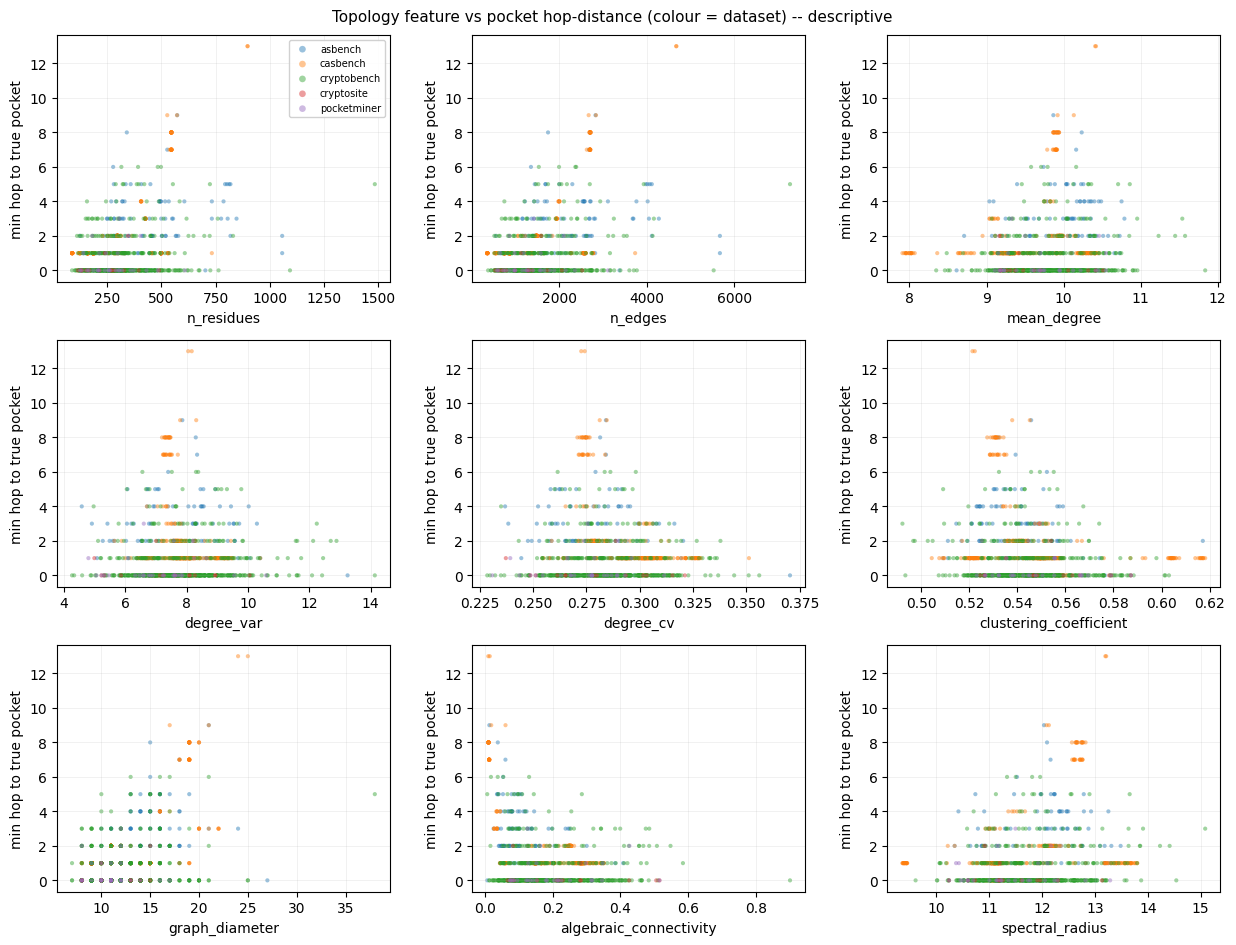

    >>> REL_DF = merged table | DESCRIPTIVE ONLY: nothing here trains or tunes anything


In [730]:
# ---- 4g. RELATIONSHIP TEST: does topology predict how far the pocket is? ------------------
# DESCRIPTIVE ONLY. No CTQW, no rule-building, no tuning, nothing here feeds a predictor.
# It merges the blind topology features (4e) with the measured pocket distances (4f) and asks
# one question per feature: does it track how far the true site sits from the active site?
#
# The four controls below are what separate a real answer from an artifact:
#
#  1. SIZE. n_residues spans 52-1486. Bigger proteins mechanically have longer diameters,
#     larger degree variance AND more distal pockets, so a raw "diameter predicts distance"
#     can be nothing but "size predicts size". Every feature is therefore reported twice:
#     raw Spearman, and PARTIAL Spearman holding n_residues fixed. The partial column is the
#     answer; the raw column is there to show how much of it was size all along.
#  2. TRUTH TYPE. curated_allosteric and drug_contact define the pocket differently and are
#     never pooled. Only curated_allosteric means "active <-> annotated allosteric distance".
#  3. CLUSTER LEVEL. One row per protein FAMILY (median) before correlating -- casbench alone
#     collapses 313 structures onto 33 families. Correlating structures would inflate n by
#     ~4x and manufacture significance.
#  4. FOCUS SET. The distal curated subset is reported as the headline, because it is the only
#     part of this benchmark where a propagation method has any distance to work with.
REL_FEATURES = ["n_residues", "n_edges", "mean_degree", "degree_var", "degree_cv",
                "clustering_coefficient", "graph_diameter", "algebraic_connectivity",
                "spectral_radius"]
REL_OUTCOMES = ["min_hop", "min_euclid"]
REL_CONTROL  = "n_residues"        # the confound held fixed in the partial correlation
REL_PLOTS    = True
REL_MIN_N    = 8                   # below this many families a correlation is not reported

from scipy import stats as _st

def _partial_spearman(x, y, z):
    """Spearman of x,y with z held fixed, from the three pairwise rank correlations.
    Returns (r, p, n). p uses df = n-3 (one control variable)."""
    x, y, z = _np2.asarray(x, float), _np2.asarray(y, float), _np2.asarray(z, float)
    m = _np2.isfinite(x) & _np2.isfinite(y) & _np2.isfinite(z)
    x, y, z = x[m], y[m], z[m]
    n = len(x)
    if n < 4 or len(set(x)) < 3 or len(set(y)) < 3:
        return float("nan"), float("nan"), n
    rxy = _st.spearmanr(x, y).correlation
    rxz = _st.spearmanr(x, z).correlation
    ryz = _st.spearmanr(y, z).correlation
    den = _np2.sqrt(max(0.0, (1 - rxz ** 2) * (1 - ryz ** 2)))
    if den == 0 or not _np2.isfinite(den):
        return float("nan"), float("nan"), n
    r = (rxy - rxz * ryz) / den
    r = max(-0.999999, min(0.999999, r))
    df = n - 3
    if df <= 0: return r, float("nan"), n
    t = r * _np2.sqrt(df / (1 - r ** 2))
    return r, float(2 * _st.t.sf(abs(t), df)), n

def _rel_table(df, label, outcome):
    """One correlation table: raw vs size-controlled, at FAMILY level (guardrail 3)."""
    d = df.dropna(subset=[outcome]).copy()
    if d["cluster"].notna().any():
        d = d.groupby("cluster", as_index=False)[REL_FEATURES + [outcome]].median()
        lvl = "families"
    else:
        lvl = "structures"
    print("    --- %s | outcome=%s | n=%d %s ---" % (label, outcome, len(d), lvl))
    if len(d) < REL_MIN_N:
        print("        too few (%d < REL_MIN_N=%d) -- not reported" % (len(d), REL_MIN_N)); return
    print("        %-24s %8s %8s %10s %10s %6s" %
          ("feature", "raw rho", "raw p", "partial", "partial p", "n"))
    for f in REL_FEATURES:
        if f not in d: continue
        v = d[f].to_numpy(float); o = d[outcome].to_numpy(float)
        m = _np2.isfinite(v) & _np2.isfinite(o)
        if m.sum() < REL_MIN_N or len(set(v[m])) < 3:
            print("        %-24s %8s  (constant or too few)" % (f, "-")); continue
        rr = _st.spearmanr(v[m], o[m])
        if f == REL_CONTROL:      # partialling a variable on itself is undefined, not 0
            print("        %-24s %8.3f %8.4f %10s %10s %6d"
                  % (f, rr.correlation, rr.pvalue, "(control)", "-", int(m.sum())))
            continue
        pr, pp, pn = _partial_spearman(v, o, d[REL_CONTROL].to_numpy(float))
        _star = "*" if (pp == pp and pp < 0.05) else " "
        print("        %-24s %8.3f %8.4f %10.3f %9.4f%s %6d"
              % (f, rr.correlation, rr.pvalue, pr, pp, _star, pn))

_T = globals().get("TOPO_DF"); _D = globals().get("DIST_DF")
if _T is None or _D is None or not len(_T) or not len(_D):
    print(">>> RELATIONSHIP TEST: need TOPO_DF (4e) and DIST_DF (4f) -- run those cells first.")
else:
    REL_DF = _D.merge(_T[[c for c in _T.columns if c in REL_FEATURES + ["name"]]],
                      on="name", how="inner", suffixes=("", "_topo"))
    print(">>> RELATIONSHIP TEST (descriptive): %d proteins with BOTH topology and distance"
          % len(REL_DF))
    print("    partial rho holds %s fixed; * marks partial p < 0.05" % REL_CONTROL)
    _cur = REL_DF[REL_DF["truth_type"] == "curated_allosteric"]
    _drg = REL_DF[REL_DF["truth_type"] == "drug_contact"]
    _foc = _cur[_cur["is_distal"] == True]
    for _out in REL_OUTCOMES:
        print("    ================= outcome: %s =================" % _out)
        _rel_table(_foc, "HEADLINE: curated_allosteric AND distal", _out)
        _rel_table(_cur, "curated_allosteric (all)", _out)
        _rel_table(_drg, "drug_contact (all)", _out)
        for _s in sorted(REL_DF["source"].unique()):
            _rel_table(REL_DF[REL_DF["source"] == _s], "  source=" + _s, _out)

    print("    >>> DISTAL vs CONTACT-ADJACENT (repeat of 4f, per dataset)")
    print("        %-14s %8s %9s %9s %9s" % ("source", "n_str", "families", "distal", "%distal"))
    for _s in sorted(REL_DF["source"].unique()):
        _d2 = REL_DF[REL_DF["source"] == _s]
        print("        %-14s %8d %9d %9d %8.0f%%"
              % (_s, len(_d2), _d2["cluster"].nunique(), int(_d2["is_distal"].sum()),
                 100.0 * _d2["is_distal"].mean()))

    if REL_PLOTS:
        _fs = [f for f in REL_FEATURES if f in REL_DF.columns]
        _n = len(_fs); _c = 3; _r = int(_np2.ceil(_n / _c))
        fig, axes = plt.subplots(_r, _c, figsize=(4.2 * _c, 3.2 * _r))
        axes = _np2.atleast_1d(axes).ravel()
        _srcs = sorted(REL_DF["source"].unique())
        _col = {s: plt.cm.tab10(i % 10) for i, s in enumerate(_srcs)}
        for _ax, f in zip(axes, _fs):
            for s in _srcs:
                d3 = REL_DF[(REL_DF["source"] == s)].dropna(subset=["min_hop", f])
                if len(d3):
                    _ax.scatter(d3[f], d3["min_hop"], s=9, alpha=0.45,
                                color=_col[s], label=s, edgecolors="none")
            _ax.set_xlabel(f); _ax.set_ylabel("min hop to true pocket")
            _ax.grid(alpha=0.25, lw=0.5)
        for _ax in axes[len(_fs):]: _ax.axis("off")
        axes[0].legend(fontsize=7, markerscale=1.6, framealpha=0.9)
        fig.suptitle("Topology feature vs pocket hop-distance (colour = dataset) -- descriptive",
                     fontsize=11)
        fig.tight_layout(); plt.show()
    print("    >>> REL_DF = merged table | DESCRIPTIVE ONLY: nothing here trains or tunes anything")


>>> 4h STRUCTURAL CLASSES -- 1020 structures -> 688 protein families
    ---------- clustering space: RAW z-scored features (size included) ----------
        k    silhouette cluster sizes
        2         0.257 [367, 321]
        3         0.240 [311, 191, 186]
        4         0.225 [115, 155, 241, 177]
        5         0.220 [210, 187, 149, 34, 108]
        6         0.214 [84, 157, 113, 80, 28, 226]
        7         0.217 [103, 72, 196, 55, 72, 28, 162]
        8         0.207 [153, 99, 114, 29, 127, 48, 62, 56]
        argmax k=2, silhouette 0.257 -> WEAK -- could be artificial
        curve is non-monotone; no k stands out, so any k is a slice of one continuum rather than a class count
    ---------- clustering space: SHAPE-ONLY (each feature residualised on n_residues) ----------
        k    silhouette cluster sizes
        2         0.267 [326, 362]
        3         0.202 [274, 197, 217]
        4         0.197 [167, 147, 172, 202]
        5         0.196 [125, 169, 163, 

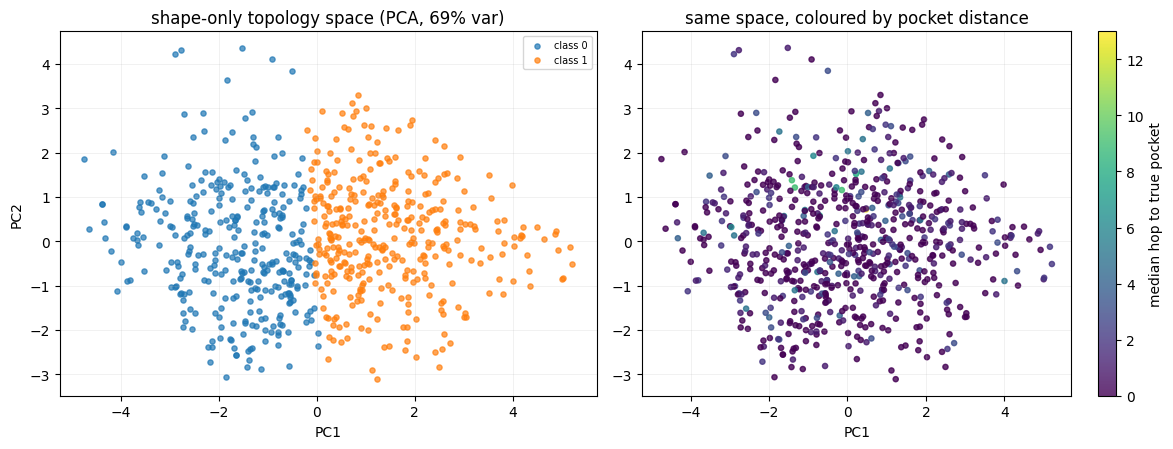

    >>> STRUCT_CLASSES = family table with a `cls` column (shape-only clustering)


In [731]:
# ---- 4h. STRUCTURAL CLASSES: group proteins by shape, then relate class to pocket distance --
# Two questions, in order:
#   (1) Do these proteins fall into natural topological groups at all?
#   (2) If so, does the group a protein belongs to say anything about how far its allosteric
#       site sits from its active site?
# DESCRIPTIVE. Nothing here trains a predictor or feeds the CTQW.
#
# THE TRAP THIS CELL IS BUILT AROUND. k-means always returns k clusters, and silhouette will
# always name a "best" k -- even for a single blob with no structure. The `bartosz` register
# hit exactly this (TASK-0309: "silhouette is high 0.53-0.84 at every k=2..6 in every cohort,
# never a clean single peak"). So the silhouette is reported ACROSS the whole k range, and a
# curve that is flat or monotone is called out as NO natural grouping rather than quietly
# reduced to its argmax. A number is printed either way; the verdict is not.
#
# SIZE. n_residues spans 52-1486 and dominates every distance-based clustering, so classes get
# built twice: on the raw z-scored features, and on features residualised on n_residues
# ("shape-only"). If the two disagree, the raw classes were size bins wearing a costume.
CLS_FEATURES = ["n_residues", "mean_degree", "degree_var", "degree_cv",
                "clustering_coefficient", "graph_diameter", "algebraic_connectivity",
                "spectral_radius"]
CLS_KRANGE   = list(range(2, 9))
CLS_SEED     = 0
CLS_PLOTS    = True
CLS_MIN_N    = 20

from sklearn.cluster import KMeans as _KM
from sklearn.metrics import silhouette_score as _sil, adjusted_rand_score as _ari
from sklearn.decomposition import PCA as _PCA
from scipy import stats as _st2

def _resid_on_size(X, size):
    """Strip the linear-in-rank effect of protein size from each feature."""
    out = X.copy()
    zs = _st2.rankdata(size)
    for j in range(X.shape[1]):
        zx = _st2.rankdata(X[:, j])
        b = _np2.polyfit(zs, zx, 1)
        out[:, j] = zx - _np2.polyval(b, zs)
    return out

def _zs(X):
    m, s = X.mean(0), X.std(0)
    s = _np2.where(s > 0, s, 1.0)
    return (X - m) / s

def _cluster_report(F, labels_src, dfam, space):
    print("    ---------- clustering space: %s ----------" % space)
    print("        %-4s %10s %s" % ("k", "silhouette", "cluster sizes"))
    best, sils = None, []
    for k in CLS_KRANGE:
        if k >= len(F): continue
        km = _KM(n_clusters=k, n_init=10, random_state=CLS_SEED).fit(F)
        s = _sil(F, km.labels_)
        sils.append((k, s, km))
        cnt = _np2.bincount(km.labels_, minlength=k)
        print("        %-4d %10.3f %s" % (k, s, list(cnt)))
        if best is None or s > best[1]: best = (k, s, km)
    if not sils: return None
    _sv = [s for _, s, _ in sils]
    _flat = (max(_sv) - min(_sv)) < 0.05
    _mono = all(_sv[i] >= _sv[i + 1] for i in range(len(_sv) - 1))
    # The SHAPE of the curve is not enough: silhouette has an absolute meaning too. Below ~0.25
    # is conventionally "no substantial structure", 0.25-0.50 "weak / could be artificial",
    # >0.50 "reasonable". An argmax at k=2 with s=0.26 is a weak split of one cloud, not two
    # populations -- say so, rather than reporting the argmax as though it were a discovery.
    _strength = ("NO substantial structure" if best[1] < 0.25 else
                 "WEAK -- could be artificial" if best[1] < 0.50 else
                 "reasonable separation")
    print("        argmax k=%d, silhouette %.3f -> %s" % (best[0], best[1], _strength))
    print("        curve is %s%s"
          % ("flat" if _flat else ("monotone decreasing in k" if _mono else "non-monotone"),
             "; no k stands out, so any k is a slice of one continuum rather than a class count"
             if (_flat or _mono or best[1] < 0.50) else "; k=%d is a real elbow" % best[0]))
    dfam = dfam.copy(); dfam["cls"] = best[2].labels_
    return dfam, best, (_flat or _mono)

_T2, _D2 = globals().get("TOPO_DF"), globals().get("DIST_DF")
if _T2 is None or _D2 is None or not len(_T2) or not len(_D2):
    print(">>> 4h structural classes: need TOPO_DF (4e) and DIST_DF (4f) first.")
else:
    _M = _D2.merge(_T2[[c for c in _T2.columns if c in CLS_FEATURES + ["name", "cath"]]],
                   on="name", how="inner", suffixes=("", "_t"))
    _feat = [f for f in CLS_FEATURES if f in _M.columns]
    # GUARDRAIL: one row per protein FAMILY before clustering or testing
    _fam = (_M.dropna(subset=_feat)
              .groupby("cluster", as_index=False)
              .agg({**{f: "median" for f in _feat},
                    "min_hop": "median", "min_euclid": "median",
                    "is_distal": "mean", "source": "first", "truth_type": "first",
                    "cath": "first"}))
    print(">>> 4h STRUCTURAL CLASSES -- %d structures -> %d protein families" % (len(_M), len(_fam)))
    if len(_fam) < CLS_MIN_N:
        print("    too few families (%d) to cluster." % len(_fam))
    else:
        X = _fam[_feat].to_numpy(float)
        Fraw = _zs(X)
        Fshp = _zs(_resid_on_size(X, _fam["n_residues"].to_numpy(float)))
        _r1 = _cluster_report(Fraw, None, _fam, "RAW z-scored features (size included)")
        _r2 = _cluster_report(Fshp, None, _fam, "SHAPE-ONLY (each feature residualised on n_residues)")
        if _r1 and _r2:
            print("    agreement between the two clusterings (adjusted Rand): %.3f  -> %s"
                  % (_ari(_r1[0]["cls"], _r2[0]["cls"]),
                     "same partition; the classes are not merely size bins"
                     if _ari(_r1[0]["cls"], _r2[0]["cls"]) > 0.5 else
                     "DIFFERENT partitions -- the raw classes were largely SIZE, so trust the "
                     "shape-only ones"))
        for _dfam, _best, _nogroup in [r for r in (_r1, _r2) if r]:
            _sp = "RAW" if _dfam is _r1[0] else "SHAPE-ONLY"
            print("    ---------- class profiles (%s, k=%d) ----------" % (_sp, _best[0]))
            _prof = _dfam.groupby("cls").agg(
                n=("cluster", "size"), n_res=("n_residues", "median"),
                diam=("graph_diameter", "median"), fiedler=("algebraic_connectivity", "median"),
                clust=("clustering_coefficient", "median"), deg=("mean_degree", "median"),
                hop=("min_hop", "median"), euclid=("min_euclid", "median"),
                distal=("is_distal", "mean"))
            print(_prof.round(3).to_string())
            # (2) does class say anything about pocket distance?
            for _out in ("min_hop", "min_euclid"):
                _grp = [g[_out].dropna().to_numpy() for _, g in _dfam.groupby("cls")
                        if g[_out].notna().sum() >= 3]
                if len(_grp) >= 2:
                    _H, _p = _st2.kruskal(*_grp)
                    print("        Kruskal-Wallis %-11s across %d classes: H=%.2f p=%.4f %s"
                          % (_out, len(_grp), _H, _p,
                             "<- classes DIFFER in pocket distance" if _p < 0.05
                             else "-- no difference between classes"))
            if "cath" in _dfam:
                _c = _dfam[_dfam["cath"].notna() & (_dfam["cath"] != "NA")]
                if len(_c) > 10:
                    _top = _c["cath"].astype(str).str.split(".").str[0]
                    print("        vs CATH class (top level, n=%d): adjusted Rand = %.3f -> %s"
                          % (len(_c), _ari(_top, _c["cls"]),
                             "topology classes partly recover fold class"
                             if _ari(_top, _c["cls"]) > 0.1 else
                             "topology classes are NOT fold classes -- they measure something else"))
            print("        class x source:")
            print(_np2.array2string(_np2.zeros(0)) if False else
                  pd.crosstab(_dfam["cls"], _dfam["source"]).to_string())
        # FOCUS SET: the only families where a propagation method has any distance to work
        # with. 4g found algebraic_connectivity survives size control HERE specifically, so the
        # class test is repeated on this subset rather than only on the pooled cloud (which is
        # dominated by drug_contact families whose pocket sits on the active site, hop = 0).
        _foc2 = _fam[(_fam["truth_type"] == "curated_allosteric") & (_fam["is_distal"] > 0)]
        print("    ---------- FOCUS: distal curated_allosteric families (n=%d) ----------"
              % len(_foc2))
        if len(_foc2) < CLS_MIN_N:
            print("        n=%d < CLS_MIN_N=%d -- too few families to cluster or test."
                  % (len(_foc2), CLS_MIN_N))
        else:
            _Xf = _zs(_resid_on_size(_foc2[_feat].to_numpy(float),
                                     _foc2["n_residues"].to_numpy(float)))
            _rf = _cluster_report(_Xf, None, _foc2, "FOCUS shape-only")
            if _rf:
                for _out in ("min_hop", "min_euclid"):
                    _g2 = [g[_out].dropna().to_numpy() for _, g in _rf[0].groupby("cls")
                           if g[_out].notna().sum() >= 3]
                    if len(_g2) >= 2:
                        _H2, _p2 = _st2.kruskal(*_g2)
                        print("        Kruskal-Wallis %-11s across %d classes: H=%.2f p=%.4f %s"
                              % (_out, len(_g2), _H2, _p2,
                                 "<- classes DIFFER" if _p2 < 0.05 else "-- no difference"))

        STRUCT_CLASSES = _r2[0] if _r2 else (_r1[0] if _r1 else None)
        if CLS_PLOTS and STRUCT_CLASSES is not None:
            P = _PCA(n_components=2, random_state=CLS_SEED).fit(Fshp)
            Y = P.transform(Fshp)
            fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
            for c in sorted(STRUCT_CLASSES["cls"].unique()):
                m = (STRUCT_CLASSES["cls"] == c).to_numpy()
                ax[0].scatter(Y[m, 0], Y[m, 1], s=14, alpha=0.7, label="class %d" % c)
            ax[0].set_title("shape-only topology space (PCA, %.0f%% var)"
                            % (100 * P.explained_variance_ratio_.sum()))
            ax[0].set_xlabel("PC1"); ax[0].set_ylabel("PC2"); ax[0].legend(fontsize=7)
            _sc = ax[1].scatter(Y[:, 0], Y[:, 1], s=14, alpha=0.8,
                                c=STRUCT_CLASSES["min_hop"].to_numpy(float), cmap="viridis")
            plt.colorbar(_sc, ax=ax[1], label="median hop to true pocket")
            ax[1].set_title("same space, coloured by pocket distance")
            ax[1].set_xlabel("PC1")
            for a in ax: a.grid(alpha=0.25, lw=0.5)
            fig.tight_layout(); plt.show()
        print("    >>> STRUCT_CLASSES = family table with a `cls` column (shape-only clustering)")


## 3 - Extract all structural information (apo + holo)

In [732]:
# ---- extract all information for the active systems (apo + holo) ------------
EXTRACT = {}
for name in ACTIVE:
    s = SYSTEMS[name]
    EXTRACT[name] = {"apo": structure_record(s["apo"], s["chain"])}
    if s["holo"]:
        EXTRACT[name]["holo"] = structure_record(s["holo"], None)

rows = []
for name, roles in EXTRACT.items():
    for role, rec in roles.items():
        b = rec["bfac"]; ligs = sorted(rec["ligands"].items(), key=lambda kv: -kv[1])
        rows.append(dict(
            system=name, role=role, pdb=rec["pdb_id"], chain=rec["chain"], n_res=rec["n"],
            span="%d-%d" % (rec["resseq"].min(), rec["resseq"].max()),
            method=rec["method"], res_A=rec["resolution"],
            B_mean=round(float(b.mean()), 1), B_const=bool(np.allclose(b, b[0])),
            missing=sum(len(v) for v in rec["missing"].values()),
            ligands=", ".join("%s(%d)" % (k, n) for k, n in ligs[:5]) or "none"))
summary = pd.DataFrame(rows)
summary

,system,role,pdb,chain,n_res,span,method,res_A,B_mean,B_const,missing,ligands
0,BCR_ABL1,apo,1OPL,A,451,81-531,X-RAY DIFFRACTION,2.0,81.7,False,258,"P16(58), MYR(15)"
1,BCR_ABL1,holo,5MO4,A,429,83-531,X-RAY DIFFRACTION,2.0,31.7,False,66,"NIL(39), AY7(31)"


## 4 - Visualize structure + features

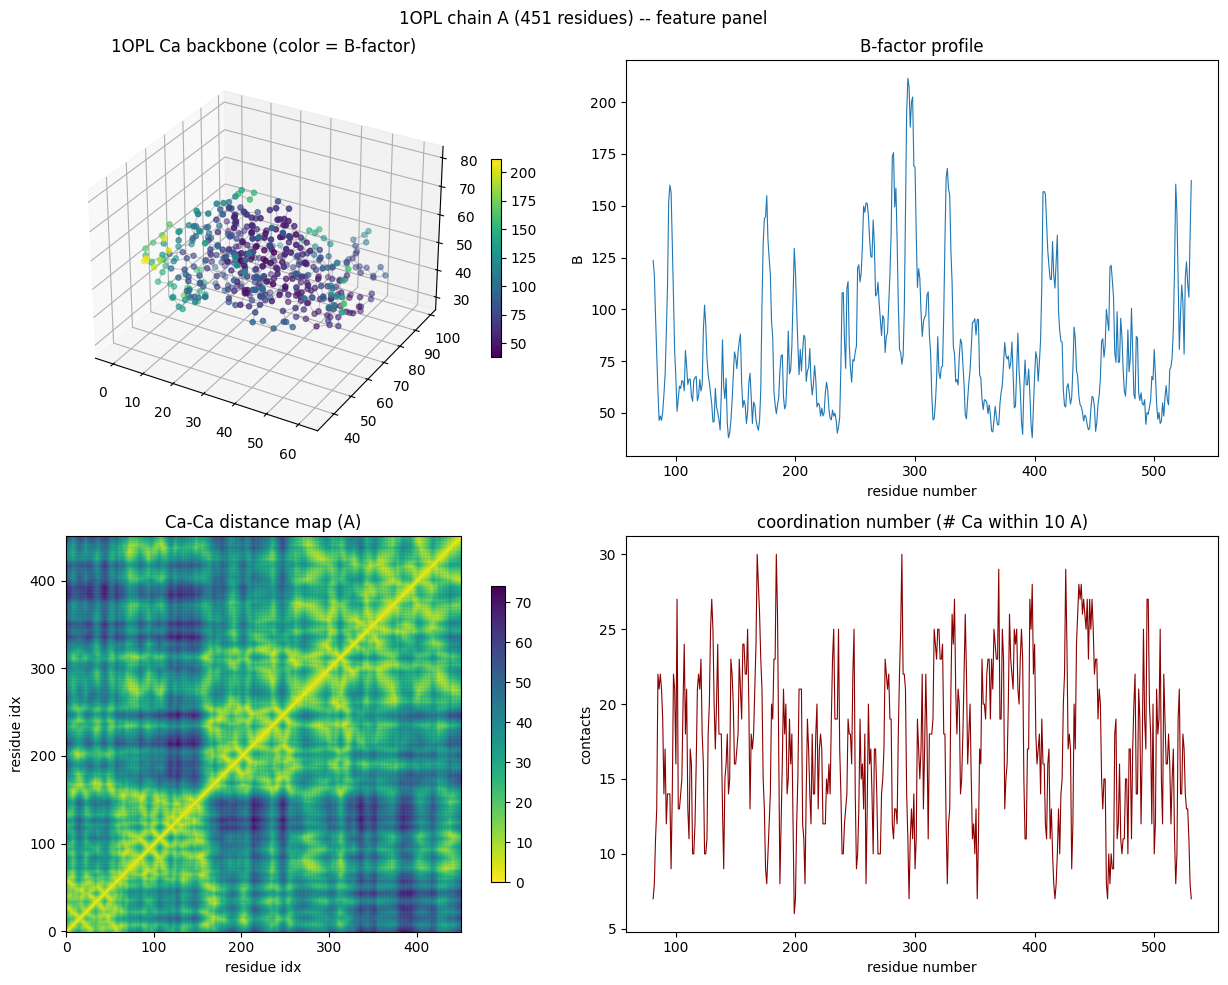

BCR_ABL1  holo 5MO4 ligands (drug = largest non-water HETATM): [('NIL', 39), ('AY7', 31)]


In [733]:
# ---- visualize structure + features (per active apo) -----------------------
def plot_features(rec):
    c = rec["coords"]
    varying_B = not np.allclose(rec["bfac"], rec["bfac"][0])
    color  = rec["bfac"] if varying_B else rec["coordnum"]
    clabel = "B-factor" if varying_B else "burial (B-factors are CONSTANT)"

    fig = plt.figure(figsize=(13, 10))
    ax = fig.add_subplot(2, 2, 1, projection="3d")
    ax.plot(c[:, 0], c[:, 1], c[:, 2], lw=0.6, color="gray", alpha=0.5)
    p = ax.scatter(c[:, 0], c[:, 1], c[:, 2], c=color, cmap="viridis", s=14)
    ax.set_title("%s Ca backbone (color = %s)" % (rec["pdb_id"], clabel))
    fig.colorbar(p, ax=ax, shrink=0.5)

    ax = fig.add_subplot(2, 2, 2)
    ax.plot(rec["resseq"], rec["bfac"], lw=0.8)
    ax.set_title("B-factor profile"); ax.set_xlabel("residue number"); ax.set_ylabel("B")

    ax = fig.add_subplot(2, 2, 3)
    im = ax.imshow(rec["D"], cmap="viridis_r", origin="lower")
    ax.set_title("Ca-Ca distance map (A)"); ax.set_xlabel("residue idx"); ax.set_ylabel("residue idx")
    fig.colorbar(im, ax=ax, shrink=0.75)

    ax = fig.add_subplot(2, 2, 4)
    ax.plot(rec["resseq"], rec["coordnum"], lw=0.8, color="darkred")
    ax.set_title("coordination number (# Ca within 10 A)")
    ax.set_xlabel("residue number"); ax.set_ylabel("contacts")

    fig.suptitle("%s chain %s (%d residues) -- feature panel" % (rec["pdb_id"], rec["chain"], rec["n"]))
    fig.tight_layout(); plt.show()

for name in ACTIVE:
    plot_features(EXTRACT[name]["apo"])
    holo = EXTRACT[name].get("holo")
    if holo:
        drug = sorted(holo["ligands"].items(), key=lambda kv: -kv[1])
        print("%s  holo %s ligands (drug = largest non-water HETATM): %s"
              % (name, holo["pdb_id"], drug[:5]))

## 5 - Active-site seed (ligand-contact @ `SITE_CUTOFF`)

The CTQW needs an **active-site seed** - a legitimate *input* (the challenge frames prediction as connectivity *to the active site*). Seed = residues contacting the **ATP-site ligand** at the global `SITE_CUTOFF` - the *same rule* used for the drug pocket in section 6, so the experiment is consistent. The ATP-site ligand is identified as the apo ligand whose contacts overlap the **UniProt curated catalytic residues**.

UniProt numbering is mapped onto the structure by **sequence alignment, not DBREF arithmetic**: for BCR-ABL1 the DBREF claims offset 0 but the true offset is **+19** (UniProt canonical is isoform 1a; 1OPL is 1b). 1OPL is also a **kinase-dead D382N** construct (SEQADV). UniProt residues are reported as an independent cross-check; if no ATP-site ligand is present we fall back to them.

In [734]:
# ---- active-site derivation: PDB SITE / REMARK 800 + UniProt (numbering-safe)
def parse_sites(path):
    """Parse SITE + REMARK 800 + DBREF from a PDB. Returns (sites, dbref):
      sites: {site_id: {'desc','evidence','residues':[(chain,resname,resnum)]}}
      dbref: {chain: (uniprot_acc, pdb_start, unp_start)}  # acc reliable; offset NOT trusted."""
    site_res, desc, evid, dbref = {}, {}, {}, {}
    cur = None
    with open(path) as fh:
        for line in fh:
            rec = line[:6].strip()
            if rec == "SITE":
                sid = line[11:14].strip()
                for base in (18, 29, 40, 51):          # 4 residues per SITE line
                    rn  = line[base:base + 3].strip()
                    ch  = line[base + 4:base + 5].strip()
                    num = line[base + 5:base + 9].strip()
                    if rn and num:
                        try:
                            site_res.setdefault(sid, []).append((ch, rn, int(num)))
                        except ValueError:
                            pass
            elif rec == "REMARK" and line[7:10].strip() == "800":
                body = line[11:].strip(); up = body.upper()
                if up.startswith("SITE_IDENTIFIER:"):
                    cur = body.split(":", 1)[1].strip()
                elif up.startswith("EVIDENCE_CODE:") and cur:
                    evid[cur] = body.split(":", 1)[1].strip()
                elif up.startswith("SITE_DESCRIPTION:") and cur:
                    desc[cur] = body.split(":", 1)[1].strip()
            elif rec == "DBREF":
                ch, acc = line[12:13].strip(), line[33:41].strip()
                try:
                    dbref[ch] = (acc, int(line[14:18]), int(line[55:60]))
                except ValueError:
                    pass
    sites = {sid: dict(desc=desc.get(sid, ""), evidence=evid.get(sid, ""), residues=r)
             for sid, r in site_res.items()}
    return sites, dbref


def uniprot_entry(acc, _cache={}):
    """Fetch a UniProtKB entry as JSON (cached per session, retried on network errors)."""
    if acc not in _cache:
        url = "https://rest.uniprot.org/uniprotkb/%s.json" % acc
        _cache[acc] = _net_retry(lambda: json.load(urllib.request.urlopen(url, timeout=30)),
                                 "UniProt fetch %s" % acc)
    return _cache[acc]


def uniprot_active_features(entry):
    """Active-site + ligand-binding features (UniProt numbering):
    list of (type, start, end, ligand, description)."""
    out = []
    for f in entry.get("features", []):
        if f["type"] in ("Active site", "Binding site"):
            loc = f["location"]
            out.append((f["type"], loc["start"]["value"], loc["end"]["value"],
                        f.get("ligand", {}).get("name", ""), f.get("description", "")))
    return out


def align_offset(num2aa, unp_seq):
    """Best constant offset d with PDB_resnum = UNP_pos + d, by max sequence identity.
    Robust to the DBREF/isoform numbering trap AND to a DOMAIN INSIDE A POLYPROTEIN:
    HIV-1 RT is numbered 1-556 but sits at ~600-1154 of Gag-Pol (P03366), i.e. d = -599.
    The previous +/-60 search window could never reach that and silently returned a
    garbage best (d=-38, identity=0.083) -> spurious "LOW map-confidence" and, whenever
    the apo and holo offsets differ, a WRONG holo->apo residue mapping. The window is now
    the full feasible range (vectorised, so it is also faster than the old 121-step loop).
    Returns (offset, identity, n_compared)."""
    nums = np.fromiter(num2aa.keys(), dtype=int)
    aas = np.array([num2aa[n] for n in nums])
    U = np.array(list(unp_seq)); L = len(unp_seq)
    best = (0, 0.0, 0)
    for d in range(int(nums.min()) - L, int(nums.max())):     # every offset that overlaps at all
        p = nums - d
        ok = (p >= 1) & (p <= L); tot = int(ok.sum())
        if tot <= 50:
            continue
        m = int((aas[ok] == U[p[ok] - 1]).sum())
        if m / tot > best[1]:
            best = (d, m / tot, tot)
    return best


# ---- ligand-contact site definition (ONE shared cutoff for every site) -------
def _atoms(pdb_id, chain):
    """Parse heavy atoms of a PDB: protein atoms on `chain` + ligand atoms on `chain`.
    Returns prot{resnum:{'ca':xyz|None,'heavy':(Nx3)}}, ligs{resname:(Mx3)}. First model only."""
    prot, ligs = {}, {}
    done = False
    with open(fetch_pdb(pdb_id)) as fh:
        for line in fh:
            rec = line[:6].strip()
            if rec == "ENDMDL":
                done = True
            if done or rec not in ("ATOM", "HETATM"):
                continue
            if line[76:78].strip() == "H":                    # skip hydrogens
                continue
            resn, atom, ch = line[17:20].strip(), line[12:16].strip(), line[21:22]
            try:
                xyz = (float(line[30:38]), float(line[38:46]), float(line[46:54]))
            except ValueError:
                continue
            if rec == "HETATM" and resn not in AA3 and resn not in WATER:
                if ch == chain:
                    ligs.setdefault(resn, []).append(xyz)
            elif ch == chain and (rec == "ATOM" or resn in AA3):
                try:
                    num = int(line[22:26])
                except ValueError:
                    continue
                d = prot.setdefault(num, {"ca": None, "heavy": []})
                d["heavy"].append(xyz)
                if atom == "CA":
                    d["ca"] = xyz
    for n in prot:
        d = prot[n]; d["heavy"] = np.array(d["heavy"]) if d["heavy"] else np.empty((0, 3))
    return prot, {k: np.array(v) for k, v in ligs.items()}


def ligand_contact_site(pdb_id, chain, ligand, cutoff=None, mode=None):
    """Residues of `chain` in contact with `ligand`, native numbering (sorted).
    mode 'heavy': any protein heavy atom within cutoff of any ligand atom (standard).
    mode 'ca'   : residue Ca within cutoff of any ligand atom (matches our Ca network)."""
    cutoff = SITE_CUTOFF if cutoff is None else cutoff
    mode = SITE_MODE if mode is None else mode
    prot, ligs = _atoms(pdb_id, chain)
    if ligand not in ligs or len(ligs[ligand]) == 0:
        return []
    L = ligs[ligand]
    out = []
    for num, d in prot.items():
        if mode == "ca":
            if d["ca"] is not None and cdist([d["ca"]], L).min() <= cutoff:
                out.append(num)
        elif len(d["heavy"]) and cdist(d["heavy"], L).min() <= cutoff:
            out.append(num)
    return sorted(out)

# ---- holo -> apo residue mapping by GLOBAL ALIGNMENT (Needleman-Wunsch) ------------------
# The constant-offset map above (`align_offset`) finds ONE shift, resnum = unp_pos + d. That
# is correct for pure renumbering, and it is what section 6 used originally -- but it is wrong
# the moment apo and holo differ by an INSERTION OR DELETION: a loop resolved in one structure
# and missing in the other shifts every residue after it, silently, and the drug pocket lands
# on the wrong residues while still looking plausible. Across hundreds of cross-structure
# mappings that is not a corner case.
# A global alignment handles indels properly. Biopython's PairwiseAligner is a real NW
# implementation in C; difflib is a stdlib fallback (matching blocks, not a true alignment,
# but indel-aware); the constant offset remains the last resort so this never hard-fails.
try:
    from Bio import Align as _BioAlign
    _NW = _BioAlign.PairwiseAligner()
    _NW.mode = "global"
    _NW.match_score, _NW.mismatch_score = 2.0, -1.0
    _NW.open_gap_score, _NW.extend_gap_score = -10.0, -0.5   # penalise opening, not extending:
    _NW_BACKEND = "biopython"                                # missing loops are long gaps
except Exception:
    _NW, _NW_BACKEND = None, "difflib"


def nw_resnum_map(src_num2aa, dst_num2aa):
    """Map src residue numbers -> dst residue numbers by global sequence alignment.
    Both inputs are {resnum: one-letter}. Returns (map, backend, identity_of_aligned_pairs).
    Only 1:1 aligned positions are mapped; gapped positions are simply absent from the map,
    which is the honest outcome -- a residue with no counterpart should not be guessed at."""
    s_nums = sorted(src_num2aa); d_nums = sorted(dst_num2aa)
    s_seq = "".join(src_num2aa[n] for n in s_nums)
    d_seq = "".join(dst_num2aa[n] for n in d_nums)
    if not s_seq or not d_seq:
        return {}, "none", 0.0
    blocks = []
    if _NW is not None:
        try:
            a = _NW.align(s_seq, d_seq)[0]
            blocks = [((int(x[0]), int(x[1])), (int(y[0]), int(y[1])))
                      for x, y in zip(a.aligned[0], a.aligned[1])]
        except Exception:
            blocks = []
    if not blocks:
        import difflib
        blocks = [((b.a, b.a + b.size), (b.b, b.b + b.size))
                  for b in difflib.SequenceMatcher(None, s_seq, d_seq, autojunk=False)
                  .get_matching_blocks() if b.size]
    m, same, tot = {}, 0, 0
    for (i, j), (k, l) in blocks:
        for t in range(min(j - i, l - k)):
            m[s_nums[i + t]] = d_nums[k + t]
            tot += 1
            same += 1 if s_seq[i + t] == d_seq[k + t] else 0
    return m, (_NW_BACKEND if _NW is not None else "difflib"), (same / tot if tot else 0.0)


In [735]:
# Active-site SEED = residues contacting the ATP-site ligand at the GLOBAL SITE_CUTOFF.
# The ATP-site ligand is identified as the apo ligand whose contacts overlap the
# UniProt-curated catalytic residues (sequence-derived, numbering-corrected).
# Same cutoff rule as the drug pocket (section 6) -> a fair, consistent experiment.
# Seed is INPUT (allowed). UniProt residues are reported as an independent cross-check.

ACTIVE_SITE     = {}     # system -> active-site seed (apo numbering) == CTQW seed (INPUT)
ACTIVE_SITE_UNP = {}     # system -> UniProt curated catalytic residues (cross-check)
ATP_LIGAND      = {}     # system -> apo ligand identified as the active-site marker

for name in ACTIVE:
    rec = EXTRACT[name]["apo"]; chain = rec["chain"]; apo_id = SYSTEMS[name]["apo"]
    num2aa = dict(zip(rec["resseq"].tolist(), rec["seq"]))
    _, dbref = parse_sites(fetch_pdb(apo_id))

    # UniProt curated catalytic residues (anchor + cross-check), numbering-corrected
    acc = dbref.get(chain, (None,))[0]
    up_pdb, offset, ident = set(), None, None
    if acc:
        ent = uniprot_entry(acc)
        unp = (ent.get("sequence") or {}).get("value")   # guard: DBREF may cite a DELETED entry
        if unp is None:
            print("  !! UniProt %s is inactive/deleted (no sequence) -> skipping UniProt cross-check" % acc)
        else:
            offset, ident, _ = align_offset(num2aa, unp)
        for typ, s, e, lig, desc in uniprot_active_features(ent):
            up_pdb.update(p + offset for p in range(s, e + 1) if (p + offset) in num2aa)
    ACTIVE_SITE_UNP[name] = sorted(up_pdb)

    # every apo ligand's contact site at the global cutoff; ATP-site = max overlap w/ UniProt catalytic
    _, apo_ligs = _atoms(apo_id, chain)
    lig_sites = {lg: ligand_contact_site(apo_id, chain, lg) for lg in apo_ligs}
    atp_lig, best = None, 0
    for lg, res in lig_sites.items():
        ov = len(set(res) & up_pdb)
        if ov > best:
            best, atp_lig = ov, lg
    ATP_LIGAND[name] = atp_lig

    # Curated catalytic residues (literature) -- used ONLY where UniProt auto-detection cannot
    # work: e.g. the accession is a POLYPROTEIN whose annotated "Active site" belongs to a
    # different domain (HIV1_RT: P03366 Gag-Pol, its Active site 525 is the PROTEASE), or the
    # entry is unreviewed with no functional annotation at all (PBP2A: O54286). The active site
    # is an INPUT/seed (allowed, same status as the apo PDB id) -- it is NOT the answer;
    # DRUG_POCKET remains firewalled. Announced loudly below, never applied silently.
    manual = SYSTEMS[name].get("active_resnums")
    if manual:
        seed = sorted(set(manual) & set(num2aa))
        src = "CURATED catalytic residues (literature; UniProt auto-detect unusable here)"
    elif atp_lig:                                                # ligand-contact active site (consistent rule)
        seed = sorted(set(lig_sites[atp_lig]) & set(num2aa))
        src = "ligand %s contacts @ %.1fA %s" % (atp_lig, SITE_CUTOFF, SITE_MODE)
    else:                                                        # fallback: UniProt curated (no ATP-site ligand)
        seed = sorted(up_pdb)
        src = "UniProt curated (no ATP-site ligand in apo)"
    if manual and len(seed) < len(manual):
        print("  !! curated active site: %d/%d residues not present in the apo chain: %s"
              % (len(manual) - len(seed), len(manual), sorted(set(manual) - set(seed))))
    ACTIVE_SITE[name] = seed

    print("=== %s  apo %s chain %s ===" % (name, apo_id, chain))
    if acc:
        print("  UniProt %s offset=%+d id=%.3f  catalytic (cross-check, %d): %s"
              % (acc, offset or 0, ident or 0.0, len(ACTIVE_SITE_UNP[name]), ACTIVE_SITE_UNP[name]))
    print("  apo ligand contact-sites @ %.1fA %s: %s"
          % (SITE_CUTOFF, SITE_MODE, {lg: len(r) for lg, r in lig_sites.items()}))
    print("  >> ACTIVE-SITE SEED via %s -> %d res (INPUT): %s" % (src, len(seed), seed))

=== BCR_ABL1  apo 1OPL chain A ===
  UniProt P00519 offset=+19 id=0.998  catalytic (cross-check, 18): [267, 268, 269, 270, 271, 272, 273, 274, 275, 290, 335, 336, 337, 338, 339, 340, 341, 382]
  apo ligand contact-sites @ 4.5A heavy: {'MYR': 16, 'P16': 21}
  >> ACTIVE-SITE SEED via ligand P16 contacts @ 4.5A heavy -> 21 res (INPUT): [267, 268, 272, 275, 288, 289, 290, 305, 309, 318, 332, 334, 335, 336, 337, 338, 340, 389, 399, 400, 401]


## 6 - Drug pocket = validation ground truth (ligand-contact @ `SITE_CUTOFF`)

The **holo** structure is where the drug is bound, so its drug-contact residues are the challenge **ground truth**. Pocket = residues contacting the **allosteric ligand** at the *same* global `SITE_CUTOFF` / `SITE_MODE` used for the active site - so both sites are defined by one identical rule. The allosteric ligand is the holo ligand whose contacts do **not** overlap the active site (sanity-check per target).

The cutoff is a **difficulty dial on validation** (a wider pocket is easier to hit -> inflated P@5/AUC), which is exactly why it is fixed once, at the top, for every site.

**Firewall:** the pocket is stored in `DRUG_POCKET` - scorer-only; the predictor must never read it. Both holo numbering (as bound) and an apo-mapped copy (to score apo predictions) are kept.

In [736]:
# Drug pocket (GROUND TRUTH) = residues contacting the NAMED CHALLENGE DRUG in the
# HOLO structure, at the global SITE_CUTOFF / SITE_MODE. The drug is selected by its
# explicit challenge code (SYSTEMS[name]['drug_code']) -- NOT auto-picked -- so ions
# (Mg2+), the ATP-site nucleotide, and crystallisation additives can never be mistaken
# for the allosteric drug (the earlier "min active-site overlap" rule wrongly picked
# Mg2+ for KRAS). Holo->apo numbering via per-chain UniProt sequence alignment; the
# alignment IDENTITY is reported so a low-confidence (e.g. cross-species) map is visible.
# FIREWALL: DRUG_POCKET is scorer-only; the predictor must NEVER read it.

DRUG_POCKET    = {}   # system -> {'ligand','holo_pdb','cutoff','mode','residues_holo','residues_apo','map'}
DRUG_SITES_ALL = {}   # system -> [(ligand, role, active_overlap, residues_holo)]


def _chain_uniprot_offset(pdb_id, chain, num2aa):
    """Best constant offset (resnum = UNP_pos + d) + identity for one chain vs its
    DBREF UniProt sequence. Returns (offset, identity, acc)."""
    acc = parse_sites(fetch_pdb(pdb_id))[1].get(chain, (None,))[0]
    if not acc:
        return 0, None, None
    seq = (uniprot_entry(acc).get("sequence") or {}).get("value")   # DBREF can cite a DELETED
    if not seq:                                                     # UniProt entry (e.g. 3ZFZ->Q54113)
        print("   !! UniProt %s is inactive/deleted (no sequence) -> no alignment for %s chain %s"
              % (acc, pdb_id, chain))
        return 0, None, acc
    d, ident, _ = align_offset(num2aa, seq)
    return d, ident, acc


for name in ACTIVE:
    if not EXTRACT[name].get("holo"):
        print("%s: no holo structure -> no drug ground truth (connectivity-only)" % name)
        continue
    holo = EXTRACT[name]["holo"]; hchain = holo["chain"]; holo_id = SYSTEMS[name]["holo"]
    drug_code = SYSTEMS[name].get("drug_code")
    hnum2aa = dict(zip(holo["resseq"].tolist(), holo["seq"]))

    # holo -> apo numbering, each side aligned to ITS OWN chain's UniProt
    holo_off, holo_ident, hacc = _chain_uniprot_offset(holo_id, hchain, hnum2aa)
    arec = EXTRACT[name]["apo"]; anum2aa = dict(zip(arec["resseq"].tolist(), arec["seq"]))
    apo_off, apo_ident, aacc = _chain_uniprot_offset(SYSTEMS[name]["apo"], arec["chain"], anum2aa)
    if holo_ident is None:
        holo_off = 0
    if apo_ident is None:
        apo_off = holo_off
    # PRIMARY map: global alignment of the holo chain onto the apo chain (indel-safe).
    # The UniProt constant offsets above are kept as the fallback and are still printed, so a
    # disagreement between the two is visible rather than hidden.
    _nwmap, _nwback, _nwid = nw_resnum_map(hnum2aa, anum2aa)
    _nwok = bool(_nwmap) and _nwid >= 0.80          # a low-identity alignment is not a mapping
    def _to_apo(n):
        if _nwok and n in _nwmap:
            return _nwmap[n]
        return n - holo_off + apo_off               # constant-offset fallback
    seedset = set(ACTIVE_SITE.get(name, []))

    # contacts of EVERY non-water ligand on the holo chain (for the transparency table)
    _, holo_ligs = _atoms(holo_id, hchain)
    rows = []
    for lg in sorted(holo_ligs):
        res = [n for n in ligand_contact_site(holo_id, hchain, lg) if n in hnum2aa]
        if not res:
            continue
        res_apo = sorted({_to_apo(n) for n in res})
        ov = len(set(res_apo) & seedset)
        rows.append([lg, ov, sorted(res), res_apo])
    DRUG_SITES_ALL[name] = [(r[0], "DRUG" if r[0] == drug_code else "other", r[1], r[2]) for r in rows]

    print("=== %s  holo %s chain %s  (pocket @ %.1fA %s; drug=%s) ===" %
          (name, holo_id, hchain, SITE_CUTOFF, SITE_MODE, drug_code))
    print("   holo UniProt %s id=%.3f off=%+d | apo UniProt %s id=%.3f off=%+d" %
          (hacc, holo_ident or 0.0, holo_off, aacc, apo_ident or 0.0, apo_off))
    print("   holo->apo map: %s (%s), %d residues aligned, identity %.3f%s"
          % ("ALIGNMENT" if _nwok else "constant offset (alignment rejected)", _nwback,
             len(_nwmap), _nwid,
             "" if _nwok else "  <- identity < 0.80, falling back to %+d" % (apo_off - holo_off)))
    if _nwok:
        _dis = sum(1 for n in hnum2aa if n in _nwmap and _nwmap[n] != n - holo_off + apo_off)
        if _dis:
            print("   !! alignment and constant offset DISAGREE on %d/%d residues -- an indel"
                  % (_dis, len(_nwmap)))
            print("      between apo and holo; the constant offset would have shifted the pocket.")
    for lg, role, ov, res in DRUG_SITES_ALL[name]:
        print("   ligand %-4s %-6s (%2d holo-contacts, active-site overlap=%d)" % (lg, role, len(res), ov))

    # SELECT the drug strictly by code
    drug_row = next((r for r in rows if r[0] == drug_code), None)
    if drug_row is None:
        print("   !! drug_code %s not found in %s chain %s contacts -> NO ground truth for %s" %
              (drug_code, holo_id, hchain, name))
        continue
    lg, ov, res_holo, res_apo = drug_row
    res_apo = sorted(r for r in res_apo if r in anum2aa)   # keep residues present in the apo chain
    xspecies = (hacc is not None and aacc is not None and hacc != aacc)
    DRUG_POCKET[name] = dict(ligand=lg, holo_pdb=holo_id, cutoff=SITE_CUTOFF, mode=SITE_MODE,
                             residues_holo=res_holo, residues_apo=res_apo,
                             map=dict(holo_acc=hacc, apo_acc=aacc, holo_ident=holo_ident,
                                      apo_ident=apo_ident, cross_species=xspecies))
    conf = "LOW (cross-species/low-identity map)" if (xspecies or (apo_ident or 1) < 0.9
                                                      or (holo_ident or 1) < 0.9) else "ok"
    print("   >> GROUND-TRUTH pocket = %s: %d holo-contacts -> %d apo residues (active overlap=%d)  map-confidence=%s"
          % (lg, len(res_holo), len(res_apo), len(set(res_apo) & seedset), conf))
    print("   >> FIREWALLED in DRUG_POCKET (scorer-only).")

# ---- curated truth (ASBench/CASBench): the true site is GIVEN, not derived from a holo ----
# These entries have no holo by design, so the loop above skipped them. Their allosteric
# residues come straight from the source database, already in this chain's numbering, so
# there is no ligand-contact step and no SITE_CUTOFF involved -- recorded as cutoff=None so a
# later sweep cannot silently pretend these were built at 4.5 A.
for _n in ACTIVE:
    if _n in DRUG_POCKET or _n not in globals().get("BENCHMARK_TRUTH", {}):
        continue
    _res = [r for r in BENCHMARK_TRUTH[_n] if r in set(EXTRACT[_n]["apo"]["resseq"].tolist())]
    if not _res:
        print("%s: curated allosteric residues do not map onto chain %s -> no ground truth"
              % (_n, EXTRACT[_n]["apo"]["chain"])); continue
    DRUG_POCKET[_n] = dict(ligand=(SYSTEMS[_n].get("drug_code") or "curated"),
                           holo_pdb=None, cutoff=None, mode="curated_allosteric",
                           residues_holo=[], residues_apo=_res, mapped=len(_res))
    print("%s: curated allosteric site -> %d residues (no holo, no cutoff)" % (_n, len(_res)))


=== BCR_ABL1  holo 5MO4 chain A  (pocket @ 4.5A heavy; drug=AY7) ===
   holo UniProt P00519 id=0.995 off=+19 | apo UniProt P00519 id=0.998 off=+19
   holo->apo map: ALIGNMENT (biopython), 429 residues aligned, identity 0.998
   ligand AY7  DRUG   (20 holo-contacts, active-site overlap=0)
   ligand NIL  other  (26 holo-contacts, active-site overlap=18)
   >> GROUND-TRUTH pocket = AY7: 20 holo-contacts -> 20 apo residues (active overlap=0)  map-confidence=ok
   >> FIREWALLED in DRUG_POCKET (scorer-only).


## 7 - Candidate pockets (fpocket): get the pockets first

fpocket does **not** identify allosteric sites - it is a **function-blind geometric detector** that enumerates *candidate* pockets (alpha-sphere clusters) with a druggability score. Getting this candidate set is a prerequisite: it is the **search space** the quantum method (and validation) will later rank. So the logic is **pockets first, allosteric selection later** - selecting the allosteric pocket among these is a downstream step, not fpocket's job.

**fpocket** (Le Guilloux 2009) runs as an external binary (build: `git clone github.com/Discngine/fpocket && make ARCH=MACOSXARM64`; set `FPOCKET_BIN`) and yields ~60 pockets per structure -> `CANDIDATE_POCKETS` (residues + druggability + center of mass).

**PocketMiner** (GNN cryptic-pocket) and **P2Rank** (ML) are not run here (need TensorFlow / a Java runtime, unavailable in this env). Documented, not faked.

The active-site pocket is flagged (it is *input*) so it can be excluded as a distal candidate. We deliberately do **not** compare pockets to the drug pocket here - that is a validation/scoring step, kept out to keep detection blind.

In [737]:
# ---- candidate pockets: fpocket (blind geometric pocket DETECTION) -----------
# fpocket ENUMERATES candidate pockets from geometry; it is function-blind - it
# does NOT identify which pocket is allosteric. That selection is the downstream
# job (CTQW re-ranking + validation). This section just gets "the pockets first":
# the candidate search space every later method will rank.
import subprocess, glob, re, shutil

FPOCKET_BIN = (os.environ.get("FPOCKET_BIN") or shutil.which("fpocket")
               or os.path.expanduser("~/Downloads/fpocket_bin/fpocket"))


def run_fpocket(pdb_id, chain):
    """Run fpocket on the ISOLATED working chain (protein atoms only) so pockets are
    chain-specific (1OPL is a dimer). Returns candidate pockets sorted by druggability
    desc: [{'id','drug','residues'}]  (None if the binary is unavailable)."""
    if not (FPOCKET_BIN and os.path.exists(FPOCKET_BIN)):
        return None
    src = fetch_pdb(pdb_id)
    work = os.path.join(PDB_CACHE, "%s_%s.pdb" % (pdb_id.upper(), chain))
    if not os.path.exists(work):                     # write chain-only protein PDB
        with open(src) as fh, open(work, "w") as w:
            for line in fh:
                if line[:6].strip() == "ATOM" and line[21:22] == chain:
                    w.write(line)
            w.write("END\n")
    out = work[:-4] + "_out"
    if not os.path.isdir(out):                       # cache: don't re-run
        subprocess.run([FPOCKET_BIN, "-f", work],
                       stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=False)
    drug, pid = {}, None
    info = os.path.join(out, os.path.basename(work)[:-4] + "_info.txt")
    if os.path.exists(info):
        for line in open(info):
            s = line.strip()
            if s.startswith("Pocket"):
                pid = int(s.split()[1])
            elif s.startswith("Druggability Score"):
                drug[pid] = float(s.split(":")[1])
    pockets = []
    for fp in glob.glob(os.path.join(out, "pockets", "pocket*_atm.pdb")):
        pid = int(re.search(r"pocket(\d+)_atm", os.path.basename(fp)).group(1))
        res = set()
        for line in open(fp):
            if line[:6].strip() in ("ATOM", "HETATM"):
                try:
                    res.add(int(line[22:26]))
                except ValueError:
                    pass
        pockets.append(dict(id=pid, drug=drug.get(pid, 0.0), residues=res))
    return sorted(pockets, key=lambda p: -p["drug"])


CANDIDATE_POCKETS = {}   # system -> [{'id','drug','n_res','residues','center'}], druggability desc
for name in ACTIVE:
    apo_id = SYSTEMS[name]["apo"]
    rec = EXTRACT[name]["apo"]
    pk = run_fpocket(apo_id, rec["chain"])
    if pk is None:
        print("%s: fpocket binary not found (FPOCKET_BIN=%s)." % (name, FPOCKET_BIN))
        print("   build: git clone https://github.com/Discngine/fpocket && cd fpocket && make ARCH=MACOSXARM64")
        continue
    num2xyz = dict(zip(rec["resseq"].tolist(), rec["coords"]))
    for p in pk:
        pts = np.array([num2xyz[n] for n in p["residues"] if n in num2xyz])
        p["n_res"] = len(p["residues"])
        p["center"] = pts.mean(0).round(1).tolist() if len(pts) else None
    CANDIDATE_POCKETS[name] = pk

    # flag the active-site pocket only (active site is INPUT) so it can be excluded
    # as a distal candidate later. We do NOT compare to the drug pocket here (blind).
    active = set(ACTIVE_SITE.get(name, []))
    act_id = max(pk, key=lambda p: len(p["residues"] & active))["id"] if active else None

    print("=== %s  candidate pockets on apo %s chain %s (fpocket, function-blind) ===" % (name, apo_id, rec["chain"]))
    print("  %d pockets detected. Top 10 by druggability:" % len(pk))
    print("   pocket  drugg  #res  center(x,y,z)          note")
    for p in pk[:10]:
        note = "<- active site (INPUT)" if p["id"] == act_id else ""
        print("    P%-4d  %.3f  %3d   %-21s %s" % (p["id"], p["drug"], p["n_res"], p["center"], note))
    print("  -> CANDIDATE_POCKETS['%s'] = all %d pockets (residues + druggability + center)." % (name, len(pk)))
    print("     Which pocket is ALLOSTERIC is decided downstream (CTQW re-rank), not by fpocket.")

=== BCR_ABL1  candidate pockets on apo 1OPL chain A (fpocket, function-blind) ===
  37 pockets detected. Top 10 by druggability:
   pocket  drugg  #res  center(x,y,z)          note
    P1     0.899   24   [20.2, 51.9, 51.6]    <- active site (INPUT)
    P2     0.566   19   [45.7, 55.9, 53.3]    
    P10    0.029    9   [5.8, 45.3, 57.5]     
    P8     0.005   12   [29.1, 61.6, 72.6]    
    P14    0.004   11   [12.5, 67.4, 41.5]    
    P7     0.003    7   [35.8, 41.3, 73.1]    
    P5     0.002   13   [36.3, 68.1, 53.4]    
    P25    0.001    7   [29.2, 53.3, 76.7]    
    P12    0.001    6   [21.3, 62.8, 70.2]    
    P4     0.001    9   [17.5, 73.5, 47.6]    
  -> CANDIDATE_POCKETS['BCR_ABL1'] = all 37 pockets (residues + druggability + center).
     Which pocket is ALLOSTERIC is decided downstream (CTQW re-rank), not by fpocket.


## 7b - How distal is each candidate pocket from the active site?

Allosteric pockets are **distal** - far from the active site yet dynamically coupled - so the first thing to know about fpocket's candidates is *how far each one sits from the active site*. We quantify the separation two complementary ways:

- **Geometric (Angstrom):** `d_center` = distance between pocket & active-site centroids (the standard site-separation); `d_min` = closest Ca-Ca approach; `d_mean` = mean over pocket residues of the nearest active-residue distance.
- **Network (graph hops):** shortest-path distance of the pocket's residues (nodes) to the active set on the Ca contact graph (cutoff = `NET_CUTOFF` from cell 1) - `hop_min`/`hop_mean`.

**Biophysics convention:** overlap>0 or `d_center`<8 A = orthosteric/adjacent; 8-15 A = proximal; **>15 A with 0 overlap = DISTAL allosteric candidate** (real allosteric sites are typically >15-20 A away). The printed **average center-to-active over all pockets** answers 'how far, on average, are fpocket's pockets from the active site.'

In [738]:
# ---- how DISTAL is each fpocket pocket from the active site? (geometric + network) ----
import networkx as _nx
# ---- ALL section-7b settings in one place (edit here) -----------------------
POCKET_ROWS     = 0        # fpocket rows to print: 0 = ALL pockets (set e.g. 12 to shorten)
PASSER_ENABLE   = True     # run the PASSer baseline? False = skip (offline / no network)
PASSER_MODEL    = "ensemble"   # "ensemble" (2021, best top-3) | "automl" | "rank"
PASSER_CACHE    = "passer_cache.json"   # disk cache -> the API is hit once per target
PASSER_ROWS     = 0        # PASSer rows to print: 0 = ALL
PASSER_JACCARD  = 0.5      # J threshold for calling a PASSer pocket and an fpocket pocket
                           # THE SAME CAVITY.  J = shared residues / all residues of both.
                           # 1.0 = identical | 0.5 = half agree (default) | 0.3 = loose
PASSER_PAIRS    = 8        # how many matched pairs to print in the paired-detail table
# -- PocketMiner (GNN cryptic-pocket predictor, Meller et al. Nat Commun 2023) ------------
# It has no scriptable API and needs python 3.7-3.9 + TensorFlow<=2.9 +
# mdtraj, so it CANNOT run in this kernel. Run it separately (web UI or its own conda env)
# and drop the per-residue output here; this cell EXPORTS the input and LOADS the output.
#   github.com/Mickdub/gvp (branch pocket_pred) -> src/xtal_predict.py
#   writes "<stem>.txt": ONE SCORE PER LINE, one line per residue, in input-PDB order.
PM_ENABLE       = True     # False = skip PocketMiner entirely
PM_DIR          = "pocketminer"   # <PM_DIR>/input/<TARGET>.pdb in, <PM_DIR>/output/<TARGET>.txt out
PM_AGG          = "max"    # pocket score from its residues: "max" (any hot residue) or "mean"
PM_EXPORT       = True     # write PM_DIR/input/<TARGET>.pdb (full backbone) for the external run
# PocketMiner scores RESIDUES, so to compare it with the two pocket-level methods its
# residue scores are aggregated per fpocket pocket (PM_AGG) and the pocket list is cut:
PM_SELECT_MODE  = "accessible"   # "accessible" = open now OR predicted to open (RECOMMENDED)
                                 # "top"        = old rule, top-N by raw cryptic-ness score
PM_ACCEPT_STATES = ("OPEN(lig)", "CRYPTIC", "mixed")   # states that count as accessible
PM_SELECT_TOP   = 5        # top-N pockets by PM score count as "PocketMiner-selected" (0 = use quantile)
PM_SELECT_Q     = 0.75     # if PM_SELECT_TOP == 0: keep pockets scoring above this quantile
CONSENSUS_REQUIRE_PM = False   # True -> sec 14 seeds ONLY from the three-way set (see 7b-3WAY)
SEL_TOP_K            = 10      # a pocket is "selected" by fpocket/PASSer if in their top-K (see 7b-MATRIX)
CONSENSUS_USE_MATRIX = False   # True -> sec 14 seeds from the MAJORITY (>=2 of 3) set
# "already open" vs "cryptic" annotation (see 7b-STATE):
PM_NULL_N       = 2000     # random same-size pockets used to calibrate a PocketMiner score
PM_PCT_HI       = 0.90     # pocket percentile >= this vs that null -> CRYPTIC (predicted to open)
PM_PCT_LO       = 0.10     # pocket percentile <= this               -> nothing to open
APO_LIG_CUTOFF  = 8.0      # Ca-to-ligand-atom [A]: a non-water ligand this close in the APO
                           # structure means the pocket is ALREADY OPEN, as a fact not a prediction
# -- consensus SEED SET exported to sec 14 (SEED_FROM_PASSER_OVERLAP) ---------
# PASSer's pockets ARE fpocket's cavities (it runs fpocket internally), so cavity-identity
# overlap is vacuous (always ~100%, J=1.00). The consensus that MEANS something is rank-based:
# "table" ranks by JACCARD, which is degenerate here: PASSer runs fpocket internally, so the
# two cavity sets are identical and J ties at ~1.00 for everything -- the "top-8 by J" is then
# just arbitrary tie-breaking, not "the 8 most allosteric". "both" is the rule that matches
# what each tool actually measures: fpocket = druggability, PASSer = allostery, so take the
# pockets each ranks in its own top-K.
CONSENSUS_MODE  = "combined" # "combined"= top-K by druggability AND allostery TOGETHER,
                             #            ranked by CONSENSUS_COMBINE (strongest on BOTH)
                             # "both"    = in both top-K lists (membership, not strength)
CONSENSUS_MODE_ALT = None    # "all"    = EVERY pocket in the PASSer-fpocket overlap (J >= PASSER_JACCARD)
                           #            -> the literal overlap set. DEFAULT.
                           # "table"  = EXACTLY the pairs printed in the paired-detail table below,
                           #            i.e. the best-J pairs, cut to PASSER_PAIRS. Since J ties at
                           #            1.00 the cut falls back to PASSer rank, so this is "PASSer's
                           #            top-PASSER_PAIRS cavities that fpocket also finds".
                           # "passer" = only PASSer's top-CONSENSUS_TOP_K of them
                           # "both"   = PASSer top-K AND fpocket-druggability top-K (very strict)
                           # "either" = top-K of at least one
CONSENSUS_TOP_K = 20       # used by "passer"/"both"/"either"/"combined"
CONSENSUS_COMBINE = "minrank"  # for CONSENSUS_MODE="combined": "rrf" | "minrank" | "product"
POCKET_DISTANCE = {}   # name -> per-pocket separation descriptors (A and graph-hops)
for name in ACTIVE:
    rec = EXTRACT[name]["apo"]; coords = rec["coords"]
    ca  = {int(r): c for r, c in zip(rec["resseq"].tolist(), coords)}   # resnum -> Ca xyz
    r2i = {int(r): i for i, r in enumerate(rec["resseq"].tolist())}     # resnum -> node index
    active = [r for r in ACTIVE_SITE.get(name, []) if r in ca]
    pk = CANDIDATE_POCKETS.get(name, [])
    if not active or not pk:
        print("=== %s: no active site / no pockets -> skip ===" % name); continue
    A = np.array([ca[r] for r in active]); A_cen = A.mean(0)
    # Ca contact graph (cutoff = NET_CUTOFF from cell 1) -> shortest-path hops from the active set
    diff = coords[:, None, :] - coords[None, :, :]; d2 = (diff ** 2).sum(-1)
    G = _nx.from_numpy_array(((d2 < NET_CUTOFF ** 2) & (d2 > 0)).astype(int))
    hop = {}
    for r in active:
        for n_, h in _nx.single_source_shortest_path_length(G, r2i[r]).items():
            hop[n_] = min(hop.get(n_, 10**9), h)
    drugset = set(DRUG_POCKET.get(name, {}).get("residues_apo", []))   # display-only (like sec 9/10)
    rows = []
    for p in pk:
        pres = [r for r in p["residues"] if r in ca]
        if not pres: continue
        P = np.array([ca[r] for r in pres])
        D = np.sqrt(((P[:, None, :] - A[None, :, :]) ** 2).sum(-1))     # pocket-res x active-res (A)
        hops = [hop.get(r2i[r], 99) for r in pres]
        rows.append(dict(id=p["id"], drug=p.get("drug", 0.0), n=len(pres),
                         d_center=float(np.linalg.norm(P.mean(0) - A_cen)),
                         d_min=float(D.min()), d_mean=float(D.min(1).mean()),
                         hop_min=int(min(hops)), hop_mean=float(np.mean(hops)),
                         overlap=len(set(pres) & set(active)), ov_drug=len(set(pres) & drugset),
                         drug_res=sorted(set(pres) & drugset), n_drug_tot=len(drugset)))
    for r in rows:
        r["cls"] = ("ORTHO/adj" if (r["overlap"] or r["d_center"] < 8)
                    else "proximal" if r["d_center"] < 15 else "DISTAL")
    POCKET_DISTANCE[name] = rows
    print("=== %s : separation of every fpocket pocket from the active site (%d active residues, %d pockets) ===" % (name, len(active), len(rows)))
    print("    >>> AVERAGE over all pockets:  center-to-active = %.1f A  |  mean graph-hops = %.1f  <<<"
          % (np.mean([r["d_center"] for r in rows]), np.mean([r["hop_mean"] for r in rows])))
    print("    columns:  drugg = fpocket druggability (0-1)   |  n = pocket residues")
    print("              dCen  = pocket-centre to active-centre distance [A]")
    print("              dMin  = CLOSEST pocket residue to the active site [A]  (min over all pairs)")
    print("              dMean = avg distance of pocket residues to their nearest active residue [A]")
    print("              hopMn/hopAv = MIN / MEAN graph hops to the active site (contact network)")
    print("              ovAct = residues shared with ACTIVE site | ovDrug = shared with DRUG pocket")
    print("              %ofDrug = ovDrug / all drug-pocket residues (how much of the drug site this pocket covers)")
    print("              %ofPkt  = ovDrug / n (how drug-specific this pocket is; 1.00 = it IS the drug pocket)")
    _rows = sorted(rows, key=lambda r: -r["drug"])
    _rows = _rows if POCKET_ROWS <= 0 else _rows[:POCKET_ROWS]
    _ncls = {k: sum(1 for r in rows if r["cls"] == k) for k in ("ORTHO/adj", "proximal", "DISTAL")}
    print("    showing %d of %d pockets  |  class counts: %s"
          % (len(_rows), len(rows), ", ".join("%s=%d" % (k, v) for k, v in _ncls.items())))
    print("    %-5s %-6s %-3s %-8s %-7s %-8s %-5s %-6s %-5s %-6s %-7s %-7s %s"
          % ("pkt", "drugg", "n", "dCen[A]", "dMin[A]", "dMean[A]", "hopMn", "hopAv",
             "ovAct", "ovDrug", "%ofDrug", "%ofPkt", "class"))
    _best_ov = max((x["ov_drug"] for x in rows), default=0)
    _lig = DRUG_POCKET.get(name, {}).get("ligand", "?")
    for r in _rows:
        _tag = "   <- holds the DRUG pocket" if (r["ov_drug"] and r["ov_drug"] == _best_ov) else ""
        _fd = (r["ov_drug"] / r["n_drug_tot"]) if r["n_drug_tot"] else 0.0   # coverage of the drug site
        _fp = (r["ov_drug"] / r["n"]) if r["n"] else 0.0                     # purity of this pocket
        print("    P%-4d %-6.3f %-3d %-8.1f %-7.1f %-8.1f %-5d %-6.1f %-5d %-6d %-7s %-7s %s%s"
              % (r["id"], r["drug"], r["n"], r["d_center"], r["d_min"], r["d_mean"],
                 r["hop_min"], r["hop_mean"], r["overlap"], r["ov_drug"],
                 ("%.2f" % _fd) if r["ov_drug"] else "-", ("%.2f" % _fp) if r["ov_drug"] else "-",
                 r["cls"], _tag))
        if r["ov_drug"]:                                                     # which drug residues, by name
            print("          drug %-4s residues in this pocket (%d/%d): %s"
                  % (_lig, r["ov_drug"], r["n_drug_tot"], r["drug_res"]))


# ===========================================================================
# 7b-PASSer - the same table for PASSer, the strongest published allosteric-site
#              predictor, + how much it overlaps fpocket.   ADDITIVE: nothing above changed.
# ---------------------------------------------------------------------------
# WHY PASSer and not Allosite/AllositePro/ALLO: all four are the SAME family (fpocket or
# DoGSite descriptors -> supervised classifier trained on ASD, NO active-site input), so
# they are one baseline, not four. PASSer is the most recent, is the top performer in
# independent benchmarking (AlloBench, ACS Omega 2025, 100 held-out proteins), and is the
# only one with a public API. Allosite/AllositePro are manual-web-form only (expired TLS);
# ALLO is Python-2, unlicensed, and retrains per run so its output is not reproducible.
#
# KEY DIFFERENCE, and the reason this is a CONTROL and not a rival: PASSer never sees the
# active site. It ranks pockets by how much they LOOK like known allosteric pockets. The
# CTQW ranks them by DYNAMIC CONNECTIVITY TO THE ACTIVE SITE -- the challenge's own §4.1
# objective. So a low PASSer rank for the true pocket is not a failure of PASSer; it is a
# demonstration that pocket appearance and active-site coupling are different questions.
import urllib.request, urllib.parse, json as _json, re as _re, os as _os

# (settings live at the TOP of this cell: PASSER_ENABLE / MODEL / CACHE / ROWS / JACCARD / PAIRS)

def _passer_fetch(pdb_id, chain=None, model=PASSER_MODEL, timeout=180):
    """POST https://passer.smu.edu/api -> {rank: {prob, residues}}. Cached on disk."""
    key = "%s|%s|%s" % (pdb_id.lower(), chain or "-", model)
    cache = {}
    if _os.path.exists(PASSER_CACHE):
        try: cache = _json.load(open(PASSER_CACHE))
        except Exception: cache = {}
    if key in cache:
        return cache[key]
    d = {"pdb": pdb_id.lower(), "model": model, "top": "all"}
    if chain: d["chain"] = chain
    req = urllib.request.Request("https://passer.smu.edu/api",
                                 data=urllib.parse.urlencode(d).encode(), method="POST")
    res = _json.load(urllib.request.urlopen(req, timeout=timeout))
    cache[key] = res
    try: _json.dump(cache, open(PASSER_CACHE, "w"))
    except Exception: pass
    return res

def _passer_residues(sel, chain=None):
    """PASSer returns a VMD selection string; keep only OUR chain (it can carry HETATM
    artifacts like '(chain 4 and resid 2.060 4.181)') and return integer resnums."""
    out = set()
    for ch, nums in _re.findall(r'chain\s+(\S+)\s+and\s+resid\s+([0-9eE.+\-\s]+)', sel):
        if chain and ch != chain:
            continue
        for tok in nums.split():
            try:
                v = float(tok)
                if abs(v - round(v)) < 1e-6 and v > 0: out.add(int(round(v)))
            except ValueError:
                pass
    return out

SEED_PROVENANCE = {}  # name -> how its consensus set was built (settings + timestamp)
PASSER_POCKETS = {}   # name -> [dict(rank, prob, residues, ov_act, ov_drug, d_center, hop_min, cls)]
PASSER_FPOCKET_MATCH = {}
PASSER_PAIR_MAP = {}   # name -> {fpocket_id: (PASSer rank, prob%, Jaccard)}   # name -> {fpocket_id: jaccard} for pairs at J >= PASSER_JACCARD
                            # (consumed by sec 14 when SEED_FROM_PASSER_OVERLAP = True)
for name in (ACTIVE if PASSER_ENABLE else []):
    rec = EXTRACT[name]["apo"]; apo_id = SYSTEMS[name]["apo"]; chain = rec["chain"]
    ca = {int(r): np.asarray(c, float) for r, c in zip(rec["resseq"], rec["coords"])}
    r2i = {int(r): i for i, r in enumerate(rec["resseq"].tolist())}
    active = [r for r in ACTIVE_SITE.get(name, []) if r in ca]
    drugset = set(DRUG_POCKET.get(name, {}).get("residues_apo", []))
    if not active:
        print("=== %s : PASSer skipped (no active site) ===" % name); continue
    try:
        raw = _passer_fetch(apo_id, chain)
    except Exception as e:
        print("=== %s : PASSer unavailable (%r) -> skipped ===" % (name, e)); continue

    A = np.array([ca[r] for r in active]); A_cen = A.mean(0)
    coords = rec["coords"]
    diff = coords[:, None, :] - coords[None, :, :]; d2 = (diff ** 2).sum(-1)
    G = _nx.from_numpy_array(((d2 < NET_CUTOFF ** 2) & (d2 > 0)).astype(int))
    hop = {}
    for r in active:
        for n_, h in _nx.single_source_shortest_path_length(G, r2i[r]).items():
            hop[n_] = min(hop.get(n_, 10 ** 9), h)

    rows = []
    for k in sorted(raw, key=lambda x: int(x)):
        pres = sorted(_passer_residues(raw[k]["residues"], chain) & set(ca))
        if not pres: continue
        P = np.array([ca[r] for r in pres])
        D = np.sqrt(((P[:, None, :] - A[None, :, :]) ** 2).sum(-1))
        hops = [hop.get(r2i[r], 99) for r in pres]
        ovd = sorted(set(pres) & drugset)
        rows.append(dict(rank=int(k), prob=float(raw[k]["prob"].rstrip("%")), n=len(pres),
                         residues=pres, d_center=float(np.linalg.norm(P.mean(0) - A_cen)),
                         d_min=float(D.min()), d_mean=float(D.min(1).mean()),
                         hop_min=int(min(hops)), hop_mean=float(np.mean(hops)),
                         overlap=len(set(pres) & set(active)), ov_drug=len(ovd),
                         drug_res=ovd, n_drug_tot=len(drugset)))
    for r in rows:
        r["cls"] = ("ORTHO/adj" if (r["overlap"] or r["d_center"] < 8)
                    else "proximal" if r["d_center"] < 15 else "DISTAL")
    PASSER_POCKETS[name] = rows
    _lig = DRUG_POCKET.get(name, {}).get("ligand", "?")
    _show = rows if PASSER_ROWS <= 0 else rows[:PASSER_ROWS]
    _ncls = {k: sum(1 for r in rows if r["cls"] == k) for k in ("ORTHO/adj", "proximal", "DISTAL")}
    _bo = max((r["ov_drug"] for r in rows), default=0)
    print("=== %s : PASSer (%s model) pockets vs the SAME functional sites ===" % (name, PASSER_MODEL))
    print("    NOTE: PASSer never sees the active site -- it ranks pockets by APPEARANCE, not coupling.")
    print("    showing %d of %d pockets  |  class counts: %s"
          % (len(_show), len(rows), ", ".join("%s=%d" % (k, v) for k, v in _ncls.items())))
    print("    %-5s %-6s %-3s %-8s %-7s %-8s %-5s %-6s %-5s %-6s %-7s %-7s %s"
          % ("rank", "prob%", "n", "dCen[A]", "dMin[A]", "dMean[A]", "hopMn", "hopAv",
             "ovAct", "ovDrug", "%ofDrug", "%ofPkt", "class"))
    for r in _show:
        _tag = "   <- holds the DRUG pocket" if (r["ov_drug"] and r["ov_drug"] == _bo) else ""
        if r["overlap"] >= 3 and r["overlap"] >= r["ov_drug"]:
            _tag = "   *** ACTIVE SITE (%d/%d of it) ***" % (r["overlap"], len(active))
        _fd = r["ov_drug"] / r["n_drug_tot"] if r["n_drug_tot"] else 0.0
        _fp = r["ov_drug"] / r["n"] if r["n"] else 0.0
        print("    #%-4d %-6.2f %-3d %-8.1f %-7.1f %-8.1f %-5d %-6.1f %-5d %-6d %-7s %-7s %s%s"
              % (r["rank"], r["prob"], r["n"], r["d_center"], r["d_min"], r["d_mean"],
                 r["hop_min"], r["hop_mean"], r["overlap"], r["ov_drug"],
                 ("%.2f" % _fd) if r["ov_drug"] else "-", ("%.2f" % _fp) if r["ov_drug"] else "-",
                 r["cls"], _tag))
        if r["ov_drug"]:
            print("          drug %-4s residues in this pocket (%d/%d): %s"
                  % (_lig, r["ov_drug"], r["n_drug_tot"], r["drug_res"]))
    # ---- where does each method put the TRUE pocket? ----
    if drugset:
        pb = max(rows, key=lambda r: r["ov_drug"]) if rows else None
        fp_rows = POCKET_DISTANCE.get(name, [])
        fb = max(fp_rows, key=lambda r: r.get("ov_drug", 0)) if fp_rows else None
        print("    >>> TRUE-POCKET RANK:")
        if pb and pb["ov_drug"]:
            print("          PASSer  : rank %d of %d (prob %.2f%%, covers %d/%d drug residues)"
                  % (pb["rank"], len(rows), pb["prob"], pb["ov_drug"], len(drugset)))
        else:
            print("          PASSer  : NOT FOUND in any of its %d pockets" % len(rows))
        if fb and fb.get("ov_drug"):
            _fr = sorted(fp_rows, key=lambda r: -r["drug"]).index(fb) + 1
            print("          fpocket : rank %d of %d by druggability (covers %d/%d drug residues)"
                  % (_fr, len(fp_rows), fb["ov_drug"], len(drugset)))

    # ---- OVERLAP between the two pocket sets (do they even find the same cavities?) ----
    if POCKET_DISTANCE.get(name):
        fpk = {r["id"]: set(r.get("drug_res", [])) for r in POCKET_DISTANCE[name]}
        fp_res = {p["id"]: set(p["residues"]) for p in CANDIDATE_POCKETS.get(name, [])}
        def _jac(a, b): return len(a & b) / len(a | b) if (a | b) else 0.0
        pairs = []
        for pr in rows:
            best = max(fp_res, key=lambda q: _jac(set(pr["residues"]), fp_res[q])) if fp_res else None
            if best is not None:
                pairs.append((pr["rank"], best, _jac(set(pr["residues"]), fp_res[best])))
        matched = [x for x in pairs if x[2] >= PASSER_JACCARD]
        # keep the full PASSer-rank <-> fpocket-id map so the three-way report below can
        # show WHERE each method ranked a pocket, not merely whether it appeared
        PASSER_PAIR_MAP[name] = {fid: (rk, next((r["prob"] for r in rows if r["rank"] == rk), 0.0), j)
                                 for rk, fid, j in matched}
        print("    >>> PASSer vs fpocket POCKET-SET OVERLAP (Jaccard of residue sets):")
        print("          %d PASSer pockets | %d fpocket pockets | %d matched at Jaccard>=%.2f (%.0f%%)"
              % (len(rows), len(fp_res), len(matched), PASSER_JACCARD, 100.0 * len(matched) / max(len(rows), 1)))
        if matched and len(matched) == len(rows):
            print("          NOTE: 100%% matched is EXPECTED -- PASSer runs fpocket internally, so the two")
            print("          cavity sets are identical. Cavity overlap alone therefore selects NOTHING;")
            print("          the exported seed set below is RANK-based (CONSENSUS_MODE/CONSENSUS_TOP_K).")
        # ---- rank-based consensus -> the ONLY thing exported to sec 14 ----
        _p2f = {rk: fid for rk, fid, j in matched}                     # PASSer rank -> fpocket id (same cavity)
        endorsed_passer = {_p2f[rk] for rk in _p2f if rk <= CONSENSUS_TOP_K}
        _fp_by_drug = [q["id"] for q in sorted(CANDIDATE_POCKETS.get(name, []),
                                               key=lambda q: -q.get("drug", 0.0))]
        endorsed_fpocket = set(_fp_by_drug[:CONSENSUS_TOP_K])
        # --- "combined": strongest on BOTH axes at once, not merely present in both --------
        # "both" is a set intersection: #1 druggable / #10 allosteric counts the same as #5/#5.
        # This ORDERS pockets by their two ranks together and keeps the top CONSENSUS_TOP_K.
        #   rrf      1/(60+rank_fp) + 1/(60+rank_passer) -- scale-free, forgives one weak rank
        #   minrank  the WORSE of the two ranks -- strict: mediocre on either axis sinks it
        #   product  (1-pct_fp)*(1-pct_passer) -- multiplicative, needs both genuinely high
        _rk_fp = {pid: r + 1 for r, pid in enumerate(_fp_by_drug)}
        _rk_pa = {fid: rk for rk, fid in _p2f.items()}
        _both_ranked = [pid for pid in _rk_pa if pid in _rk_fp]
        def _combined_key(pid):
            a, b = _rk_fp[pid], _rk_pa[pid]
            if CONSENSUS_COMBINE == "minrank": return (max(a, b), a + b)
            if CONSENSUS_COMBINE == "product":
                n_f = len(_rk_fp); n_p = max(list(_rk_pa.values()) or [1])
                return (-((1 - a / n_f) * (1 - b / n_p)),)
            return (-(1.0 / (60 + a) + 1.0 / (60 + b)),)
        if CONSENSUS_MODE == "combined":
            _ordered = sorted(_both_ranked, key=_combined_key)
            _cons = set(_ordered[:CONSENSUS_TOP_K])
            print("          COMBINED (%s): top-%d strongest on druggability AND allostery together"
                  % (CONSENSUS_COMBINE, CONSENSUS_TOP_K))
            print("            %-7s %-11s %-11s %s" % ("pkt", "fpocket rk", "PASSer rk", "kept"))
            for pid in _ordered[:max(CONSENSUS_TOP_K + 3, 8)]:
                print("            P%-6d #%-10d #%-10d %s"
                      % (pid, _rk_fp[pid], _rk_pa[pid], "yes" if pid in _cons else "-"))
        elif CONSENSUS_MODE == "all":
            _cons = {fid for _, fid, _j in matched}                    # the whole overlap set
        elif CONSENSUS_MODE == "table":                                # exactly the printed rows
            _cons = {fid for _rk, fid, _j in sorted(matched, key=lambda t: -t[2])[:PASSER_PAIRS]}
        elif CONSENSUS_MODE == "passer":
            _cons = endorsed_passer
        elif CONSENSUS_MODE == "either":
            _cons = endorsed_passer | endorsed_fpocket
        else:                                                          # "both" (strict AND)
            _cons = endorsed_passer & endorsed_fpocket
        PASSER_FPOCKET_MATCH[name] = {fid: 1.0 for fid in _cons}       # -> sec 14 seed source
        # Stamp HOW this set was built. sec 14 prints it, so a stale set (7b not re-run after a
        # settings change) is visible in sec 14's own output instead of being silently reused.
        SEED_PROVENANCE[name] = dict(mode=CONSENSUS_MODE, combine=CONSENSUS_COMBINE,
                                     top_k=CONSENSUS_TOP_K, jaccard=PASSER_JACCARD,
                                     n_pockets=len(_cons), stamped=time.strftime("%H:%M:%S"))
        if CONSENSUS_MODE == "combined":
            pass                                        # already reported in detail above
        elif CONSENSUS_MODE == "all":
            print("          CONSENSUS SET (mode=all): every overlapping pocket, no rank cut")
        elif CONSENSUS_MODE == "table":
            print("          CONSENSUS SET (mode=table): exactly the %d best-J pairs printed below"
                  % PASSER_PAIRS)
        else:
            print("          RANK CONSENSUS (mode=%s, top-K=%d):" % (CONSENSUS_MODE, CONSENSUS_TOP_K))
            print("            PASSer top-%d  -> fpocket ids %s" % (CONSENSUS_TOP_K, sorted(endorsed_passer)))
            print("            fpocket top-%d by druggability -> %s" % (CONSENSUS_TOP_K, sorted(endorsed_fpocket)))
        print("          -> PASSER_FPOCKET_MATCH['%s'] = %d pockets: %s"
              % (name, len(_cons), sorted(_cons)))
        if drugset:
            _true_fid = max(fp_res, key=lambda q: len(fp_res[q] & drugset)) if fp_res else None
            _true_cov = len(fp_res.get(_true_fid, set()) & drugset) if _true_fid else 0
            if _true_cov:
                print("          TRUE drug pocket = fpocket P%d (covers %d/%d drug residues): %s the consensus set%s"
                      % (_true_fid, _true_cov, len(drugset),
                         "INSIDE" if _true_fid in _cons else "!! EXCLUDED from",
                         "" if _true_fid in _cons else "  -> sec 14 P@5 would be 0 BY CONSTRUCTION; "
                         "raise CONSENSUS_TOP_K or use CONSENSUS_MODE='passer'/'either'"))
        print("          median best-match Jaccard = %.2f  (1.00 = identical cavity)"
              % (float(np.median([x[2] for x in pairs])) if pairs else 0.0))
        # paired detail: the SAME columns as the tables above, for both sides of each match
        _fpd = {r["id"]: r for r in POCKET_DISTANCE[name]}
        _prow = {r["rank"]: r for r in rows}
        print("          paired detail (same columns as the tables above; J = Jaccard of the two residue sets):")
        print("          %-6s %-7s %-6s %-10s %-3s %-8s %-7s %-8s %-5s %-6s %-5s %-6s %-7s %-7s %s"
              % ("J", "source", "pkt", "drugg/prob", "n", "dCen[A]", "dMin[A]", "dMean[A]",
                 "hopMn", "hopAv", "ovAct", "ovDrug", "%ofDrug", "%ofPkt", "class"))
        def _pline(j, src, tag, score, r):
            _nd = r.get("n_drug_tot", 0)
            _fd = (r["ov_drug"] / _nd) if (_nd and r["ov_drug"]) else 0.0
            _fp = (r["ov_drug"] / r["n"]) if (r["n"] and r["ov_drug"]) else 0.0
            print("          %-6s %-7s %-6s %-10.3f %-3d %-8.1f %-7.1f %-8.1f %-5d %-6.1f %-5d %-6d %-7s %-7s %s"
                  % (j, src, tag, score, r["n"], r["d_center"], r["d_min"], r["d_mean"],
                     r["hop_min"], r["hop_mean"], r["overlap"], r["ov_drug"],
                     ("%.2f" % _fd) if r["ov_drug"] else "-", ("%.2f" % _fp) if r["ov_drug"] else "-",
                     r["cls"]))
        for rk, fid, j in sorted(pairs, key=lambda t: -t[2])[:PASSER_PAIRS]:   # best matches first
            pr = _prow.get(rk); fr = _fpd.get(fid)
            if pr: _pline("%.2f" % j, "PASSer", "#%d" % rk, pr["prob"], pr)
            if fr: _pline("", "fpocket", "P%d" % fid, fr["drug"], fr)
            print()
    print()


# ===========================================================================
# 7b-PocketMiner - per-RESIDUE cryptic-pocket GNN (Meller et al. 2023,
# Nat Commun 14:2135, doi:10.1038/s41467-023-36699-3).  ADDITIVE.
# ---------------------------------------------------------------------------
# It CANNOT run in this kernel: it needs python 3.7-3.9 + TensorFlow<=2.9 + mdtraj,
# while this kernel is newer. So this cell does the two halves it CAN do:
#   (1) EXPORT  a full-backbone single-chain apo PDB per target -> PM_DIR/input/
#   (2) LOAD    the per-residue scores the container writes  <- PM_DIR/output/
# Run the middle step outside the notebook (docker recipe printed below).
#
# PocketMiner is the only baseline whose OUTPUT SHAPE matches the CTQW: a score per
# residue, not a ranked list of pockets. So it is scored two ways: aggregated to
# pockets (same table style as fpocket/PASSer) and DIRECTLY per residue on the CTQW's
# own seed set - the like-for-like comparison against p_avg / the residual.
# Caveats, stated with every table: it predicts CRYPTIC-ness, not allostery; like
# PASSer it never sees the active site; and its training labels came from MD (our
# inference supplies no trajectories, but the provenance is worth declaring).
PM_IN  = os.path.join(PM_DIR, "input")
PM_OUT = os.path.join(PM_DIR, "output")

# --- backbone atoms PocketMiner's GVP featuriser requires -------------------
_PM_BB = ("N", "CA", "C", "O")

def pm_export_apo(name, verbose=True):
    """Write PM_IN/<name>.pdb = the EXACT residues this notebook uses for `name`'s apo
    chain, all atoms, first model, first altLoc - plus a .json sidecar listing the
    residue numbers in output order. The sidecar is what makes the score->residue map
    exact: PocketMiner returns a bare array with no residue labels, so the mapping is
    only as trustworthy as the record of what went in.
    MSE (selenomethionine) is rewritten to MET: PocketMiner has a hardcoded
    20-canonical-residue table and fails on anything else (the same upstream limit that
    killed the CME-containing targets in the reference run). MSE *is* Met with Se for S,
    so the substitution is chemically standard - but it is a modification, so it is
    reported, not silent."""
    os.makedirs(PM_IN, exist_ok=True)
    apo_id = SYSTEMS[name]["apo"]
    path = fetch_pdb(apo_id)
    st = parse_pdb(path); ch = select_chain(st, SYSTEMS[name]["chain"])
    keep = [(r["resseq"], r["icode"]) for r in st["chains"][ch]]      # notebook's own order
    kset = set(keep)
    lines = {}; n_mse = 0
    with open(path) as fh:
        for line in fh:
            rec = line[:6].strip()
            if rec == "ENDMDL":
                break                                                # first model only
            if rec not in ("ATOM", "HETATM") or line[21:22] != ch:
                continue
            alt = line[16:17]
            if alt not in (" ", "A"):                                # altLoc: keep first
                continue
            _el = line[76:78].strip() or line[12:16].strip().lstrip("0123456789")[:1]
            if _el in ("H", "D"):        # some entries (e.g. 4OBE) ship riding hydrogens;
                continue                 # PocketMiner scores heavy atoms - drop them so every
                                         # exported structure is uniformly heavy-atom
            try:
                key = (int(line[22:26]), line[26:27])
            except ValueError:
                continue
            if key not in kset:
                continue
            if line[17:20] == "MSE":                                 # -> MET, see docstring
                if key not in lines: n_mse += 1
                line = "ATOM  " + line[6:17] + "MET" + line[20:]
                if line[12:16].strip() == "SE":
                    line = line[:12] + " SD " + line[16:76] + " S" + line[78:]
            lines.setdefault(key, []).append(line)
    out, missing_bb = [], []
    for key in keep:
        ats = lines.get(key, [])
        if not ats:
            missing_bb.append(key[0]); continue
        if not set(_PM_BB) <= {l[12:16].strip() for l in ats}:
            missing_bb.append(key[0])
        out.append((key, ats))
    with open(os.path.join(PM_IN, name + ".pdb"), "w") as fh:
        for _, ats in out: fh.writelines(ats)
        fh.write("TER\nEND\n")
    resnums = [k[0] for k, _ in out]
    with open(os.path.join(PM_IN, name + ".json"), "w") as fh:
        json.dump(dict(target=name, pdb=apo_id, chain=ch, n_residues=len(resnums),
                       resnums=resnums, mse_to_met=n_mse), fh)
    if verbose:
        print("    exported %-22s -> %s/%s.pdb  (%d residues, chain %s%s)"
              % (name, PM_IN, name, len(resnums), ch,
                 ", %d MSE->MET" % n_mse if n_mse else ""))
        if missing_bb:
            print("       !! %d residue(s) lack a complete N/CA/C/O backbone: %s%s"
                  % (len(missing_bb), missing_bb[:8], " ..." if len(missing_bb) > 8 else ""))
            print("          PocketMiner may drop these -> the returned array can be SHORTER")
            print("          than the sidecar. That case is detected and refused on load.")
    return len(resnums)

if PM_ENABLE and PM_EXPORT:
    print(">>> PocketMiner: exporting apo structures for external scoring")
    for name in ACTIVE:
        try:
            pm_export_apo(name)
        except Exception as e:
            print("    !! export failed for %s: %r" % (name, e))
    print("""
    Now run PocketMiner on %s/ OUTSIDE this notebook (it needs python 3.7-3.9 +
    TensorFlow, so it cannot run in this kernel). From the pocketminer/ directory:

        ./setup_native.sh                                  # once, ~5 min
        ./.venv-arm/bin/python validate_port.py            # confirm the port: pooled AUC ~0.87
        ./.venv-arm/bin/python predict_native.py input output

    setup_native.sh builds a native arm64 env (python 3.9.6 + tensorflow-macos 2.13 +
    mdtraj 1.10.3). No Docker needed on this machine. If you ever move to a host whose
    python is outside 3.7-3.9, the Docker recipe in the same folder (Dockerfile +
    predict.py + run_pocketminer.sh, from branch bartosz TASK-0269) is the fallback.
    Web UI alternative, one structure at a time: https://pocketminer.azurewebsites.net/

    Contract either way: %s/<TARGET>.txt, ONE score per line, one line per residue,
    in the order of the exported PDB. Re-run this cell after.
""" % (PM_IN, PM_OUT))

def apo_ligand_coords(name):
    """Non-water, non-amino-acid HETATM coordinates in the APO file, by ligand code.
    'Apo' is supposed to mean ligand-free; several PDB entries used as apo are not (BCR-ABL1's
    1OPL carries myristate in the myristoyl pocket, and an inhibitor besides). A pocket holding
    such a ligand is ALREADY OPEN in the coordinates - that is a fact read off the file, not a
    prediction, and it is the one thing a cryptic-opening predictor must not be asked about."""
    out = {}
    for line in open(fetch_pdb(SYSTEMS[name]["apo"])):
        if line.startswith("ENDMDL"):
            break                                            # first model only
        if not line.startswith("HETATM"):
            continue
        rn = line[17:20].strip()
        if rn in WATER or rn in AA3:                         # MSE etc. are chain, not ligand
            continue
        try:
            out.setdefault(rn, []).append(
                [float(line[30:38]), float(line[38:46]), float(line[46:54])])
        except ValueError:
            continue
    return {k: np.asarray(v, float) for k, v in out.items()}


# --- load whatever the container produced ----------------------------------
POCKETMINER = {}   # name -> dict(res_score={resnum: score}, rows=[...])
THREEWAY_MATCH = {}   # name -> {pocket_id: 1.0}  fpocket AND PASSer AND PocketMiner
PM_SELECTED    = {}   # name -> {pocket_id: 1.0}  PocketMiner-selected only
for name in (ACTIVE if PM_ENABLE else []):
    rec = EXTRACT[name]["apo"]; apo_id = SYSTEMS[name]["apo"]; chain = rec["chain"]
    err = os.path.join(PM_OUT, name + ".error.txt")
    if os.path.exists(err):
        print("=== %s : PocketMiner FAILED on this structure (container wrote %s) ==="
              % (name, err))
        print("    " + open(err).read().strip().splitlines()[-1][:160]); continue
    cands = [os.path.join(PM_OUT, name + ".txt"),          # the container's own contract
             os.path.join(PM_DIR, name + ".txt"),          # flat layout, also accepted
             os.path.join(PM_DIR, "%s-predictions.txt" % name),
             os.path.join(PM_DIR, "%s-predictions.txt" % apo_id),
             os.path.join(PM_DIR, "%s.txt" % apo_id),
             os.path.join(PM_DIR, "%s-preds.npy" % name)]
    path = next((f for f in cands if os.path.exists(f)), None)
    if path is None:
        print("=== %s : no PocketMiner scores yet -> skipped  (expected %s/%s.txt) ==="
              % (name, PM_OUT, name)); continue
    try:
        vals = (np.load(path) if path.endswith(".npy") else
                np.loadtxt(path, dtype=float)).ravel().astype(float)
    except Exception as e:
        print("=== %s : PocketMiner file unreadable (%r) -> skipped ===" % (name, e)); continue
    # residue map: the export sidecar if present (exact), else this chain's own order
    side = os.path.join(PM_IN, name + ".json")
    if os.path.exists(side):
        resseq = [int(r) for r in json.load(open(side))["resnums"]]; src = "export sidecar"
    else:
        resseq = [int(r) for r in rec["resseq"]]; src = "apo chain order"
    if len(vals) != len(resseq):
        print("=== %s : PocketMiner length mismatch -- %d scores vs %d residues (%s)."
              % (name, len(vals), len(resseq), src))
        print("    Refusing to guess the alignment: a shifted map would silently score the")
        print("    WRONG residues and still produce a plausible AUC. Re-export and re-run. ===")
        continue
    pm = {r: float(v) for r, v in zip(resseq, vals)}          # resnum -> cryptic score
    POCKETMINER[name] = dict(res_score=pm, path=path)

    ca = {int(r): np.asarray(c, float) for r, c in zip(rec["resseq"], rec["coords"])}
    r2i = {int(r): i for i, r in enumerate(rec["resseq"])}
    active = [r for r in ACTIVE_SITE.get(name, []) if r in ca]
    drugset = set(DRUG_POCKET.get(name, {}).get("residues_apo", []))
    pk = CANDIDATE_POCKETS.get(name, [])
    print("=== %s : PocketMiner (cryptic-pocket GNN, per-residue) -- %d scores from %s ==="
          % (name, len(vals), path))
    print("    residue map: %s   |  predicts CRYPTIC-ness, not allostery; never sees the"
          " active site" % src)

    # ---- (a) aggregated to pockets, same columns as the fpocket/PASSer tables ----
    if pk and active:
        A = np.array([ca[r] for r in active]); A_cen = A.mean(0)
        diff = rec["coords"][:, None, :] - rec["coords"][None, :, :]; d2 = (diff ** 2).sum(-1)
        G = _nx.from_numpy_array(((d2 < NET_CUTOFF ** 2) & (d2 > 0)).astype(int))
        hop = {}
        for r in active:
            for n_, h in _nx.single_source_shortest_path_length(G, r2i[r]).items():
                hop[n_] = min(hop.get(n_, 10 ** 9), h)
        rows = []
        for q in pk:
            pres = [r for r in q["residues"] if r in ca and r in pm]
            if not pres: continue
            sc = [pm[r] for r in pres]
            P = np.array([ca[r] for r in pres])
            D = np.sqrt(((P[:, None, :] - A[None, :, :]) ** 2).sum(-1))
            hops = [hop.get(r2i[r], 99) for r in pres]
            ovd = sorted(set(pres) & drugset)
            rows.append(dict(id=q["id"], pm=(max(sc) if PM_AGG == "max" else float(np.mean(sc))),
                             n=len(pres), res=pres, d_center=float(np.linalg.norm(P.mean(0) - A_cen)),
                             d_min=float(D.min()), d_mean=float(D.min(1).mean()),
                             hop_min=int(min(hops)), hop_mean=float(np.mean(hops)),
                             overlap=len(set(pres) & set(active)), ov_drug=len(ovd),
                             drug_res=ovd, n_drug_tot=len(drugset)))
        for r in rows:
            r["cls"] = ("ORTHO/adj" if (r["overlap"] or r["d_center"] < 8)
                        else "proximal" if r["d_center"] < 15 else "DISTAL")
        # ---- calibrate each pocket score against RANDOM same-size pockets of this protein ----
        # A raw PocketMiner pocket score is not comparable across pockets: under PM_AGG="max" a
        # bigger pocket almost always scores higher simply by drawing more residues. So each
        # pocket is scored as a PERCENTILE against PM_NULL_N random residue sets of its own size,
        # taken from this protein's own score distribution. Self-calibrating, no magic threshold.
        _rs = np.asarray(vals, float); _rng = np.random.RandomState(0); _nullc = {}
        def _pm_pct(score, k):
            k = max(1, min(int(k), len(_rs)))
            if k not in _nullc:
                _r = _rng.random_sample((PM_NULL_N, len(_rs)))
                _idx = np.argpartition(_r, k - 1, axis=1)[:, :k] if k < len(_rs) else None
                _d = _rs[_idx] if _idx is not None else np.tile(_rs, (PM_NULL_N, 1))
                _nullc[k] = _d.max(1) if PM_AGG == "max" else _d.mean(1)
            return float((_nullc[k] <= score).mean())
        _lig = apo_ligand_coords(name)
        for r in rows:
            r["pm_pct"] = _pm_pct(r["pm"], r["n"])
            _P = np.array([ca[q] for q in r["res"]])
            r["lig"] = sorted({lc for lc, L in _lig.items()
                               if len(_P) and np.sqrt(((_P[:, None, :] - L[None, :, :]) ** 2)
                                                      .sum(-1)).min() <= APO_LIG_CUTOFF})
            if r["lig"]:
                r["state"] = "OPEN(lig)"          # a ligand is physically holding it open
            elif r["pm_pct"] >= PM_PCT_HI:
                r["state"] = "CRYPTIC"            # predicted to open during fluctuations
            elif r["pm_pct"] <= PM_PCT_LO:
                r["state"] = "no-open"            # nothing here is predicted to open
            else:
                r["state"] = "mixed"
        rows.sort(key=lambda r: -r["pm"])
        POCKETMINER[name]["rows"] = rows
        _bo = max((r["ov_drug"] for r in rows), default=0)
        _lig = DRUG_POCKET.get(name, {}).get("ligand", "?")
        _show = rows if PASSER_ROWS <= 0 else rows[:PASSER_ROWS]
        print("    pockets ranked by PocketMiner score (%s over their residues):" % PM_AGG)
        print("    %-5s %-6s %-3s %-8s %-7s %-8s %-5s %-6s %-5s %-6s %-7s %-7s %s"
              % ("rank", "PMscr", "n", "dCen[A]", "dMin[A]", "dMean[A]", "hopMn", "hopAv",
                 "ovAct", "ovDrug", "%ofDrug", "%ofPkt", "class"))
        for rk, r in enumerate(_show, 1):
            _tag = "   <- holds the DRUG pocket" if (r["ov_drug"] and r["ov_drug"] == _bo) else ""
            if r["overlap"] >= 3 and r["overlap"] >= r["ov_drug"]:
                _tag = "   *** ACTIVE SITE (%d/%d) ***" % (r["overlap"], len(active))
            _fd = r["ov_drug"] / r["n_drug_tot"] if r["n_drug_tot"] else 0.0
            _fp = r["ov_drug"] / r["n"] if r["n"] else 0.0
            print("    #%-4d %-6.3f %-3d %-8.1f %-7.1f %-8.1f %-5d %-6.1f %-5d %-6d %-7s %-7s %s%s"
                  % (rk, r["pm"], r["n"], r["d_center"], r["d_min"], r["d_mean"], r["hop_min"],
                     r["hop_mean"], r["overlap"], r["ov_drug"],
                     ("%.2f" % _fd) if r["ov_drug"] else "-", ("%.2f" % _fp) if r["ov_drug"] else "-",
                     r["cls"], _tag))
            if r["ov_drug"]:
                print("          drug %-4s residues in this pocket (%d/%d): %s"
                      % (_lig, r["ov_drug"], r["n_drug_tot"], r["drug_res"]))
        if drugset:
            _b = max(rows, key=lambda r: r["ov_drug"])
            if _b["ov_drug"]:
                print("    >>> TRUE pocket = P%d at PocketMiner rank %d of %d (PMscore %.3f, covers %d/%d)"
                      % (_b["id"], rows.index(_b) + 1, len(rows), _b["pm"], _b["ov_drug"], len(drugset)))
            else:
                print("    >>> TRUE pocket not covered by any scored pocket")

        # ---- 7b-STATE : ALREADY OPEN  vs  CRYPTIC (can still open) -------------------
        # Two different questions, and PocketMiner only answers the second:
        #   OPEN(lig) - a non-water ligand sits in this pocket IN THE APO FILE. The pocket is
        #               open as a matter of coordinates. Nothing to predict; read off the file.
        #   CRYPTIC   - closed here, but the pocket scores above PM_PCT_HI of random same-size
        #               pockets of this protein -> predicted to open during the FOLDED protein's
        #               thermal fluctuations. (Not about folding: the protein is already folded,
        #               only a local lid/loop moves.)
        #   no-open   - closed, and below PM_PCT_LO of that null -> nothing predicted to open.
        #   mixed     - in between, no call.
        _cnt = {}
        for r in rows:
            _cnt[r["state"]] = _cnt.get(r["state"], 0) + 1
        print("    >>> POCKET STATE (already open vs can-open): %s"
              % ", ".join("%s=%d" % kv for kv in sorted(_cnt.items())))
        _ligp = [r for r in rows if r["lig"]]
        if _ligp:
            print("        !! %d pocket(s) ALREADY HOLD A LIGAND in the apo structure %s."
                  % (len(_ligp), SYSTEMS[name]["apo"]))
            print("           For these the pocket is not cryptic, and 'predicting' it is not a test:")
            for r in _ligp[:8]:
                print("             P%-4d ligand %-12s PMpct=%.2f  ovDrug=%d"
                      % (r["id"], ",".join(r["lig"]), r["pm_pct"], r["ov_drug"]))
        else:
            print("        apo %s is ligand-free near every scored pocket -- the cryptic question"
                  % SYSTEMS[name]["apo"])
            print("        is well posed for this target.")
        if drugset:
            _bb = max(rows, key=lambda r: r["ov_drug"])
            if _bb["ov_drug"]:
                print("        TRUE pocket P%d is %s (PMpct=%.2f%s)"
                      % (_bb["id"], _bb["state"], _bb["pm_pct"],
                         (", ligand %s already bound" % ",".join(_bb["lig"])) if _bb["lig"] else ""))
                if _bb["lig"]:
                    print("        => this target's apo is NOT ligand-free AT THE ANSWER. Any score")
                    print("           here is inflated; report it as the cautionary target.")


    # ---- (b) DIRECT per-residue comparison -- the like-for-like one vs the CTQW ----
    if drugset:
        # SEED_IDX is built by sec 14, which runs AFTER this cell. On a clean top-to-bottom
        # run it does not exist yet, so read it defensively: score the CTQW's own seed set
        # when sec 14 has already run, otherwise fall back to the whole chain and say so.
        _seed = globals().get("SEED_IDX", {}).get(name)
        if _seed:                                   # score only the CTQW's own seed residues
            i2r = {i: r for r, i in r2i.items()}
            rs = [i2r[i] for i in _seed if i in i2r and i2r[i] in pm]
        else:
            rs = [r for r in resseq if r in pm]     # fall back to the whole chain
        yv = np.array([1.0 if r in drugset else 0.0 for r in rs])
        sv = np.array([pm[r] for r in rs])
        if 0 < yv.sum() < len(yv):
            o = np.argsort(-sv)
            print("    >>> PER-RESIDUE (the shape that matches the CTQW): AUC=%.3f  P@5=%.1f  "
                  "on %d residues, %d in drug pocket%s"
                  % (roc_auc_score(yv, sv), float(yv[o[:5]].sum()) / 5.0, len(rs), int(yv.sum()),
                     "  [CTQW seed set]" if _seed else "  [whole chain]"))
            print("        top-5 PocketMiner residues: %s"
                  % [(rs[k], round(float(sv[k]), 3), "DRUG" if yv[k] else "-") for k in o[:5]])
    print()

# ===========================================================================
# 7b-3WAY - where do fpocket, PASSer and PocketMiner AGREE?   ADDITIVE.
# ---------------------------------------------------------------------------
# The three methods do NOT vote on the same object, so read the columns carefully:
#   fpocket     - finds the cavities. Every pocket id below is one of ITS pockets.
#                 Ranked here by its own druggability score.
#   PASSer      - runs fpocket internally, so it proposes the SAME cavities and only
#                 re-RANKS them (that is why PASSer-vs-fpocket cavity overlap is ~100%
#                 and selects nothing on its own -- rank is the whole signal).
#   PocketMiner - independent: scores every RESIDUE for cryptic-pocket opening, with no
#                 cavity list at all. Its pocket score here is PM_AGG (max/mean) over the
#                 residues of each fpocket pocket, so it is the only one of the three that
#                 can promote a cavity fpocket ranked low. Predicts CRYPTIC-ness, not
#                 allostery, and like PASSer never sees the active site.
# So "three-way" = a cavity fpocket found, PASSer ranked into the consensus set, AND
# PocketMiner scored as likely to open. That is a genuinely independent second opinion,
# unlike PASSer-vs-fpocket.
for name in (ACTIVE if PM_ENABLE else []):
    _pm = POCKETMINER.get(name)
    if not _pm or not _pm.get("rows"):
        continue
    _pmrows = _pm["rows"]                                  # already sorted by PM score desc
    _cons = set(PASSER_FPOCKET_MATCH.get(name, {}))        # PASSer/fpocket consensus set
    _pmap = PASSER_PAIR_MAP.get(name, {})
    _fp = CANDIDATE_POCKETS.get(name, [])
    _fprank = {q["id"]: i + 1 for i, q in enumerate(sorted(_fp, key=lambda q: -q.get("drug", 0.0)))}
    _fpdrug = {q["id"]: q.get("drug", 0.0) for q in _fp}
    _drugset = set(DRUG_POCKET.get(name, {}).get("residues_apo", []))

    # --- PocketMiner's own pocket selection ---------------------------------
    # WHAT POCKETMINER IS ACTUALLY FOR HERE. The question is not "is this pocket cryptic?"
    # but "can a drug ever get in?" -- and a pocket that is ALREADY OPEN answers yes. So the
    # criterion is ACCESSIBLE = open now OR predicted to open; the only pockets excluded are
    # the ones predicted to stay shut.
    #   OPEN(lig)  a ligand sits in it in the apo -> open, KEEP (BCR-ABL1's P2 is this case:
    #              myristate bound, PocketMiner rightly scores it low on CRYPTIC-ness, and
    #              ranking by cryptic-ness would throw the true pocket away)
    #   CRYPTIC    closed now, predicted to open -> KEEP
    #   mixed      no call -> KEEP (a filter should exclude clear negatives, not uncertainty)
    #   no-open    predicted to stay closed -> DROP, nothing can bind
    # Ranking by raw PM score (the old rule) did none of this: it is a cryptic-ness ranking,
    # so it demoted exactly the already-open pockets that are the easiest to drug.
    if PM_SELECT_MODE == "accessible":
        _pmsel = {r["id"] for r in _pmrows if r.get("state") in PM_ACCEPT_STATES}
        _selrule = "ACCESSIBLE: state in %s (open now OR predicted to open)" % (tuple(PM_ACCEPT_STATES),)
    elif PM_SELECT_TOP and PM_SELECT_TOP > 0:
        _pmsel = {r["id"] for r in _pmrows[:PM_SELECT_TOP]}
        _selrule = "top-%d by raw PM score (cryptic-ness ranking -- demotes already-open pockets)" % PM_SELECT_TOP
    else:
        _cut = float(np.quantile([r["pm"] for r in _pmrows], PM_SELECT_Q))
        _pmsel = {r["id"] for r in _pmrows if r["pm"] >= _cut}
        _selrule = "PM score >= q%.2f (%.3f)" % (PM_SELECT_Q, _cut)
    _stc = {}
    for r in _pmrows: _stc[r.get("state")] = _stc.get(r.get("state"), 0) + 1
    print("    PocketMiner states: %s -> %d pockets accessible"
          % (", ".join("%s=%d" % kv for kv in sorted(_stc.items())), len(_pmsel)))
    _three = _cons & _pmsel
    # Exported so section 14 can SELECT its seed source, instead of this cell overwriting
    # PASSER_FPOCKET_MATCH (which silently changed what a later run meant).
    THREEWAY_MATCH[name] = {fid: 1.0 for fid in _three}
    PM_SELECTED[name] = {fid: 1.0 for fid in _pmsel}

    print("=== %s : THREE-WAY OVERLAP  fpocket / PASSer / PocketMiner ===" % name)
    print("    PocketMiner selection rule: %s   (aggregation: %s)" % (_selrule, PM_AGG))
    print("    legend: PMscr=PocketMiner score for the pocket | PMrk=its rank by that score")
    print("            PASSrk/PASSp%=PASSer rank and probability | fpDrug/fpRk=fpocket druggability")
    print("            cons=in the PASSer/fpocket consensus set | PM=PocketMiner-selected")
    print("            *** = in ALL THREE | ovDrug=how many true drug-pocket residues it holds")
    print("            state=OPEN(lig) already holds a ligand in the apo | CRYPTIC predicted to")
    print("                  open | no-open nothing predicted to open | mixed no call")
    print("    %-5s %-4s %-6s %-5s %-7s %-7s %-7s %-5s %-5s %-4s %-6s %-7s %s"
          % ("pkt", "n", "PMscr", "PMrk", "PASSrk", "PASSp%", "fpDrug", "fpRk",
             "cons", "PM", "ovDrug", "%ofDrug", "state"))
    for _i, _r in enumerate(_pmrows, 1):
        _id = _r["id"]
        _pr = _pmap.get(_id)
        _in3 = _id in _three
        _tag = "  ***" if _in3 else ""
        if _r["ov_drug"]:
            _tag += "  <- holds the DRUG pocket"
        _fd = _r["ov_drug"] / _r["n_drug_tot"] if _r["n_drug_tot"] else 0.0
        print("    P%-4d %-4d %-6.3f #%-4d %-7s %-7s %-7.3f #%-4s %-5s %-4s %-6d %-7s %s%s"
              % (_id, _r["n"], _r["pm"], _i,
                 ("#%d" % _pr[0]) if _pr else "-", ("%.2f" % _pr[1]) if _pr else "-",
                 _fpdrug.get(_id, 0.0), _fprank.get(_id, "?"),
                 "yes" if _id in _cons else "-", "yes" if _id in _pmsel else "-",
                 _r["ov_drug"], ("%.2f" % _fd) if _r["ov_drug"] else "-",
                 _r.get("state", _r["cls"]), _tag))

    # --- set arithmetic, spelled out ---------------------------------------
    print("    >>> SETS:")
    _lbl = ["fpocket cavities",
            "PASSer/fpocket consensus (mode=%s)" % CONSENSUS_MODE,
            "PocketMiner-selected (%s)" % _selrule,
            "THREE-WAY (consensus AND PM)"]
    _w = max(len(x) for x in _lbl)
    print("          %-*s : %d" % (_w, _lbl[0], len(_fp)))
    for _l, _st in zip(_lbl[1:], (_cons, _pmsel, _three)):
        print("          %-*s : %-3d %s" % (_w, _l, len(_st), sorted(_st)))
    if not _three:
        print("          !! EMPTY -- PocketMiner endorses none of the consensus pockets. Loosen")
        print("             PM_SELECT_TOP / PM_SELECT_Q, or read this as the methods disagreeing.")

    # --- does each set actually contain the answer? -------------------------
    if _drugset:
        _fpres = {q["id"]: set(q["residues"]) for q in _fp}
        _true = max(_fpres, key=lambda q: len(_fpres[q] & _drugset)) if _fpres else None
        _cov = len(_fpres.get(_true, set()) & _drugset) if _true is not None else 0
        if _cov:
            _pmr = next((i for i, r in enumerate(_pmrows, 1) if r["id"] == _true), None)
            print("    >>> TRUE drug pocket = P%d (covers %d/%d drug residues). Is it in each set?"
                  % (_true, _cov, len(_drugset)))
            print("          fpocket rank #%s by druggability | PocketMiner rank #%s of %d"
                  % (_fprank.get(_true, "?"), _pmr if _pmr else "?", len(_pmrows)))
            print("          in PASSer/fpocket consensus : %s" % ("YES" if _true in _cons else "NO  <-- lost here"))
            print("          in PocketMiner selection    : %s" % ("YES" if _true in _pmsel else "NO  <-- lost here"))
            print("          in THREE-WAY set            : %s" % ("YES" if _true in _three else "NO  <-- lost"))
            if _true not in _three:
                print("          NOTE: a three-way set that EXCLUDES the true pocket cannot be used to")
                print("          seed sec 14 for this target -- it would guarantee a null result.")
        else:
            print("    >>> no fpocket pocket covers the drug residues -- nothing to locate")

    # --- optionally hand the three-way set to section 14 ---------------------
    if CONSENSUS_REQUIRE_PM:
        if _three:
            PASSER_FPOCKET_MATCH[name] = {fid: 1.0 for fid in _three}
            print("    >>> CONSENSUS_REQUIRE_PM=True -> sec 14 will seed from the THREE-WAY set: %s"
                  % sorted(_three))
        else:
            print("    >>> CONSENSUS_REQUIRE_PM=True but the three-way set is EMPTY -> leaving the")
            print("        PASSer/fpocket consensus in place rather than silently seeding nothing.")
    else:
        print("    >>> CONSENSUS_REQUIRE_PM=False -> sec 14 still seeds from the PASSer/fpocket")
        print("        consensus (%d pockets). Set it True to require PocketMiner agreement too."
              % len(_cons))
    print()

# ===========================================================================
# 7b-MATRIX - the decision table: which pockets do we actually pick?  ADDITIVE.
# ---------------------------------------------------------------------------
# One row per fpocket cavity, one block of columns per method, so the three can be read
# against each other. The three answer DIFFERENT questions -- keep that in mind:
#   fpocket     "is this a real, druggable cavity?"      -> druggability score
#   PASSer      "is this cavity an allosteric site?"     -> probability (re-ranks fpocket's
#                                                           own cavities; never sees the active site)
#   PocketMiner "is this cavity closed but able to open?"-> percentile vs random same-size
#                                                           pockets of THIS protein
# Because the third question is different in kind, a strict 3/3 AND is the WRONG rule: a
# pocket that is already open (ligand bound in the apo, or simply not cryptic) must score
# low on PocketMiner and would be discarded despite being druggable AND allosteric. That is
# exactly what happens to BCR-ABL1's true pocket. So the recommended set is MAJORITY (>=2 of
# 3), with PocketMiner read as an annotation -- "already open" vs "can still open" -- rather
# than as a veto.
# Combined ranking is Reciprocal Rank Fusion, RRF = sum over methods of 1/(60+rank): scale-free,
# so it does not matter that druggability, probability and percentile live on different scales.
POCKET_VOTES = {}          # name -> {pocket_id: votes}
POCKET_MATRIX = {}         # name -> list of row dicts
for name in (ACTIVE if PM_ENABLE else []):
    _pm = POCKETMINER.get(name)
    if not _pm or not _pm.get("rows"):
        continue
    _rows = _pm["rows"]
    _pmap = PASSER_PAIR_MAP.get(name, {})
    _fp = CANDIDATE_POCKETS.get(name, [])
    if not _fp:
        continue
    _drugset = set(DRUG_POCKET.get(name, {}).get("residues_apo", []))
    _K = SEL_TOP_K if SEL_TOP_K > 0 else len(_fp)

    # per-method ranks (1 = best). Missing -> ranked last, so it can never win by absence.
    _fprank = {q["id"]: i + 1 for i, q in enumerate(sorted(_fp, key=lambda q: -q.get("drug", 0.0)))}
    _fpdrug = {q["id"]: q.get("drug", 0.0) for q in _fp}
    _pmrank = {r["id"]: i + 1 for i, r in enumerate(sorted(_rows, key=lambda r: -r["pm_pct"]))}
    _last = len(_fp) + 1
    _mat = []
    for r in _rows:
        _id = r["id"]; _pr = _pmap.get(_id)
        _fr = _fprank.get(_id, _last)
        _sr = _pr[0] if _pr else _last
        _mr = _pmrank.get(_id, _last)
        _sel_fp = _fr <= _K
        _sel_pa = bool(_pr) and _sr <= _K
        _sel_pm = r["state"] == "CRYPTIC"           # PocketMiner votes only for "can still open"
        _v = int(_sel_fp) + int(_sel_pa) + int(_sel_pm)
        _mat.append(dict(id=_id, n=r["n"], drug=_fpdrug.get(_id, 0.0), fp_rank=_fr,
                         prob=_pr[1] if _pr else float("nan"), pa_rank=_sr,
                         pm_pct=r["pm_pct"], pm_rank=_mr, state=r["state"], lig=r["lig"],
                         sel_fp=_sel_fp, sel_pa=_sel_pa, sel_pm=_sel_pm, votes=_v,
                         ov_drug=r["ov_drug"], n_drug_tot=r["n_drug_tot"],
                         rrf3=1.0/(60+_fr) + 1.0/(60+_sr) + 1.0/(60+_mr),
                         rrf2=1.0/(60+_fr) + 1.0/(60+_sr)))
    _mat.sort(key=lambda d: (-d["votes"], -d["rrf2"]))
    POCKET_MATRIX[name] = _mat
    POCKET_VOTES[name] = {d["id"]: d["votes"] for d in _mat}

    print("=== %s : POCKET DECISION MATRIX (fpocket x PASSer x PocketMiner) ===" % name)
    print("    a method 'votes' for a pocket if: fpocket/PASSer rank it in their top-%d," % _K)
    print("    PocketMiner calls it CRYPTIC. Sorted by votes, then RRF over fpocket+PASSer.")
    print("    %-5s %-4s | %-6s %-5s %-3s | %-7s %-5s %-3s | %-6s %-5s %-3s %-10s | %-5s %-6s %-6s %s"
          % ("pkt", "n", "fpDrug", "fpRk", "sel", "PASSp%", "PASrk", "sel",
             "PMpct", "PMrk", "sel", "state", "votes", "RRF2", "RRF3", "ovDrug"))
    _show = _mat if POCKET_ROWS <= 0 else _mat[:POCKET_ROWS]
    for d in _show:
        _tag = ""
        if d["ov_drug"]:
            _tag = "  <- holds the DRUG pocket (%d/%d)" % (d["ov_drug"], d["n_drug_tot"])
        print("    P%-4d %-4d | %-6.3f #%-4d %-3s | %-7s #%-4d %-3s | %-6.2f #%-4d %-3s %-10s | %-5d %-6.4f %-6.4f %-6d%s"
              % (d["id"], d["n"], d["drug"], d["fp_rank"], "yes" if d["sel_fp"] else "-",
                 ("%.2f" % d["prob"]) if d["prob"] == d["prob"] else "-", d["pa_rank"],
                 "yes" if d["sel_pa"] else "-", d["pm_pct"], d["pm_rank"],
                 "yes" if d["sel_pm"] else "-", d["state"], d["votes"], d["rrf2"], d["rrf3"],
                 d["ov_drug"], _tag))

    # ---- the candidate sets, and what each one costs you ----
    _all3 = [d["id"] for d in _mat if d["votes"] == 3]
    _maj  = [d["id"] for d in _mat if d["votes"] >= 2]
    _dnal = [d["id"] for d in _mat if d["sel_fp"] and d["sel_pa"]]      # druggable AND allosteric
    print("    >>> CANDIDATE SETS:")
    print("          STRICT   (3 of 3)              : %-3d %s" % (len(_all3), _all3))
    print("          MAJORITY (>=2 of 3)  <- rec.   : %-3d %s" % (len(_maj), _maj))
    print("          fpocket AND PASSer only        : %-3d %s" % (len(_dnal), _dnal))
    if _drugset:
        _t = max(_mat, key=lambda d: d["ov_drug"])
        if _t["ov_drug"]:
            print("    >>> TRUE pocket P%d (%d/%d drug residues) is %s, votes=%d"
                  % (_t["id"], _t["ov_drug"], _t["n_drug_tot"], _t["state"], _t["votes"]))
            for _lbl, _st in (("STRICT", _all3), ("MAJORITY", _maj), ("fpocket+PASSer", _dnal)):
                print("          in %-15s: %s" % (_lbl, "YES" if _t["id"] in _st else "NO  <-- lost"))
            if _t["lig"]:
                print("          NOTE: it already holds ligand %s in the apo, so PocketMiner SHOULD"
                      % ",".join(_t["lig"]))
                print("          score it low. Do not read its missing PM vote as a failure.")
    if CONSENSUS_USE_MATRIX:
        if _maj:
            PASSER_FPOCKET_MATCH[name] = {i: 1.0 for i in _maj}
            print("    >>> CONSENSUS_USE_MATRIX=True -> sec 14 seeds from MAJORITY: %s" % _maj)
        else:
            print("    >>> CONSENSUS_USE_MATRIX=True but MAJORITY is empty -> consensus left as is.")
    print()

# ===========================================================================
# 7b-EXPORT - the last word: exactly which pockets sec 14 will seed from.
# ---------------------------------------------------------------------------
# Everything above builds three candidate sets. Section 14 uses ONE of them, chosen by its
# own SEED_SOURCE. This block prints all three side by side, with the true pocket marked, so
# the seed set is visible BEFORE the walk runs rather than inferred afterwards from the
# results. If the true pocket is missing from the set you selected, sec 14's P@5 is 0 by
# construction and no propagator, operator or score can recover it.
print("=" * 78)
print(">>> WHAT SECTION 14 WILL SEED FROM  (it picks ONE set via its own SEED_SOURCE)")
for name in ACTIVE:
    _fp = CANDIDATE_POCKETS.get(name, [])
    if not _fp:
        print("    %-16s no fpocket pockets -- nothing to seed" % name); continue
    _drugset = set(DRUG_POCKET.get(name, {}).get("residues_apo", []))
    _fpres = {q["id"]: set(q["residues"]) for q in _fp}
    _true = max(_fpres, key=lambda q: len(_fpres[q] & _drugset)) if (_fpres and _drugset) else None
    if _true is not None and not (_fpres[_true] & _drugset): _true = None
    _sets = [("fpocket   (top-%d druggable)" % N_SEED_POCKETS
              if "N_SEED_POCKETS" in globals() else "fpocket   (top-K druggable)",
              [q["id"] for q in _fp[:globals().get("N_SEED_POCKETS", 21)]]),
             ("consensus (mode=%s)" % CONSENSUS_MODE,
              sorted(PASSER_FPOCKET_MATCH.get(name, {}))),
             ("threeway  (+PocketMiner)",
              sorted((globals().get("THREEWAY_MATCH") or {}).get(name, {})))]
    print("    %s   (fpocket found %d pockets%s)"
          % (name, len(_fp), ", TRUE pocket = P%d" % _true if _true is not None else ""))
    print("      %-30s %-5s %-9s %s" % ("SEED_SOURCE", "n", "has TRUE?", "pocket ids"))
    for _lbl, _ids in _sets:
        _has = "-" if _true is None else ("YES" if _true in _ids else "NO  <-- P@5 = 0")
        print("      %-30s %-5d %-9s %s" % (_lbl, len(_ids), _has, _ids[:18]))
    if _true is not None:
        _miss = [l for l, ids in _sets if _true not in ids]
        if _miss:
            print("      !! the TRUE pocket is missing from: %s" % ", ".join(m.split()[0] for m in _miss))
            print("         widen CONSENSUS_TOP_K, switch CONSENSUS_COMBINE to 'rrf', or use a")
            print("         looser SEED_SOURCE -- otherwise sec 14 cannot find it, whatever it scores.")
print("=" * 78)


=== BCR_ABL1 : separation of every fpocket pocket from the active site (21 active residues, 37 pockets) ===
    >>> AVERAGE over all pockets:  center-to-active = 23.6 A  |  mean graph-hops = 2.6  <<<
    columns:  drugg = fpocket druggability (0-1)   |  n = pocket residues
              dCen  = pocket-centre to active-centre distance [A]
              dMin  = CLOSEST pocket residue to the active site [A]  (min over all pairs)
              dMean = avg distance of pocket residues to their nearest active residue [A]
              hopMn/hopAv = MIN / MEAN graph hops to the active site (contact network)
              ovAct = residues shared with ACTIVE site | ovDrug = shared with DRUG pocket
              %ofDrug = ovDrug / all drug-pocket residues (how much of the drug site this pocket covers)
              %ofPkt  = ovDrug / n (how drug-specific this pocket is; 1.00 = it IS the drug pocket)
    showing 37 of 37 pockets  |  class counts: ORTHO/adj=4, proximal=0, DISTAL=33
    pkt   drugg 

In [739]:
# ---- CONSENSUS CHECK: what will section 14 actually seed from, for EVERY active target? ----
# Run this right after sec 7b and BEFORE sec 14. It is the one place that tells you, per protein,
# whether consensus seeding is usable -- and whether the TRUE pocket survived the selection
# (if it did not, sec 14's P@5 is 0 by construction, whatever the walk does).
print("CONSENSUS_MODE = %-8s | PASSER_JACCARD = %.2f | PASSER_PAIRS = %d | CONSENSUS_TOP_K = %d"
      % (CONSENSUS_MODE, PASSER_JACCARD, PASSER_PAIRS, CONSENSUS_TOP_K))
print("SEED_FROM_PASSER_OVERLAP will be read by sec 14 (set it there).\n")
print("%-16s %-9s %-9s %-9s %s" % ("target", "consensus", "fpocket", "TRUEpkt", "consensus pocket ids"))
for name in ACTIVE:
    cons = sorted(globals().get("PASSER_FPOCKET_MATCH", {}).get(name, {}))
    nfp  = len(CANDIDATE_POCKETS.get(name, []))
    drugset = set(DRUG_POCKET.get(name, {}).get("residues_apo", []))
    tp, verdict = None, "no drug"
    if drugset and nfp:
        _res = {q["id"]: set(q["residues"]) for q in CANDIDATE_POCKETS[name]}
        tp = max(_res, key=lambda q: len(_res[q] & drugset))
        if not (_res[tp] & drugset):
            tp, verdict = None, "not in fpocket"
        else:
            verdict = ("P%d IN" % tp) if tp in cons else ("P%d OUT !!" % tp)
    if not cons:
        print("%-16s %-9s %-9d %-9s %s" % (name, "0 !!", nfp, verdict,
              "sec 7b produced nothing -> sec 14 will SKIP this target"))
    else:
        print("%-16s %-9d %-9d %-9s %s%s" % (name, len(cons), nfp, verdict,
              cons[:18], " ..." if len(cons) > 18 else ""))
_bad = [n for n in ACTIVE if not globals().get("PASSER_FPOCKET_MATCH", {}).get(n)]
if _bad:
    print("\n!! no consensus data for: %s  -> run sec 7b for these, or set SEED_FROM_PASSER_OVERLAP=False" % _bad)
_out = [n for n in ACTIVE if globals().get("PASSER_FPOCKET_MATCH", {}).get(n) and
        (lambda d, c: bool(d) and not any(set(q["residues"]) & d for q in CANDIDATE_POCKETS.get(n, [])
                                          if q["id"] in c))(set(DRUG_POCKET.get(n, {}).get("residues_apo", [])),
                                                            globals()["PASSER_FPOCKET_MATCH"][n])]
if _out:
    print("!! TRUE pocket EXCLUDED by the consensus for: %s" % _out)
    print("   -> sec 14 cannot score these. Fix: CONSENSUS_MODE='all', or raise PASSER_PAIRS/CONSENSUS_TOP_K.")


CONSENSUS_MODE = combined | PASSER_JACCARD = 0.50 | PASSER_PAIRS = 8 | CONSENSUS_TOP_K = 20
SEED_FROM_PASSER_OVERLAP will be read by sec 14 (set it there).

target           consensus fpocket   TRUEpkt   consensus pocket ids
BCR_ABL1         20        37        P2 IN     [1, 2, 3, 4, 5, 6, 7, 8, 10, 13, 14, 15, 16, 18, 19, 24, 31, 32] ...


## 8 - Node indices + benchmark geometry

Everything downstream - the N x N connectivity matrix, the CTQW seed, the top-5 hit list - lives in **0-based node indices** (position in the apo Ca array, 0..N-1), which is what the challenge deliverable ("residue indices") expects. `NODE_INDEX` maps residue number -> index. We express the active site, the holo drug pocket, and every fpocket candidate pocket in that index space, and characterize the benchmark: the **overlap of the (firewalled) holo drug pocket with the active site** - for a clean *distal* target this is ~0. (This overlap is benchmark characterization, never read by the predictor.)

In [740]:
# ---- consolidate to 0-based NODE INDICES + benchmark geometry ----------------
# Everything downstream (the N x N connectivity matrix, the CTQW seed, the top-5
# hit list) lives in 0-based node indices = position in the apo Ca array (0..N-1),
# which is what the challenge deliverable ("residue indices") expects. Map every
# residue set into that space, tag the fpocket candidate pockets with indices, and
# characterize the benchmark: overlap of the (firewalled) holo drug pocket with the
# active site -- for a clean DISTAL target this should be ~0.
NODE_INDEX = {}   # system -> {resnum: node_index}
for name in ACTIVE:
    rec = EXTRACT[name]["apo"]
    r2i = {int(r): i for i, r in enumerate(rec["resseq"].tolist())}
    NODE_INDEX[name] = r2i
    to_idx = lambda rs: sorted(r2i[r] for r in rs if r in r2i)

    active_res = ACTIVE_SITE.get(name, [])
    pocket_res = DRUG_POCKET.get(name, {}).get("residues_apo", [])
    for p in CANDIDATE_POCKETS.get(name, []):          # tag candidate pockets with node indices
        p["residues_idx"] = to_idx(p["residues"])

    ov = sorted(set(active_res) & set(pocket_res))
    ca = dict(zip(rec["resseq"].tolist(), rec["coords"]))
    dist = None
    if active_res and pocket_res:
        ca_a = np.array([ca[r] for r in active_res if r in ca]).mean(0)
        ca_p = np.array([ca[r] for r in pocket_res if r in ca]).mean(0)
        dist = float(np.linalg.norm(ca_a - ca_p))

    print("=== %s  apo %s chain %s  (N=%d nodes, indices 0..%d) ===" % (name, SYSTEMS[name]["apo"], rec["chain"], rec["n"], rec["n"] - 1))
    print("  ACTIVE SITE (%d)  resnums: %s" % (len(active_res), active_res))
    print("                    indices: %s" % to_idx(active_res))
    print("  DRUG POCKET (%d)  resnums: %s" % (len(pocket_res), pocket_res))
    print("                    indices: %s" % to_idx(pocket_res))
    print("  OVERLAP  active-site  n  drug-pocket : %d  %s"
          % (len(ov), ("resnums %s (idx %s)" % (ov, to_idx(ov))) if ov else "(none -> fully DISTAL)"))
    if dist is not None:
        print("  center-to-center distance: %.1f A" % dist)
    print("  fpocket candidate pockets now carry .residues_idx. Top 3 by druggability:")
    for p in CANDIDATE_POCKETS.get(name, [])[:3]:
        print("    P%-3d drugg=%.3f  idx(%d): %s" % (p["id"], p["drug"], p["n_res"], p["residues_idx"]))

=== BCR_ABL1  apo 1OPL chain A  (N=451 nodes, indices 0..450) ===
  ACTIVE SITE (21)  resnums: [267, 268, 272, 275, 288, 289, 290, 305, 309, 318, 332, 334, 335, 336, 337, 338, 340, 389, 399, 400, 401]
                    indices: [186, 187, 191, 194, 207, 208, 209, 224, 228, 237, 251, 253, 254, 255, 256, 257, 259, 308, 318, 319, 320]
  DRUG POCKET (20)  resnums: [351, 356, 359, 360, 363, 448, 451, 452, 453, 454, 456, 481, 482, 483, 484, 487, 512, 521, 525, 529]
                    indices: [270, 275, 278, 279, 282, 367, 370, 371, 372, 373, 375, 400, 401, 402, 403, 406, 431, 440, 444, 448]
  OVERLAP  active-site  n  drug-pocket : 0  (none -> fully DISTAL)
  center-to-center distance: 26.5 A
  fpocket candidate pockets now carry .residues_idx. Top 3 by druggability:
    P1   drugg=0.899  idx(24): [186, 187, 190, 191, 194, 207, 208, 209, 224, 228, 237, 251, 253, 254, 255, 256, 257, 259, 260, 263, 308, 318, 319, 320]
    P2   drugg=0.566  idx(19): [270, 274, 275, 278, 279, 282, 367, 370, 3

## 9 - Validation: functional sites vs fpocket pockets (apo & holo)

Cross-structure check: define the **active site** and the **drug pocket** from BOTH the apo and holo ligands (in apo numbering + node indices) and show which fpocket candidate pocket best covers each. Confirms fpocket detects both functional sites and that the apo- and holo-derived definitions agree. Reads the firewalled drug pocket for **reporting only** - never the predictor.

In [741]:
# ---- validation: functional sites (apo & holo) vs fpocket candidate pockets ---
# Define the ACTIVE site and the DRUG pocket from BOTH the apo and holo ligands
# (all in apo numbering + node indices) and show which fpocket candidate pocket
# best covers each. Confirms fpocket detects both functional sites and that the
# apo- and holo-derived definitions agree. Reads the firewalled DRUG_POCKET only
# for REPORTING; the predictor never sees it.

def _struct_offset(pdb_id, chain):
    """Offset d with resnum = UNP_pos + d, for mapping a structure into apo numbering."""
    st = parse_pdb(fetch_pdb(pdb_id))
    num2aa = {r["resseq"]: _TO1.get(r["resname"], "X") for r in st["chains"][chain]}
    acc = parse_sites(fetch_pdb(pdb_id))[1].get(chain, (None,))[0]
    if not acc:
        return 0
    seq = (uniprot_entry(acc).get("sequence") or {}).get("value")   # DBREF may cite a DELETED
    return align_offset(num2aa, seq)[0] if seq else 0               # UniProt entry -> offset 0


for name in ACTIVE:
    rec = EXTRACT[name]["apo"]; ch = rec["chain"]
    r2i = NODE_INDEX[name]
    to_idx = lambda rs: sorted(r2i[r] for r in rs if r in r2i)
    catalytic = set(ACTIVE_SITE_UNP.get(name, []))          # UniProt catalytic (apo numbering)
    apo_off = _struct_offset(SYSTEMS[name]["apo"], ch)
    pk = CANDIDATE_POCKETS.get(name, [])

    print("=== %s: functional sites (apo numbering + node indices) vs fpocket pockets ===" % name)
    for role in ("apo", "holo"):
        pid = SYSTEMS[name][role]
        if pid is None:
            continue
        rchain = rec["chain"] if role == "apo" else EXTRACT[name]["holo"]["chain"]
        off = apo_off if role == "apo" else _struct_offset(pid, rchain)
        _, ligs = _atoms(pid, rchain)
        cont = {lg: [r for r in (n - off + apo_off for n in ligand_contact_site(pid, rchain, lg)) if r in r2i]
                for lg in ligs}
        cont = {lg: res for lg, res in cont.items() if res}
        if not cont:
            continue
        act_lg = max(cont, key=lambda lg: len(set(cont[lg]) & catalytic))   # ATP-site ligand
        for lg, res in cont.items():
            rset = set(res)
            kind = "ACTIVE" if lg == act_lg else "DRUG"
            best = max(pk, key=lambda p: len(p["residues"] & rset)) if pk else None
            ov = sorted(best["residues"] & rset) if best else []
            print("  %-16s (%2d res)  idx: %s" % ("%s %s %s" % (kind, role, lg), len(res), to_idx(res)))
            if best:
                print("       -> fpocket P%-2d (drugg %.3f)  overlap %2d/%2d  idx: %s"
                      % (best["id"], best["drug"], len(ov), len(res), to_idx(ov)))

=== BCR_ABL1: functional sites (apo numbering + node indices) vs fpocket pockets ===
  DRUG apo MYR     (16 res)  idx: [275, 278, 279, 282, 367, 370, 371, 400, 401, 402, 403, 406, 431, 440, 444, 448]
       -> fpocket P2  (drugg 0.566)  overlap 16/16  idx: [275, 278, 279, 282, 367, 370, 371, 400, 401, 402, 403, 406, 431, 440, 444, 448]
  ACTIVE apo P16   (21 res)  idx: [186, 187, 191, 194, 207, 208, 209, 224, 228, 237, 251, 253, 254, 255, 256, 257, 259, 308, 318, 319, 320]
       -> fpocket P1  (drugg 0.899)  overlap 21/21  idx: [186, 187, 191, 194, 207, 208, 209, 224, 228, 237, 251, 253, 254, 255, 256, 257, 259, 308, 318, 319, 320]
  ACTIVE holo NIL  (26 res)  idx: [186, 191, 194, 207, 208, 209, 223, 224, 227, 228, 231, 236, 237, 251, 253, 255, 256, 259, 292, 297, 299, 308, 317, 318, 319, 320]
       -> fpocket P1  (drugg 0.899)  overlap 18/26  idx: [186, 191, 194, 207, 208, 209, 224, 228, 237, 251, 253, 255, 256, 259, 308, 318, 319, 320]
  DRUG holo AY7    (20 res)  idx: [270, 275, 2

## 10 - Visualize: active site vs drug pocket + fpocket overlap

**Left:** the active site (blue) and the holo drug pocket (red) on the 3D Ca backbone - visibly **distal** (~26 A apart). **Right:** residue overlap of each site with the top fpocket candidate pockets - the active site is fpocket's **P1** (its most druggable pocket), the drug pocket is fpocket's **P2** (its top *distal* pocket). Uses the firewalled drug pocket for visualization only.

=== BCR_ABL1 : best fpocket pockets vs functional sites ===
    active site (apo) = 21 res | drug pocket (holo) = 20 res | centres 26 A apart | 37 fpocket pockets total
    rank pocket drugg  nres  n_active  n_drug    verdict
    1    P1     0.899  24    21        0         <- ACTIVE SITE (covers 21/21 of it)
    2    P2     0.566  19    0         18        <- DRUG POCKET (covers 18/20 of it)
    3    P10    0.029  9     0         0         other cavity
    4    P8     0.005  12    0         0         other cavity
    5    P14    0.004  11    0         0         other cavity
    6    P7     0.003  7     0         0         other cavity
    7    P5     0.002  13    0         0         other cavity
    8    P25    0.001  7     0         0         other cavity
    9    P12    0.001  6     0         0         other cavity
    10   P4     0.001  9     0         0         other cavity
    drug-pocket coverage: best = P2 (rank 2/37 by druggability, covers 18/20 residues, drugg=0.566); 4 pocke

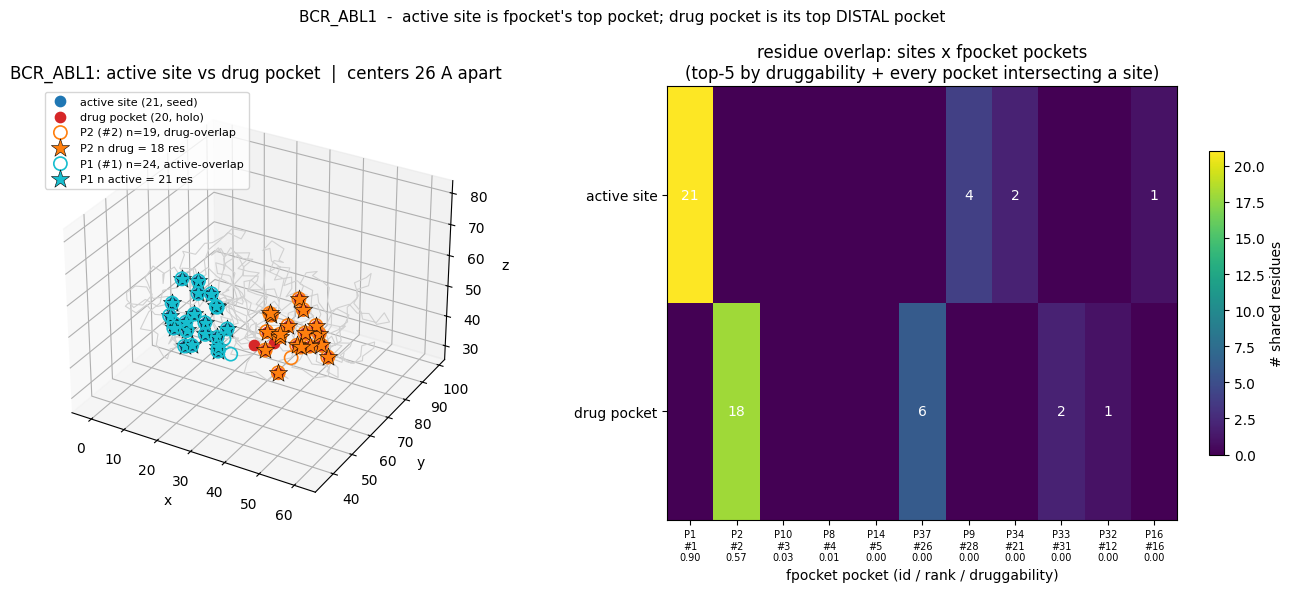

In [742]:
# ---- visualize: active site vs drug pocket, and fpocket overlap --------------
for name in ACTIVE:
    rec = EXTRACT[name]["apo"]; c = rec["coords"]
    r2i = NODE_INDEX[name]
    to_idx = lambda rs: [r2i[r] for r in rs if r in r2i]
    active = to_idx(ACTIVE_SITE.get(name, []))
    drug   = to_idx(DRUG_POCKET.get(name, {}).get("residues_apo", []))
    pk = CANDIDATE_POCKETS.get(name, [])   # sorted by fpocket druggability (best first)

    # ---- PRINTED SUMMARY: best fpocket pockets vs the two functional sites ----
    # (report-only: DRUG_POCKET/active site are shown here for QC, never fed to a predictor)
    aset, dset = set(active), set(drug)
    sep_txt = ("centres %.0f A apart" % np.linalg.norm(c[active].mean(0) - c[drug].mean(0))) if (active and drug) else "n/a"
    print("=== %s : best fpocket pockets vs functional sites ===" % name)
    print("    active site (apo) = %d res | drug pocket (holo) = %d res | %s | %d fpocket pockets total"
          % (len(active), len(drug), sep_txt, len(pk)))
    print("    %-4s %-6s %-6s %-5s %-9s %-8s  %s" % ("rank", "pocket", "drugg", "nres", "n_active", "n_drug", "verdict"))
    for rank, p in enumerate(pk[:10], 1):
        pidx = set(p["residues_idx"]); na = len(pidx & aset); nd = len(pidx & dset)
        if na >= 3 and na >= nd:
            verdict = "<- ACTIVE SITE (covers %d/%d of it)" % (na, len(active))
        elif nd >= 3:
            verdict = "<- DRUG POCKET (covers %d/%d of it)" % (nd, len(drug))
        else:
            verdict = "other cavity"
        print("    %-4d P%-5d %-6.3f %-5d %-9d %-8d  %s"
              % (rank, p["id"], p.get("drug", 0.0), len(pidx), na, nd, verdict))
    # ---- COVERAGE CHECK over ALL pockets (not just the top 10 shown above) ----
    # If NO fpocket pocket contains the drug pocket, the CTQW seed set can never contain it
    # either (seeds come from fpocket) -> P@5 is 0 BY CONSTRUCTION and the target is
    # unscoreable at pocket level. That is a property of the candidate generator, not of the walk.
    _nsp = globals().get("N_SEED_POCKETS", 5)      # sec 14 may not have run yet on a fresh kernel
    if dset and pk:
        cov = [(len(set(q["residues_idx"]) & dset), r, q["id"]) for r, q in enumerate(pk, 1)]
        best_nd, best_rank, best_id = max(cov)
        n_hit = sum(1 for nd_, _, _ in cov if nd_ > 0)
        if best_nd == 0:
            print("    !! DRUG POCKET NOT FOUND by fpocket: 0 of its %d residues appear in ANY of the %d "
                  "pockets -> CTQW seeds cannot contain it; pocket-level P@5 is 0 by construction." % (len(drug), len(pk)))
        else:
            print("    drug-pocket coverage: best = P%d (rank %d/%d by druggability, covers %d/%d residues, "
                  "drugg=%.3f); %d pocket(s) touch it at all%s"
                  % (best_id, best_rank, len(pk), best_nd, len(drug), pk[best_rank - 1].get("drug", 0.0), n_hit,
                     "" if best_rank <= _nsp else
                     "  !! rank %d > N_SEED_POCKETS=%d -> NOT in the CTQW seed set as configured" % (best_rank, _nsp)))
    print()

    fig = plt.figure(figsize=(14, 6))

    # --- (1) 3D: where the two sites are (distal separation) ---
    ax = fig.add_subplot(1, 2, 1, projection="3d")
    ax.plot(c[:, 0], c[:, 1], c[:, 2], color="0.82", lw=0.8, zorder=1)
    if active:
        A = c[active]
        ax.scatter(A[:, 0], A[:, 1], A[:, 2], color="tab:blue", s=55, depthshade=False,
                   label="active site (%d, seed)" % len(active))
    if drug:
        D = c[drug]
        ax.scatter(D[:, 0], D[:, 1], D[:, 2], color="tab:red", s=55, depthshade=False,
                   label="drug pocket (%d, holo)" % len(drug))
    # --- overlay the fpocket pockets that INTERSECT each functional site ---
    # hollow outline = the whole pocket; star = the residues it shares with the site.
    # Shows at a glance whether a detected cavity actually lands on the drug/active site.
    for _rs, _col, _lab in ((set(drug), "tab:orange", "drug"), (set(active), "tab:cyan", "active")):
        if not _rs or not pk:
            continue
        _b = max(pk, key=lambda q: len(set(q["residues_idx"]) & _rs))
        _inter = sorted(set(_b["residues_idx"]) & _rs)
        if not _inter:
            continue
        _rk = [r for r, q in enumerate(pk, 1) if q["id"] == _b["id"]][0]
        _P = c[sorted(i for i in _b["residues_idx"] if i < len(c))]
        ax.scatter(_P[:, 0], _P[:, 1], _P[:, 2], facecolors="none", edgecolors=_col, s=90, lw=1.2,
                   depthshade=False, label="P%d (#%d) n=%d, %s-overlap" % (_b["id"], _rk, len(_P), _lab))
        _I = c[_inter]
        ax.scatter(_I[:, 0], _I[:, 1], _I[:, 2], color=_col, marker="*", s=190, depthshade=False,
                   edgecolors="k", linewidths=0.4, label="P%d n %s = %d res" % (_b["id"], _lab, len(_inter)))

    sep = ""
    if active and drug:
        sep = "  |  centers %.0f A apart" % np.linalg.norm(c[active].mean(0) - c[drug].mean(0))
    ax.set_title("%s: active site vs drug pocket%s" % (name, sep))
    ax.legend(loc="upper left", fontsize=8)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")

    # --- (2) overlap heatmap: sites x top fpocket candidate pockets ---
    ax = fig.add_subplot(1, 2, 2)
    # columns = top-6 by druggability PLUS the pockets that actually cover each functional site
    # (otherwise, when the true pocket ranks low on druggability, this panel is all zeros and
    #  tells you nothing -- exactly the HIV1_RT case). Rank shown so low-ranked hits are visible.
    _rank = {q["id"]: r for r, q in enumerate(pk, 1)}
    _MAX_EXTRA = 8                                  # cap so the panel stays readable
    _cols = [q["id"] for q in pk[:5]]               # the top-5 by druggability, always shown
    _hits = [(len(set(q["residues_idx"]) & set(drug)), len(set(q["residues_idx"]) & set(active)), q["id"])
             for q in pk if (set(q["residues_idx"]) & (set(drug) | set(active)))]
    for _nd, _na, _qid in sorted(_hits, key=lambda t: -(t[0] + t[1]))[:_MAX_EXTRA]:
        if _qid not in _cols:                       # EVERY pocket intersecting a site, best first
            _cols.append(_qid)
    top = [q for cid in _cols for q in pk if q["id"] == cid]
    rows = [("active site", set(active)), ("drug pocket", set(drug))]
    M = np.array([[len(set(p["residues_idx"]) & rs) for p in top] for _, rs in rows], float)
    im = ax.imshow(M, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(top)))
    ax.set_xticklabels(["P%d\n#%d\n%.2f" % (p["id"], _rank[p["id"]], p.get("drug", 0.0)) for p in top], fontsize=7)
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels([r[0] for r in rows])
    for i in range(len(rows)):
        for j in range(len(top)):
            if M[i, j]:
                ax.text(j, i, int(M[i, j]), ha="center", va="center", color="w", fontsize=10)
    ax.set_title("residue overlap: sites x fpocket pockets\n(top-5 by druggability + every pocket intersecting a site)")
    ax.set_xlabel("fpocket pocket (id / rank / druggability)")
    fig.colorbar(im, ax=ax, shrink=0.7, label="# shared residues")

    fig.suptitle("%s  -  active site is fpocket's top pocket; drug pocket is its top DISTAL pocket" % name,
                 fontsize=11)
    fig.tight_layout()
    plt.show()

## 11 - Static 3D visualization (matplotlib) [GATED]

RENDER_3D controls whether this section runs. Set `RENDER_3D=True` in cell 1 to enable. When enabled: Cα backbone, active site (blue), drug pocket (red), fpocket alpha-sphere volumes (translucent), bound ligands with labels, structural metadata. A fallback PNG.

In [743]:
if RENDER_3D:
    print("§11 Static 3D visualization enabled (RENDER_3D=True).")
else:
    print("§11: Static 3D visualization DISABLED (RENDER_3D=False). Set RENDER_3D=True in cell 1 to enable.")

§11: Static 3D visualization DISABLED (RENDER_3D=False). Set RENDER_3D=True in cell 1 to enable.


## 12 - Interactive 3D viewers (py3Dmol) [GATED]

RENDER_3D controls whether this section runs. When enabled: three interactive HTML viewers per target (apo hero, holo, fpocket pockets), standalone `.html` files in `Downloads/viz3d/`. Fallback if browser blocks CDN.

In [744]:
if RENDER_3D:
    print("§12 Interactive 3D viewers enabled (RENDER_3D=True).")
else:
    print("§12: Interactive 3D viewers DISABLED (RENDER_3D=False). Set RENDER_3D=True in cell 1 to enable.")

§12: Interactive 3D viewers DISABLED (RENDER_3D=False). Set RENDER_3D=True in cell 1 to enable.


# Part II - Quantum solving: CTQW allosteric ranking (sections 13-21)

## 13 - Contact graph + Hamiltonian `H_new`

Operator selected **from the algorithm register** (bartosz branch), not invented: substrate **GNM** (register C, rated 5) + propagator **CTQW** (register D, rated 5). The concrete operator is **`H_new`** - the *main submission operator* in `src/allostery/hamiltonians.py` - the normalised Laplacian of the Ca-Ca contact graph plus five GNM-derived site potentials (`V_B,V_T,V_R,V_C,V_M`), **ported verbatim** from `hamiltonians.py`/`potentials.py`. The ablation `H_base` is the same graph with no potentials.

**All parameters are pre-registered here** (cutoff, alpha, lambdas, T, gamma), frozen before any walk and **never chosen using `DRUG_POCKET` or the resulting AUC**; the lambda defaults come from the repo's variance-budget argument. The network cutoff (~10 A Ca-Ca) is separate from `SITE_CUTOFF`. **`V_B` degeneracy check:** 5TBY's B-factors are a ~2 A homology-model flatline, so `V_B` is detected as unreliable and **dropped** for myosin (reported, not silently used).

The full operator set for the section-20 benchmark is assembled here: **H1-H10** (connectivity-only H1-H8; B-factor H9,H10) **+ H_new** - all ported from `hamiltonians.py`. Protein selection is the `*_ONLY` / `ALL_PROTEINS` flags in cell 1 (one at a time, or all).

In [745]:
# ===========================================================================
# 13 - Contact graph + Hamiltonian H_new  (ported, not invented)
# ---------------------------------------------------------------------------
# Operator selected FROM the algorithm register (Oussema-t/Quantum_allosteric-
# scanner, bartosz): substrate = GNM (register C, rated 5); propagator = CTQW
# (register D, rated 5). The concrete operator is `H_new` = "the main submission
# operator" in src/allostery/hamiltonians.py, the only one carrying the five
# GNM-derived site potentials. Ported VERBATIM from hamiltonians.py + potentials.py
# (CLAUDE.md convention: port the research code, cite it, do not reinvent).
#
# PRE-REGISTERED parameters (frozen BEFORE any walk; never chosen using DRUG_POCKET or
# the AUC). Lambdas come from the TASK-0121 variance budget sigma(V) <= 0.2*J, not a fit.
# NET_CUTOFF (the Ca-Ca network cutoff) is set BY HAND IN CELL 1, alongside SITE_CUTOFF --
# this section just uses it. (It is separate from SITE_CUTOFF = ligand proximity, sec 5/6.)
ALPHA      = 0.3         # exponential edge-weight decay exp(-alpha*d)  (build_H_new default)
LAMBDAS    = dict(B=0.08, T=0.16, R=0.08, C=0.04, M=0.04)   # site-potential weights (variance budget)
TERM_FRAC  = 0.05        # fraction of N-/C-terminal residues penalised by V_T
N_LOW_MODES = 10         # slow GNM modes used by V_M

print("PRE-REGISTERED (frozen before any walk):")
print("  NET_CUTOFF=%.1f A (from cell 1)  ALPHA=%.2f  lambdas(B,T,R,C,M)=%s  term_frac=%.2f  n_low_modes=%d"
      % (NET_CUTOFF, ALPHA, tuple(LAMBDAS.values()), TERM_FRAC, N_LOW_MODES))
print("  (SITE_CUTOFF=%.1f A is separate: ligand proximity, sec 5/6.)" % SITE_CUTOFF)


# ---- graph builders (ported: hamiltonians.contact_matrix / laplacian) -------
def contact_matrix(coords, cutoff=NET_CUTOFF, weight="binary", sigma=6.0, alpha=ALPHA):
    diff = coords[:, None, :] - coords[None, :, :]
    dist = np.sqrt((diff ** 2).sum(2))
    mask = (dist < cutoff) & (dist > 0)
    if weight == "binary":
        W = mask.astype(float)
    elif weight == "gaussian":
        W = np.exp(-(dist ** 2) / (2 * sigma ** 2)) * mask
    elif weight == "exponential":
        W = np.exp(-alpha * dist) * mask
    else:
        raise ValueError(weight)
    return W


def laplacian(W, normalised=False):
    D = np.diag(W.sum(1))
    L = D - W
    if not normalised:
        return L
    deg = W.sum(1)
    dis = np.where(deg > 0, 1.0 / np.sqrt(deg), 0.0)
    Di = np.diag(dis)
    return Di @ L @ Di


def normalised_laplacian_alpha(coords, cutoff=NET_CUTOFF, alpha=ALPHA):
    return laplacian(contact_matrix(coords, cutoff, "exponential", alpha=alpha), normalised=True)


# ---- GNM-derived site potentials (ported: potentials.py) --------------------
def _zscore(x):
    return (x - x.mean()) / (x.std() + 1e-9)


def _kirchhoff_eigh(coords, cutoff):
    A = contact_matrix(coords, cutoff, "binary")
    K = laplacian(A)
    w, U = np.linalg.eigh(K)
    nz = w > 1e-9
    winv = np.where(nz, 1.0 / np.where(nz, w, 1.0), 0.0)
    return A, w, U, nz, winv


def _gnm_msf(coords, cutoff):
    _A, _w, U, _nz, winv = _kirchhoff_eigh(coords, cutoff)
    return np.diag((U * winv) @ U.T)


def V_B(bfactors):
    return _zscore(bfactors.astype(float))


def V_T(n, term_frac=TERM_FRAC):
    k = max(1, int(n * term_frac))
    m = np.zeros(n); m[:k] = 1.0; m[-k:] = 1.0
    return _zscore(m)


def V_R(coords, cutoff=NET_CUTOFF):
    A = contact_matrix(coords, cutoff, "binary")
    deg = A.sum(1)
    tri = np.diag(A @ (A @ A))
    clust = tri / np.maximum(deg * (deg - 1), 1.0)
    msf = _gnm_msf(coords, cutoff)
    return _zscore(-(_zscore(deg) + _zscore(clust) - _zscore(msf)))


def V_C(coords, cutoff=NET_CUTOFF):
    _A, _w, U, _nz, winv = _kirchhoff_eigh(coords, cutoff)
    Cov = (U * winv) @ U.T
    d = np.sqrt(np.clip(np.diag(Cov), 1e-12, None))
    nDCC = Cov / np.outer(d, d)
    np.fill_diagonal(nDCC, 0.0)
    return -_zscore(np.abs(nDCC).sum(1))


def V_M(coords, cutoff=NET_CUTOFF, n_modes=N_LOW_MODES):
    _A, w, v, _nz, _winv = _kirchhoff_eigh(coords, cutoff)
    i0 = max(1, int(np.searchsorted(w, 1e-8)))
    low = v[:, i0:i0 + n_modes]
    return -_zscore((low ** 2).mean(1))


def build_H_new(coords, bfactors, cutoff=NET_CUTOFF, alpha=ALPHA, lam=LAMBDAS,
                term_frac=TERM_FRAC, n_low_modes=N_LOW_MODES, apply_VB=True):
    L = normalised_laplacian_alpha(coords, cutoff, alpha)
    vb = lam["B"] * V_B(bfactors) if apply_VB else np.zeros(len(coords))
    diag = (vb + lam["T"] * V_T(len(coords), term_frac) + lam["R"] * V_R(coords, cutoff)
            + lam["C"] * V_C(coords, cutoff) + lam["M"] * V_M(coords, cutoff, n_low_modes))
    return L + np.diag(diag), diag


# ---- register operators H1-H10 (ported from hamiltonians.py) for the benchmark --
# "connectivity-only" family (topology; no B-factors, no potentials): H1,H2,H3,H4,H5,H6,H7,H8.
# "B-factor" family: H9,H10.  "full": H_new.  All are real-symmetric -> valid CTQW generators.
def H1_adjacency(coords, cutoff=NET_CUTOFF):        return contact_matrix(coords, cutoff, "binary")
def H2_combinatorial(coords, cutoff=NET_CUTOFF):    return laplacian(contact_matrix(coords, cutoff, "binary"))
def H3_normalised(coords, cutoff=NET_CUTOFF):       return laplacian(contact_matrix(coords, cutoff, "binary"), normalised=True)
def H5_gaussian(coords, cutoff=NET_CUTOFF, sigma=6.0):
    return laplacian(contact_matrix(coords, cutoff, "gaussian", sigma=sigma))
def H6_exponential(coords, cutoff=12.0, alpha=ALPHA):
    return laplacian(contact_matrix(coords, cutoff, "exponential", alpha=alpha))
def H8_gnm(coords, cutoff=7.5):                     return laplacian(contact_matrix(coords, cutoff, "binary"))
def H4_powered(coords, cutoff=NET_CUTOFF, beta=1.0):
    w, v = np.linalg.eigh(H3_normalised(coords, cutoff))
    return (v * (np.abs(w) ** beta * np.sign(w))) @ v.T
def H7_harmonic(coords, cutoff=NET_CUTOFF, eps=0.5):
    diff = coords[:, None, :] - coords[None, :, :]; dist = np.sqrt((diff ** 2).sum(2))
    mask = (dist < cutoff) & (dist > 0)
    return laplacian((1.0 / (dist + eps) ** 2) * mask)
def H9_bfactor(coords, bfactors, cutoff=NET_CUTOFF):
    bn = bfactors / (bfactors.mean() + 1e-9); Bi = np.diag(1.0 / (bn + 1e-3))
    return Bi @ laplacian(contact_matrix(coords, cutoff, "binary")) @ Bi
def H10_disorder(coords, bfactors, cutoff=NET_CUTOFF, lam_T=2.0, lam_F=1.5, term_frac=TERM_FRAC):
    L = H2_combinatorial(coords, cutoff); N = len(coords); bn = bfactors / (bfactors.mean() + 1e-9)
    k = max(1, int(N * term_frac)); tm = np.zeros(N); tm[:k] = 1.0; tm[-k:] = 1.0
    return L + np.diag(lam_T * bn) + np.diag(lam_F * tm)

# ---- ANM / mechanical operators, ported from the bartosz branch (hamiltonians.py) ----
# Ported, not reinvented. H11/H12 are notebook-faithful ports; H14 is a repo-original
# ANM-covariance extension. H13 (the raw 3N x 3N Hessian) is NOT a walk operator here --
# it lives on 3N Cartesian DOFs, not the N residue nodes the walk/qubit encoding uses --
# so it is exposed only as H14's internal helper.
def H11_aniso(coords, cutoff=NET_CUTOFF, alpha=0.3):
    """Exponential x inverse-square edge weighting (sharper falloff than H6 alone).
    NB: despite the upstream name, this formula carries no orientation vector."""
    diff = coords[:, None, :] - coords[None, :, :]; dist = np.sqrt((diff ** 2).sum(2))
    mask = (dist < cutoff) & (dist > 0)
    return laplacian(mask * np.exp(-alpha * dist) * (1.0 / (dist ** 2 + 1e-2)))

def H12_anm_scal(coords, cutoff=NET_CUTOFF):
    """Local anisotropy: weight each edge by |unit(i->j) . dominant local axis of i|
    (axis = first right-singular vector of i's neighbour displacements). <3 contacts -> 0."""
    N = len(coords); diff = coords[:, None, :] - coords[None, :, :]
    dist = np.sqrt((diff ** 2).sum(2)); T = ((dist < cutoff) & (dist > 0)).astype(float)
    unit = diff / (dist[..., None] + 1e-12); coup = np.zeros((N, N))
    for i in range(N):
        nb = np.where(T[i] > 0)[0]
        if len(nb) < 3: continue
        _, _, Vt = np.linalg.svd(diff[i, nb], full_matrices=False)
        coup[i, nb] = np.abs(unit[i, nb] @ Vt[0])
    return laplacian(0.5 * (coup + coup.T))

def _anm_hessian_3N(coords, cutoff=NET_CUTOFF):
    """Full 3N x 3N ANM Hessian (Kirchhoff + orientational coupling). Vectorised form,
    verified numerically identical to the upstream double-loop implementation."""
    N = len(coords); diff = coords[:, None, :] - coords[None, :, :]
    dist = np.sqrt((diff ** 2).sum(2)); mask = (dist < cutoff) & (dist > 0)
    r = diff / (dist[..., None] + 1e-300)
    P = np.einsum("ija,ijb->ijab", r, r) * mask[..., None, None]
    B = -P; _ix = np.arange(N); B[_ix, _ix] = P.sum(axis=1)
    return B.transpose(0, 2, 1, 3).reshape(3 * N, 3 * N)

def H14_anm_pinv(coords, cutoff=NET_CUTOFF):
    """Global ANM cross-correlation: pseudo-invert the 3N Hessian and take the trace of
    each 3x3 residue-pair block (Bahar/Atilgan ANM covariance). Can couple NON-contacting
    residues (mechanical, not geometric). O((3N)^3) eigendecomposition -- the expensive one."""
    N = len(coords); Hh = _anm_hessian_3N(coords, cutoff)
    w, v = np.linalg.eigh(Hh)
    tol = 1e-8 * max(np.abs(w).max(), 1.0); nz = w > tol         # drop rigid-body zero modes
    Hpinv = (v * np.where(nz, 1.0 / np.where(nz, w, 1.0), 0.0)) @ v.T
    W = np.abs(np.einsum("ikjk->ij", Hpinv.reshape(N, 3, N, 3)))
    np.fill_diagonal(W, 0.0)
    return laplacian(W)

OP_FAMILY = {"H1_adj": "conn", "H2_combL": "conn", "H3_normL": "conn", "H4_powL": "conn",
             "H5_gauss": "conn", "H6_exp": "conn", "H7_harm": "conn", "H8_gnm": "conn",
             "H9_bfac": "bfac", "H10_disorder": "bfac",
             "H11_aniso": "mech", "H12_anmS": "anm", "H14_anmP": "anm", "H_new": "full"}


# ---- build per-target: graph, H_new, and the H_base ablation (all lambda=0) --
GRAPH = {}   # name -> dict(coords, W, L, degree, H, H_base, diag, gap, bdegen, apply_VB)
for name in ACTIVE:
    rec = EXTRACT[name]["apo"]; coords = rec["coords"]; bf = rec["bfac"]; N = rec["n"]

    # B-factor sanity: V_B degenerates if B is (near-)constant, and is UNRELIABLE if B
    # is non-physical (homology-model flatline, e.g. 5TBY ~ 2). Detect + report; if so,
    # H_new is built WITHOUT V_B for that target rather than silently using noise.
    bstd = float(bf.std()); bmean = float(bf.mean())
    near_const = bstd < 1e-3 or bstd / (abs(bmean) + 1e-9) < 1e-3
    nonphysical = bmean < 5.0                      # real crystallographic B ~ 15-80
    bdegen = near_const or nonphysical
    apply_VB = not bdegen

    W = contact_matrix(coords, NET_CUTOFF, "exponential", alpha=ALPHA)
    L = laplacian(W, normalised=True)
    H, diag = build_H_new(coords, bf, apply_VB=apply_VB)
    H_base = normalised_laplacian_alpha(coords)          # ablation: same graph, no potentials

    assert np.allclose(H, H.T, atol=1e-9), "%s: H not symmetric" % name
    wl = np.linalg.eigvalsh(L)
    assert wl.min() > -1e-8 and wl.max() < 2 + 1e-6, "%s: normalised-L spectrum out of [0,2]" % name

    wH = np.linalg.eigvalsh(H)
    gap = float(np.sort(wH)[1] - wH.min())               # spectral gap of H (sets mixing time in sec 14)
    GRAPH[name] = dict(coords=coords, W=W, L=L, degree=W.sum(1), H=H, H_base=H_base,
                       diag=diag, gap=gap, bdegen=bdegen, apply_VB=apply_VB,
                       lam1=float(np.abs(wH).max()))

    vb_share = (LAMBDAS["B"] ** 2 * V_B(bf).var()) / (diag.var() + 1e-12) if apply_VB else 0.0
    edges = int((W > 0).sum() // 2)
    print("=== %s  N=%d  edges=%d (cutoff %.1f A) ===" % (name, N, edges, NET_CUTOFF))
    print("    B: mean=%.2f std=%.2f -> V_B %s%s | spectral gap(H)=%.4f  |lambda|max=%.3f"
          % (bmean, bstd, "APPLIED" if apply_VB else "DROPPED",
             "" if apply_VB else " [degenerate/non-physical B: 5TBY-style homology model]",
             gap, GRAPH[name]["lam1"]))

# ---- assemble the operator set (H1-H12, H14 + H_new) -------------------------
ANM_PINV_MAX_N = 600     # H14 does a (3N x 3N) eigendecomposition -> skip above this N
OPS = {}
for name in ACTIVE:
    rec = EXTRACT[name]["apo"]; c = rec["coords"]; bf = rec["bfac"]
    OPS[name] = {
        "H1_adj": H1_adjacency(c), "H2_combL": H2_combinatorial(c), "H3_normL": H3_normalised(c),
        "H4_powL": H4_powered(c), "H5_gauss": H5_gaussian(c), "H6_exp": H6_exponential(c),
        "H7_harm": H7_harmonic(c), "H8_gnm": H8_gnm(c),
        "H9_bfac": H9_bfactor(c, bf), "H10_disorder": H10_disorder(c, bf),
        "H11_aniso": H11_aniso(c), "H12_anmS": H12_anm_scal(c),
        "H_new": GRAPH[name]["H"],
    }
    if len(c) <= ANM_PINV_MAX_N:                       # H14 = O((3N)^3) eigendecomposition
        OPS[name]["H14_anmP"] = H14_anm_pinv(c)
    else:
        print("  [%s] H14_anmP skipped: N=%d > ANM_PINV_MAX_N=%d (3N x 3N eigh too costly)"
              % (name, len(c), ANM_PINV_MAX_N))
print("Operator set for the sec-20 benchmark (per target): %s" % list(next(iter(OPS.values())).keys()))
print("  families: connectivity-only=H1..H8, B-factor=H9/H10, full=H_new "
      "(on targets with V_B dropped, H9/H10 reduce toward the plain Laplacian).")

PRE-REGISTERED (frozen before any walk):
  NET_CUTOFF=10.0 A (from cell 1)  ALPHA=0.30  lambdas(B,T,R,C,M)=(0.08, 0.16, 0.08, 0.04, 0.04)  term_frac=0.05  n_low_modes=10
  (SITE_CUTOFF=4.5 A is separate: ligand proximity, sec 5/6.)
=== BCR_ABL1  N=451  edges=3904 (cutoff 10.0 A) ===
    B: mean=81.75 std=33.78 -> V_B APPLIED | spectral gap(H)=0.0599  |lambda|max=2.128
Operator set for the sec-20 benchmark (per target): ['H1_adj', 'H2_combL', 'H3_normL', 'H4_powL', 'H5_gauss', 'H6_exp', 'H7_harm', 'H8_gnm', 'H9_bfac', 'H10_disorder', 'H11_aniso', 'H12_anmS', 'H_new', 'H14_anmP']
  families: connectivity-only=H1..H8, B-factor=H9/H10, full=H_new (on targets with V_B dropped, H9/H10 reduce toward the plain Laplacian).


## 13z - Seed selection: which pockets the walk starts from

**Every seed decision lives in the cell below.** Section 7b only *measures* pockets; this cell
*chooses* them and hands section 14 a finished seed set.

| tool | what it measures | used here as |
|---|---|---|
| **fpocket** | cavity geometry -> druggability score | is it a real, druggable pocket? |
| **PASSer** | supervised classifier trained on the ASD | is it an *allosteric* pocket? |
| **PocketMiner** | per-residue cryptic-opening GNN | can a drug get in at all? |

### The knobs

- **`SEED_SOURCE`** - which set seeds the walk
  - `"fpocket"` top-`N_SEED_POCKETS` by druggability (PASSer/PocketMiner ignored)
  - `"consensus"` druggable **and** allosteric
  - `"threeway"` + accessible
- **`SEED_TOP_K`** - how many pockets each tool nominates
- **`SEED_COMBINE`** - how the two rankings merge
  - `"minrank"` a pocket is only as good as its **worse** rank (strict)
  - `"rrf"` `1/(60+rk_fp) + 1/(60+rk_pa)` - forgives one weak rank
  - `"both"` plain intersection of the two top-K lists
- **`SEED_PM_STATES`** - what counts as accessible. Only `no-open` is excluded, so a pocket
  that is **already open** qualifies. This matters: BCR-ABL1's myristoyl pocket has myristate
  bound in the apo, so PocketMiner correctly scores it *low* on cryptic-ness - ranking by
  cryptic-ness would throw the true pocket away.
- **`MIN_HOP`** - drop seeds closer than this many graph-hops to the active site, so the walk
  is not simply rewarded for starting next to its own target.

### What to read in the output

Every pocket is printed with its druggability, PASSer rank, PocketMiner state, distance and
drug-pocket overlap, and whether it was kept. Two lines below the table matter most:

- **`base rate`** - the fraction of seeds already inside the drug pocket. A random pick scores
  this much, so AUC and P@5 must beat it to mean anything.
- **`TRUE pocket is NOT seeded`** - if this appears, section 14's P@5 is **0 by construction**
  and no operator, propagator or score can recover it. Widen the set before reading a null
  result as a failure of the method.


In [746]:
# ---- 13z. SEED SELECTION -- ALL seed knobs live here; sec 7b only MEASURES ----------------
# Division of labour:
#   sec 7b  MEASURES every pocket: fpocket druggability, PASSer allostery rank/probability,
#           PocketMiner accessibility state. It selects nothing that matters downstream.
#   THIS CELL DECIDES: it reads those measurements, applies the rules below, and hands
#           section 14 a finished seed set. Section 14 no longer defines any seed knob.
# Knobs are SEED_*-prefixed so they cannot be confused with sec 7b's own diagnostic settings.
SEED_TOP_K       = 10          # how many each tool nominates (druggability / allostery)
# The three signals are NOT equally reliable. fpocket and PASSer look at the pocket that is
# there; PocketMiner PREDICTS a future conformational change and is ~0.87 AUC, so it is wrong
# on a real fraction of targets -- CARDIAC_MYOSIN's true pocket P96 is ranked #3 druggable and
# #3 allosteric, yet PocketMiner calls it "no-open" (accessibility rank #65). Under "minrank"
# that single wrong axis discards the right answer. Weights let the least reliable signal
# count for less; "minrank" ignores them by construction (it is a max, not a sum), so use
# "rrf" whenever a weight is not 1.0.
SEED_WEIGHTS     = (1.0, 1.0, 0.5)   # (druggability, allostery, accessibility) -- "rrf" only
SEED_COMBINE     = "rrf"       # how the rankings combine, for source="consensus":
                               #   "minrank" a pocket is only as good as its WORSE rank (strict)
                               #   "rrf"     1/(60+rk_fp)+1/(60+rk_pa) -- forgives one weak rank
                               #   "both"    plain intersection of the two top-K lists
SEED_PM_STATES   = ("OPEN(lig)", "CRYPTIC", "mixed")   # accessible = can a drug get in at all;
                               # only "no-open" (predicted to stay shut) is excluded. An ALREADY
                               # OPEN pocket qualifies -- BCR-ABL1's myristoyl pocket is one.
SEED_SOURCE      = "fpocket"    # "fpocket"   top-N_SEED_POCKETS by druggability
                               # "consensus" druggable AND allosteric (2 ranks)
                               # "threeway"  those two, then DROP inaccessible (pass/fail)
                               # "triple"    rank on ALL THREE at once: druggability,
                               #             allostery, and ACCESSIBILITY -- the pockets that
                               #             are most druggable, most allosteric, AND either
                               #             already open or most likely to open
N_SEED_POCKETS   = 43          # only used by source="fpocket"
# MIN_HOP is NOT set here -- it belongs to the walk, not to pocket selection, so section 14
# owns it. This cell selects POCKETS and previews how many residues survive at each hop cut.
SEED_ROWS        = 0           # pocket rows to print: 0 = ALL

SEED_POCKET_SET = {}   # name -> [pocket ids] finally seeded
FINAL_SEEDS     = {}   # name -> [residue numbers] of the selected pockets (NO hop filter)

for name in ACTIVE:
    _fp = CANDIDATE_POCKETS.get(name, [])
    if not _fp:
        print("=== %s : no fpocket pockets -> nothing to seed ===" % name); continue
    rec = EXTRACT[name]["apo"]; coords = rec["coords"]
    ca = {int(r): c for r, c in zip(rec["resseq"].tolist(), coords)}
    r2i = {int(r): i for i, r in enumerate(rec["resseq"].tolist())}
    active = [r for r in ACTIVE_SITE.get(name, []) if r in ca]
    drugset = set(DRUG_POCKET.get(name, {}).get("residues_apo", []))
    if not active:
        print("=== %s : no active site -> cannot apply MIN_HOP ===" % name); continue
    d2 = ((coords[:, None, :] - coords[None, :, :]) ** 2).sum(-1)
    G = _nx.from_numpy_array(((d2 < NET_CUTOFF ** 2) & (d2 > 0)).astype(int))
    hop = {}
    for r in active:
        for n_, h in _nx.single_source_shortest_path_length(G, r2i[r]).items():
            hop[n_] = min(hop.get(n_, 10 ** 9), h)

    # ---------- the three measurements, straight from sec 7b ----------
    _rk_fp = {q["id"]: k + 1 for k, q in enumerate(_fp)}            # _fp is druggability-sorted
    _pmap  = (globals().get("PASSER_PAIR_MAP") or {}).get(name, {})  # id -> (rank, prob, J)
    _rk_pa = {pid: v[0] for pid, v in _pmap.items()}
    _pmrow = {r["id"]: r for r in ((globals().get("POCKETMINER") or {}).get(name, {}) or {}).get("rows", [])}
    _dist  = {r["id"]: r for r in (globals().get("POCKET_DISTANCE") or {}).get(name, [])}

    # ---------- the decision ----------
    _both = [pid for pid in _rk_fp if pid in _rk_pa]
    # ---------- accessibility as a SCORE, so it can be ranked rather than only filtered ------
    # "open" and "most likely to open" must BOTH score high, so an already-open pocket is not
    # punished for having nothing left to open. OPEN(lig) is certainty -- a ligand is sitting
    # in it -- so it takes the top of the scale; everything else uses its calibrated cryptic
    # percentile; a pocket predicted to stay shut sits at the bottom.
    def _access(pid):
        r = _pmrow.get(pid)
        if not r: return None
        if r.get("state") == "OPEN(lig)": return 1.0          # open now = maximally accessible
        if r.get("state") == "no-open":   return 0.0          # predicted to stay closed
        p = r.get("pm_pct")
        return float(p) if p is not None else 0.5
    _acc = {pid: _access(pid) for pid in _rk_fp}
    _have_acc = [p for p, v in _acc.items() if v is not None]
    _rk_ac = {pid: k + 1 for k, pid in enumerate(
        sorted(_have_acc, key=lambda q: -_acc[q]))}            # rank 1 = most accessible
    def _key(pid):
        a, b = _rk_fp[pid], _rk_pa[pid]
        if SEED_COMBINE == "rrf": return -(1.0 / (60 + a) + 1.0 / (60 + b))
        return (max(a, b), a + b)                                   # minrank (default)
    if SEED_SOURCE == "triple":
        _tri = [p for p in _both if p in _rk_ac]
        if not _tri:
            print("    !! %s : no PocketMiner data -> 'triple' cannot rank accessibility."
                  " Run sec 7b's PocketMiner block, or use SEED_SOURCE='consensus'." % name)
            _cand = []
        else:
            _w = tuple(SEED_WEIGHTS) + (1.0,) * (3 - len(SEED_WEIGHTS))
            def _key3(pid):
                a, b, c = _rk_fp[pid], _rk_pa[pid], _rk_ac[pid]
                if SEED_COMBINE == "rrf":
                    return -(_w[0] / (60 + a) + _w[1] / (60 + b) + _w[2] / (60 + c))
                return (max(a, b, c), a + b + c)               # minrank: a max, weights N/A
            _cand = sorted(_tri, key=_key3)[:SEED_TOP_K]
        _how = ("top-%d by %s over THREE ranks: druggability, allostery, accessibility"
                " (open now OR most likely to open)" % (SEED_TOP_K, SEED_COMBINE))
    elif SEED_SOURCE == "fpocket":
        _cand = [q["id"] for q in _fp[:N_SEED_POCKETS]]
        _how = "top-%d fpocket pockets by druggability (PASSer/PocketMiner not consulted)" % N_SEED_POCKETS
    else:
        if SEED_COMBINE == "both":
            _cand = sorted(set(list(_rk_fp)[:SEED_TOP_K]) &
                           {p for p in _rk_pa if _rk_pa[p] <= SEED_TOP_K})
            _how = "in BOTH top-%d lists (druggability AND allostery)" % SEED_TOP_K
        else:
            _cand = sorted(_both, key=_key)[:SEED_TOP_K]
            _how = "top-%d by %s over druggability rank + allostery rank" % (SEED_TOP_K, SEED_COMBINE)
        if SEED_SOURCE == "threeway":
            _before = list(_cand)
            _cand = [p for p in _cand if (_pmrow.get(p) or {}).get("state") in SEED_PM_STATES]
            _how += " AND accessible %s" % (tuple(SEED_PM_STATES),)
            if not _pmrow:
                print("    !! %s : no PocketMiner rows -> 'threeway' cannot filter; run sec 7b's"
                      " PocketMiner block or use SEED_SOURCE='consensus'." % name)
            elif len(_cand) < len(_before):
                print("    (PocketMiner removed %d pocket(s) predicted to stay closed: %s)"
                      % (len(_before) - len(_cand), [p for p in _before if p not in _cand]))

    _true = None
    if drugset:
        _byid = {q["id"]: set(q["residues"]) for q in _fp}
        _t = max(_byid, key=lambda k: len(_byid[k] & drugset))
        if _byid[_t] & drugset: _true = _t

    print("=== %s : SEED SELECTION | source=%s | %s ===" % (name, SEED_SOURCE, _how))
    print("    %-6s %-6s %-5s %-6s %-7s %-6s %-5s %-10s %-4s %-8s %-6s %-6s %s"
          % ("pkt", "drugg", "fpRk", "PASSrk", "PASSp%", "PMpct", "accRk", "state", "n",
             "dCen[A]", "hopMn", "ovDrug", "kept"))
    _kept = []
    _rows_out = []
    for q in _fp:
        pid = q["id"]; pres = [r for r in q["residues"] if r in ca]
        if not pres: continue
        _in = pid in _cand
        # This cell selects POCKETS; it deliberately does NOT apply MIN_HOP (section 14 owns
        # that). Filtering here would make `kept` depend on a variable this cell no longer
        # defines -- silently reusing a stale value from a previous section-14 run.
        _keep = _in
        if _keep: _kept.append(pid)
        _pr = _pmap.get(pid); _pm = _pmrow.get(pid); _dd = _dist.get(pid)
        _ovd = len(set(pres) & drugset)
        _tag = "YES" if _keep else "-"
        if _true == pid: _tag += "   <- TRUE pocket"
        _rows_out.append((not _in, _rk_fp.get(pid, 999), pid, q.get("drug", 0.0),
                          _pr[0] if _pr else None, _pr[1] if _pr else None,
                          (_pm or {}).get("pm_pct"), (_pm or {}).get("state", "-"), len(pres),
                          (_dd or {}).get("d_center"),
                          min((hop.get(r2i[r], 99) for r in pres), default=99), _ovd,
                          (_ovd / len(drugset)) if drugset else 0.0, _tag))
    _rows_out.sort()
    for (_o, fr, pid, dg, pk_, pp, pmp, st, n_, dc, hm, ovd, fd, tag) in (
            _rows_out if SEED_ROWS <= 0 else _rows_out[:SEED_ROWS]):
        print("    P%-5d %-6.3f #%-4d %-6s %-7s %-6s %-5s %-10s %-4d %-8s %-6d %-6d %s"
              % (pid, dg, fr, ("#%d" % pk_) if pk_ else "-", ("%.1f" % pp) if pp else "-",
                 ("%.2f" % pmp) if pmp is not None else "-",
                 ("#%d" % _rk_ac[pid]) if pid in _rk_ac else "-", st, n_,
                 ("%.1f" % dc) if dc is not None else "-", hm, ovd, tag))
    _all_res = sorted({r for q in _fp if q["id"] in _kept for r in q["residues"] if r in ca})
    SEED_POCKET_SET[name] = _kept
    FINAL_SEEDS[name] = _all_res          # unfiltered; section 14 applies its own MIN_HOP
    print("    >>> SEEDS: %d pockets %s -> %d residues before any hop filter"
          % (len(_kept), _kept[:14], len(_all_res)))
    # PREVIEW of section 14's MIN_HOP, so the cost of each cut is visible before the walk runs.
    # A high base rate means seeds already sit in the drug pocket and P@5 is nearly free; a
    # cut that leaves 0 drug seeds makes AUC/P@5 unable to beat chance whatever the operator.
    print("        %-9s %-10s %-10s %s" % ("MIN_HOP", "seeds", "in drug", "base rate"))
    for _mh in (1, 2, 3, 4):
        _sr = [r for r in _all_res if hop.get(r2i[r], 99) >= _mh]
        _nd2 = len(set(_sr) & drugset)
        _mark = ("  <- section 14 currently uses this"
                 if _mh == globals().get("MIN_HOP", None) else "")
        print("        %-9d %-10d %-10d %s%s"
              % (_mh, len(_sr), _nd2,
                 ("%.2f" % (_nd2 / len(_sr))) if _sr else "-", _mark))
    _seed_res = _all_res; _nd = len(set(_all_res) & drugset)
    if _true is not None and _true not in _kept:
        print("        !! TRUE pocket P%d is NOT seeded -> sec 14's P@5 is 0 BY CONSTRUCTION." % _true)
        _ra = {"druggability": _rk_fp.get(_true), "allostery": _rk_pa.get(_true),
               "accessibility": _rk_ac.get(_true)}
        # Only blame axes this mode actually CONSULTS. In "fpocket" mode accessibility is not
        # used at all, so reporting it as the cause (merely because it is the numerically worst
        # rank) sends you to tune a knob that had no effect on the decision.
        _used = {"fpocket": ["druggability"],
                 "consensus": ["druggability", "allostery"],
                 "threeway": ["druggability", "allostery", "accessibility"],
                 "triple": ["druggability", "allostery", "accessibility"]}.get(
                     SEED_SOURCE, list(_ra))
        _known = {k2: v2 for k2, v2 in _ra.items() if v2 and k2 in _used}
        _other = {k2: v2 for k2, v2 in _ra.items() if v2 and k2 not in _used}
        if _known:
            _worst = max(_known, key=lambda k2: _known[k2])
            print("           ranks THIS MODE uses: %s"
                  % ", ".join("%s #%d" % kv for kv in _known.items()))
            if _other:
                print("           (not used by source='%s': %s)"
                      % (SEED_SOURCE, ", ".join("%s #%d" % kv for kv in _other.items())))
            print("           the axis that sank it: %s (#%d). %s"
                  % (_worst, _known[_worst],
                     "PocketMiner PREDICTS opening and is wrong on a real fraction of targets --"
                     " lower SEED_WEIGHTS[2] or drop to SEED_SOURCE='consensus'."
                     if _worst == "accessibility" else
                     ("raise N_SEED_POCKETS above #%d, or use a source that also weighs"
                      " allostery/accessibility." % _known[_worst])
                     if SEED_SOURCE == "fpocket" else
                     "widen SEED_TOP_K, or use SEED_COMBINE='rrf' so one weak axis does not veto."))
        if SEED_COMBINE == "minrank":
            print("           NOTE: 'minrank' judges a pocket by its WORST axis, so a single"
                  " wrong signal vetoes it. 'rrf' averages instead.")
    elif drugset and _nd == 0:
        print("        !! no seed lies in the drug pocket -> AUC/P@5 cannot beat chance.")
    print()
# sec 14 reads these names; keep them in sync so nothing downstream has to change
PASSER_FPOCKET_MATCH = {n: {p: 1.0 for p in ids} for n, ids in SEED_POCKET_SET.items()}
SEED_FROM_PASSER_OVERLAP = (SEED_SOURCE != "fpocket")
print(">>> SEED_POCKET_SET / FINAL_SEEDS exported -- section 14 consumes these.")


=== BCR_ABL1 : SEED SELECTION | source=fpocket | top-43 fpocket pockets by druggability (PASSer/PocketMiner not consulted) ===
    pkt    drugg  fpRk  PASSrk PASSp%  PMpct  accRk state      n    dCen[A]  hopMn  ovDrug kept
    P1     0.899  #1    #1     89.6    1.00   #1    OPEN(lig)  24   1.4      0      0      YES
    P2     0.566  #2    #2     83.1    0.00   #2    OPEN(lig)  19   26.8     2      18     YES   <- TRUE pocket
    P10    0.029  #3    #6     29.8    0.60   #21   mixed      9    16.3     1      0      YES
    P8     0.005  #4    #15    10.1    0.00   #29   no-open    12   24.8     2      0      YES
    P14    0.004  #5    #13    10.9    0.89   #15   mixed      11   19.0     1      0      YES
    P7     0.003  #6    #18    9.0     0.38   #23   mixed      7    29.5     3      0      YES
    P5     0.002  #7    #11    13.6    0.14   #3    OPEN(lig)  13   23.1     1      0      YES
    P25    0.001  #8    #32    5.4     0.00   #30   no-open    7    27.0     2      0      YES


## 14 - CTQW, unitary (no dephasing): seeded one residue at a time from the top fpocket pockets

**This is the fpocket-seeded quantum-walk scan.** The CTQW is started from **each residue of the top-K most druggable fpocket pockets** (`N_SEED_POCKETS`), **one at a time** (one seed per run, position basis), and we measure the **probability reaching the active site vs time** - the *walk*. `H` is real-symmetric so `P(seed->active)=P(active->seed)` exactly (propagate once from the active set, read every seed by reciprocity). Per residue: **`p_avg`** (long-time average transfer - gauge-invariant, the lead), `p_peak` (max over t), `trap` (prob still within 2 hops = localisation). `T` from the spectral gap, not swept.

We rank the seeds by transfer to the active site (top = predicted allosteric residues), compute **AUC + P@5 vs the holo drug pocket**, plot each residue's walk, and flag the **trapped region**. The **`MIN_HOP` distal filter** drops near-active proximity artifacts (seeds 1-2 hops from the active site score high just by adjacency, not coupling). The active-site pocket (P1) is the input and is excluded. The N x N average mixing matrix is also the challenge's connectivity deliverable (rows sum to 1).

**The walk is run on QUBITS via PennyLane** (`default.qubit`), on **MULTIPLE Hamiltonians**: the N nodes are basis-encoded on **ceil(log2 N) qubits** (BCR_ABL1 N=451 -> **9 qubits**), and for each operator in **`HAMS_TO_RUN`** (default `H_new, H2_combL, H6_exp, H3_normL` from sec-13 `OPS`) the walk `e^{-iHt}` is applied as a `QubitUnitary` circuit, read out with `qml.probs`, and scored the **same way** (AUC + P@5 + trap + its own walk plot). Exact/validation form (Trotter `ApproxTimeEvolution` is the NISQ variant); each is checked against the classical eigendecomposition to **~1e-16** (printed). A SUMMARY ranks the Hamiltonians on the identical distal seeds. The T->inf `p_avg` used for ranking stays classical (a circuit can't measure an infinite-time average in one shot). Falls back to the classical walk if PennyLane is unavailable. **Caveat:** which operator wins is unstable across seed sets/targets -- do not read the top one as *the* allostery operator.

PRE-REGISTERED (sec 14): C_T=1.0, MIN_HOP=2, seed pool = ALL fpocket pockets, then top-43 | 14 Hamiltonians on qubits (ALL): ['H_new', 'H1_adj', 'H2_combL', 'H3_normL', 'H4_powL', 'H5_gauss', 'H6_exp', 'H7_harm', 'H8_gnm', 'H9_bfac', 'H10_disorder', 'H11_aniso', 'H12_anmS', 'H14_anmP']
=== BCR_ABL1 : SEED SOURCE = all 37 fpocket pockets | top-43 used: [1, 2, 10, 8, 14, 7, 5, 25, 12, 4, 18, 32, 15, 31, 3, 16, 35, 13, 6, 24] | MIN_HOP=2 (the only filter, applied after)
    VERIFY seeds come from pockets: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]  (242 residues)
=== BCR_ABL1 : PennyLane 9-qubit CTQW walk on MULTIPLE Hamiltonians -- top-43 pockets P[1, 2, 10, 8, 14, 7, 5, 25, 12, 4, 18, 32, 15, 31, 3, 16, 35, 13, 6, 24, 34, 36, 26, 19, 27, 37, 11, 9, 22, 23, 33, 21, 17, 28, 29, 20, 30], MIN_HOP=2 (205 distal seeds, 20 drug, 37 near-active dropped) ===
    dropped near-active (proximity artifacts)

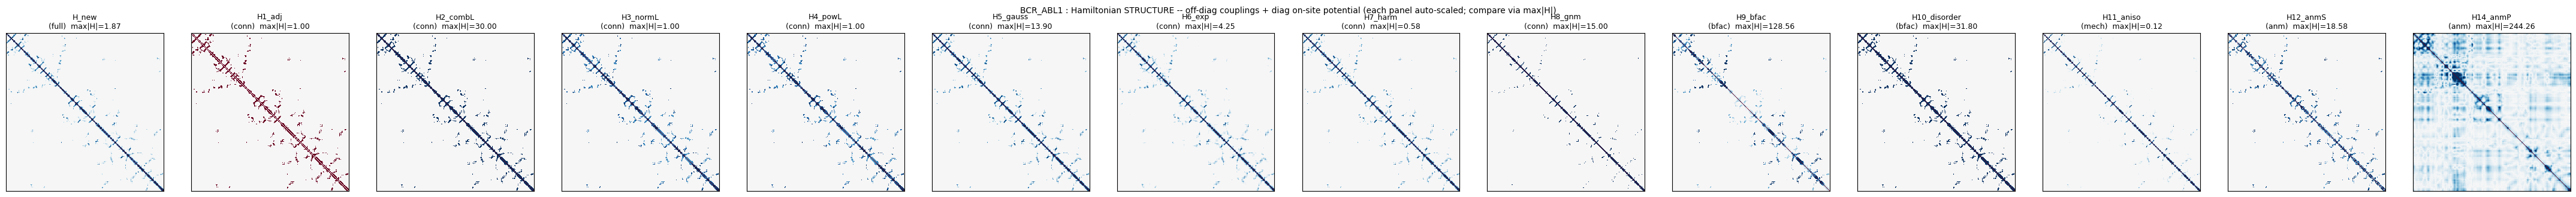

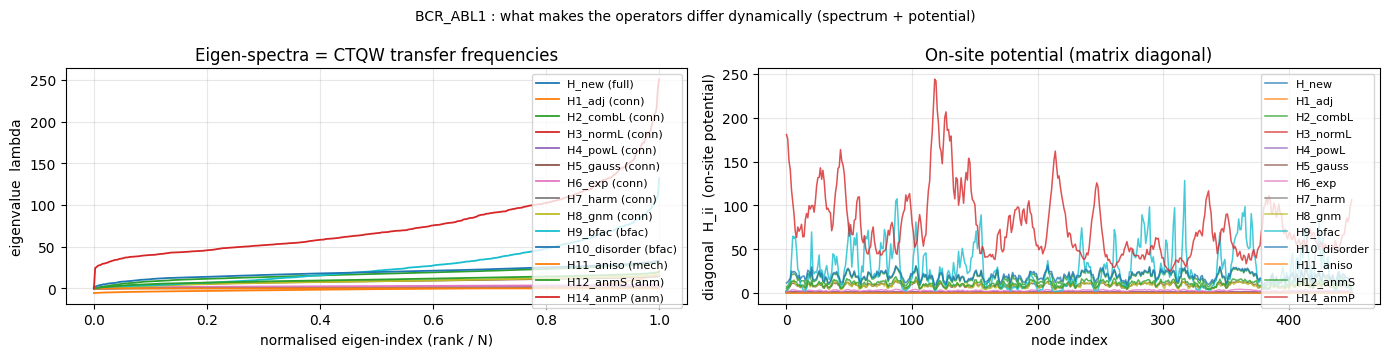

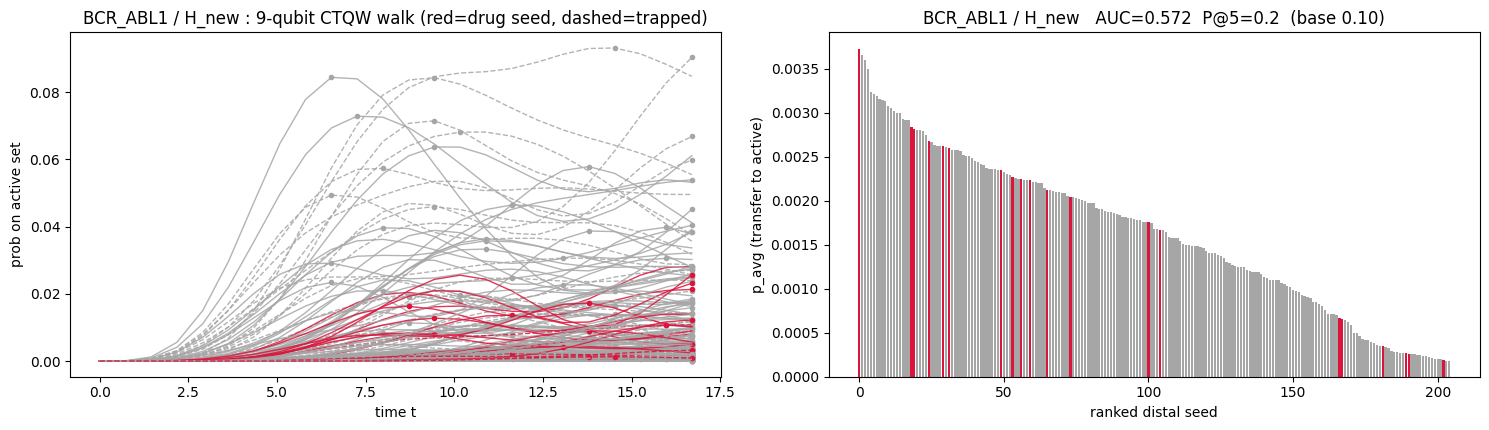

  [H_new     ] 9-qubit walk (PennyLane-validated on 20 circuit calls, max dev 2.2e-19) | 205 distal seeds, 20 in drug pocket, base rate=0.10
    scored by p_avg (transfer): AUC=0.572  P@5=0.2    |    scored by p_peak (max-in-time): AUC=0.599  P@5=0.0
    scored by R = p_peak/p_avg (coherence): AUC=0.600  P@5=0.0
    highest PEAK on active site: resnum 326  (P36, 2 hops, in_drug=False, p_peak=9.311e-02)
    seeds ranked by p_avg  (top 12 of 205):
      rank  resnum  pocket  hop  in_drug   p_avg (transfer)  p_peak (max)  trapped
       1    363     P2     2    DRUG     3.729e-03         2.131e-02     
       2    467     P7     3    -        3.657e-03         7.652e-04     
       3    406     P12    2    -        3.596e-03         3.868e-02     
       4    405     P34    2    -        3.502e-03         2.914e-02     
       5    375     P27    2    -        3.234e-03         3.638e-02     
       6    113     P6     3    -        3.210e-03         7.626e-03     
       7    249     P13

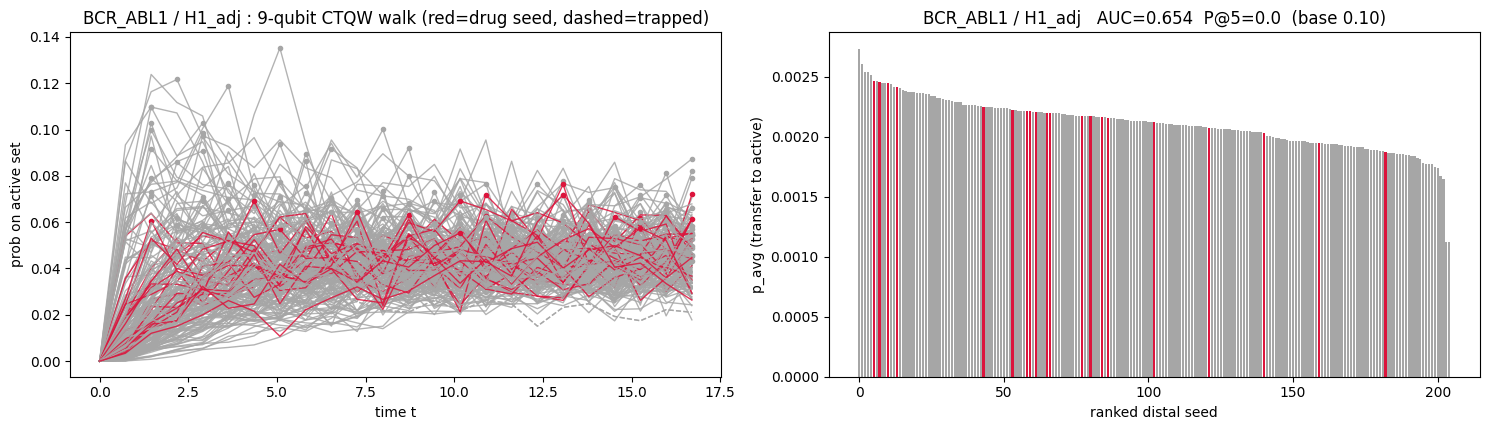

  [H1_adj    ] 9-qubit walk (PennyLane-validated on 20 circuit calls, max dev 1.4e-17) | 205 distal seeds, 20 in drug pocket, base rate=0.10
    scored by p_avg (transfer): AUC=0.654  P@5=0.0    |    scored by p_peak (max-in-time): AUC=0.565  P@5=0.0
    scored by R = p_peak/p_avg (coherence): AUC=0.476  P@5=0.0
    highest PEAK on active site: resnum 296  (P16, 2 hops, in_drug=False, p_peak=1.352e-01)
    seeds ranked by p_avg  (top 12 of 205):
      rank  resnum  pocket  hop  in_drug   p_avg (transfer)  p_peak (max)  trapped
       1    257     P26    2    -        2.732e-03         1.097e-01     
       2    436     P25    2    -        2.603e-03         7.166e-02     
       3    247     P26    2    -        2.542e-03         9.366e-02     
       4    283     P26    2    -        2.538e-03         1.097e-01     
       5    131     P4     2    -        2.515e-03         7.172e-02     
       6    454     P37    2    DRUG     2.466e-03         7.182e-02     
       7    249     P13

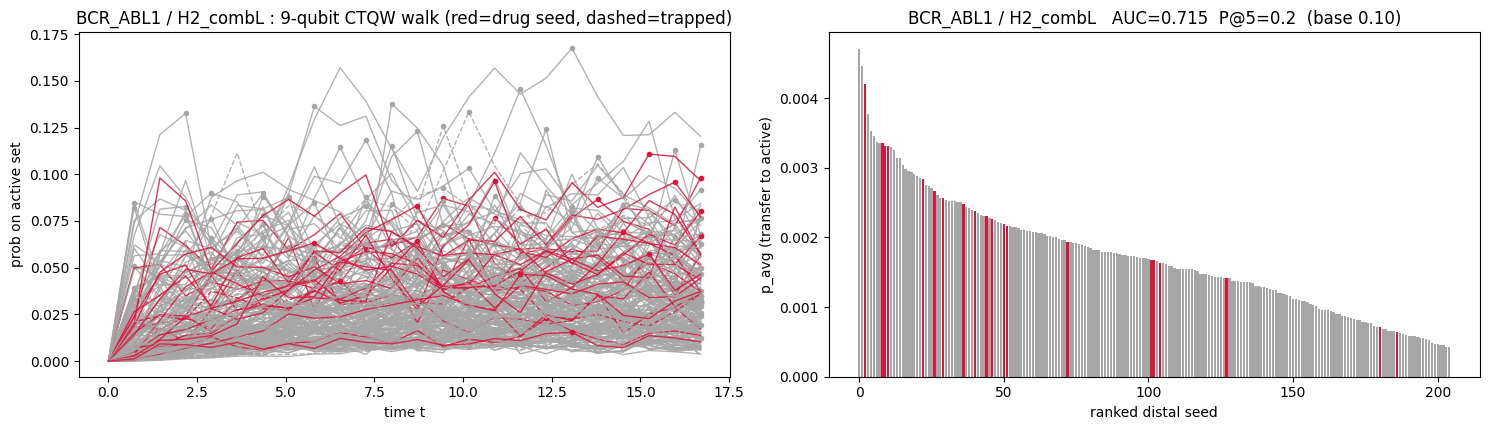

  [H2_combL  ] 9-qubit walk (PennyLane-validated on 20 circuit calls, max dev 3.5e-18) | 205 distal seeds, 20 in drug pocket, base rate=0.10
    scored by p_avg (transfer): AUC=0.715  P@5=0.2    |    scored by p_peak (max-in-time): AUC=0.685  P@5=0.0
    scored by R = p_peak/p_avg (coherence): AUC=0.457  P@5=0.0
    highest PEAK on active site: resnum 427  (P22, 3 hops, in_drug=False, p_peak=1.676e-01)
    seeds ranked by p_avg  (top 12 of 205):
      rank  resnum  pocket  hop  in_drug   p_avg (transfer)  p_peak (max)  trapped
       1    368     P27    2    -        4.710e-03         1.363e-01     
       2    427     P22    3    -        4.455e-03         1.676e-01     
       3    451     P2     2    DRUG     4.209e-03         1.108e-01     
       4    435     P11    2    -        3.769e-03         1.230e-01     
       5    374     P8     2    -        3.522e-03         1.156e-01     
       6    440     P11    2    -        3.462e-03         1.260e-01     yes
       7    443     

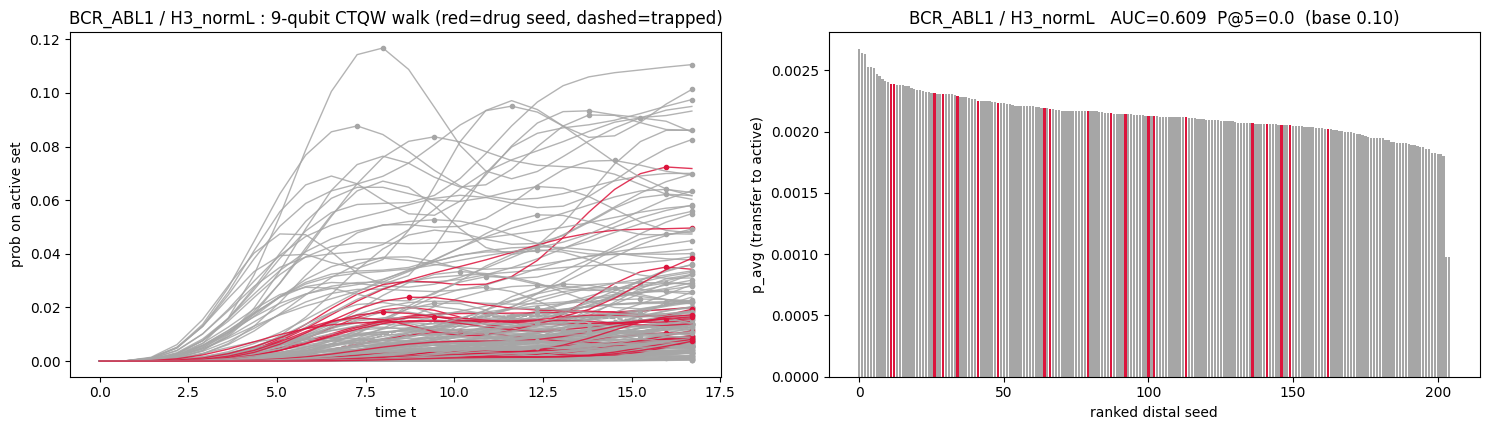

  [H3_normL  ] 9-qubit walk (PennyLane-validated on 20 circuit calls, max dev 8.7e-19) | 205 distal seeds, 20 in drug pocket, base rate=0.10
    scored by p_avg (transfer): AUC=0.609  P@5=0.0    |    scored by p_peak (max-in-time): AUC=0.579  P@5=0.0
    scored by R = p_peak/p_avg (coherence): AUC=0.571  P@5=0.0
    highest PEAK on active site: resnum 260  (P26, 2 hops, in_drug=False, p_peak=1.167e-01)
    seeds ranked by p_avg  (top 12 of 205):
      rank  resnum  pocket  hop  in_drug   p_avg (transfer)  p_peak (max)  trapped
       1    294     P10    2    -        2.677e-03         6.508e-02     
       2    296     P16    2    -        2.640e-03         1.013e-01     
       3    326     P36    2    -        2.635e-03         1.106e-01     
       4    328     P10    2    -        2.528e-03         8.260e-02     
       5    297     P16    2    -        2.525e-03         9.751e-02     
       6    295     P10    2    -        2.517e-03         9.176e-02     
       7    256     P26

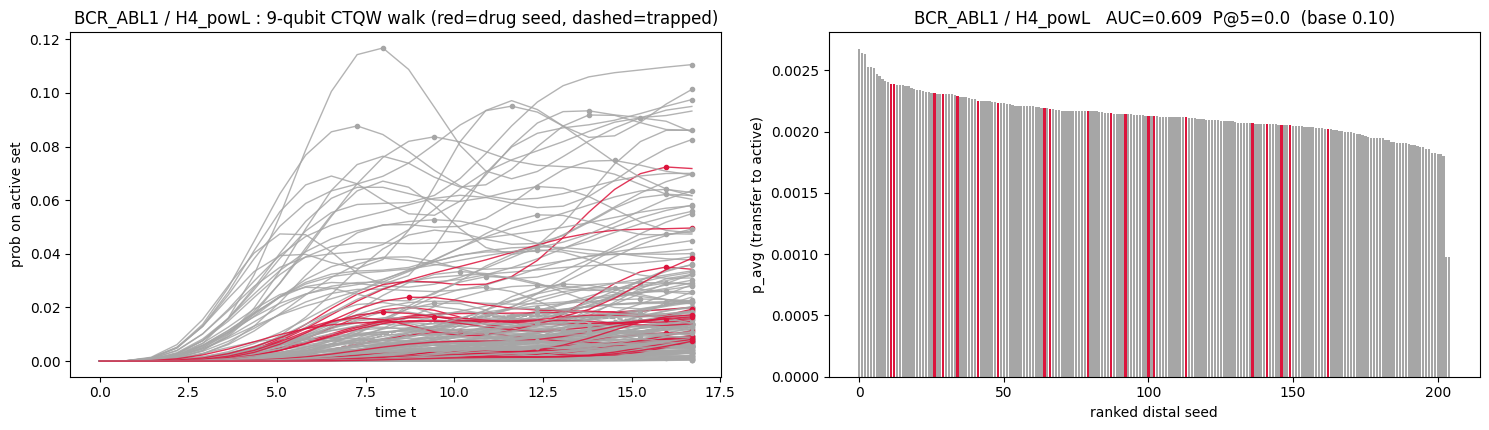

  [H4_powL   ] 9-qubit walk (PennyLane-validated on 20 circuit calls, max dev 4.3e-19) | 205 distal seeds, 20 in drug pocket, base rate=0.10
    scored by p_avg (transfer): AUC=0.609  P@5=0.0    |    scored by p_peak (max-in-time): AUC=0.579  P@5=0.0
    scored by R = p_peak/p_avg (coherence): AUC=0.571  P@5=0.0
    highest PEAK on active site: resnum 260  (P26, 2 hops, in_drug=False, p_peak=1.167e-01)
    seeds ranked by p_avg  (top 12 of 205):
      rank  resnum  pocket  hop  in_drug   p_avg (transfer)  p_peak (max)  trapped
       1    294     P10    2    -        2.677e-03         6.508e-02     
       2    296     P16    2    -        2.640e-03         1.013e-01     
       3    326     P36    2    -        2.635e-03         1.106e-01     
       4    328     P10    2    -        2.528e-03         8.260e-02     
       5    297     P16    2    -        2.525e-03         9.751e-02     
       6    295     P10    2    -        2.517e-03         9.176e-02     
       7    256     P26

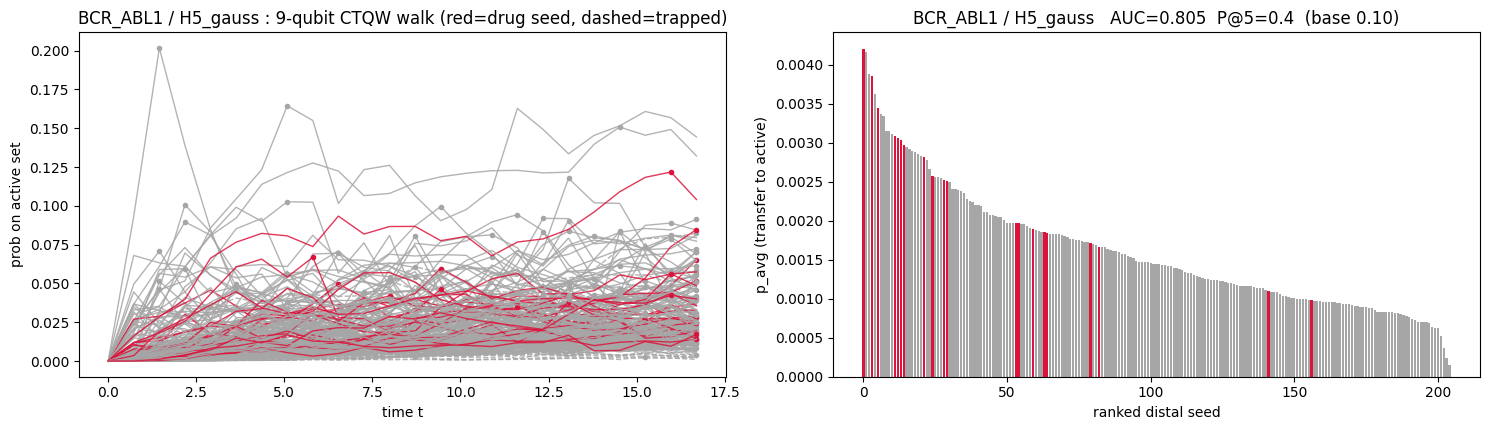

  [H5_gauss  ] 9-qubit walk (PennyLane-validated on 20 circuit calls, max dev 6.9e-18) | 205 distal seeds, 20 in drug pocket, base rate=0.10
    scored by p_avg (transfer): AUC=0.805  P@5=0.4    |    scored by p_peak (max-in-time): AUC=0.614  P@5=0.2
    scored by R = p_peak/p_avg (coherence): AUC=0.328  P@5=0.0
    highest PEAK on active site: resnum 393  (P30, 2 hops, in_drug=False, p_peak=2.017e-01)
    seeds ranked by p_avg  (top 12 of 205):
      rank  resnum  pocket  hop  in_drug   p_avg (transfer)  p_peak (max)  trapped
       1    454     P37    2    DRUG     4.204e-03         8.471e-02     
       2    443     P11    2    -        4.164e-03         8.227e-02     yes
       3    297     P16    2    -        3.883e-03         1.644e-01     
       4    360     P2     3    DRUG     3.849e-03         6.531e-02     
       5    364     P5     2    -        3.623e-03         6.072e-02     yes
       6    453     P37    3    DRUG     3.442e-03         1.218e-01     
       7    378  

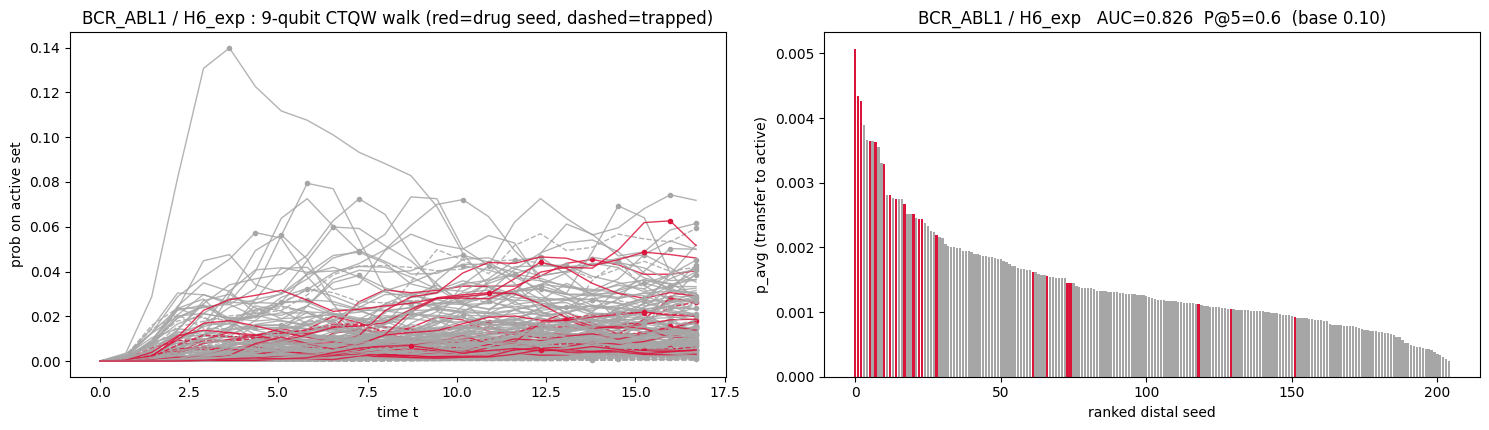

  [H6_exp    ] 9-qubit walk (PennyLane-validated on 20 circuit calls, max dev 1.7e-18) | 205 distal seeds, 20 in drug pocket, base rate=0.10
    scored by p_avg (transfer): AUC=0.826  P@5=0.6    |    scored by p_peak (max-in-time): AUC=0.609  P@5=0.0
    scored by R = p_peak/p_avg (coherence): AUC=0.416  P@5=0.0
    highest PEAK on active site: resnum 393  (P30, 2 hops, in_drug=False, p_peak=1.398e-01)
    seeds ranked by p_avg  (top 12 of 205):
      rank  resnum  pocket  hop  in_drug   p_avg (transfer)  p_peak (max)  trapped
       1    448     P2     2    DRUG     5.072e-03         8.010e-03     yes
       2    512     P2     3    DRUG     4.334e-03         2.188e-02     
       3    521     P2     4    DRUG     4.257e-03         5.036e-03     
       4    153     P29    3    -        3.900e-03         5.145e-03     yes
       5    368     P27    2    -        3.666e-03         4.283e-02     
       6    454     P37    2    DRUG     3.643e-03         4.864e-02     
       7    381  

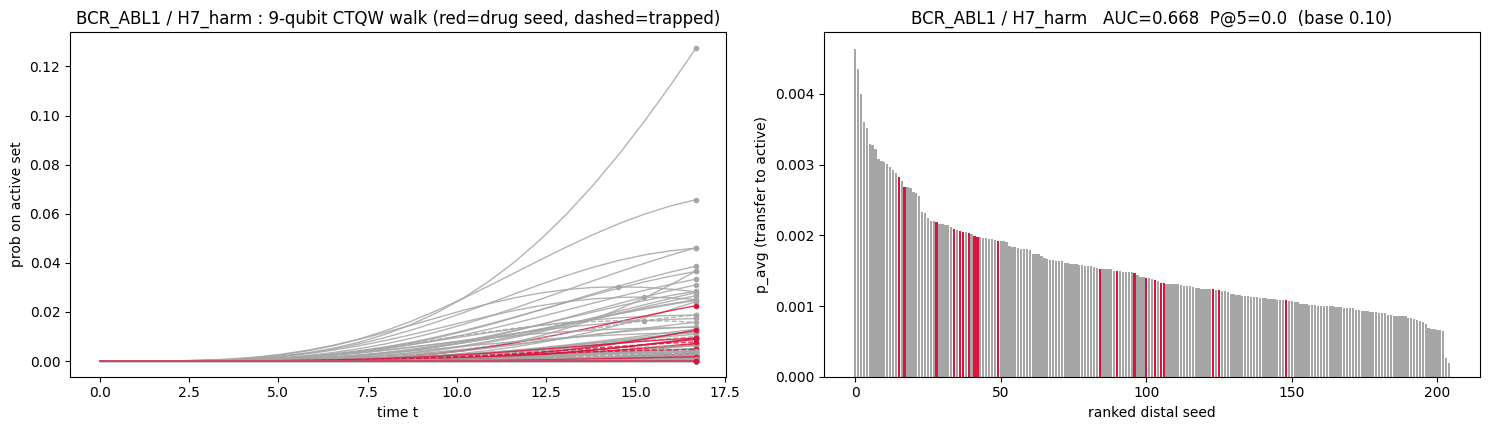

  [H7_harm   ] 9-qubit walk (PennyLane-validated on 20 circuit calls, max dev 8.5e-22) | 205 distal seeds, 20 in drug pocket, base rate=0.10
    scored by p_avg (transfer): AUC=0.668  P@5=0.0    |    scored by p_peak (max-in-time): AUC=0.641  P@5=0.0
    scored by R = p_peak/p_avg (coherence): AUC=0.636  P@5=0.0
    highest PEAK on active site: resnum 393  (P30, 2 hops, in_drug=False, p_peak=1.275e-01)
    seeds ranked by p_avg  (top 12 of 205):
      rank  resnum  pocket  hop  in_drug   p_avg (transfer)  p_peak (max)  trapped
       1    433     P23    3    -        4.640e-03         2.726e-04     
       2    107     P31    4    -        4.346e-03         5.765e-06     yes
       3    368     P27    2    -        4.000e-03         1.648e-02     yes
       4    425     P11    2    -        3.608e-03         2.317e-03     
       5    118     P6     3    -        3.521e-03         6.128e-04     yes
       6    364     P5     2    -        3.298e-03         1.879e-02     yes
       7   

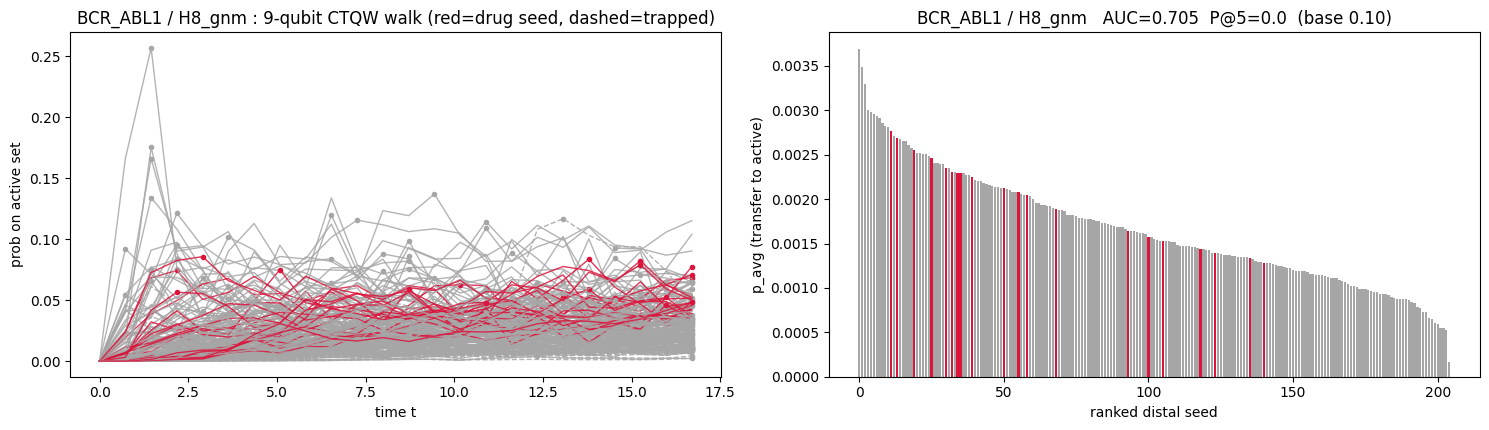

  [H8_gnm    ] 9-qubit walk (PennyLane-validated on 20 circuit calls, max dev 6.9e-18) | 205 distal seeds, 20 in drug pocket, base rate=0.10
    scored by p_avg (transfer): AUC=0.705  P@5=0.0    |    scored by p_peak (max-in-time): AUC=0.775  P@5=0.0
    scored by R = p_peak/p_avg (coherence): AUC=0.711  P@5=0.0
    highest PEAK on active site: resnum 393  (P30, 2 hops, in_drug=False, p_peak=2.570e-01)
    seeds ranked by p_avg  (top 12 of 205):
      rank  resnum  pocket  hop  in_drug   p_avg (transfer)  p_peak (max)  trapped
       1    257     P26    2    -        3.694e-03         1.156e-01     
       2    509     P29    2    -        3.484e-03         1.145e-01     
       3    393     P30    2    -        3.302e-03         2.570e-01     
       4    365     P5     2    -        3.008e-03         8.199e-02     
       5    256     P26    2    -        2.984e-03         1.372e-01     
       6    326     P36    2    -        2.955e-03         1.662e-01     
       7    357     P19

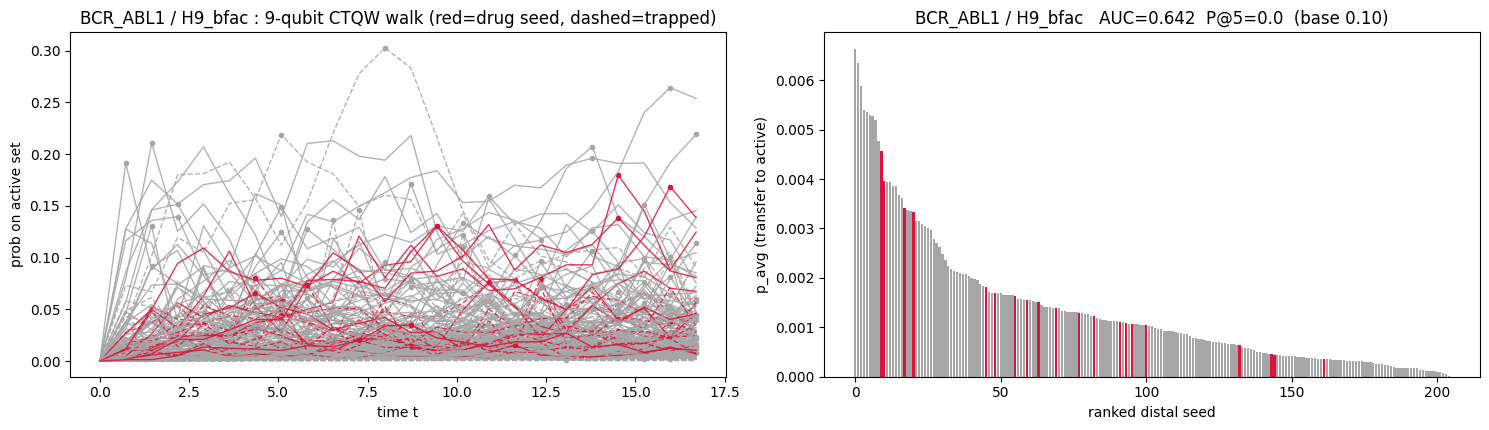

  [H9_bfac   ] 9-qubit walk (PennyLane-validated on 20 circuit calls, max dev 6.9e-18) | 205 distal seeds, 20 in drug pocket, base rate=0.10
    scored by p_avg (transfer): AUC=0.642  P@5=0.0    |    scored by p_peak (max-in-time): AUC=0.706  P@5=0.0
    scored by R = p_peak/p_avg (coherence): AUC=0.704  P@5=0.2
    highest PEAK on active site: resnum 248  (P26, 2 hops, in_drug=False, p_peak=3.025e-01)
    seeds ranked by p_avg  (top 12 of 205):
      rank  resnum  pocket  hop  in_drug   p_avg (transfer)  p_peak (max)  trapped
       1    372     P27    2    -        6.637e-03         2.190e-01     
       2    248     P26    2    -        6.344e-03         3.025e-01     yes
       3    247     P26    2    -        5.888e-03         2.187e-01     yes
       4    355     P20    3    -        5.404e-03         1.022e-01     
       5    524     P32    4    -        5.356e-03         2.641e-01     
       6    429     P11    3    -        5.289e-03         1.960e-01     
       7    405  

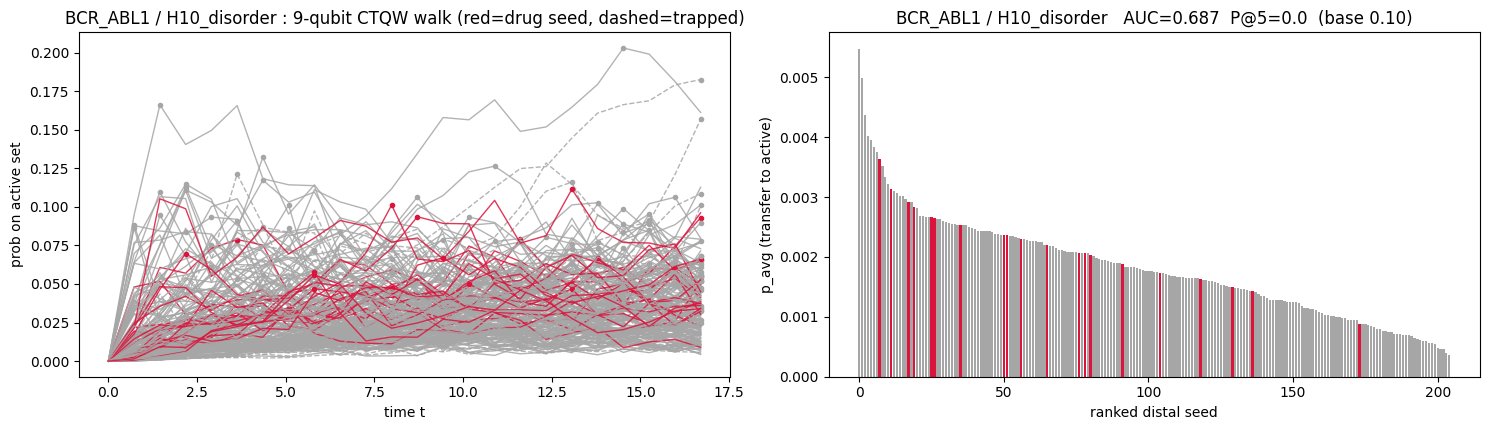

  [H10_disorder] 9-qubit walk (PennyLane-validated on 20 circuit calls, max dev 6.9e-18) | 205 distal seeds, 20 in drug pocket, base rate=0.10
    scored by p_avg (transfer): AUC=0.687  P@5=0.0    |    scored by p_peak (max-in-time): AUC=0.639  P@5=0.0
    scored by R = p_peak/p_avg (coherence): AUC=0.438  P@5=0.0
    highest PEAK on active site: resnum 98   (P28, 3 hops, in_drug=False, p_peak=2.031e-01)
    seeds ranked by p_avg  (top 12 of 205):
      rank  resnum  pocket  hop  in_drug   p_avg (transfer)  p_peak (max)  trapped
       1    129     P13    3    -        5.477e-03         1.826e-01     yes
       2    98      P28    3    -        4.984e-03         2.031e-01     
       3    249     P13    2    -        4.368e-03         1.568e-01     yes
       4    427     P22    3    -        4.026e-03         1.063e-01     
       5    131     P4     2    -        3.948e-03         1.086e-01     yes
       6    328     P10    2    -        3.836e-03         7.801e-02     
       7    

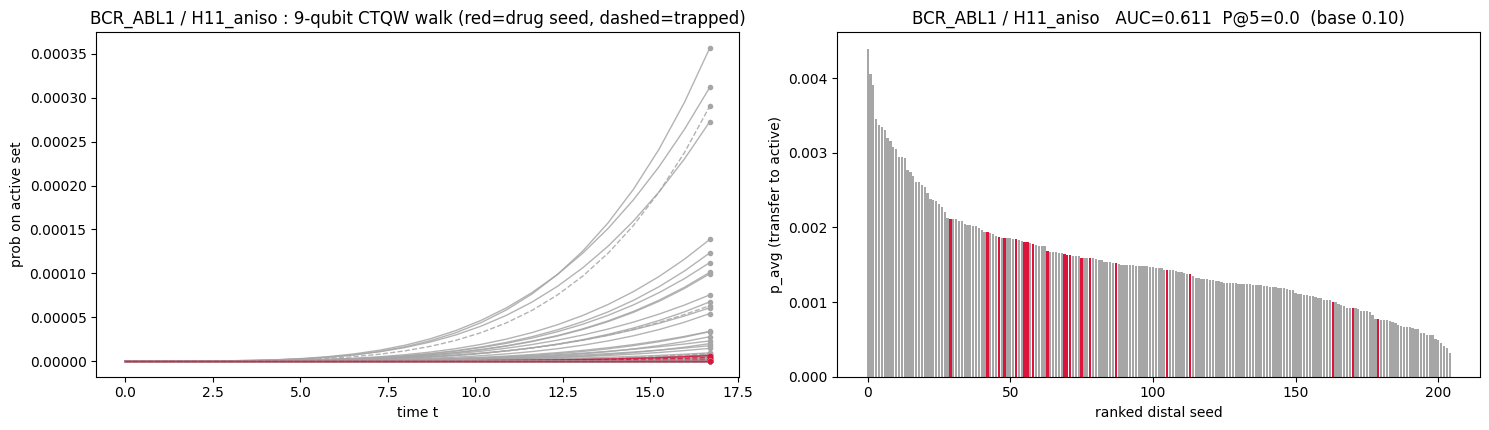

  [H11_aniso ] 9-qubit walk (PennyLane-validated on 20 circuit calls, max dev 3.2e-27) | 205 distal seeds, 20 in drug pocket, base rate=0.10
    scored by p_avg (transfer): AUC=0.611  P@5=0.0    |    scored by p_peak (max-in-time): AUC=0.612  P@5=0.0
    scored by R = p_peak/p_avg (coherence): AUC=0.612  P@5=0.0
    highest PEAK on active site: resnum 393  (P30, 2 hops, in_drug=False, p_peak=3.568e-04)
    seeds ranked by p_avg  (top 12 of 205):
      rank  resnum  pocket  hop  in_drug   p_avg (transfer)  p_peak (max)  trapped
       1    283     P26    2    -        4.393e-03         1.988e-05     
       2    260     P26    2    -        4.061e-03         1.450e-05     
       3    282     P26    2    -        3.911e-03         4.808e-06     
       4    256     P26    2    -        3.449e-03         3.119e-04     
       5    297     P16    2    -        3.366e-03         7.543e-05     
       6    298     P16    2    -        3.349e-03         1.386e-04     
       7    296     P16

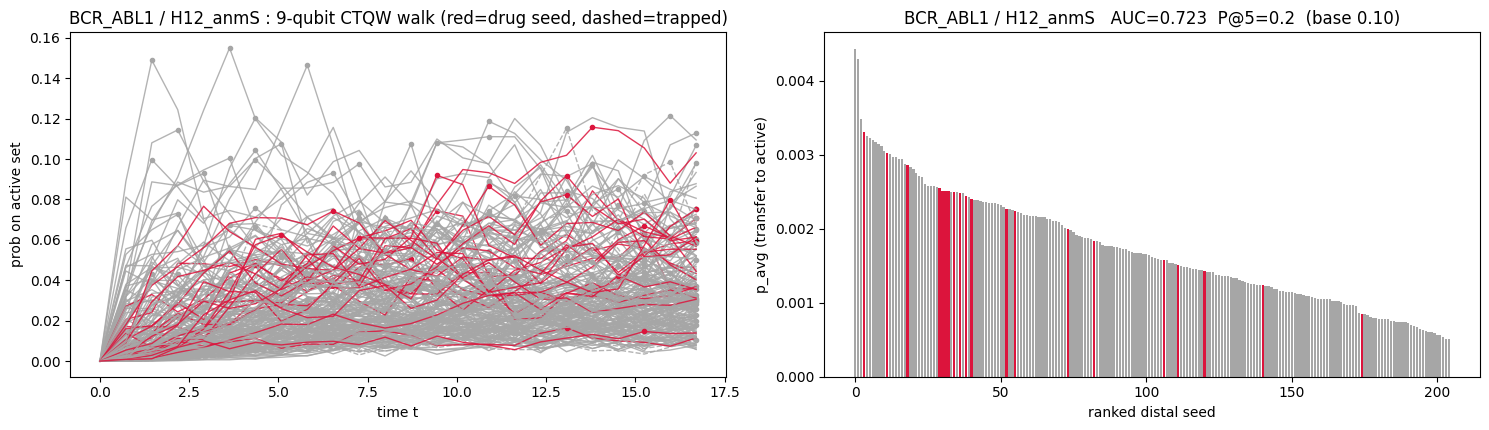

  [H12_anmS  ] 9-qubit walk (PennyLane-validated on 20 circuit calls, max dev 6.9e-18) | 205 distal seeds, 20 in drug pocket, base rate=0.10
    scored by p_avg (transfer): AUC=0.723  P@5=0.2    |    scored by p_peak (max-in-time): AUC=0.686  P@5=0.0
    scored by R = p_peak/p_avg (coherence): AUC=0.483  P@5=0.0
    highest PEAK on active site: resnum 297  (P16, 2 hops, in_drug=False, p_peak=1.550e-01)
    seeds ranked by p_avg  (top 12 of 205):
      rank  resnum  pocket  hop  in_drug   p_avg (transfer)  p_peak (max)  trapped
       1    467     P7     3    -        4.432e-03         9.140e-02     
       2    443     P11    2    -        4.287e-03         1.154e-01     yes
       3    426     P11    3    -        3.477e-03         9.790e-02     
       4    451     P2     2    DRUG     3.304e-03         1.158e-01     
       5    361     P3     2    -        3.253e-03         8.848e-02     
       6    365     P5     2    -        3.232e-03         1.076e-01     
       7    406     

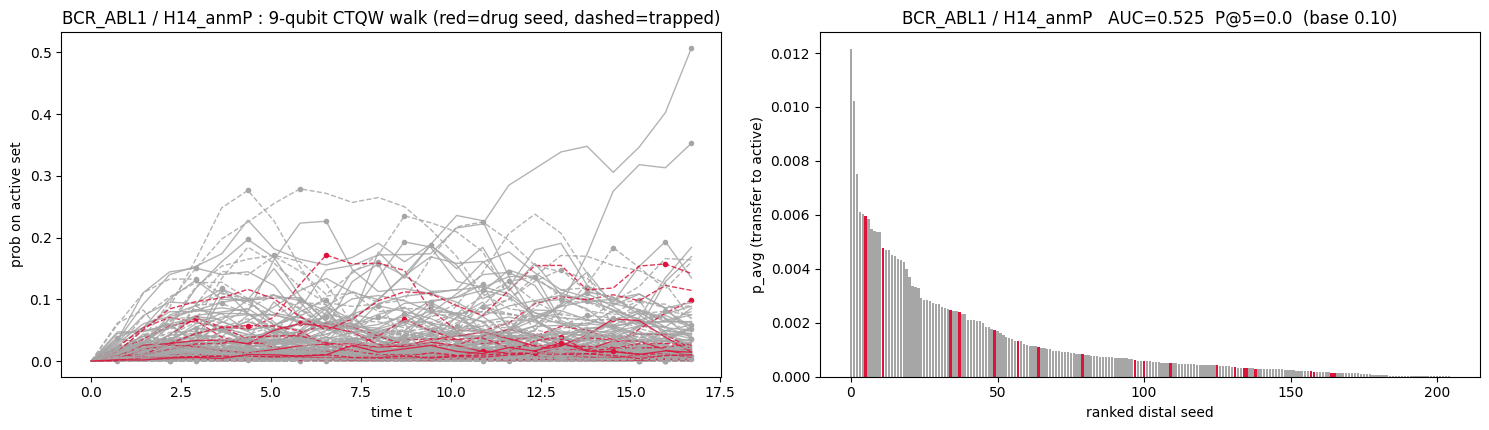

  [H14_anmP  ] 9-qubit walk (PennyLane-validated on 20 circuit calls, max dev 3.5e-18) | 205 distal seeds, 20 in drug pocket, base rate=0.10
    scored by p_avg (transfer): AUC=0.525  P@5=0.0    |    scored by p_peak (max-in-time): AUC=0.531  P@5=0.0
    scored by R = p_peak/p_avg (coherence): AUC=0.545  P@5=0.2
    highest PEAK on active site: resnum 181  (P29, 4 hops, in_drug=False, p_peak=5.073e-01)
    seeds ranked by p_avg  (top 12 of 205):
      rank  resnum  pocket  hop  in_drug   p_avg (transfer)  p_peak (max)  trapped
       1    181     P29    4    -        1.216e-02         5.073e-01     
       2    247     P26    2    -        1.021e-02         3.531e-01     
       3    239     P3     2    -        7.501e-03         2.255e-01     yes
       4    443     P11    2    -        6.120e-03         2.791e-01     yes
       5    434     P25    3    -        6.020e-03         8.768e-02     yes
       6    451     P2     2    DRUG     5.960e-03         1.573e-01     yes
       7   

In [747]:
# ===========================================================================
# 14 - CTQW, unitary (no dephasing): PennyLane qubit walk on MULTIPLE Hamiltonians
#      seeded ONE RESIDUE AT A TIME from the top fpocket pockets -> AUC/P@5 + trap
# ---------------------------------------------------------------------------
# The fpocket-seeded CTQW scan, RUN ON QUBITS (PennyLane) for SEVERAL Hamiltonians with
# the SAME scoring. For each operator in HAMS_TO_RUN we: seed one residue at a time from
# the top-K druggable fpocket pockets (active-site pocket excluded), keep only the distal
# seeds (>= MIN_HOP graph-hops from the active site), run e^{-iHt} on ceil(log2 N) qubits
# (BasisState -> QubitUnitary -> probs), measure the probability reaching the active site
# vs time (the "walk"), rank by long-time transfer p_avg, and score AUC + P@5 vs the holo
# drug pocket + the trapped region. p_avg (T->inf) stays classical (a circuit can't measure
# an infinite-time average in one shot); the finite-t walk is what runs on qubits, validated
# against the classical eigendecomposition. One seed per run, position basis; T from the gap.
import networkx as nx

# --- pre-registered controls (frozen; never chosen using DRUG_POCKET or the AUC) ---
# Pocket-selection knobs (SEED_SOURCE / N_SEED_POCKETS) live in cell "13z. SEED
# SELECTION" directly above, together with the rules that build the pocket set. This
# cell consumes them; defaults below only stop a NameError if 13z was not run.
SEED_SOURCE = globals().get("SEED_SOURCE", "consensus")
N_SEED_POCKETS = globals().get("N_SEED_POCKETS", 21)
MIN_HOP = 2   # keep only seeds >= this many graph-hops from the active site. OWNED HERE:
              # it is a property of the walk (how distal a seed must be), not of which pockets
              # were chosen. Cell 13z previews the cost of each value before this cell runs.
SEED_FROM_PASSER_OVERLAP = (SEED_SOURCE != "fpocket")
C_T = 1.0; NYQUIST_OVERSAMPLE = 2.0; N_T_CAP = 300     # time sampling (p_avg is the T->inf limit)
# -- extra PROPAGATORS scored alongside the CTQW, per operator, on the SAME seeds ------------
#   Green   G = (E + i*eta - H)^-1, score_s = sum_{a in active} |G_as|^2
#   QMI     single-excitation mutual information I(seed : active), time-averaged
# !! UNLIKE p_avg, THE GREEN SCORE HAS TWO FREE PARAMETERS (E, eta) AND IS VERY SENSITIVE TO
# THEM: a 4-operator x 4-E x 4-eta sweep on BCR_ABL1 spanned AUC 0.350-0.691 (residualised
# 0.307-0.863). Quoting the best cell of that grid is selection, not a result. So ONE
# pre-registered (E, eta) is scored; the rest of GREEN_GRID is sensitivity, reported but never
# enters the score tables. p_avg by contrast has NO free parameter at all.
GREEN_ENABLE = True
# EVERY (E, eta) in this grid is scored as its OWN row, through the full pipeline: the
# per-operator table, the SCORE x HAMILTONIAN matrix, and its own consensus table. That
# answers "do different parameters give different scores?" directly and visibly.
# !! IT ALSO MULTIPLIES THE SELECTION PROBLEM. With 14 operators, each extra Green setting
# adds 14 more cells to a matrix whose maximum is already reported as "BEST CELL". Read the
# grid as a SENSITIVITY ANALYSIS -- how much does the answer move? -- and NOT as 5 more
# chances to find a winner. GREEN_PREREG names the one setting that counts as the result;
# the others are exploratory and labelled as such in the output.
GREEN_GRID   = [("zero", 0.05), ("zero", 0.01), ("zero", 0.20),
                ("lmax", 0.05), ("median", 0.05)]
GREEN_PREREG = ("zero", 0.05)   # the ONE pre-registered setting -- fix before looking
GREEN_E_MODE, GREEN_ETA = GREEN_PREREG          # back-compat for anything referencing these
QMI_ENABLE   = True
QMI_T_FRAC   = [0.1, 0.5, 1.0]   # times (fraction of T_max) the QMI is averaged over
# ---- SEED SOURCE: which pockets may contribute walk seeds? (ADDITIVE -- default = old behaviour)
# WHERE THE SEEDS COME FROM. All three sets are built in sec 7b; this only chooses between
# them. Every residue of every chosen pocket becomes a seed; MIN_HOP is then the only filter.
#   "fpocket"   top-N_SEED_POCKETS fpocket pockets by druggability (widest, geometry only)
#   "consensus" pockets where fpocket AND PASSer agree        -> PASSER_FPOCKET_MATCH
#   "threeway"  fpocket AND PASSer AND PocketMiner agree      -> THREEWAY_MATCH
# NARROWER IS NOT BETTER. The three-way set requires PocketMiner to call the pocket CRYPTIC,
# i.e. currently CLOSED -- so a pocket that is already open is excluded by construction.
# BCR-ABL1's myristoyl pocket (apo 1OPL has myristate bound) is exactly that case, and its
# P@5 would go to 0 for reasons that have nothing to do with the walk. sec 7b prints whether
# the true pocket survives each set; check that before reading a null result as a failure.
                             #  "consensus"/"threeway" use EVERY pocket in their set.)
TRAP_THRESH    = 0.5
CONSENSUS_SCORES  = ["p_avg", "p_peak", "R", "residual LOG", "residual RAW",
                     "residual LOG + dX", "residual RAW + dX", "p_avg / dX (SNR)",
                     "-E[D] final", "-dD mean", "QMI"]
# every Green grid point gets its own consensus table too (labels must match the score keys)
CONSENSUS_SCORES += ["Green E=%s eta=%.3g%s" % (_e, _t, "*" if (_e, _t) == tuple(GREEN_PREREG) else "")
                     for _e, _t in GREEN_GRID]   # one consensus table per score
CONSENSUS_RESIDUE_ROWS = 6   # residue rows printed per consensus table
PER_OP_ALL_SCORES = True   # compute EVERY score (residual LOG/RAW, +dX, D-operator, coherence)
                           # for EVERY Hamiltonian, not only the best one. Cost is dominated by
                           # the walker distributions: O(DIAG_TIME_PTS * n_seeds * N^2) per operator.
DIAG_TIME_PTS     = 16     # time points for dX(t) / E[D](t) / dD(t)   (lower = faster)
QML_VAL_SEEDS  = 4     # qubit-circuit validation subset: seeds  (0 = skip PennyLane entirely)
QML_VAL_TIMES  = 5     # qubit-circuit validation subset: time points (full grid = closed form)
# Hamiltonians to run the FULL qubit walk + scoring on (names from sec-13 OPS; edit freely):
# ---- choose which Hamiltonians to run on qubits ----
RUN_ALL_HAMS = True   # False = the curated 5 below | True = ALL 14 (H1-H12, H14 + H_new)
_FIVE = ["H_new", "H2_combL", "H6_exp", "H3_normL", "H10_disorder"]   # the curated subset
_ALL  = (["H_new"] + [k for k in next(iter(OPS.values())).keys() if k != "H_new"]) if OPS else _FIVE   # every operator built in sec 13
HAMS_TO_RUN = _ALL if RUN_ALL_HAMS else _FIVE
_have_ov = ("PASSER_FPOCKET_MATCH" in dir()) and any(PASSER_FPOCKET_MATCH.get(n) for n in ACTIVE)
_srcmode = ("PASSer-fpocket CONSENSUS (J>=%.2f)" % PASSER_JACCARD) if (SEED_FROM_PASSER_OVERLAP and _have_ov) \
           else ("ALL fpocket pockets" + ("  !! overlap requested but sec 7b has no data -- run it first"
                                          if SEED_FROM_PASSER_OVERLAP else ""))
print("PRE-REGISTERED (sec 14): C_T=%.1f, MIN_HOP=%d, seed pool = %s, then top-%d | %d Hamiltonians on qubits%s: %s"
      % (C_T, MIN_HOP, _srcmode, N_SEED_POCKETS, len(HAMS_TO_RUN),
         " (ALL)" if RUN_ALL_HAMS else " (curated 5)", HAMS_TO_RUN))


def average_mixing(w, V, tol=1e-6):
    """Average mixing matrix M_ij = sum_r (P_r o P_r)_ij (degeneracy-grouped);
    exact fast path V^2 @ V^2.T for a non-degenerate spectrum."""
    order = np.argsort(w); w = w[order]; V = V[:, order]
    sq = V * V; M = sq @ sq.T
    i, N = 0, len(w)
    while i < N:
        j = i + 1
        while j < N and (w[j] - w[i]) < tol:
            j += 1
        if j - i > 1:
            Vr = V[:, i:j]; Pr = Vr @ Vr.T
            M -= sq[:, i:j] @ sq[:, i:j].T; M += Pr * Pr
        i = j
    return M


def prob_on_active_over_time(w, V, active_idx, ts):
    """(len(ts), N): probability on the active SET from each seed s at each t,
    = sum_{a in active} |<a|e^{-iHt}|s>|^2 (via reciprocity, propagate from a)."""
    P = np.zeros((len(ts), V.shape[0])); E = np.exp(-1j * np.outer(ts, w))
    for a in active_idx:
        amp = (V[a, :][None, :] * E) @ V.T
        P += np.abs(amp) ** 2
    return P


# --- PennyLane qubit CTQW: basis-encode the N nodes on ceil(log2 N) qubits and run
#     e^{-iHt} as a circuit (exact QubitUnitary; Trotter ApproxTimeEvolution = NISQ variant).
#     Falls back to the classical walk if PennyLane is unavailable, so the notebook runs. ---
try:
    import pennylane as qml
    _HAVE_QML = True
except Exception:
    _HAVE_QML = False


def qubit_ctqw_walk(w, V, active_idx, seeds, ts, n_qubits):
    """Run the CTQW on n_qubits qubits (PennyLane default.qubit): |seed> -> QubitUnitary(e^{-iHt})
    -> probs, return prob on the active set. (len(ts), len(seeds)); exact on the N-block."""
    N = V.shape[0]; dim = 2 ** n_qubits
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev)
    def circ(bits, U):
        qml.BasisState(bits, wires=range(n_qubits))
        qml.QubitUnitary(U, wires=range(n_qubits))
        return qml.probs(wires=range(n_qubits))

    bits = {s: np.array([int(b) for b in format(int(s), "0%db" % n_qubits)]) for s in seeds}
    out = np.zeros((len(ts), len(seeds)))
    for ti, t in enumerate(ts):
        Un = (V * np.exp(-1j * w * t)) @ V.T
        U = np.eye(dim, dtype=complex); U[:N, :N] = Un
        for k, s in enumerate(seeds):
            out[ti, k] = float(circ(bits[s], U)[active_idx].sum())
    return out


def qubit_ctqw_validate(w, V, active_idx, seeds, ts, n_qubits, n_seed=None, n_time=None):
    """Run the CTQW as a REAL PennyLane circuit on ceil(log2 N) qubits for a SUBSET of
    (seed, t) points and return (max |quantum - classical| deviation, n_circuit_calls).

    Why a subset: applying QubitUnitary(e^{-iHt}) to a basis state |s> is mathematically
    column s of e^{-iHt}, so the full (t x seed) grid is EXACTLY the classical
    eigendecomposition -- running every point through PennyLane recomputes a lookup at
    ~10 ms of framework overhead each (243 seeds x 50 t x 13 operators = 158k calls,
    ~30+ min, zero extra information). The scientific claim being made is "the qubit
    circuit reproduces the walk", which a validation subset establishes to machine
    precision; the full grid then uses the identical closed form. Set QML_VAL_SEEDS /
    QML_VAL_TIMES = 0 to skip validation entirely."""
    n_seed = QML_VAL_SEEDS if n_seed is None else n_seed
    n_time = QML_VAL_TIMES if n_time is None else n_time
    if not _HAVE_QML or n_seed <= 0 or n_time <= 0 or len(seeds) == 0 or len(ts) == 0:
        return float("nan"), 0
    N = V.shape[0]; dim = 2 ** n_qubits
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev)
    def circ(bits, U):
        qml.BasisState(bits, wires=range(n_qubits))
        qml.QubitUnitary(U, wires=range(n_qubits))
        return qml.probs(wires=range(n_qubits))

    s_ix = np.unique(np.linspace(0, len(seeds) - 1, min(n_seed, len(seeds))).astype(int))
    t_ix = np.unique(np.linspace(0, len(ts) - 1, min(n_time, len(ts))).astype(int))
    err, ncalls = 0.0, 0
    for ti in t_ix:
        Un = (V * np.exp(-1j * w * ts[ti])) @ V.T
        U = np.eye(dim, dtype=complex); U[:N, :N] = Un
        for k in s_ix:
            sd = int(seeds[k])
            bits = np.array([int(b) for b in format(sd, "0%db" % n_qubits)])
            q = float(circ(bits, U)[active_idx].sum())                 # on qubits
            cl = float((np.abs(Un[active_idx, sd]) ** 2).sum())        # closed form
            err = max(err, abs(q - cl)); ncalls += 1
    return err, ncalls


def _fit_med14(yv, X):
    """Median (q=0.5) quantile fit, OLS fallback -- same estimator as sec 14a."""
    try:
        import statsmodels.api as sm
        return np.asarray(sm.QuantReg(np.asarray(yv, float), np.asarray(X, float)).fit(q=0.5).params, float)
    except Exception:
        b, *_ = np.linalg.lstsq(X, yv, rcond=None); return b


def _rz14(r):
    """Robust (median/MAD) standardisation. Rank-based AUC/P@5 unchanged -- readability only."""
    r = np.asarray(r, float); m = np.median(r)
    return (r - m) / (1.4826 * np.median(np.abs(r - m)) + 1e-12)


def operator_diagnostics(wo, Vo, seed_arr, ts_d, coords, Dvec):
    """Walker moments for ONE operator, vectorised over all seeds at once.
    Returns dX(t,S) [Angstrom spatial spread], ED(t,S) [mean graph-distance to the active
    site], dD(t,S) [spread of that distance].  |<j|e^{-iHt}|s>|^2 for every seed s in one
    matmul per time point: (S,K) x (K,N)."""
    Vs = Vo[seed_arr, :]; r2 = (coords ** 2).sum(1)
    T, S = len(ts_d), len(seed_arr)
    dX = np.zeros((T, S)); ED = np.zeros((T, S)); dD = np.zeros((T, S))
    for ti, t in enumerate(ts_d):
        P = np.abs((Vs * np.exp(-1j * wo * t)) @ Vo.T) ** 2      # (S,N) probabilities
        mu = P @ coords                                           # (S,3)
        dX[ti] = np.sqrt(np.clip(P @ r2 - (mu ** 2).sum(1), 0, None))
        ed = P @ Dvec
        ED[ti] = ed; dD[ti] = np.sqrt(np.clip(P @ (Dvec ** 2) - ed ** 2, 0, None))
    return dX, ED, dD


def walk_score_plot(name, opname, wo, Vo, Mo, active_idx, seed_all, hop_of, two_hop, didx, ts, tq, n_qubits, r2n, seed_pocket, ctx=None):
    """Full fpocket-seeded distal walk for ONE Hamiltonian, RUN ON QUBITS: p_avg transfer,
    PennyLane walk (validated), AUC/P@5 vs the drug pocket, trap, and a plot. Returns a dict."""
    Nn = len(Mo)
    primo = Mo[:, active_idx].mean(1)
    trapo = np.array([Mo[s, two_hop[s]].sum() for s in range(Nn)])
    seed = [s for s in seed_all if hop_of[s] >= MIN_HOP]
    if len(seed) < 2:
        print("  [%s] <2 distal seeds -> skipped" % opname); return None
    seed_arr = np.array(seed); ts_w = ts[tq]
    walks_cl = prob_on_active_over_time(wo, Vo, active_idx, ts_w)[:, seed_arr]
    walks = walks_cl                                            # full grid = exact closed form
    qerr, n_qcalls = qubit_ctqw_validate(wo, Vo, active_idx, seed, ts_w, n_qubits)
    pa = primo[seed_arr]; pk_w = walks.max(0); tr_w = trapo[seed_arr]
    y = np.array([1.0 if s in didx else 0.0 for s in seed]); in_drug = y.astype(bool); trapped = tr_w > TRAP_THRESH
    order = list(np.argsort(-pa))
    auc = roc_auc_score(y, pa) if 0 < y.sum() < len(y) else float("nan")
    p5 = sum(seed[k] in didx for k in order[:5]) / 5.0; base = float(y.mean())

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.4))
    for k in range(len(seed)):
        col = "crimson" if in_drug[k] else "0.65"
        ax1.plot(ts_w, walks[:, k], color=col, ls=("--" if trapped[k] else "-"), lw=1.0, alpha=0.85)
        ax1.plot(ts_w[np.argmax(walks[:, k])], pk_w[k], "o", color=col, ms=3)
    ax1.set_xlabel("time t"); ax1.set_ylabel("prob on active set")
    ax1.set_title("%s / %s : %d-qubit CTQW walk (red=drug seed, dashed=trapped)" % (name, opname, n_qubits))
    ax2.bar(range(len(seed)), pa[order], color=["crimson" if in_drug[k] else "0.65" for k in order])
    ax2.set_xlabel("ranked distal seed"); ax2.set_ylabel("p_avg (transfer to active)")
    ax2.set_title("%s / %s   AUC=%.3f  P@5=%.1f  (base %.2f)" % (name, opname, auc, p5, base))
    fig.tight_layout(); plt.show()

    # ---- per-residue detail + AUC/P@5 scored by BOTH p_avg (transfer) and p_peak (max-in-time) ----
    order_peak = list(np.argsort(-pk_w))
    auc_peak = roc_auc_score(y, pk_w) if 0 < y.sum() < len(y) else float("nan")
    p5_peak = sum(seed[k] in didx for k in order_peak[:5]) / 5.0
    pc = order_peak[0]                                            # residue with the highest peak on the active set
    _qtxt = ("PennyLane-validated on %d circuit calls, max dev %.1e" % (n_qcalls, qerr)) if n_qcalls \
            else "qubit validation skipped"
    print("  [%-10s] %d-qubit walk (%s) | %d distal seeds, %d in drug pocket, base rate=%.2f"
          % (opname, n_qubits, _qtxt, len(seed), int(y.sum()), base))
    print("    scored by p_avg (transfer): AUC=%.3f  P@5=%.1f    |    scored by p_peak (max-in-time): AUC=%.3f  P@5=%.1f"
          % (auc, p5, auc_peak, p5_peak))
    R_w = pk_w / np.clip(pa, 1e-12, None)                        # coherence ratio R = p_peak / p_avg
    order_R = list(np.argsort(-R_w))
    auc_R = roc_auc_score(y, R_w) if 0 < y.sum() < len(y) else float("nan")
    p5_R = sum(seed[k] in didx for k in order_R[:5]) / 5.0
    print("    scored by R = p_peak/p_avg (coherence): AUC=%.3f  P@5=%.1f" % (auc_R, p5_R))
    print("    highest PEAK on active site: resnum %-4s (P%s, %d hops, in_drug=%s, p_peak=%.3e)"
          % (r2n[seed[pc]], seed_pocket.get(seed[pc], "?"), hop_of[seed[pc]], seed[pc] in didx, pk_w[pc]))
    print("    seeds ranked by p_avg  (top %d of %d):" % (min(12, len(seed)), len(seed)))
    print("      rank  resnum  pocket  hop  in_drug   p_avg (transfer)  p_peak (max)  trapped")
    for r, k in enumerate(order[:min(12, len(seed))], 1):
        s = seed[k]
        print("      %2d    %-5s   P%-3s   %-2d   %-5s    %.3e         %.3e     %s"
              % (r, r2n[s], seed_pocket.get(s, "?"), hop_of[s], "DRUG" if in_drug[k] else "-",
                 pa[k], pk_w[k], "yes" if trapped[k] else ""))
    # ================= ALL SCORES, FOR THIS OPERATOR (not just the best one) =================
    # Everything sec 14a / 14c / 14d / 14e compute for a single chosen Hamiltonian is computed
    # here for EVERY Hamiltonian, from that operator's OWN p_avg and its OWN walker dynamics,
    # so the operators can be compared on equal footing across all scoring definitions.
    extra = {}
    if PER_OP_ALL_SCORES and ctx is not None and 0 < y.sum() < len(y):
        def _ap5(v):
            v = np.asarray(v, float); o = np.argsort(-v)
            return ((roc_auc_score(y, v) if 0 < y.sum() < len(y) else float("nan")),
                    sum(seed[k] in didx for k in o[:5]) / 5.0)
        dist_all, deg_all, coords_all, Dvec = ctx["dist"], ctx["deg"], ctx["coords"], ctx["Dvec"]
        # --- proximity/degree-corrected residuals, fitted on THIS operator's own p_avg ---
        fm = np.isfinite(dist_all) & np.isfinite(primo) & (primo > 0)
        Xf = np.column_stack([np.ones(int(fm.sum())), dist_all[fm], deg_all[fm]])
        Xs = np.column_stack([np.ones(len(seed)), dist_all[seed_arr], deg_all[seed_arr]])
        b_log = _fit_med14(np.log(np.clip(primo[fm], 1e-12, None)), Xf)
        b_raw = _fit_med14(primo[fm], Xf)
        rl = _rz14(np.log(np.clip(pa, 1e-12, None)) - Xs @ b_log)
        rr = _rz14(pa - Xs @ b_raw)
        # --- walker localisation: dX (14c), D-operator (14d), arrival coherence (14e) ---
        ts_d = ts[np.unique(np.linspace(0, len(ts) - 1, min(DIAG_TIME_PTS, len(ts))).astype(int))]
        dXt, EDt, dDt = operator_diagnostics(wo, Vo, seed_arr, ts_d, coords_all, Dvec)
        dX = dXt.mean(0); ED_f = EDt[-1]; dD_m = dDt.mean(0)
        dip = (dXt.max(0) - dXt.min(0)) / np.clip(dXt.mean(0), 1e-12, None)   # sharper dips = bigger
        focus = -_rz14(dX)                                                     # low spread -> high focus
        # --- extra propagators, from THIS operator's own spectrum (wo, Vo) ---------------
        _Va, _Vs = Vo[active_idx, :], Vo[seed_arr, :]
        def _green(emode, eta):
            _E = {"zero": 0.0, "lmax": float(wo.max()), "lmin": float(wo.min()),
                  "median": float(np.median(wo))}[emode]
            # G = V diag(1/(E+i*eta-w)) V^T -- exact from the eigendecomposition, no inverse
            _G = (_Va / ((_E + 1j * eta) - wo)) @ _Vs.T          # active x seeds
            return (np.abs(_G) ** 2).sum(0)
        def _qmi():
            """Single-excitation pure state: rho_i = diag(1-p_i, p_i); the two-site block on
            {|10>,|01>} is rank-1, so S_ij = h(p_i + p_j) and I = S_i + S_j - S_ij."""
            def _h(q):
                q = np.clip(q, 1e-15, 1 - 1e-15)
                return -(q * np.log2(q) + (1 - q) * np.log2(1 - q))
            _acc = np.zeros(len(seed_arr))
            for _f in QMI_T_FRAC:
                _amp = (_Va * np.exp(-1j * wo * (_f * ts[-1]))) @ _Vs.T
                _p2 = np.abs(_amp) ** 2
                _ps = np.clip(1.0 - _p2.sum(0), 0, 1)
                _acc += (_h(_p2) + _h(_ps)[None, :] - _h(np.clip(_p2 + _ps[None, :], 0, 1))).sum(0)
            return _acc / max(len(QMI_T_FRAC), 1)
        sc = {"p_avg (transfer)": pa, "p_peak (max-in-t)": pk_w, "R = p_peak/p_avg": R_w,
              "residual LOG (PRIMARY)": rl, "residual RAW (variant)": rr,
              "residual LOG + dX": rl + focus, "residual RAW + dX": rr + focus,
              "p_avg / dX (SNR)": pa / np.clip(dX, 1e-12, None),
              "-E[D] final (14d)": -ED_f, "-dD mean (14d)": -dD_m, "dX dip depth (14e)": dip}
        _glab = lambda em, et: "Green E=%s eta=%.3g%s" % (em, et,
                                 "*" if (em, et) == tuple(GREEN_PREREG) else "")
        _gall = {}
        if GREEN_ENABLE:
            for _em, _et in GREEN_GRID:
                _gall[_glab(_em, _et)] = _green(_em, _et)
        _gv = _gall.get(_glab(*GREEN_PREREG))
        _qv = _qmi() if QMI_ENABLE else None
        for _k3, _v3 in _gall.items():
            sc[_k3] = _v3
        if _qv is not None:
            sc["QMI single-excitation"] = _qv
        extra = {k: _ap5(v) for k, v in sc.items()}
        print("    ALL SCORES for %s (same %d seeds, this operator's own dynamics):" % (opname, len(seed)))
        print("      %-24s %-7s %-6s" % ("score", "AUC", "P@5"))
        for k in [k for k in sc if not k.startswith("_")]:
            _a, _p = extra[k]
            print("      %-24s %-7.3f %-6.1f%s" % (k, _a, _p, "  <- best" if _a == max(
                v[0] for v in extra.values() if v[0] == v[0]) else ""))
        # --- per-residue detail with the new columns (top 12 by the PRIMARY residual) ---
        o_rl = list(np.argsort(-rl))
        print("      per-residue (ranked by residual LOG):")
        print("        rk resnum pkt  hop drug  p_avg    p_peak   R      residLOG residRAW +dX    dX[A]  E[D]f")
        for rk, k in enumerate(o_rl[:min(12, len(seed))], 1):
            sd = seed[k]
            print("        %2d %-5s P%-3s %-2d %-4s %.1e %.1e %6.1f %+7.2f %+8.2f %+6.2f %6.1f %5.2f"
                  % (rk, r2n[sd], str(seed_pocket.get(sd, "?")), hop_of[sd], "DRUG" if in_drug[k] else "-",
                     pa[k], pk_w[k], min(R_w[k], 99999.0), rl[k], rr[k], (rl + focus)[k], dX[k], ED_f[k]))
        if GREEN_ENABLE and len(_gall) > 1:
            _ga2 = sorted((extra[k][0], k) for k in _gall if extra.get(k))
            if _ga2:
                print("      Green SENSITIVITY over %d (E,eta) settings: AUC %.3f (%s) .. %.3f (%s)"
                      % (len(_ga2), _ga2[0][0], _ga2[0][1], _ga2[-1][0], _ga2[-1][1]))
                print("        spread = %.3f. * marks the pre-registered setting; the others are"
                      % (_ga2[-1][0] - _ga2[0][0]))
                print("        sensitivity, NOT extra attempts. p_avg has no parameter to sweep.")
        extra["_vectors"] = dict(green=_gv, green_all=_gall, qmi=_qv,
                                 resid_log=rl, resid_raw=rr, focus=focus, dX=dX, ED_final=ED_f,
                                 dD_mean=dD_m, dip=dip)

    return dict(operator=opname, auc=auc, p5=p5, auc_peak=auc_peak, p5_peak=p5_peak,
                auc_R=auc_R, p5_R=p5_R, base=base, pa=pa, pk_w=pk_w, all_scores=extra,
                walks=walks, seed=seed, order=order, trapped=trapped, in_drug=in_drug)


def plot_hamiltonians(name, opnames, Hmats):
    """Compare the operators BEFORE the walk. The CTQW U(t)=e^{-iHt} is fixed entirely by
    each H's eigenvalues (transfer frequencies) and eigenvectors, so these panels show
    exactly what makes the operators behave differently. Pure visualisation of the existing
    OPS matrices -- no scoring, no ground truth, no prediction touched."""
    opnames = [o for o in opnames if o in Hmats]
    if not opnames:
        return
    evals = {o: np.linalg.eigvalsh(np.asarray(Hmats[o])) for o in opnames}
    n = len(opnames)
    # --- (1) structure: one heatmap per operator (each auto-scaled to its own +/-99th pct) ---
    fig, axes = plt.subplots(1, n, figsize=(3.1 * n, 3.3))
    if n == 1: axes = [axes]
    print("    operator comparison (structure + spectrum) -- pre-registered OPS matrices:")
    print("      %-12s %-6s %-7s %-9s  spectral range [lam_min, lam_max]   gap"
          % ("operator", "family", "edges", "diagMean"))
    for ax, o in zip(axes, opnames):
        Hm = np.asarray(Hmats[o]); off = Hm - np.diag(np.diag(Hm))
        vlim = np.percentile(np.abs(Hm), 99) or 1.0
        ax.imshow(Hm, cmap="RdBu_r", vmin=-vlim, vmax=vlim, interpolation="nearest")
        ax.set_title("%s\n(%s)  max|H|=%.2f" % (o, OP_FAMILY.get(o, "?"), np.abs(Hm).max()), fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        wv = evals[o]; edges = int((np.abs(off) > 1e-9).sum() // 2)
        print("      %-12s %-6s %-7d %-9.3f  [% .3f, % .3f]                  %.3f"
              % (o, OP_FAMILY.get(o, "?"), edges, np.diag(Hm).mean(), wv[0], wv[-1], wv[1] - wv[0]))
    fig.suptitle("%s : Hamiltonian STRUCTURE -- off-diag couplings + diag on-site potential "
                 "(each panel auto-scaled; compare via max|H|)" % name, fontsize=10)
    fig.tight_layout(); plt.show()
    # --- (2) dynamics: overlaid eigen-spectra + on-site potentials (the real difference) ---
    fig2, (axA, axB) = plt.subplots(1, 2, figsize=(14, 3.6))
    for o in opnames:
        wv = evals[o]; x = np.linspace(0, 1, len(wv))
        axA.plot(x, wv, lw=1.3, label="%s (%s)" % (o, OP_FAMILY.get(o, "?")))
        axB.plot(np.diag(np.asarray(Hmats[o])), lw=1.1, alpha=0.8, label=o)
    axA.set_xlabel("normalised eigen-index (rank / N)"); axA.set_ylabel("eigenvalue  lambda")
    axA.set_title("Eigen-spectra = CTQW transfer frequencies"); axA.legend(fontsize=8); axA.grid(alpha=0.3)
    axB.set_xlabel("node index"); axB.set_ylabel("diagonal  H_ii  (on-site potential)")
    axB.set_title("On-site potential (matrix diagonal)"); axB.legend(fontsize=8); axB.grid(alpha=0.3)
    fig2.suptitle("%s : what makes the operators differ dynamically (spectrum + potential)" % name, fontsize=10)
    fig2.tight_layout(); plt.show()


SCORES = {}; SEED_IDX = {}; SEED_POCKET = {}; ACTIVE_POCKET = {}; RESIDUE_SCORE = {}; WALKS = {}; CONSENSUS = {}
for name in ACTIVE:
    G = GRAPH[name]; H = G["H"]; W = G["W"]; N = len(H)
    r2i = NODE_INDEX[name]; r2n = {v: k for k, v in r2i.items()}
    active_idx = sorted(r2i[r] for r in ACTIVE_SITE.get(name, []) if r in r2i)

    w, V = np.linalg.eigh(H)                                  # H_new = the canonical operator (downstream)
    M = average_mixing(w, V)
    if not active_idx:
        SCORES[name] = dict(active_idx=[], w=w, V=V, M=M, note="no active site -> connectivity-only")
        print("=== %s  N=%d : NO active site -> M computed (connectivity-only) ===" % (name, N)); continue

    Ma = M[:, active_idx]; p_avg_sum, p_avg_mean, p_avg_max = Ma.sum(1), Ma.mean(1), Ma.max(1)
    gap = max(G["gap"], 1e-4); lam_max = G["lam1"]; T_max = C_T / gap
    n_t = int(min(N_T_CAP, np.ceil(NYQUIST_OVERSAMPLE * T_max * lam_max / np.pi) + 1)); ts = np.linspace(0.0, T_max, n_t)
    p_peak = prob_on_active_over_time(w, V, active_idx, ts).max(0)
    A = (W > 0).astype(float); two_hop = ((A + A @ A + np.eye(N)) > 0)
    trap = np.array([M[s, two_hop[s]].sum() for s in range(N)])
    SCORES[name] = dict(active_idx=active_idx, w=w, V=V, M=M, ts=ts, T_max=T_max,
                        p_avg_sum=p_avg_sum, p_avg_mean=p_avg_mean, p_avg_max=p_avg_max,
                        p_peak=p_peak, trap=trap, n_t=n_t, capped=n_t >= N_T_CAP)
    primary = p_avg_mean
    RESIDUE_SCORE[name] = dict(mean=p_avg_mean, sum=p_avg_sum, max=p_avg_max, primary=primary)

    # ---- seed set: residues of the top-K druggable pockets, excl active-site pocket + active nodes ----
    pk_all = CANDIDATE_POCKETS.get(name, [])
    # Cell 13z owns pocket selection and publishes the finished set. This cell does NOT
    # re-derive it: any source other than "fpocket" simply reads what 13z left behind, so a
    # new mode added there (e.g. "triple") needs no change here. Falling back to
    # PASSER_FPOCKET_MATCH keeps older notebooks working.
    _sel = (globals().get("SEED_POCKET_SET") or {}).get(name)
    if _sel is None:
        _sel = (globals().get("PASSER_FPOCKET_MATCH") or {}).get(name)
    _ovset = ({p: 1.0 for p in _sel} if isinstance(_sel, (list, tuple, set)) else _sel) \
             if SEED_SOURCE != "fpocket" else None
    _srclabel = {"consensus": "fpocket AND PASSer",
                 "threeway":  "fpocket AND PASSer AND PocketMiner",
                 "triple":    "ranked on druggability + allostery + accessibility"
                 }.get(SEED_SOURCE, "cell 13z selection (%s)" % SEED_SOURCE)
    if SEED_FROM_PASSER_OVERLAP:
        # STRICT: never silently fall back to all pockets when consensus seeding was requested --
        # that would run the exact experiment the user did NOT ask for, and it is invisible in the
        # downstream tables (a non-consensus pocket would just appear in the results).
        if not _ovset:
            print("=== %s : SKIPPED -- SEED_SOURCE='%s' but cell 13z published no pockets for it."
                  % (name, SEED_SOURCE))
            print("    Fix: run cell 13z in THIS kernel (and sec 7b before it, for the PASSer")
            print("    and PocketMiner data), or set SEED_SOURCE='fpocket'. Refusing to fall back")
            print("    to all pockets silently -- that would be a different experiment. ===")
            continue
        pk = [q for q in pk_all if q["id"] in _ovset]
        _seed_src = ("%s ONLY: %d of %d pockets %s"
                     % (_srclabel, len(pk), len(pk_all), sorted(_ovset)))
        if not pk:
            print("=== %s : SKIPPED -- consensus set %s matches no fpocket pocket id ===" % (name, sorted(_ovset)))
            continue
    else:
        pk = pk_all
        _seed_src = "all %d fpocket pockets" % len(pk_all)
    if SEED_FROM_PASSER_OVERLAP:
        topK = pk                                   # ALL consensus pockets, N_SEED_POCKETS IGNORED --
        _cap = "ALL %d %s pockets (N_SEED_POCKETS ignored)" % (len(pk), SEED_SOURCE),
    else:                                            # only MIN_HOP filters afterwards
        topK = pk[:N_SEED_POCKETS]
        _cap = "top-%d" % N_SEED_POCKETS
    print("=== %s : SEED SOURCE = %s | %s used: %s | MIN_HOP=%d (the only filter, applied after)"
          % (name, _seed_src, _cap, [q["id"] for q in topK][:20], MIN_HOP))
    _prov = (globals().get("SEED_PROVENANCE") or {}).get(name)
    if _prov and SEED_SOURCE != "fpocket":
        # The set was built in sec 7b, possibly under DIFFERENT settings than are in that cell
        # right now. Printing the stamp means a stale set is caught here, not after the results.
        print("    seed set built by sec 7b at %s: CONSENSUS_MODE=%s, COMBINE=%s, TOP_K=%d"
              % (_prov["stamped"], _prov["mode"], _prov["combine"], _prov["top_k"]))
        if (_prov["mode"] != CONSENSUS_MODE or _prov["top_k"] != CONSENSUS_TOP_K
                or _prov.get("combine") != globals().get("CONSENSUS_COMBINE")):
            print("    !! STALE: sec 7b's settings have CHANGED since this set was built"
                  " (now mode=%s, combine=%s, top_k=%d)."
                  % (CONSENSUS_MODE, globals().get("CONSENSUS_COMBINE"), CONSENSUS_TOP_K))
            print("       Re-run sec 7b before trusting these seeds.")
    act_id = max(pk_all, key=lambda p: len(set(p["residues_idx"]) & set(active_idx)))["id"] if (pk_all and active_idx) else None
    ACTIVE_POCKET[name] = act_id
    seed_all = sorted({i for p in topK if p["id"] != act_id for i in p["residues_idx"] if i < N} - set(active_idx))
    SEED_IDX[name] = seed_all
    SEED_POCKET[name] = {i: p["id"] for p in topK for i in p["residues_idx"] if i < N and i in set(seed_all)}
    _from = sorted({p["id"] for p in topK if p["id"] != act_id and
                    any(i in set(seed_all) for i in p["residues_idx"])})
    print("    VERIFY seeds come from pockets: %s  (%d residues)%s"
          % (_from, len(seed_all),
             "  [all in consensus set: %s]" % all(q in _ovset for q in _from) if SEED_FROM_PASSER_OVERLAP else ""))
    if len(seed_all) < 2:
        print("=== %s : <2 fpocket-pocket seeds -> walk skipped ===" % name); continue

    # ---- MIN_HOP distal filter (graph-based; shared across all operators) ----
    Gnx = nx.from_numpy_array((W > 0).astype(int)); hop = {}
    for a in active_idx:
        for n_, d in nx.single_source_shortest_path_length(Gnx, a).items(): hop[n_] = min(hop.get(n_, 99), d)
    hop_of = {s: hop.get(s, 99) for s in seed_all}
    didx = set(r2i[r] for r in DRUG_POCKET.get(name, {}).get("residues_apo", []) if r in r2i)
    seed = [s for s in seed_all if hop_of[s] >= MIN_HOP]; excluded = [s for s in seed_all if hop_of[s] < MIN_HOP]
    if len(seed) < 2:
        print("=== %s : <2 distal seeds at MIN_HOP=%d -> walk skipped ===" % (name, MIN_HOP)); continue

    n_qubits = int(np.ceil(np.log2(N)))
    tq = np.unique(np.linspace(0, len(ts) - 1, min(len(ts), 50)).astype(int))
    print("=== %s : PennyLane %d-qubit CTQW walk on MULTIPLE Hamiltonians -- top-%d pockets P%s, MIN_HOP=%d "
          "(%d distal seeds, %d drug, %d near-active dropped) ==="
          % (name, n_qubits, N_SEED_POCKETS, [p["id"] for p in topK], MIN_HOP,
             len(seed), sum(s in didx for s in seed), len(excluded)))
    if excluded:
        print("    dropped near-active (proximity artifacts): " + ", ".join(
            "%s(P%s,%dh%s)" % (r2n[s], SEED_POCKET[name].get(s, "?"), hop_of[s], ",TRAP" if trap[s] > TRAP_THRESH else "")
            for s in sorted(excluded, key=lambda s: -primary[s])[:4]))

    # ---- COMPARE the operators visually BEFORE running/scoring any walk ----
    Hmats = {"H_new": H}
    for _op in HAMS_TO_RUN:
        if _op != "H_new" and _op in OPS[name]:
            Hmats[_op] = OPS[name][_op]
    plot_hamiltonians(name, HAMS_TO_RUN, Hmats)

    # ---- per-target context reused by EVERY operator's score block (built once) ----
    _rec = EXTRACT[name]["apo"]
    _ca = {int(r): np.asarray(c, float) for r, c in zip(_rec["resseq"], _rec["coords"])}
    _cen = np.mean(list(_ca.values()), axis=0)
    _coords_all = np.array([_ca.get(r2n[i], _cen) for i in range(N)])
    _Ac = np.array([_ca[r2n[a]] for a in active_idx if r2n[a] in _ca])
    _dist_all = np.min(np.linalg.norm(_coords_all[:, None, :] - _Ac[None, :, :], axis=2), axis=1)
    _deg_all = (W > 0).sum(1).astype(float)
    _Dvec = np.array([hop.get(i, 99) for i in range(N)], float)   # D_ii = hops to the active site
    _ctx = dict(dist=_dist_all, deg=_deg_all, coords=_coords_all, Dvec=_Dvec)

    # ---- run the FULL qubit walk + scoring on EACH Hamiltonian in HAMS_TO_RUN ----
    WALKS[name] = {}
    for opname in HAMS_TO_RUN:
        if opname not in OPS[name]:
            print("  [%s] not in OPS -> skipped" % opname); continue
        if opname == "H_new":
            wo, Vo, Mo = w, V, M
        else:
            wo, Vo = np.linalg.eigh(OPS[name][opname]); Mo = average_mixing(wo, Vo)
        res = walk_score_plot(name, opname, wo, Vo, Mo, active_idx, seed_all, hop_of, two_hop,
                              didx, ts, tq, n_qubits, r2n, SEED_POCKET[name], ctx=_ctx)
        if res:
            WALKS[name][opname] = res

    # ---- summary across the Hamiltonians (same distal seeds, same qubit scoring) ----
    ok = [o for o in HAMS_TO_RUN if o in WALKS[name]]
    print("    SUMMARY -- by Hamiltonian (%d-qubit PennyLane walk, same %d distal seeds):" % (n_qubits, len(seed)))
    for o in sorted(ok, key=lambda o: -WALKS[name][o]["auc"]):
        r = WALKS[name][o]
        tag = "  <- best" if o == max(ok, key=lambda o: WALKS[name][o]["auc"]) else ("  (submission)" if o == "H_new" else "")
        print("      %-12s (%-4s)  p_avg: AUC=%.3f P@5=%.1f  |  p_peak: AUC=%.3f P@5=%.1f%s"
              % (o, OP_FAMILY.get(o, "?"), r["auc"], r["p5"], r["auc_peak"], r["p5_peak"], tag))

    # ---- FULL SCORE x OPERATOR MATRIX: which (Hamiltonian, score) pair is actually best? ----
    _ok2 = [o for o in HAMS_TO_RUN if o in WALKS[name] and WALKS[name][o].get("all_scores")]
    if _ok2:
        _keys = [k for k in WALKS[name][_ok2[0]]["all_scores"] if not k.startswith("_")]
        print("    ===== SCORE x HAMILTONIAN (AUC) -- every score, every operator =====")
        print("      %-24s %s" % ("score \\ operator", " ".join("%-8s" % o.split("_")[0][:8] for o in _ok2)))
        _bestcell = (None, None, -1.0)
        for k in _keys:
            _row = []
            for o in _ok2:
                a = WALKS[name][o]["all_scores"][k][0]
                _row.append(a)
                if a == a and a > _bestcell[2]: _bestcell = (k, o, a)
            print("      %-24s %s" % (k, " ".join(("%-8.3f" % a) if a == a else "%-8s" % "nan" for a in _row)))
        print("      >>> BEST CELL: score '%s' with operator %s  ->  AUC = %.3f"
              % (_bestcell[0], _bestcell[1], _bestcell[2]))
        print("      (best-of-%d operators x %d scores = %d cells -- this is SELECTION, report it as such;"
              % (len(_ok2), len(_keys), len(_ok2) * len(_keys)))
        print("       the pre-registered number is sec 14f's fixed-operator result.)")
        # ---- the same matrix by P@5 -----------------------------------------------------
        # AUC and P@5 answer different questions and routinely disagree: AUC ranks the WHOLE
        # seed list, P@5 only asks what landed in the top 5. A score can order 60 seeds well
        # (high AUC) and still put the wrong 5 on top, or vice versa -- Green at eta=0.01 on
        # KRAS is exactly that (best AUC 0.831, P@5 only 0.4). Print both, never one as a
        # proxy for the other.
        print("    ===== SCORE x HAMILTONIAN (P@5) -- every score, every operator =====")
        print("      %-26s %s" % ("score \\ operator",
                                  " ".join("%-8s" % o.split("_")[0][:8] for o in _ok2)))
        _bestp5 = (None, None, -1.0)
        for k in _keys:
            _rowp = []
            for o in _ok2:
                _pv = WALKS[name][o]["all_scores"][k][1]
                _rowp.append(_pv)
                if _pv == _pv and _pv > _bestp5[2]: _bestp5 = (k, o, _pv)
            print("      %-26s %s" % (k, " ".join(("%-8.1f" % v) if v == v else "%-8s" % "nan"
                                                  for v in _rowp)))
        print("      >>> BEST CELL by P@5: score '%s' with operator %s  ->  P@5 = %.1f"
              % (_bestp5[0], _bestp5[1], _bestp5[2]))
        _agree = (_bestcell[0] == _bestp5[0] and _bestcell[1] == _bestp5[1])
        print("      >>> AUC and P@5 %s"
              % ("agree on the same cell -- more convincing than either alone" if _agree else
                 "DISAGREE: AUC picks '%s'/%s, P@5 picks '%s'/%s. Report both; a cell that wins"
                 " only one is a weaker claim." % (_bestcell[0], _bestcell[1], _bestp5[0], _bestp5[1])))
        _bp5 = (_bestp5[2], _bestp5[0], _bestp5[1])

    # ---- SUMMARY by R = p_peak/p_avg (coherence ranking) -- additive, does not alter the p_avg/p_peak summary ----
    print("    SUMMARY -- by R = p_peak/p_avg (coherence), same %d distal seeds:" % len(seed))
    for o in sorted(ok, key=lambda o: -(WALKS[name][o]["auc_R"] if WALKS[name][o]["auc_R"] == WALKS[name][o]["auc_R"] else -1.0)):
        r = WALKS[name][o]
        print("      %-12s (%-4s)  R: AUC=%.3f P@5=%.1f" % (o, OP_FAMILY.get(o, "?"), r["auc_R"], r["p5_R"]))

    # ---- MIN_HOP sweep (operator = H_new): AUC/P@5 vs hop threshold (hop>=1 = ALL seeds incl 1-hop) ----
    print("    MIN_HOP sweep (operator = H_new):  hop>= | n_seeds n_drug AUC P@5 base")
    for mh in [1, 2, 3, 4]:
        sset = [s for s in seed_all if hop_of[s] >= mh]
        if len(sset) < 2:
            print("      %-6d  %d seeds -> too few" % (mh, len(sset))); continue
        sarr = np.array(sset); pav = primary[sarr]; yy = np.array([1.0 if s in didx else 0.0 for s in sset])
        if not (0 < yy.sum() < len(yy)):
            print("      %-6d  %-7d all-%s -> AUC undefined" % (mh, len(sset), "drug" if yy.sum() else "nondrug")); continue
        o = list(np.argsort(-pav)); pp = sum(sset[k] in didx for k in o[:5]) / 5.0
        note = "<- ALL (incl 1-hop)" if mh == 1 else ("<- current" if mh == MIN_HOP else "")
        print("      %-6d  %-7d %-6d %.3f %.1f %.2f %s"
              % (mh, len(sset), int(yy.sum()), roc_auc_score(yy, pav), pp, float(yy.mean()), note))

    # ---- CONSENSUS across Hamiltonians, ONE TABLE PER SCORE -------------------------------
    # Same rank-aggregation machinery (Kendall's W + Friedman p, top-K votes, mean rank, RRF),
    # run once per SCORING DEFINITION instead of only on p_avg. The cross-score summary at the end
    # is the point: if raw p_avg and the de-confounded residual elect DIFFERENT pockets, then the
    # operator agreement inside a score is agreement on that score's shared bias, not on the answer.
    from scipy.stats import chi2 as _chi2
    okc = [o for o in HAMS_TO_RUN if o in WALKS[name]]
    if len(okc) >= 2:
        _ref = WALKS[name][okc[0]]; sd = list(_ref["seed"])
        yv = np.array([1.0 if b else 0.0 for b in _ref["in_drug"]])
        m_ops, n_sd = len(okc), len(sd)
        _ab = lambda o: ("Hnew" if o == "H_new" else o.split("_")[0])
        pmem = {}
        for k, sX in enumerate(sd): pmem.setdefault(SEED_POCKET[name].get(sX, "?"), []).append(k)
        pdrug = {q: float(np.mean(yv[ix])) for q, ix in pmem.items()}

        def _score_vectors(key):
            """{operator: per-seed vector} for one scoring definition (higher = better)."""
            out = {}
            for o in okc:
                w_ = WALKS[name][o]; V_ = (w_.get("all_scores") or {}).get("_vectors")
                pa_, pk_ = np.asarray(w_["pa"], float), np.asarray(w_["pk_w"], float)
                if key == "p_avg":       out[o] = pa_
                elif key == "p_peak":    out[o] = pk_
                elif key == "R":         out[o] = pk_ / np.clip(pa_, 1e-12, None)
                elif V_ is None:         continue                    # needs PER_OP_ALL_SCORES=True
                elif key == "residual LOG":      out[o] = V_["resid_log"]
                elif key == "residual RAW":      out[o] = V_["resid_raw"]
                elif key == "residual LOG + dX": out[o] = V_["resid_log"] + V_["focus"]
                elif key == "residual RAW + dX": out[o] = V_["resid_raw"] + V_["focus"]
                elif key == "p_avg / dX (SNR)":  out[o] = pa_ / np.clip(V_["dX"], 1e-12, None)
                elif key == "-E[D] final":       out[o] = -V_["ED_final"]
                elif key == "-dD mean":          out[o] = -V_["dD_mean"]
                elif key.startswith("Green "):
                    _ga = V_.get("green_all") or {}
                    if key in _ga: out[o] = _ga[key]
                elif key == "QMI":
                    if V_.get("qmi") is not None:   out[o] = V_["qmi"]
            return out

        def _consensus(key, vecs, n_res_rows):
            ops = [o for o in okc if o in vecs]
            if len(ops) < 2: return None
            m = len(ops); Rk = np.zeros((n_sd, m))
            for jx, o in enumerate(ops):
                v = np.asarray(vecs[o], float); od = np.argsort(-v)
                rr = np.empty(n_sd); rr[od] = np.arange(1, n_sd + 1); Rk[:, jx] = rr
            Rsum = Rk.sum(1)
            W_ = (12.0 * ((Rsum - Rsum.mean()) ** 2).sum() / (m ** 2 * (n_sd ** 3 - n_sd))) if n_sd > 1 else float("nan")
            p_ = float(_chi2.sf(m * (n_sd - 1) * W_, n_sd - 1))
            TOPK = max(5, int(round(0.10 * n_sd)))
            votes = (Rk <= TOPK).sum(1); rrf = (1.0 / (60.0 + Rk)).sum(1); mrank = Rk.mean(1)
            pvote = {q: 0 for q in pmem}; pvoters = {q: [] for q in pmem}
            for jx in range(m):
                wq = min(pmem, key=lambda q: np.median(Rk[pmem[q], jx]))
                pvote[wq] += 1; pvoters[wq].append(_ab(ops[jx]))
            pmed = {q: float(np.median(Rk[ix, :])) for q, ix in pmem.items()}
            print("    ===== CONSENSUS by %s -- across %d Hamiltonians =====" % (key, m))
            print("      agreement: Kendall's W = %.3f  (chance = 1/m = %.3f; Friedman p = %.3g) -> %s"
                  % (W_, 1.0 / m, p_, "operators AGREE" if (p_ < 0.05 and W_ > 1.0 / m) else "no better than chance"))
            print("      POCKETS  (votes = # operators ranking it best by median rank of its residues):")
            print("        pocket  n   votes   medRank  drug_frac  voted-by (Hamiltonians)")
            for q in sorted(pmem, key=lambda q: (-pvote[q], pmed[q]))[:5]:
                print("        P%-5s %3d  %2d/%-2d   %7.1f   %.2f      %-28s%s"
                      % (str(q), len(pmem[q]), pvote[q], m, pmed[q], pdrug[q],
                         (",".join(pvoters[q]) if pvoters[q] else "-"),
                         "   <- TRUE drug pocket" if pdrug[q] > 0.5 else ""))
            bp = max(pmem, key=lambda q: (pvote[q], -pmed[q]))
            print("      >>> MOST-RECURRENT POCKET: P%s  (%d/%d operators, drug_frac=%.2f)  appears in: %s"
                  % (str(bp), pvote[bp], m, pdrug[bp], ", ".join(pvoters[bp]) if pvoters[bp] else "none"))
            print("      RESIDUES (recurrence in each operator's top-%d):" % TOPK)
            print("        resnum pocket  votes   meanRank    RRF    in_drug  appears in (Hamiltonians)")
            _ordr = sorted(range(n_sd), key=lambda k: (-votes[k], mrank[k]))
            for k in _ordr[:n_res_rows]:
                print("        %-6s P%-5s %2d/%-2d  %8.1f  %.4f  %-7s  %s"
                      % (r2n[sd[k]], str(SEED_POCKET[name].get(sd[k], "?")), votes[k], m, mrank[k], rrf[k],
                         "DRUG" if yv[k] else "-",
                         ",".join(_ab(ops[jx]) for jx in range(m) if Rk[k, jx] <= TOPK) or "-"))
            cons = [k for k in range(n_sd) if votes[k] == m]
            print("      >>> UNANIMOUS residues (top-%d in ALL %d operators): %s\n"
                  % (TOPK, m, ([r2n[sd[k]] for k in cons] if cons else "none")))
            return dict(best_pocket=bp, votes=pvote[bp], n_ops=m, W=float(W_), p=p_,
                        drug_frac=pdrug[bp], pocket_votes=pvote, ranks=Rk,
                        top_res=[r2n[sd[k]] for k in _ordr[:5]],
                        top_res_drug=[bool(yv[k]) for k in _ordr[:5]])

        CONSENSUS[name] = {}
        for _key in CONSENSUS_SCORES:
            _v = _score_vectors(_key)
            _r = _consensus(_key, _v, CONSENSUS_RESIDUE_ROWS) if _v else None
            if _r is None:
                print("    ===== CONSENSUS by %s -- unavailable (needs PER_OP_ALL_SCORES=True) =====\n" % _key)
            else:
                CONSENSUS[name][_key] = _r

        if CONSENSUS[name]:
            print("    ===== DO THE SCORES AGREE? top pocket elected by each scoring definition =====")
            print("      %-22s %-8s %-8s %-10s %-7s %s" % ("score", "pocket", "votes", "drug_frac", "W", "top residues"))
            for _key, _r in CONSENSUS[name].items():
                print("      %-22s P%-7s %2d/%-5d %-10.2f %-7.3f %s%s"
                      % (_key, str(_r["best_pocket"]), _r["votes"], _r["n_ops"], _r["drug_frac"], _r["W"],
                         _r["top_res"][:4], "   <- TRUE" if _r["drug_frac"] > 0.5 else ""))
            _picks = {}
            for _key, _r in CONSENSUS[name].items(): _picks.setdefault(_r["best_pocket"], []).append(_key)
            print("      >>> pockets elected: %s" % {("P%s" % k): len(v) for k, v in _picks.items()})
            _hit = [s_ for s_, r_ in CONSENSUS[name].items() if r_["drug_frac"] > 0.5]
            print("      >>> scores electing a TRUE drug pocket: %d/%d  %s"
                  % (len(_hit), len(CONSENSUS[name]), _hit if _hit else "(none)"))
            if len(_picks) > 1:
                print("      >>> the scores DISAGREE -> operator agreement WITHIN a score reflects that score's")
                print("          own shared bias, not the answer. Compare the raw p_avg row with the residual rows.")

In [748]:
# ---- 14y. PROPAGATOR COMPARISON on ONE target -- 6 methods, identical scoring -------------
# Same operator, same seeds, same ground truth, same score battery as section 14. The ONLY
# thing that changes is how "signal reaches the active site" is defined. Anything that varies
# across the table is the propagator; anything constant is the graph.
#
# WHAT EACH METHOD ACTUALLY COMPUTES (formulas stated so nothing here is a black box):
#  1 CTQW average mixing   M_ij = lim_T (1/T) int_0^T |<i|e^{-iHt}|j>|^2 dt
#                          = sum_k |v_k(i)|^2 |v_k(j)|^2  for a NON-DEGENERATE spectrum.
#                          With degeneracies the exact form is sum_B |(P_B)_ij|^2 over
#                          eigenprojectors; degeneracy is measured and reported below.
#  2 CTQW finite time      |<i|e^{-iHt}|j>|^2 at chosen t (coherence retained, t matters)
#  3 SQW (Lindblad)        drho/dt = -i[H,rho] + gamma*(diag(rho) - rho), i.e. pure dephasing
#                          with L_k = |k><k|; that dissipator simplifies exactly to this form.
#                          gamma=0 -> unitary, gamma->inf -> classical. Integrated with RK4.
#  4 DTQW (Szegedy)        discriminant D_ij = sqrt(P_ij * P_ji) of the classical chain P;
#                          reported as the position-space average mixing built from D's
#                          eigenvectors. This is the discriminant's mixing, NOT the full
#                          coin+position walk -- stated because the difference is real.
#  5 Quantum mutual info   single-excitation pure state: rho_i = diag(1-p_i, p_i), and the
#                          two-site block on {|10>,|01>} is rank-1, so S_ij = h(p_i + p_j).
#                          I_ij = S_i + S_j - S_ij, time-averaged. A genuine quantum
#                          correlation, not a transfer probability.
#  6 Green's function      G = (E - H + i*eta)^-1, score = sum_a |G_as|^2 (resolvent transfer)
#  C classical control     heat kernel e^{-Lt} on the same graph -- NOT quantum. If a quantum
#                          method cannot beat this, the quantum part is not doing the work.
# PICK WHICH METHODS TO RUN. Drop what you do not need -- SQW is by far the slowest (an
# O(N^3) RK4 integration per seed), so leaving it out makes this cell run in seconds.
#   "ctqw_avg"    1  CTQW average mixing (parameter-free)
#   "ctqw_finite" 2  CTQW at finite t          (parameter: PROP_T_FRAC)
#   "sqw"         3  Lindblad dephasing        (parameters: PROP_GAMMAS, SLOW)
#   "szegedy"     4  DTQW discriminant         (parameter-free)
#   "qmi"         5  quantum mutual information(parameter: PROP_T_FRAC)
#   "green"       6  Green's function          (parameters: PROP_GREEN_E, PROP_ETA)
#   "classical"   C  heat-kernel control -- KEEP THIS: without it there is nothing to beat.
PROP_METHODS  = ["ctqw_avg", "green", "classical"]
# None = follow whatever cell 1 selected and section 14 actually ran. Set a name to override.
PROP_TARGET   = None
PROP_OPERATOR = None        # None = H_new if present, else this target's best-AUC operator
PROP_T_FRAC   = [0.1, 0.5, 1.0]     # finite-time samples, as a fraction of T_max
PROP_GAMMAS   = [0.0, 0.5, 2.0]     # SQW dephasing rates (units of the spectral scale)
PROP_SQW_SEEDS = 16                 # SQW is O(N^3) per RK4 step -> seeds are SUBSAMPLED
PROP_SQW_STEPS = 120
PROP_SQW_DT    = 0.05               # RK4 step as a fraction of 1/||H||. NOT derived from T_max
                                    # = 1/gap: the gap can be ~1e-4, making dt*||H|| >> 1 and
                                    # RK4 diverge to NaN (observed). Stability is set by the
                                    # LARGEST eigenvalue, not the smallest gap.
PROP_ETA      = 0.05                # Green's-function broadening
PROP_GREEN_E  = 0.0
PROP_HEAT_T   = 1.0                 # classical heat-kernel diffusion time e^{-L*t}. This is a
                                    # FREE PARAMETER of the control, exactly like Green's (E,eta):
                                    # it was inline before, which quietly privileged the quantum
                                    # methods (their knobs were tunable, the bar they had to clear
                                    # was not). Exposed so the control can be swept too.

# Resolve target/operator from what section 14 ACTUALLY produced, rather than a hard-coded
# name: cell 1 chooses the protein, so this cell must follow it or it will report "run
# section 14 first" while the results are sitting right there under a different key.
_have = {t: list(ops) for t, ops in (globals().get("WALKS") or {}).items() if ops}
_tgt = PROP_TARGET
if _tgt is None:
    _act = [t for t in (globals().get("ACTIVE") or []) if t in _have]
    _tgt = _act[0] if _act else (sorted(_have)[0] if _have else None)
_ops_avail = _have.get(_tgt, [])
_op = PROP_OPERATOR
if _op is None and _ops_avail:
    _op = "H_new" if "H_new" in _ops_avail else max(
        _ops_avail, key=lambda o: (WALKS[_tgt][o].get("auc") if WALKS[_tgt][o].get("auc") ==
                                   WALKS[_tgt][o].get("auc") else -1))
_pk = bool(_tgt and _op and _tgt in (globals().get("SCORES") or {}) and _op in _ops_avail)
if not _pk:
    print(">>> 14y: section 14 has not produced a walk this cell can use.")
    print("    targets with section-14 results: %s" % (sorted(_have) or "none -- run section 14"))
    if _tgt and _ops_avail:
        print("    operators available for %s: %s" % (_tgt, _ops_avail))
    print("    set PROP_TARGET / PROP_OPERATOR explicitly, or leave both None to auto-follow cell 1.")
else:
    PROP_TARGET, PROP_OPERATOR = _tgt, _op
    _S3 = SCORES[PROP_TARGET]; _W3 = WALKS[PROP_TARGET][PROP_OPERATOR]
    _H3 = OPS[PROP_TARGET][PROP_OPERATOR]
    _w3, _V3 = np.linalg.eigh(_H3)
    _A3 = np.asarray(_S3["active_idx"], int)
    _sd = np.asarray(_W3["seed"], int)
    _y3 = np.asarray([1.0 if b else 0.0 for b in _W3["in_drug"]], float)
    _N3 = _H3.shape[0]
    _rec3 = EXTRACT[PROP_TARGET]["apo"]; _X3 = _rec3["coords"]
    _D3 = np.sqrt(((_X3[:, None, :] - _X3[None, :, :]) ** 2).sum(-1))
    _Wadj = ((_D3 < NET_CUTOFF) & (_D3 > 0)).astype(float)
    _deg3 = _Wadj.sum(1)
    _dist3 = _D3[np.ix_(_sd, _A3)].min(1)                 # seed -> nearest active residue
    _gap3 = float(np.diff(np.sort(_w3))[np.diff(np.sort(_w3)) > 1e-9].min())
    _Tmax3 = 1.0 / max(_gap3, 1e-4)
    _dgen = int((np.diff(np.sort(_w3)) < 1e-9).sum())
    print(">>> 14y methods: %s" % ", ".join(PROP_METHODS))
    print(">>> 14y PROPAGATOR COMPARISON on %s | operator %s | N=%d | %d seeds, %d in drug pocket"
          % (PROP_TARGET, PROP_OPERATOR, _N3, len(_sd), int(_y3.sum())))
    print("    spectrum: %d near-degenerate gaps (<1e-9) -> average-mixing closed form is %s"
          % (_dgen, "EXACT" if _dgen == 0 else "an APPROXIMATION here; see note above"))

    def _score(v, tag, rows):
        """Guarded: a non-finite or degenerate score records a blank row, never a traceback."""
        """AUC + P@5, raw and proximity/degree-residualised -- section 14's own battery."""
        v = np.asarray(v, float)
        if (not np.isfinite(v).all()) or len(set(np.round(v, 12))) < 3:
            rows.append((tag, np.nan, np.nan, np.nan, np.nan)); return
        o = np.argsort(-v)
        auc = roc_auc_score(_y3, v) if 0 < _y3.sum() < len(_y3) else np.nan
        p5 = float(_y3[o[:5]].sum()) / 5.0
        lg = np.log(np.clip(v, 1e-300, None))
        Xd = np.column_stack([np.ones(len(v)), _dist3, _deg3[_sd]])
        res = _rz14(lg - Xd @ _fit_med14(lg, Xd))
        o2 = np.argsort(-res)
        rows.append((tag, auc, p5,
                     roc_auc_score(_y3, res) if 0 < _y3.sum() < len(_y3) else np.nan,
                     float(_y3[o2[:5]].sum()) / 5.0))

    _rows3 = []
    # 1. average mixing (what section 14 uses)
    _sq3 = _V3 * _V3
    if "ctqw_avg" in PROP_METHODS:
        _score((_sq3 @ _sq3.T)[np.ix_(_sd, _A3)].sum(1), "1 CTQW avg-mixing (p_avg)", _rows3)
    # 2. finite time
    _Va, _Vs = _V3[_A3, :], _V3[_sd, :]
    for _fr in (PROP_T_FRAC if "ctqw_finite" in PROP_METHODS else []):
        _t = _fr * _Tmax3
        _amp = (_Va * np.exp(-1j * _w3 * _t)) @ _Vs.T
        _score((np.abs(_amp) ** 2).sum(0), "2 CTQW finite t=%.2f*Tmax" % _fr, _rows3)
    # 3. SQW / Lindblad pure dephasing (subsampled seeds)
    _sub = np.unique(np.linspace(0, len(_sd) - 1, min(PROP_SQW_SEEDS, len(_sd))).astype(int))
    _ssd, _ysub = _sd[_sub], _y3[_sub]
    _lam3 = float(np.abs(_w3).max())
    _dt = PROP_SQW_DT / max(_lam3, 1e-9)
    # Each seed is an independent density-matrix integration, so the seeds are spread across
    # cores. Serial this is ~70 min on N=451 (8 matmuls of N^3 per RK4 step); parallel it is a
    # few minutes. The maths is identical -- only the scheduling changes.
    def _sqw_one(args):
        _s0, _g = args
        rho = np.zeros((_N3, _N3), complex); rho[_s0, _s0] = 1.0
        tot = 0.0
        for _ in range(PROP_SQW_STEPS):
            def _L(r):
                return -1j * (_H3 @ r - r @ _H3) + _g * (np.diag(np.diag(r)) - r)
            k1 = _L(rho); k2 = _L(rho + 0.5 * _dt * k1)
            k3 = _L(rho + 0.5 * _dt * k2); k4 = _L(rho + _dt * k3)
            rho = rho + (_dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
            tot += float(np.real(np.diag(rho)[_A3].sum()))
        return tot / PROP_SQW_STEPS

    from concurrent.futures import ThreadPoolExecutor as _TPE
    import os as _os3
    _nw = max(1, (_os3.cpu_count() or 4))
    for _g in (PROP_GAMMAS if "sqw" in PROP_METHODS else []):
        with _TPE(_nw) as _ex3:
            _acc = np.array(list(_ex3.map(_sqw_one, [(s, _g) for s in _ssd])), float)
        if not np.isfinite(_acc).all():
            _rows3.append(("3 SQW dephasing g=%.1f [DIVERGED]" % _g, np.nan, np.nan, np.nan, np.nan))
            continue
        _o = np.argsort(-_acc)
        _rows3.append(("3 SQW dephasing g=%.1f [%d seeds]" % (_g, len(_ssd)),
                       roc_auc_score(_ysub, _acc) if 0 < _ysub.sum() < len(_ysub) else np.nan,
                       float(_ysub[_o[:5]].sum()) / 5.0, np.nan, np.nan))
    # 4. Szegedy discriminant mixing
    _P = _Wadj / np.clip(_Wadj.sum(1, keepdims=True), 1e-12, None)
    _Dm = np.sqrt(np.clip(_P * _P.T, 0, None))
    _wd, _Vd = np.linalg.eigh((_Dm + _Dm.T) / 2.0)
    _sqd = _Vd * _Vd
    if "szegedy" in PROP_METHODS:
        _score((_sqd @ _sqd.T)[np.ix_(_sd, _A3)].sum(1), "4 DTQW Szegedy discriminant", _rows3)
    # 5. quantum mutual information, time-averaged over the same grid
    def _h(p):
        p = np.clip(p, 1e-15, 1 - 1e-15)
        return -(p * np.log2(p) + (1 - p) * np.log2(1 - p))
    _mi = np.zeros(len(_sd))
    for _fr in PROP_T_FRAC:
        _amp = (_Va * np.exp(-1j * _w3 * (_fr * _Tmax3))) @ _Vs.T      # active x seeds
        _pa = np.abs(_amp) ** 2                                        # p on each active site
        _ps = 1.0 - _pa.sum(0)                                         # p still on the seed
        _mi += (_h(_pa) + _h(np.clip(_ps, 0, 1))[None, :]
                - _h(np.clip(_pa + _ps[None, :], 0, 1))).sum(0)
    if "qmi" in PROP_METHODS:
        _score(_mi / max(len(PROP_T_FRAC), 1), "5 quantum mutual information", _rows3)
    # 6. Green's function resolvent
    _G = np.linalg.inv((PROP_GREEN_E + 1j * PROP_ETA) * np.eye(_N3) - _H3)
    if "green" in PROP_METHODS:
        _score((np.abs(_G[np.ix_(_A3, _sd)]) ** 2).sum(0),
               "6 Green |G|^2 (E=%.3g,eta=%.3g)" % (PROP_GREEN_E, PROP_ETA), _rows3)
    # C. classical control
    _Lp = np.diag(_Wadj.sum(1)) - _Wadj
    _wl, _Vl = np.linalg.eigh(_Lp)
    _hk = (_Vl * np.exp(-_wl * PROP_HEAT_T)) @ _Vl.T
    if "classical" in PROP_METHODS:
        _score(np.abs(_hk[np.ix_(_sd, _A3)]).sum(1),
               "C classical heat kernel (t=%.3g)" % PROP_HEAT_T, _rows3)

    print("    %-38s %8s %6s %10s %8s" % ("method", "AUC", "P@5", "AUC resid", "P@5 res"))
    for _t3, _a, _p, _ar, _pr in _rows3:
        print("    %-38s %8s %6s %10s %8s"
              % (_t3, "%.4f" % _a if _a == _a else "-", "%.1f" % _p if _p == _p else "-",
                 "%.4f" % _ar if _ar == _ar else "n/a", "%.1f" % _pr if _pr == _pr else "n/a"))
    _val = [(t, a) for t, a, _, _, _ in _rows3 if a == a]
    _cl = next((a for t, a in _val if t.startswith("C ")), np.nan)
    if _val:
        _b = max(_val, key=lambda z: z[1])
        print("    >>> best raw AUC: %s = %.4f | classical control = %.4f -> %s"
              % (_b[0], _b[1], _cl,
                 "no quantum method beats the classical control" if _cl == _cl and _b[1] <= _cl
                 else "best method exceeds the classical control by %+.4f" % (_b[1] - _cl)))
    if "sqw" in PROP_METHODS:
        print("    NOTE: SQW rows are scored on a SUBSAMPLED seed set, so their AUC is not directly")
        print("    comparable to the full-seed rows above -- compare SQW gammas to each other only.")
        _sq_aucs = [a for t, a, _, _, _ in _rows3 if t.startswith("3 SQW") and a == a]
        _win = PROP_SQW_STEPS * _dt * _lam3
        print("    !! SQW WINDOW = %.1f / ||H||. That is SHORT: the walker has barely spread, so"
              % _win)
        print("       the gamma rows are dominated by early-time behaviour and %s"
              % ("are NOT distinguishing dephasing rates (identical AUCs above) -- do not read"
                 " an ENAQT result from them" if len(set(np.round(_sq_aucs, 6))) < len(_sq_aucs)
                 else "differ, but the window is still too short for a steady-state claim"))
        print("       A real ENAQT test needs a window of many 1/gap: O(N^3 * gap^-1) work.")
    print("    !! the residual columns use section 14a's median quantile fit; if statsmodels")
    print("       printed an IterationLimitWarning above, that fit did NOT converge and the")
    print("       residual AUCs should be treated as unreliable rather than quoted.")


>>> 14y methods: ctqw_avg, green, classical
>>> 14y PROPAGATOR COMPARISON on BCR_ABL1 | operator H_new | N=451 | 205 seeds, 20 in drug pocket
    spectrum: 0 near-degenerate gaps (<1e-9) -> average-mixing closed form is EXACT
    method                                      AUC    P@5  AUC resid  P@5 res
    1 CTQW avg-mixing (p_avg)                0.5716    0.2     0.4465      0.0
    6 Green |G|^2 (E=0,eta=0.05)             0.6700    0.4     0.6554      0.0
    C classical heat kernel (t=1)            0.5762    0.0     0.5503      0.0
    >>> best raw AUC: 6 Green |G|^2 (E=0,eta=0.05) = 0.6700 | classical control = 0.5762 -> best method exceeds the classical control by +0.0938
    !! the residual columns use section 14a's median quantile fit; if statsmodels
       printed an IterationLimitWarning above, that fit did NOT converge and the
       residual AUCs should be treated as unreliable rather than quoted.


## 14c-14e - Variance / localisation diagnostics (ADDITIVE)

Beyond *how much* signal arrives (`p_avg`), these ask whether it arrives **cleanly**:
- **14c** `p_avg / dX` signal-to-noise score (dX = walker spatial spread) - penalises delocalised, leaky walkers.
- **14d** distance-to-target operator `D`: `E[D](t) -> 0` (approaching the site) with **bounded** `dD(t)` (cohesive wave packet).
- **14e** arrival coherence: dips in `dX(t)` = moments of constructive interference / maximal localisation.

In [749]:
# ===========================================================================
# 14c - VARIANCE / LOCALISATION score: walker spatial spread dX and the p_avg / dX signal-to-noise
# ---------------------------------------------------------------------------
# p_avg alone can't tell a FOCUSED pathway (tunnels to the pocket) from a DELOCALISED walker
# (smears over the whole protein -> uniform noise). dX (spatial standard deviation of the walker
# in 3D) measures that spread. The signal-to-noise score p_avg / dX rewards strong transfer with
# a TIGHT packet and penalises leaky/delocalised walkers. ADDITIVE: p_avg is kept and reported too.
# Shared helpers here are reused by 14d (D-operator) and 14e (arrival coherence).
import matplotlib.pyplot as plt

def walker_dist(wv, Vv, seed_idx, ts):
    """Full walker probability |<node|e^{-iHt}|seed>|^2, shape (len(ts), N). Exact eigendecomposition."""
    E = np.exp(-1j * np.outer(ts, wv))                       # (T, K)
    amp = (Vv[seed_idx, :][None, :] * E) @ Vv.T             # (T, N)
    return np.abs(amp) ** 2

def spatial_var(P, coords):
    """dX(t) in Angstrom: sqrt(sum_i p_i |r_i - <r>|^2). P:(T,N), coords:(N,3)."""
    mean = P @ coords                                        # (T,3)
    ex2 = P @ (coords ** 2).sum(1)                           # (T,) <|r|^2>
    return np.sqrt(np.clip(ex2 - (mean ** 2).sum(1), 0, None))

def dist_moments(P, Dvec):
    """E[D](t) and dD(t) for a distance-to-target operator D (diagonal Dvec)."""
    ed = P @ Dvec; ed2 = P @ (Dvec ** 2)
    return ed, np.sqrt(np.clip(ed2 - ed ** 2, 0, None))

def _best_op(name):
    def _s(o):
        w = WALKS[name][o]; v = [x for x in (w["auc"], w["auc_peak"], w["auc_R"]) if x == x]
        return max(v) if v else -1.0
    return max(WALKS[name], key=_s)

def _op_eigs(name, op):
    return (SCORES[name]["w"], SCORES[name]["V"]) if op == "H_new" else np.linalg.eigh(OPS[name][op])

def _node_coords(name):
    r2n = {v_: k for k, v_ in NODE_INDEX[name].items()}; N = len(GRAPH[name]["W"])
    rec = EXTRACT[name]["apo"]; ca = {int(r): np.asarray(c, float) for r, c in zip(rec["resseq"], rec["coords"])}
    cen = np.mean(list(ca.values()), axis=0)
    return np.array([ca.get(r2n[i], cen) for i in range(N)]), r2n

VARIANCE_SCORE = {}
for name in ACTIVE:
    if name not in WALKS or not WALKS[name]:
        continue
    op = _best_op(name); w = WALKS[name][op]
    seed = w["seed"]; y = np.array([1.0 if b else 0.0 for b in w["in_drug"]]); pa = np.asarray(w["pa"], float)
    if len(seed) < 3 or not (0 < y.sum() < len(y)):
        print("=== %s : variance score skipped (need >=3 seeds and mixed labels) ===" % name); continue
    wv, Vv = _op_eigs(name, op); ts = SCORES[name]["ts"]
    tqv = np.unique(np.linspace(0, len(ts) - 1, min(len(ts), 40)).astype(int)); tsv = ts[tqv]   # coarse grid (speed)
    coords, r2n = _node_coords(name)
    dX = np.array([spatial_var(walker_dist(wv, Vv, s, tsv), coords).mean() for s in seed])       # time-averaged dX
    snr = pa / np.clip(dX, 1e-9, None)                                                            # p_avg / dX
    def _ap5(sv):
        o = np.argsort(-sv); return (roc_auc_score(y, sv) if 0 < y.sum() < len(y) else float("nan"), float(y[o[:5]].sum()) / 5.0)
    a0, p0 = _ap5(pa); a1, p1 = _ap5(snr)
    print("=== %s : VARIANCE / localisation score  (operator=%s, %d seeds, %d drug) ===" % (name, op, len(seed), int(y.sum())))
    print("   RANK BY:              AUC    P@5")
    print("     p_avg               %.3f  %.1f   (intensity only)" % (a0, p0))
    print("     p_avg / dX  (SNR)   %.3f  %.1f   (penalises delocalised/leaky walkers)" % (a1, p1))
    VARIANCE_SCORE[name] = dict(operator=op, seed=seed, in_drug=y, dX=dX, snr=snr,
                                auc_pavg=a0, p5_pavg=p0, auc_snr=a1, p5_snr=p1)


=== BCR_ABL1 : VARIANCE / localisation score  (operator=H6_exp, 205 seeds, 20 drug) ===
   RANK BY:              AUC    P@5
     p_avg               0.826  0.6   (intensity only)
     p_avg / dX  (SNR)   0.818  0.8   (penalises delocalised/leaky walkers)


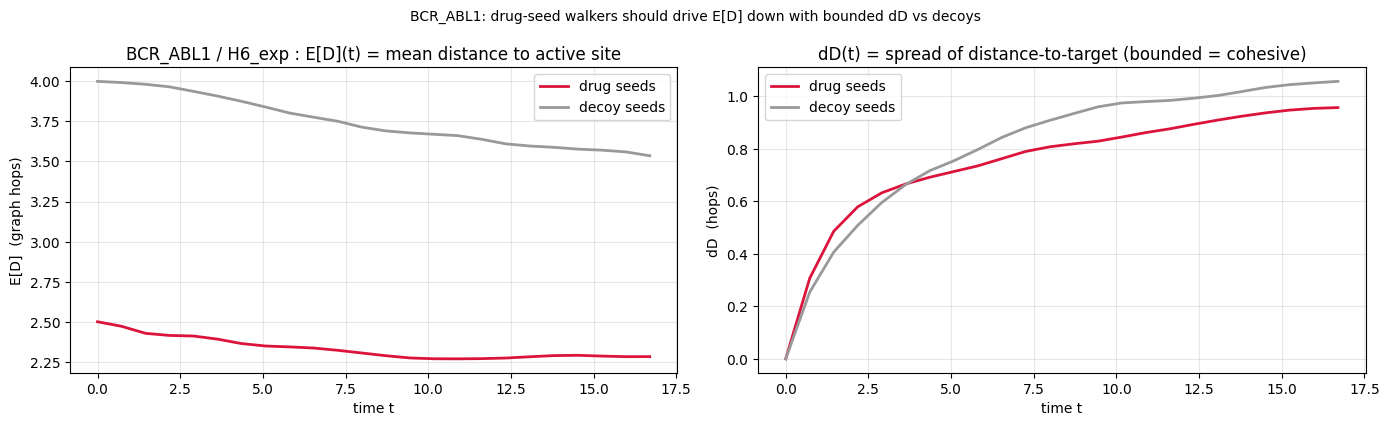

In [750]:
# ===========================================================================
# 14d - DISTANCE-TO-TARGET operator D:  E[D](t) -> 0 and dD(t) bounded = cohesive packet reaching the site
# ---------------------------------------------------------------------------
# D is diagonal with D_ii = graph-hop distance from node i to the active site. As the walk evolves,
# a good allosteric pathway drives E[D] DOWN toward 0 (signal approaches the target) while dD stays
# BOUNDED (the excitation moves as one wave packet, not dispersing). We compare drug-pocket seeds
# vs decoy seeds: the drug group should focus, the decoys should not. VISUALISATION cell.
for name in ACTIVE:
    if name not in VARIANCE_SCORE:
        continue
    vs = VARIANCE_SCORE[name]; op = vs["operator"]; seed = np.array(vs["seed"]); y = vs["in_drug"]
    W = GRAPH[name]["W"]; N = len(W); active_idx = SCORES[name]["active_idx"]
    wv, Vv = _op_eigs(name, op); ts = SCORES[name]["ts"]
    tqv = np.unique(np.linspace(0, len(ts) - 1, min(len(ts), 60)).astype(int)); tsv = ts[tqv]
    Gnx = nx.from_numpy_array((W > 0).astype(int)); hop = {}                 # D_ii = hops to active set
    for a in active_idx:
        for n_, d in nx.single_source_shortest_path_length(Gnx, a).items(): hop[n_] = min(hop.get(n_, 99), d)
    Dvec = np.array([hop.get(i, 99) for i in range(N)], float)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.3))
    for grp, mask, col in [("drug seeds", y > 0.5, "crimson"), ("decoy seeds", y < 0.5, "0.6")]:
        eds, dds = [], []
        for s in seed[mask][:10]:                                           # cap 10/group for speed
            P = walker_dist(wv, Vv, int(s), tsv); ed, dd = dist_moments(P, Dvec); eds.append(ed); dds.append(dd)
        if eds:
            ax1.plot(tsv, np.mean(eds, 0), col, lw=2, label=grp)
            ax2.plot(tsv, np.mean(dds, 0), col, lw=2, label=grp)
    ax1.set_title("%s / %s : E[D](t) = mean distance to active site" % (name, op))
    ax1.set_xlabel("time t"); ax1.set_ylabel("E[D]  (graph hops)"); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.set_title("dD(t) = spread of distance-to-target (bounded = cohesive)")
    ax2.set_xlabel("time t"); ax2.set_ylabel("dD  (hops)"); ax2.legend(); ax2.grid(alpha=0.3)
    fig.suptitle("%s: drug-seed walkers should drive E[D] down with bounded dD vs decoys" % name, fontsize=10)
    fig.tight_layout(); plt.show()


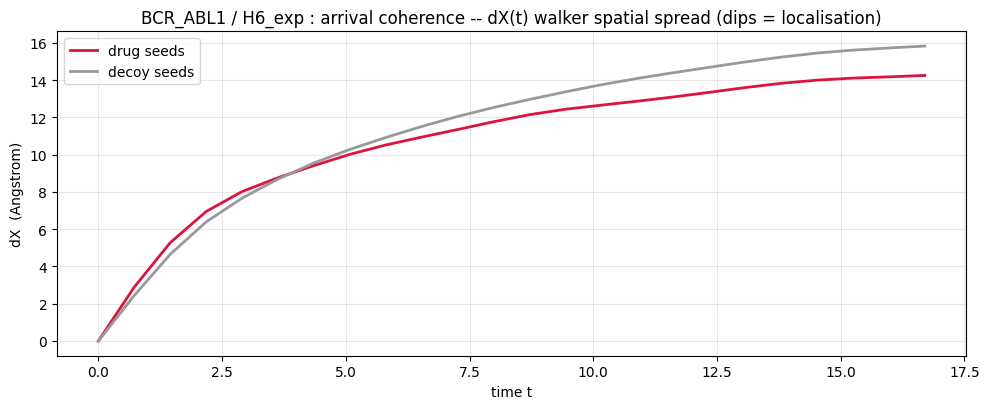

In [751]:
# ===========================================================================
# 14e - ARRIVAL COHERENCE:  dX(t) over time; SHARP DIPS = constructive interference / maximal localisation
# ---------------------------------------------------------------------------
# CTQWs revive (signal hits the site, bounces, returns), so the long-time p_avg smooths out sharp
# coherent arrivals. Tracking the walker's spatial spread dX(t) exposes them: a DIP in dX = the walk
# has (re)focused into a tight packet at that instant -- a moment of constructive interference /
# localisation. Marked with dots. Drug-pocket seeds should show cleaner, deeper dips than decoys.
for name in ACTIVE:
    if name not in VARIANCE_SCORE:
        continue
    vs = VARIANCE_SCORE[name]; op = vs["operator"]; seed = np.array(vs["seed"]); y = vs["in_drug"]
    wv, Vv = _op_eigs(name, op); ts = SCORES[name]["ts"]
    tqv = np.unique(np.linspace(0, len(ts) - 1, min(len(ts), 120)).astype(int)); tsv = ts[tqv]   # fine grid for dips
    coords, _ = _node_coords(name)
    fig, ax = plt.subplots(figsize=(10, 4.2))
    for grp, mask, col in [("drug seeds", y > 0.5, "crimson"), ("decoy seeds", y < 0.5, "0.6")]:
        curves = [spatial_var(walker_dist(wv, Vv, int(s), tsv), coords) for s in seed[mask][:10]]
        if curves:
            m = np.mean(curves, 0); ax.plot(tsv, m, col, lw=2, label=grp)
            dips = [i for i in range(1, len(m) - 1) if m[i] < m[i - 1] and m[i] < m[i + 1]]        # local minima
            ax.plot(tsv[dips], m[dips], "o", color=col, ms=4)
    ax.set_title("%s / %s : arrival coherence -- dX(t) walker spatial spread (dips = localisation)" % (name, op))
    ax.set_xlabel("time t"); ax.set_ylabel("dX  (Angstrom)"); ax.legend(); ax.grid(alpha=0.3)
    fig.tight_layout(); plt.show()


In [752]:
# ===========================================================================
# 14a - NEW SCORE (primary): proximity/degree-corrected residual of the CTQW transfer
# ---------------------------------------------------------------------------
# Keeps p_avg / p_peak / R (sections 14, 14b) UNTOUCHED; here we de-confound p_avg and report
# raw p_avg alongside as the confounded reference. Baseline fit uses ALL residues of the protein
# (so the decay curve is well determined), by QUANTILE regression (median q=0.5) so a genuine
# hotspot cannot drag the line onto itself (OLS fallback if statsmodels absent).
#   PRIMARY model: log(p_avg) ~ dist + degree   (transfer decays ~ exponentially with distance)
#   variant:       raw p_avg    ~ dist + degree
#   dist_i = min Euclidean Ca-Ca distance to the active site ; deg_i = node degree (#contacts)
#   score  = residual (obs - pred); positive = coupled MORE than distance+degree predict.
#   also: local quantile in [0,1] = where the residue sits among residues at the SAME distance.
#   standardise residuals by MEDIAN & MAD (not mean/std) - AUC is rank-based so this does NOT
#   change AUC/P@5, it is only for readability.
# Residuals computed ONLY for the fpocket candidate residues, then RANKED AT POCKET LEVEL
# (pocket score = median residual of its residues) because residue-top-5 often all sit in one pocket.
# Null test: TRUE pocket vs the other fpocket pockets -> rank, percentile, empirical p-value.
# AUC/P@5 reported with a bootstrap CI (few positives). corr(dist,degree) printed for collinearity.
# DRUG_POCKET is scorer-only (labels + null test); it NEVER enters the fit.
from collections import defaultdict

def _fit_quant(yv, X):
    """Median (q=0.5) quantile regression - robust to hotspots. Falls back to OLS if statsmodels absent."""
    try:
        import statsmodels.api as sm
        m = sm.QuantReg(np.asarray(yv, float), np.asarray(X, float)).fit(q=0.5)
        pdeg = float(np.atleast_1d(m.pvalues)[2]) if len(np.atleast_1d(m.pvalues)) > 2 else None
        return np.asarray(m.params, float), pdeg, "QuantReg(median)"
    except Exception:
        beta, *_ = np.linalg.lstsq(X, yv, rcond=None)
        return beta, None, "OLS(fallback)"

def _robust_z(res):
    """Standardise by median & MAD (not mean/std). Rank-based AUC/P@5 are unchanged - readability only."""
    med = np.median(res); mad = np.median(np.abs(res - med))
    return (res - med) / (1.4826 * mad + 1e-12)

def _auc_p5(sv, yy):
    o = np.argsort(-sv); auc = roc_auc_score(yy, sv) if 0 < yy.sum() < len(yy) else float("nan")
    return auc, float(yy[o[:5]].sum()) / 5.0

def _local_quantile(d_s, pa_s, dist_pop, pa_pop, win=2.0, kmin=15):
    """Where p_avg sits among residues at ~the same distance (non-parametric, in [0,1])."""
    m = np.abs(dist_pop - d_s) <= win
    pop = pa_pop[m] if m.sum() >= kmin else pa_pop[np.argsort(np.abs(dist_pop - d_s))[:kmin]]
    return float((pop <= pa_s).mean())

RESIDUAL_SCORE = {}; _BOOT = 1000
for name in ACTIVE:
    if name not in WALKS or not WALKS[name]:
        continue
    def _opbest(o):
        w = WALKS[name][o]; v = [x for x in (w["auc"], w["auc_peak"], w["auc_R"]) if x == x]
        return max(v) if v else -1.0
    op = max(WALKS[name], key=_opbest); w = WALKS[name][op]
    seed = w["seed"]; y = np.array([1.0 if b else 0.0 for b in w["in_drug"]])
    if len(seed) < 3 or not (0 < y.sum() < len(y)):
        print("=== %s : residual score skipped (need >=3 seeds and mixed labels) ===" % name); continue

    r2n = {v_: k for k, v_ in NODE_INDEX[name].items()}; W = GRAPH[name]["W"]; N = len(W)
    active_idx = SCORES[name]["active_idx"]
    if op == "H_new":                                            # p_avg over ALL residues (this operator)
        pavg_all = SCORES[name]["p_avg_mean"]
    else:
        _wo, _Vo = np.linalg.eigh(OPS[name][op]); pavg_all = average_mixing(_wo, _Vo)[:, active_idx].mean(1)
    node_deg = (W > 0).sum(1).astype(float)
    rec = EXTRACT[name]["apo"]; ca = {int(r): np.asarray(c, float) for r, c in zip(rec["resseq"], rec["coords"])}
    Call = np.array([ca.get(r2n[i], np.full(3, np.nan)) for i in range(N)])
    Ac = np.array([ca[r2n[a]] for a in active_idx if r2n[a] in ca])
    dist_all = np.min(np.linalg.norm(Call[:, None, :] - Ac[None, :, :], axis=2), axis=1)

    fitm = np.isfinite(dist_all) & np.isfinite(pavg_all) & (pavg_all > 0)     # fit on ALL valid residues
    dist_f, deg_f, pav_f = dist_all[fitm], node_deg[fitm], pavg_all[fitm]
    cc = float(np.corrcoef(dist_f, deg_f)[0, 1])                              # collinearity check
    X_f = np.column_stack([np.ones(fitm.sum()), dist_f, deg_f])
    b_log, p_deg, meth = _fit_quant(np.log(np.clip(pav_f, 1e-12, None)), X_f)  # PRIMARY: log(p_avg)
    b_raw, _, _ = _fit_quant(pav_f, X_f)                                       # variant: raw p_avg

    # residuals for the fpocket candidate seeds only (model fitted on all residues)
    d_s = np.array([dist_all[s] for s in seed]); g_s = np.array([node_deg[s] for s in seed])
    pa_s = np.array([pavg_all[s] for s in seed]); X_s = np.column_stack([np.ones(len(seed)), d_s, g_s])
    z_log = _robust_z(np.log(np.clip(pa_s, 1e-12, None)) - X_s @ b_log)       # primary score
    z_raw = _robust_z(pa_s - X_s @ b_raw); pred_log = X_s @ b_log             # variant score
    qtl = np.array([_local_quantile(d_s[k], pa_s[k], dist_f, pav_f) for k in range(len(seed))])

    auc_raw, p5_raw = _auc_p5(pa_s, y)                                        # confounded reference
    auc_log, p5_log = _auc_p5(z_log, y); auc_rw, p5_rw = _auc_p5(z_raw, y)
    _rng = np.random.default_rng(0); _a = []; _p = []                         # bootstrap CI (few positives)
    for _ in range(_BOOT):
        ix = _rng.integers(0, len(seed), len(seed)); yy = y[ix]
        if 0 < yy.sum() < len(yy):
            a, pp = _auc_p5(z_log[ix], yy); _a.append(a); _p.append(pp)
    ci = (np.percentile(_a, 2.5), np.percentile(_a, 97.5)) if _a else (float("nan"),) * 2
    p5ci = (np.percentile(_p, 2.5), np.percentile(_p, 97.5)) if _p else (float("nan"),) * 2

    pmem = defaultdict(list)                                                  # pocket-level ranking
    for k, s in enumerate(seed): pmem[SEED_POCKET[name].get(s, "?")].append(k)
    pscore = {pid: float(np.median(z_log[ks])) for pid, ks in pmem.items()}
    pdrug = {pid: float(np.mean(y[ks])) for pid, ks in pmem.items()}
    ranked = sorted(pscore, key=lambda pid: -pscore[pid])
    pcount = {pid: int(np.sum(y[ks])) for pid, ks in pmem.items()}
    true_pid = max(pcount, key=pcount.get) if max(pcount.values()) > 0 else None

    print("=== %s : NEW SCORE = proximity-corrected residual  (operator=%s, %s; fit on %d/%d residues; "
          "%d seeds, %d drug, base=%.2f) ===" % (name, op, meth, int(fitm.sum()), N, len(seed), int(y.sum()), y.mean()))
    _dn = "" if p_deg is None else ("  degree p=%.2f%s" % (p_deg, "" if p_deg < 0.05 else " -> NOT sig: log(p_avg)~dist alone is fine"))
    print("   corr(dist,degree)=%.2f%s | fit: log(p_avg)= %.2e + (%.2e)*dist + (%.2e)*deg%s"
          % (cc, "  COLLINEAR" if abs(cc) > 0.7 else "", b_log[0], b_log[1], b_log[2], _dn))
    print("   RANK BY (residue-level):     AUC    P@5")
    print("     raw p_avg (confounded)     %.3f  %.1f   (reference -- do NOT use)" % (auc_raw, p5_raw))
    print("     residual LOG   (PRIMARY)   %.3f  %.1f   95%%CI AUC[%.2f,%.2f] P@5[%.1f,%.1f]"
          % (auc_log, p5_log, ci[0], ci[1], p5ci[0], p5ci[1]))
    print("     residual RAW   (variant)   %.3f  %.1f" % (auc_rw, p5_rw))
    # incorporate walker spread dX (from 14c): penalise DELOCALISED residues ON TOP of the residual.
    # residual already de-confounds DISTANCE+degree; dX adds the focus/leakiness axis. NEW scores, additive.
    z_log_dx = z_raw_dx = None
    if "VARIANCE_SCORE" in dir() and name in VARIANCE_SCORE and len(VARIANCE_SCORE[name].get("dX", [])) == len(seed):
        _focus = -_robust_z(np.asarray(VARIANCE_SCORE[name]["dX"], float))     # low spread -> high focus
        z_log_dx = z_log + _focus; z_raw_dx = z_raw + _focus                   # residual + focus (equal-weight robust-z)
        auc_ldx, p5_ldx = _auc_p5(z_log_dx, y); auc_rdx, p5_rdx = _auc_p5(z_raw_dx, y)
        print("     residual LOG + dX          %.3f  %.1f   (excess coupling AND focused packet; penalises spread)" % (auc_ldx, p5_ldx))
        print("     residual RAW + dX          %.3f  %.1f" % (auc_rdx, p5_rdx))
    else:
        print("     residual + dX: skipped (VARIANCE_SCORE unavailable / seed mismatch -- run 14c first)")
    print("   POCKET-LEVEL Hit List (pocket score = median residual_z of its seeds):")
    print("     rank pocket  n  med_resid drug_frac")
    for rnk, pid in enumerate(ranked[:6], 1):
        print("     %2d   P%-4s %3d  %+7.2f   %.2f%s" % (rnk, str(pid), len(pmem[pid]), pscore[pid], pdrug[pid],
              "  <- TRUE pocket" if pid == true_pid else ""))
    if true_pid is not None:
        r = ranked.index(true_pid) + 1; n = len(ranked)
        pval = float(np.mean([pscore[pid] >= pscore[true_pid] for pid in pscore]))   # empirical p
        print("   NULL TEST: TRUE pocket P%s ranks %d / %d  (percentile %.0f%%, empirical p=%.3f)"
              % (str(true_pid), r, n, 100.0 * (1 - (r - 1) / max(n - 1, 1)), pval))
    else:
        print("   NULL TEST: no drug residues among scored seeds -> skipped")
    print("   top seeds by residual_z (log):  rk resnum pocket dist deg  p_avg   pred    resid_z  qtl  drug")
    for rk, k in enumerate(np.argsort(-z_log)[:10], 1):
        s = seed[k]
        print("     %2d %-5s P%-3s %5.1f %3d %.1e %.1e %+6.2f  %.2f %s"
              % (rk, r2n[s], str(SEED_POCKET[name].get(s, "?")), d_s[k], int(g_s[k]),
                 pa_s[k], np.exp(pred_log[k]), z_log[k], qtl[k], "DRUG" if y[k] else "-"))
    RESIDUAL_SCORE[name] = dict(operator=op, method=meth, seed=seed, in_drug=y, dist=d_s, deg=g_s,
                                resid_log=z_log, resid_raw=z_raw, qtl=qtl, corr_dist_deg=cc, p_degree=p_deg,
                                beta_log=list(map(float, b_log)), beta_raw=list(map(float, b_raw)),
                                auc_raw=auc_raw, p5_raw=p5_raw, auc_log=auc_log, p5_log=p5_log,
                                auc_ci=ci, p5_ci=p5ci, resid_log_dx=z_log_dx, resid_raw_dx=z_raw_dx,
                                pocket_score=pscore, pocket_rank=ranked, true_pocket=true_pid)


=== BCR_ABL1 : NEW SCORE = proximity-corrected residual  (operator=H6_exp, QuantReg(median); fit on 451/451 residues; 205 seeds, 20 drug, base=0.10) ===
   corr(dist,degree)=-0.27 | fit: log(p_avg)= -5.97e+00 + (-4.79e-02)*dist + (2.33e-02)*deg  degree p=0.00
   RANK BY (residue-level):     AUC    P@5
     raw p_avg (confounded)     0.826  0.6   (reference -- do NOT use)
     residual LOG   (PRIMARY)   0.782  0.8   95%CI AUC[0.67,0.89] P@5[0.4,1.0]
     residual RAW   (variant)   0.785  0.8
     residual LOG + dX          0.785  0.8   (excess coupling AND focused packet; penalises spread)
     residual RAW + dX          0.775  0.8
   POCKET-LEVEL Hit List (pocket score = median residual_z of its seeds):
     rank pocket  n  med_resid drug_frac
      1   P33     4    +1.52   0.50
      2   P22     7    +1.42   0.00
      3   P2     11    +1.11   1.00  <- TRUE pocket
      4   P32    10    +1.10   0.10
      5   P24     6    +0.97   0.00
      6   P27     4    +0.51   0.00
   NULL TEST: 

## 14a2 - TRIVIAL-BASELINE NULL: must the CTQW beat "fpocket + distance filter + random"?

The hardest fair question to ask this project: **is the quantum walk better than the dumbest
defensible pipeline?** That baseline is: take fpocket's pockets → throw away the ones sitting on or
next to the active site (threshold scaled to protein size) → pick among the rest by a simple
property, or at random. If no CTQW variant beats that, the walk is decoration.

**Construction (all pre-registered; no selector ever reads the drug labels):**
1. **candidates** = fpocket pockets that contain at least one CTQW seed (so every method ranks the
   *same* set — the CTQW is already restricted to the top-`N_SEED_POCKETS`, so ranking it against
   pockets it never saw would flatter it).
2. **distance filter**, scaled to protein size: require `hop_min >= h(N)` with
   `h = 1 (N<200), 2 (N<500), 3 (N<1000), 4 (larger)`.
3. **simple selectors** rank the survivors: uniform random (the pure null), fpocket druggability,
   pocket size, distance-from-active-site, and druggability-weighted random (Monte-Carlo).
4. **CTQW variants** rank them too: every Hamiltonian by median seed-rank of `p_avg`, plus the
   proximity-corrected residual from §14a.
5. **metric** = rank of the TRUE drug pocket (1 = best). Under uniform random that rank is uniform
   on `1..M`, so **p = rank / M** exactly — no simulation needed for the pure null. Labels are used
   only to locate the true pocket for scoring, never by a selector.

## 14b - Classical allosteric-site predictors vs the quantum CTQW (SAME conditions)

**Additive block — does NOT modify section 14's output.** Strict parity with the section-14 walk:
the **same weighted graph `W`**, the **same distal fpocket seeds**, the **same active-site reference**,
and the **same firewalled drug-pocket labels**. Only the *operator* changes — `e^{-iHt}` (quantum) vs a
classical operator. DRUG_POCKET is scorer-only; no predictor ever sees it.

Per protein you get: (1) a section-14-style **per-residue table** with the quantum scores
(`p_avg`, `p_peak`, `R=p_peak/p_avg`, `trapped`) **and** the classical scores side by side, then
(2) an **AUC / P@5** comparison and (3) the **best** method.

**Same-condition methods** (each scores a residue by its coupling to the active site, like the CTQW):

| method | operator | reference |
|---|---|---|
| CTQW `p_avg` / `p_peak` / `R` | `e^{-iHt}` average-mixing / peak / ratio | this notebook |
| communicability | `expm(W)` | Estrada & Hatano 2008 |
| gnm_dcc | weighted-GNM cross-correlation | Bahar GNM; Chennubhotla 2007 |
| gnm_prs | weighted-GNM perturbation response `mean(C²)` | Atilgan & Atilgan 2009 |
| commute_time | −effective resistance (weighted Laplacian) | Klein & Randić 1993; Fouss 2007 |

**Active-site-AGNOSTIC controls** (evaluated on the same seeds/labels, but they do *not* share the
seed→active-site condition — shown separately, not counted in the head-to-head):

| control | what it is | reference |
|---|---|---|
| betweenness | global network-bottleneck residues | del Sol et al. 2006 |
| fpocket_drugg | fpocket geometric druggability | Le Guilloux 2009 |

In [753]:
# ===========================================================================
# 14b - CLASSICAL allosteric-site predictors vs the quantum CTQW  (ADDITIVE, SAME conditions)
# ---------------------------------------------------------------------------
# Compares the BEST CTQW operator from section 14 (whichever Hamiltonian won, by AUC across
# p_avg/p_peak/R) against the best classical allosteric predictor. Strict parity: SAME weighted
# graph W, SAME distal fpocket seeds, SAME active-site reference, SAME firewalled drug labels;
# only the operator differs from e^{-iHt}. Prints a section-14-style per-residue table (quantum
# p_avg/p_peak/R + classical scores side by side), then AUC/P@5 and the best method. Controls
# (betweenness, fpocket) are active-site-agnostic and shown separately, not in the head-to-head.

def classical_coupling_scores(W, active_idx):
    """SAME condition as the CTQW: weighted graph W, each residue scored by its coupling to the
    ACTIVE SITE. Only the operator differs from e^{-iHt}. Returns {method: score_vector(N)}."""
    N = len(W); act = np.array(sorted(active_idx)); out = {}
    mu, U = np.linalg.eigh(W)                                     # weighted communicability = expm(W)
    G = (U * np.exp(mu - mu.max())) @ U.T                         # overflow-safe (monotone in rank)
    out["communicability"] = G[:, act].mean(1)                   # Estrada & Hatano 2008
    deg = W.sum(1); L = np.diag(deg) - W                          # weighted Kirchhoff / GNM
    C = np.linalg.pinv(L)                                         # GNM covariance (zero mode dropped)
    d = np.sqrt(np.clip(np.diag(C), 1e-12, None))
    out["gnm_dcc"] = (C / np.outer(d, d))[:, act].mean(1)        # Bahar GNM cross-correlation
    out["gnm_prs"] = (C[:, act] ** 2).mean(1)                    # Atilgan 2009 perturbation response
    dC = np.diag(C)
    out["commute_time"] = -(dC[:, None] + dC[None, :] - 2.0 * C)[:, act].mean(1)  # -effective resistance
    return out


def classical_control_scores(W, name):
    """Active-site-AGNOSTIC controls (do NOT share the seed->active condition of the CTQW)."""
    A = (W > 0).astype(float); np.fill_diagonal(A, 0.0); N = len(A); out = {}
    bc = nx.betweenness_centrality(nx.from_numpy_array(A))        # del Sol 2006 network bottleneck
    out["betweenness"] = np.array([bc[i] for i in range(N)])
    _pd = {p["id"]: p.get("drug", 0.0) for p in CANDIDATE_POCKETS.get(name, [])}
    fp = np.zeros(N)                                              # fpocket druggability of seed's pocket
    for i, pid in SEED_POCKET.get(name, {}).items():
        if i < N: fp[i] = _pd.get(pid, 0.0)
    out["fpocket_drugg"] = fp
    return out


def _auc_p5_arr(sc_seed, y):
    """AUC + P@5 for a score array already aligned to the seed list."""
    s = np.asarray(sc_seed, float); yy = np.asarray(y, float); order = np.argsort(-s)
    auc = roc_auc_score(yy, s) if 0 < yy.sum() < len(yy) else float("nan")
    p5 = float(yy[order[:5]].sum()) / 5.0
    return auc, p5


CLASSICAL = {}
_CPL = ["communicability", "gnm_dcc", "gnm_prs", "commute_time", "heat_kernel"]  # same-condition classical
_CTRL = ["betweenness", "fpocket_drugg"]                              # active-site-agnostic controls
_REF = {"communicability": "Estrada-Hatano expm(W)", "gnm_dcc": "Bahar GNM cross-correlation",
        "gnm_prs": "Atilgan perturbation response", "commute_time": "-effective resistance", "heat_kernel": "e^{-Ht}: classical twin of CTQW (same op, no i)",
        "betweenness": "del Sol network bottleneck", "fpocket_drugg": "fpocket druggability"}

for name in ACTIVE:
    if name not in WALKS or not WALKS[name]:
        continue
    # ---- pick the BEST CTQW operator (max AUC across p_avg/p_peak/R) ----
    def _opbest(o):
        w = WALKS[name][o]; vals = [v for v in (w["auc"], w["auc_peak"], w["auc_R"]) if v == v]
        return max(vals) if vals else -1.0
    best_op = max(WALKS[name], key=_opbest)
    w = WALKS[name][best_op]
    seed = w["seed"]; y = [1.0 if b else 0.0 for b in w["in_drug"]]
    if len(seed) < 2 or not (0 < sum(y) < len(y)):
        print("=== %s : classical-vs-quantum skipped (need >=2 seeds and mixed labels) ===" % name); continue
    pa = np.asarray(w["pa"], float); pk = np.asarray(w["pk_w"], float)   # best operator's per-seed scores
    R = pk / np.clip(pa, 1e-12, None); trapped = w["trapped"]
    sc = SCORES[name]; active_idx = sc["active_idx"]; W = GRAPH[name]["W"]
    r2n = {v: k for k, v in NODE_INDEX[name].items()}

    Gnx = nx.from_numpy_array((W > 0).astype(int)); hop = {}          # graph hops from the active set
    for a in active_idx:
        for n_, dd in nx.single_source_shortest_path_length(Gnx, a).items():
            hop[n_] = min(hop.get(n_, 99), dd)
    cpl = classical_coupling_scores(W, active_idx)                    # same weighted graph W
    # heat kernel e^{-Ht}: CLASSICAL TWIN of the CTQW -- same operator, imaginary unit removed.
    # If this ties the quantum walk, coherence (the "i") is doing no work (the key control).
    _wo, _Vo = (SCORES[name]["w"], SCORES[name]["V"]) if best_op == "H_new" else np.linalg.eigh(OPS[name][best_op])
    _tshk = SCORES[name]["ts"]; _wsh = _wo - min(_wo.min(), 0.0)      # shift only if negative eigenvalues
    _Ehk = np.exp(-np.outer(_tshk, _wsh)); _hk = np.zeros(_Vo.shape[0])
    for _a in active_idx:
        _hk += ((_Vo[_a, :][None, :] * _Ehk) @ _Vo.T).mean(0)        # time-averaged classical occupation on active set
    cpl["heat_kernel"] = _hk
    ctrl = classical_control_scores(W, name)

    base = float(np.mean(y))
    print("=== %s : CLASSICAL vs QUANTUM -- best CTQW operator = %s "
          "(same W, same active site, %d distal seeds, %d in drug, base=%.2f) ==="
          % (name, best_op, len(seed), int(sum(y)), base))
    print("    CTQW operators by best AUC: "
          + ", ".join("%s=%.3f" % (o, _opbest(o)) for o in sorted(WALKS[name], key=_opbest, reverse=True)))

    # -------- section-14-style per-residue table (best operator) + classical side by side --------
    order = list(np.argsort(-pa))
    _SHORT = {"communicability": "comm", "gnm_dcc": "dcc", "gnm_prs": "prs", "commute_time": "cmt"}
    _pct = {}                                                        # per-method percentile rank over the seeds
    for m in _SHORT:                                                 # only the 4 displayed columns (NOT heat_kernel)
        sm = np.array([cpl[m][s] for s in seed]); o = np.argsort(sm)
        r = np.empty(len(sm)); r[o] = np.arange(len(sm)); _pct[m] = r / max(len(sm) - 1, 1)
    best_cls = [max(_SHORT, key=lambda m: _pct[m][k]) for k in range(len(seed))]  # top classical vote per residue
    print("    per-residue (ranked by p_avg, operator=%s) -- QUANTUM (p_avg p_peak R) + CLASSICAL scores;" % best_op)
    print("      best_cls = the CLASSICAL algorithm ranking this residue highest (comm/dcc/prs/cmt, by percentile):")
    print("      rk resnum pk  hop drug  p_avg   p_peak  R      commun  dcc      prs     commute  best_cls trap")
    for rk, k in enumerate(order[:15], 1):
        s = seed[k]
        print("      %2d %-5s P%-2s %-2d %-4s %.1e %.1e %6.1f %.1e %+.1e %.1e %+.1e %-4s %s"
              % (rk, r2n[s], str(SEED_POCKET[name].get(s, "?")), hop.get(s, 99),
                 "DRUG" if y[k] else "-", pa[k], pk[k], min(R[k], 99999.0),
                 cpl["communicability"][s], cpl["gnm_dcc"][s], cpl["gnm_prs"][s], cpl["commute_time"][s],
                 _SHORT[best_cls[k]], "yes" if trapped[k] else ""))

    # -------- AUC / P@5 : best-quantum (3 rankings) + classical (same condition) + controls --------
    q_res = {"p_avg (transfer)": _auc_p5_arr(pa, y),
             "p_peak (max-in-t)": _auc_p5_arr(pk, y),
             "R = p_peak/p_avg": _auc_p5_arr(R, y)}
    # pull the proximity-corrected residual scores from section 14a (same seeds) -> FULL comparison
    if "RESIDUAL_SCORE" in dir() and name in RESIDUAL_SCORE and len(RESIDUAL_SCORE[name].get("resid_log", [])) == len(seed):
        _rs = RESIDUAL_SCORE[name]
        q_res["residual LOG (corrected)"] = _auc_p5_arr(np.asarray(_rs["resid_log"]), y)
        q_res["residual RAW (variant)"] = _auc_p5_arr(np.asarray(_rs["resid_raw"]), y)
        if _rs.get("resid_log_dx") is not None and len(_rs["resid_log_dx"]) == len(seed):
            q_res["residual LOG + dX"] = _auc_p5_arr(np.asarray(_rs["resid_log_dx"]), y)
            q_res["residual RAW + dX"] = _auc_p5_arr(np.asarray(_rs["resid_raw_dx"]), y)
    if "VARIANCE_SCORE" in dir() and name in VARIANCE_SCORE and len(VARIANCE_SCORE[name].get("snr", [])) == len(seed):
        q_res["p_avg/dX (SNR)"] = _auc_p5_arr(np.asarray(VARIANCE_SCORE[name]["snr"]), y)
    c_res = {k: _auc_p5_arr([cpl[k][s] for s in seed], y) for k in _CPL}
    ctrl_res = {k: _auc_p5_arr([ctrl[k][s] for s in seed], y) for k in _CTRL}
    _fin = lambda t: t[0] if t[0] == t[0] else -1.0

    print("    QUANTUM + corrected (best operator = %s) -- rankings incl. proximity-corrected residual:" % best_op)
    for k in ["p_avg (transfer)", "p_peak (max-in-t)", "R = p_peak/p_avg", "p_avg/dX (SNR)",
              "residual LOG (corrected)", "residual RAW (variant)",
              "residual LOG + dX", "residual RAW + dX"]:
        if k in q_res:
            a, pp = q_res[k]; tag = "  <- PRIMARY (de-confounded)" if k == "residual LOG (corrected)" else ""
            print("       %-24s AUC=%.3f  P@5=%.1f%s" % (k, a, pp, tag))
    print("    CLASSICAL (same condition, weighted W):")
    for k in _CPL:
        a, pp = c_res[k]; print("       %-20s AUC=%.3f  P@5=%.1f   (%s)" % (k, a, pp, _REF[k]))
    print("    CONTROLS (active-site-agnostic, not in head-to-head):")
    for k in _CTRL:
        a, pp = ctrl_res[k]; print("       %-20s AUC=%.3f  P@5=%.1f   (%s)" % (k, a, pp, _REF[k]))

    # -------- best of them: best-quantum vs best-classical --------
    bq = max(q_res, key=lambda k: _fin(q_res[k])); bc_ = max(c_res, key=lambda k: _fin(c_res[k]))
    board = {("Q:%s/%s" % (best_op, bq)): q_res[bq], ("C:%s" % bc_): c_res[bc_]}
    best = max(board, key=lambda k: _fin(board[k]))
    verdict = "QUANTUM" if _fin(q_res[bq]) > _fin(c_res[bc_]) else ("CLASSICAL" if _fin(c_res[bc_]) > _fin(q_res[bq]) else "TIE")
    print("    >>> BEST: %s  AUC=%.3f P@5=%.1f   |   head-to-head: %s wins  "
          "(best QUANTUM = %s / %s  AUC=%.3f   vs   best CLASSICAL = %s  AUC=%.3f)   [fpocket control bar=%.3f]"
          % (best, board[best][0], board[best][1], verdict, best_op, bq, q_res[bq][0], bc_, c_res[bc_][0],
             ctrl_res["fpocket_drugg"][0]))
    CLASSICAL[name] = dict(best_op=best_op, quantum=q_res, classical=c_res, controls=ctrl_res,
                           base=base, n_seed=len(seed), best=best)


=== BCR_ABL1 : CLASSICAL vs QUANTUM -- best CTQW operator = H6_exp (same W, same active site, 205 distal seeds, 20 in drug, base=0.10) ===
    CTQW operators by best AUC: H6_exp=0.826, H5_gauss=0.805, H8_gnm=0.775, H12_anmS=0.723, H2_combL=0.715, H9_bfac=0.706, H10_disorder=0.687, H7_harm=0.668, H1_adj=0.654, H11_aniso=0.612, H3_normL=0.609, H4_powL=0.609, H_new=0.600, H14_anmP=0.545
    per-residue (ranked by p_avg, operator=H6_exp) -- QUANTUM (p_avg p_peak R) + CLASSICAL scores;
      best_cls = the CLASSICAL algorithm ranking this residue highest (comm/dcc/prs/cmt, by percentile):
      rk resnum pk  hop drug  p_avg   p_peak  R      commun  dcc      prs     commute  best_cls trap
       1 448   P2  2  DRUG 5.1e-03 8.0e-03    1.6 6.0e-04 -6.8e-03 6.2e-04 -1.0e+00 cmt  yes
       2 512   P2  3  DRUG 4.3e-03 2.2e-02    5.0 1.2e-04 -3.6e-02 8.9e-04 -1.2e+00 cmt  
       3 521   P2  4  DRUG 4.3e-03 5.0e-03    1.2 1.6e-05 -6.6e-02 1.9e-03 -1.3e+00 cmt  
       4 153   P29 3  -    3.9e-03 

## 14f - PRE-REGISTERED TEST: one honest yes/no (no cherry-picking)

Everything is **fixed in advance**, not chosen by looking at the AUC:
- **operator** = `H_new` (the submission operator, *not* best-of-N)
- **signal** = closed-form `p_avg` (average-mixing matrix, T→∞ — **no time window to tune**)
- **score** = proximity-corrected residual (`log(p_avg) ~ dist + degree`, take the residual)
- **null** = label permutation (shuffle which seeds are in the drug pocket)
- **α** = 0.05

A result is **REAL** only if the residual AUC beats the permutation null (`p < α`). Targets are tagged
**TUNED** (the 3 mandatory, seen across many cycles) vs **HELD-OUT** (generalization set, never used to
tune) — the **HELD-OUT** verdicts are the honest test of whether a signal actually exists.

PRE-REGISTERED TEST  (all choices fixed BEFORE looking at the answer):
  operator=H_new | signal=closed-form p_avg (no window) | score=residual(log p_avg ~ dist+deg)
  null=label-permutation x2000 | alpha=0.05


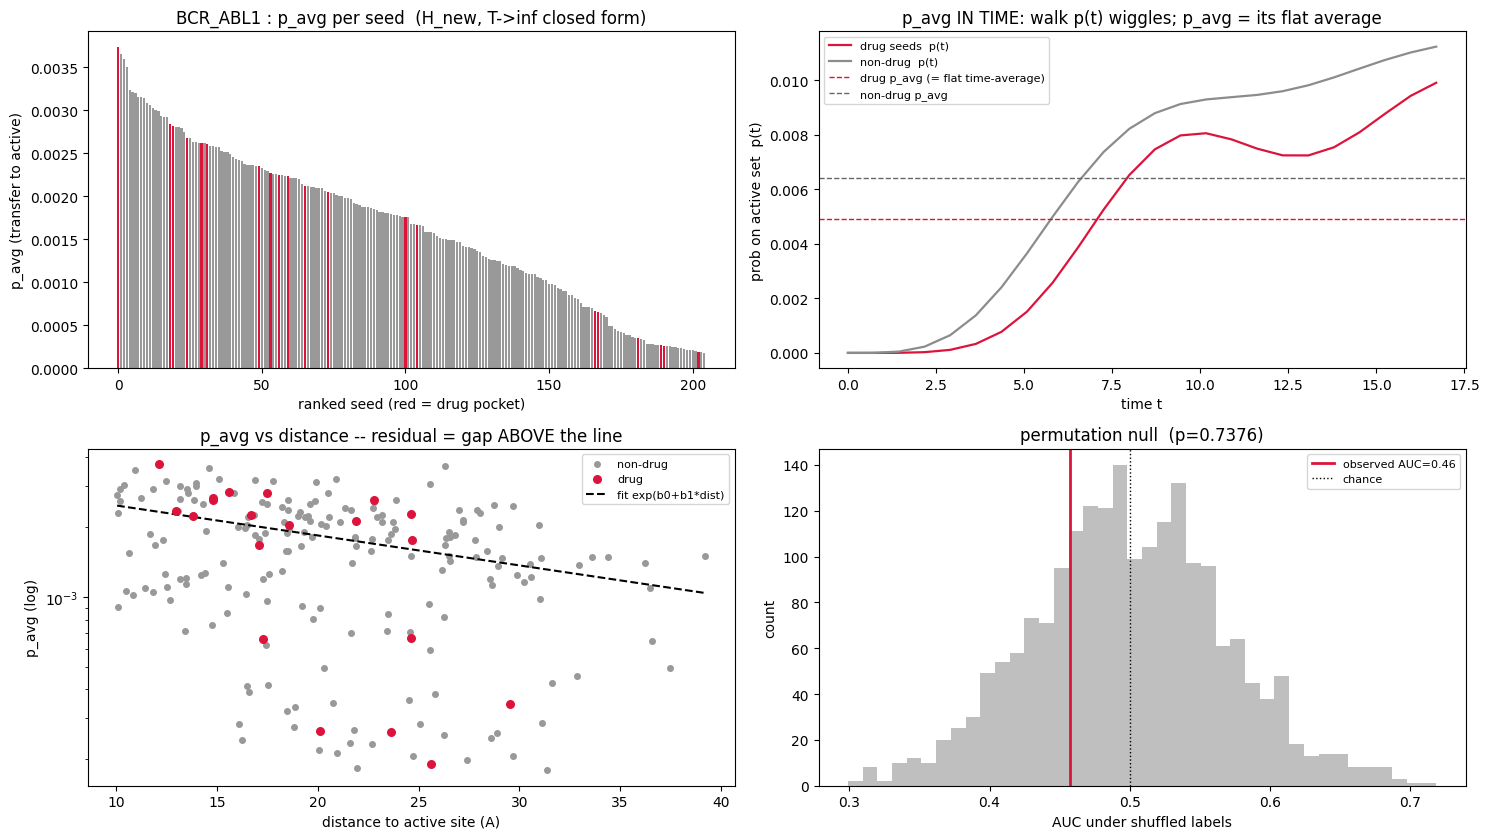

  BCR_ABL1         [TUNED   ] n=205 drug=20  AUC=0.457  null_mean=0.499  p=0.7376  -> noise (indistinct)
----------------------------------------------------------------------------------
  BCR_ABL1 (candidate positive): AUC=0.457  p=0.7376  -> noise (indistinct)
  HELD-OUT generalization: 0/0 beat the null (none)
  HONEST VERDICT: no generalizing signal survives the null -- report as an HONEST NEGATIVE
  (null = LABEL permutation; a distance/degree-matched graph null would be stricter -- see note)


In [754]:
# ===========================================================================
# 14f - PRE-REGISTERED TEST -- fixed choices, permutation null, single honest verdict
# ---------------------------------------------------------------------------
# FIXED IN ADVANCE (not selected on the answer): operator=H_new; signal=closed-form p_avg
# (average mixing, no window); score=residual of log(p_avg) on dist+degree; null=label
# permutation; alpha=0.05. This is the anti-cherry-picking control: no operator/window/score
# is chosen to maximise AUC. HELD-OUT targets (generalization set) are the real test.
PREREG_OPERATOR = "H_new"; PREREG_ALPHA = 0.05; PREREG_N_PERM = 2000
_TUNED = {"KRAS_G12C", "BCR_ABL1", "CARDIAC_MYOSIN"}          # mandatory 3, seen many cycles
_rng_pre = np.random.default_rng(0)

def _prereg_fit(yv, X):                                        # median quantile reg (OLS fallback)
    try:
        import statsmodels.api as sm
        return np.asarray(sm.QuantReg(np.asarray(yv, float), np.asarray(X, float)).fit(q=0.5).params, float), "QuantReg"
    except Exception:
        b, *_ = np.linalg.lstsq(X, yv, rcond=None); return b, "OLS"

def _rz(r):                                                   # robust (median/MAD) standardise
    m = np.median(r); return (r - m) / (1.4826 * np.median(np.abs(r - m)) + 1e-12)

print("=" * 82)
print("PRE-REGISTERED TEST  (all choices fixed BEFORE looking at the answer):")
print("  operator=%s | signal=closed-form p_avg (no window) | score=residual(log p_avg ~ dist+deg)" % PREREG_OPERATOR)
print("  null=label-permutation x%d | alpha=%.2f" % (PREREG_N_PERM, PREREG_ALPHA))
print("=" * 82)

PREREG = {}
for name in ACTIVE:
    if PREREG_OPERATOR not in (WALKS.get(name) or {}) or "p_avg_mean" not in SCORES.get(name, {}):
        print("  %-16s : skipped (no %s walk / no closed-form p_avg)" % (name, PREREG_OPERATOR)); continue
    w = WALKS[name][PREREG_OPERATOR]; seed = np.array(w["seed"]); y = np.array([1.0 if b else 0.0 for b in w["in_drug"]])
    if len(seed) < 3 or not (0 < y.sum() < len(y)):
        print("  %-16s : skipped (need >=3 seeds and mixed labels)" % name); continue
    W = GRAPH[name]["W"]; N = len(W); active_idx = SCORES[name]["active_idx"]
    pavg_all = SCORES[name]["p_avg_mean"]; deg_all = (W > 0).sum(1).astype(float)
    r2n = {v_: k for k, v_ in NODE_INDEX[name].items()}
    rec = EXTRACT[name]["apo"]; ca = {int(r): np.asarray(c, float) for r, c in zip(rec["resseq"], rec["coords"])}
    cen = np.mean(list(ca.values()), axis=0)
    Ac = np.array([ca[r2n[a]] for a in active_idx if r2n[a] in ca])
    dist_all = np.array([np.min(np.linalg.norm(ca.get(r2n[i], cen) - Ac, axis=1)) for i in range(N)])
    fm = np.isfinite(dist_all) & np.isfinite(pavg_all) & (pavg_all > 0)
    Xf = np.column_stack([np.ones(int(fm.sum())), dist_all[fm], deg_all[fm]])
    b, meth = _prereg_fit(np.log(np.clip(pavg_all[fm], 1e-12, None)), Xf)          # fit on ALL residues
    Xs = np.column_stack([np.ones(len(seed)), dist_all[seed], deg_all[seed]])
    score = _rz(np.log(np.clip(pavg_all[seed], 1e-12, None)) - Xs @ b)             # PRE-REGISTERED score
    auc_obs = roc_auc_score(y, score)
    perm = np.array([roc_auc_score(_rng_pre.permutation(y), score) for _ in range(PREREG_N_PERM)])  # label null
    pval = (1 + int(np.sum(perm >= auc_obs))) / (1 + PREREG_N_PERM)

    # ---- plot: p_avg per seed + p_avg IN TIME (the walk) + p_avg-vs-distance fit + permutation null ----
    import matplotlib.pyplot as plt
    _pa = pavg_all[seed]; _d = dist_all[seed]; _dr = y > 0.5; _o = np.argsort(-_pa)
    _wv, _Vv = (SCORES[name]["w"], SCORES[name]["V"]) if PREREG_OPERATOR == "H_new" else np.linalg.eigh(OPS[name][PREREG_OPERATOR])
    _ts = SCORES[name]["ts"]; _Pt = prob_on_active_over_time(_wv, _Vv, active_idx, _ts)   # (T,N) prob on active over time
    _Pd = _Pt[:, seed[_dr]].mean(1); _Pn = _Pt[:, seed[~_dr]].mean(1)                      # mean p(t) over drug / non-drug
    fig, ((axA, axT), (axB, axC)) = plt.subplots(2, 2, figsize=(15, 8.5))
    # A: p_avg per seed (T->inf, ranked)
    axA.bar(range(len(seed)), _pa[_o], color=["crimson" if _dr[k] else "0.6" for k in _o])
    axA.set_title("%s : p_avg per seed  (%s, T->inf closed form)" % (name, PREREG_OPERATOR))
    axA.set_xlabel("ranked seed (red = drug pocket)"); axA.set_ylabel("p_avg (transfer to active)")
    # T: p_avg IN TIME -- the walk p(t); p_avg is its flat long-time average
    axT.plot(_ts, _Pd, "crimson", lw=1.6, label="drug seeds  p(t)")
    axT.plot(_ts, _Pn, "0.55", lw=1.6, label="non-drug  p(t)")
    axT.axhline(_Pd.mean(), color="crimson", ls="--", lw=1.0, label="drug p_avg (= flat time-average)")
    axT.axhline(_Pn.mean(), color="0.4", ls="--", lw=1.0, label="non-drug p_avg")
    axT.set_xlabel("time t"); axT.set_ylabel("prob on active set  p(t)")
    axT.set_title("p_avg IN TIME: walk p(t) wiggles; p_avg = its flat average"); axT.legend(fontsize=8)
    # B: p_avg vs distance + fitted decay (residual = gap above the line)
    axB.scatter(_d[~_dr], _pa[~_dr], c="0.6", s=16, label="non-drug")
    axB.scatter(_d[_dr], _pa[_dr], c="crimson", s=30, label="drug", zorder=3)
    _xx = np.linspace(_d.min(), _d.max(), 60)
    axB.plot(_xx, np.exp(b[0] + b[1] * _xx + b[2] * deg_all[seed].mean()), "k--", lw=1.5, label="fit exp(b0+b1*dist)")
    axB.set_yscale("log"); axB.set_xlabel("distance to active site (A)"); axB.set_ylabel("p_avg (log)")
    axB.set_title("p_avg vs distance -- residual = gap ABOVE the line"); axB.legend(fontsize=8)
    # C: permutation null
    axC.hist(perm, bins=40, color="0.75")
    axC.axvline(auc_obs, color="crimson", lw=2, label="observed AUC=%.2f" % auc_obs)
    axC.axvline(0.5, color="k", ls=":", lw=1, label="chance")
    axC.set_title("permutation null  (p=%.4f)" % pval); axC.set_xlabel("AUC under shuffled labels")
    axC.set_ylabel("count"); axC.legend(fontsize=8)
    fig.tight_layout(); plt.show()

    verdict = "REAL (beats null)" if pval < PREREG_ALPHA else "noise (indistinct)"
    tag = "TUNED   " if name in _TUNED else "HELD-OUT"
    print("  %-16s [%s] n=%2d drug=%2d  AUC=%.3f  null_mean=%.3f  p=%.4f  -> %s"
          % (name, tag, len(seed), int(y.sum()), auc_obs, perm.mean(), pval, verdict))
    PREREG[name] = dict(operator=PREREG_OPERATOR, fit=meth, auc=float(auc_obs), p=float(pval),
                        n_seed=int(len(seed)), n_drug=int(y.sum()), held_out=name not in _TUNED, verdict=verdict)

# ---- single honest bottom line ----
print("-" * 82)
if "BCR_ABL1" in PREREG:
    _b = PREREG["BCR_ABL1"]; print("  BCR_ABL1 (candidate positive): AUC=%.3f  p=%.4f  -> %s" % (_b["auc"], _b["p"], _b["verdict"]))
_held = [n for n in PREREG if PREREG[n]["held_out"]]
_held_pass = [n for n in _held if PREREG[n]["p"] < PREREG_ALPHA]
print("  HELD-OUT generalization: %d/%d beat the null%s" % (len(_held_pass), len(_held),
      ("  ->  " + ", ".join(_held_pass)) if _held_pass else " (none)"))
print("  HONEST VERDICT: %s" % ("a signal generalizes to held-out targets -- DEFENSIBLE POSITIVE"
      if _held_pass else "no generalizing signal survives the null -- report as an HONEST NEGATIVE"))
print("  (null = LABEL permutation; a distance/degree-matched graph null would be stricter -- see note)")
print("=" * 82)


## 15 - CTQW with dephasing (Haken-Strobl / ENAQT)

Lindblad pure dephasing in the site basis, gamma swept 0 upward (split-step, time-averaged). **Key output:** seeds whose transfer to the active set *rises* with gamma - those were suppressed by destructive interference in the unitary walk (false negatives), and calibrated dephasing reopens the path. Run on a **documented subset** (fpocket candidate-pocket seeds, most-localised first) for KRAS + BCR_ABL1; myosin (N=954) and MYC are skipped for tractability (stated, not silent).

In [755]:
# ===========================================================================
# 15 - CTQW with dephasing (Haken-Strobl pure dephasing / ENAQT)
# ---------------------------------------------------------------------------
# Lindblad pure dephasing in the SITE basis: drho/dt = -i[H,rho] - gamma*(rho-diag rho)
# (off-diagonals decay at rate gamma). Integrated by a Trotter split-step -- one
# unitary step e^{-iH dt} then off-diagonal damping e^{-gamma dt} -- and time-averaged.
# KEY OUTPUT: seeds whose transfer to the active set RISES as gamma increases. Those
# were suppressed by destructive interference in the unitary walk (sec 14 false
# negatives / Anderson-localised), and calibrated dephasing reopens the path (ENAQT).
#
# TRACTABILITY CAP (documented, not silent): the density matrix is O(N^2) and the
# split-step is O(N^3)/step, so the full all-node sweep is infeasible in-notebook.
# We run a DOCUMENTED SUBSET -- the fpocket candidate-pocket seeds (what we ultimately
# rank), preferentially the localised ones -- on KRAS_G12C + BCR_ABL1 only; myosin
# (N=954) and MYC (no active site) are skipped and reported as skipped.
MAX_DEPH_SEEDS = 16
N_STEPS_DEPH   = 60
GAMMA_FRACS    = np.array([0.0, 0.02, 0.1, 0.5])   # gamma = frac * |lambda|max (pre-registered sweep)
DEPH_TARGETS   = [n for n in ("KRAS_G12C", "BCR_ABL1") if n in ACTIVE]
print("PRE-REGISTERED (sec 15): gamma/|lambda|max in %s, %d steps, <=%d seeds; targets=%s (others skipped: tractability)"
      % (GAMMA_FRACS.tolist(), N_STEPS_DEPH, MAX_DEPH_SEEDS, DEPH_TARGETS))


def dephased_active_avg(w, V, active_idx, seeds, gammas, T, n_steps):
    """Time-averaged population on the active set from each seed, per gamma.
    Split-step: rho <- U_dt rho U_dt^H ; off-diagonals *= exp(-gamma dt). O(N^3)/step."""
    N = len(w); dt = T / n_steps
    Udt = (V * np.exp(-1j * w * dt)) @ V.T          # V real-orthogonal
    out = {int(s): np.zeros(len(gammas)) for s in seeds}
    for gi, gam in enumerate(gammas):
        decay = np.exp(-gam * dt)
        for s in seeds:
            rho = np.zeros((N, N), complex); rho[s, s] = 1.0
            acc = 0.0
            for _ in range(n_steps):
                rho = Udt @ rho @ Udt.conj().T
                d = np.diag(rho).copy()
                rho *= decay                         # damp all entries...
                np.fill_diagonal(rho, d)             # ...then restore populations (diagonal)
                acc += float(np.real(d[active_idx].sum()))
            out[int(s)][gi] = acc / n_steps
    return out


DEPHASING = {}   # name -> dict(seeds, gammas, table, risers)
for name in ACTIVE:
    S = SCORES[name]
    if name not in DEPH_TARGETS or not S.get("active_idx"):
        DEPHASING[name] = dict(skipped=True,
                               reason="no active site" if not S.get("active_idx") else "tractability (N large)")
        print("=== %s : dephasing SKIPPED (%s) ===" % (name, DEPHASING[name]["reason"]))
        continue
    w, V, active_idx = S["w"], S["V"], S["active_idx"]
    lam_max = GRAPH[name]["lam1"]; gammas = GAMMA_FRACS * lam_max

    # subset = fpocket candidate-pocket seeds, preferring the localised ones (highest trap)
    pool = sorted({i for p in CANDIDATE_POCKETS.get(name, []) for i in p["residues_idx"]})
    pool = [i for i in pool if i not in set(active_idx)]                 # exclude the target itself
    pool = sorted(pool, key=lambda i: -S["trap"][i])[:MAX_DEPH_SEEDS]    # most-trapped first

    tab = dephased_active_avg(w, V, active_idx, pool, gammas, S["T_max"], N_STEPS_DEPH)
    # a "riser" = a seed whose best dephased transfer beats its unitary (gamma=0) value
    risers = []
    for s in pool:
        base = tab[s][0]; best = tab[s].max(); bg = int(np.argmax(tab[s]))
        if best > base * 1.05 and bg > 0:
            risers.append((s, base, best, gammas[bg], (best - base) / (base + 1e-12)))
    risers.sort(key=lambda r: -r[4])
    DEPHASING[name] = dict(skipped=False, seeds=pool, gammas=gammas, table=tab, risers=risers)

    print("=== %s : dephasing on %d candidate-pocket seeds, gamma up to %.2f ===" % (name, len(pool), gammas[-1]))
    print("    ENAQT risers (unitary-suppressed, recover with gamma): %d/%d" % (len(risers), len(pool)))
    for s, base, best, gbest, flip in risers[:6]:
        print("      node %4d: p(gamma=0)=%.3e -> peak %.3e at gamma=%.2f  (+%.0f%%)"
              % (s, base, best, gbest, 100 * flip))

PRE-REGISTERED (sec 15): gamma/|lambda|max in [0.0, 0.02, 0.1, 0.5], 60 steps, <=16 seeds; targets=['BCR_ABL1'] (others skipped: tractability)
=== BCR_ABL1 : dephasing on 16 candidate-pocket seeds, gamma up to 1.06 ===
    ENAQT risers (unitary-suppressed, recover with gamma): 2/16
      node    7: p(gamma=0)=2.088e-04 -> peak 2.456e-04 at gamma=0.04  (+18%)
      node    8: p(gamma=0)=4.834e-04 -> peak 5.090e-04 at gamma=0.04  (+5%)


## 16-17 - Aggregation to pockets

Section 14 already seeded the CTQW one residue at a time and scored each residue by transfer to the active site. Here we **aggregate those residue scores up to the pocket level**: the top-K candidate pockets (active-site pocket excluded) are ranked by **mean** and **max** CTQW transfer over their residues - the pocket-level Hit List scored in sec 20.

*Trade-off (documented in sec 14):* seeding only from fpocket means a closed cryptic pocket fpocket misses in apo cannot be recovered - the price of using fpocket as the candidate filter.

In [756]:
# ===========================================================================
# 16-17 - Aggregation to pockets  (seeding + per-residue walk are done in sec 14)
# ---------------------------------------------------------------------------
# Section 14 already seeded the CTQW one residue at a time from the top-K fpocket
# pockets and produced the per-residue transfer scores (RESIDUE_SCORE, SEED_IDX).
# Here we aggregate those residue scores UP to the pocket level: rank the top-K
# candidate pockets (active-site pocket excluded) by mean and max CTQW transfer to
# the active site -- this is the pocket-level Hit List scored in sec 20.
POCKET_SCORE = {}
for name in ACTIVE:
    S = SCORES[name]
    if not S.get("active_idx") or name not in SEED_IDX:
        continue
    N = len(S["M"]); primary = RESIDUE_SCORE[name]["primary"]
    act_id = ACTIVE_POCKET.get(name); topK = CANDIDATE_POCKETS.get(name, [])[:N_SEED_POCKETS]
    rows = []
    for p in topK:
        if p["id"] == act_id:
            continue
        idx = [i for i in p["residues_idx"] if i < N]
        if not idx:
            continue
        rows.append(dict(id=p["id"], drug=p.get("drug", 0.0), n_res=len(idx),
                         score_mean=float(primary[idx].mean()), score_max=float(primary[idx].max()),
                         residues_idx=idx))
    rows.sort(key=lambda r: -r["score_mean"])
    POCKET_SCORE[name] = rows
    print("=== %s : %d candidate pockets (active-site pocket P%s excluded) ranked by mean CTQW transfer ==="
          % (name, len(rows), act_id))
    for r in rows[:3]:
        print("    P%-3d drugg=%.3f  n=%d  score_mean=%.3e  score_max=%.3e"
              % (r["id"], r["drug"], r["n_res"], r["score_mean"], r["score_max"]))

=== BCR_ABL1 : 36 candidate pockets (active-site pocket P1 excluded) ranked by mean CTQW transfer ===
    P9   drugg=0.000  n=13  score_mean=4.682e-03  score_max=1.551e-02
    P34  drugg=0.000  n=12  score_mean=3.741e-03  score_max=5.843e-03
    P30  drugg=0.000  n=8  score_mean=3.474e-03  score_max=9.832e-03


## 18 - Confound controls (REQUIRED)

Is the score allosteric signal or just geometry? (1) score vs **geodesic and Euclidean distance** to the active site -> R^2; (2) score vs **degree** -> Spearman; (3) the reported score is the **distance+degree-matched quantile** (a residue cannot win by proximity or hubness alone); (4) **permutation null** (shuffle node labels) -> p-value. The quantile uses only distance+degree; the null uses the firewalled pocket only to score.

In [757]:
# ===========================================================================
# 18 - Confound controls (REQUIRED) -- over the fpocket SEED set
# ---------------------------------------------------------------------------
# Same controls as before, but restricted to the fpocket candidate seeds (sec 16):
# is a candidate residue's transfer to the active site allosteric signal, or just its
# distance/degree? (1) score vs geodesic + Euclidean distance to the active site -> R^2;
# (2) score vs degree -> Spearman; (3) distance+degree-matched QUANTILE within the seed
# set is the reported score; (4) permutation null over the seeds. The label is
# "seed residue is in the drug pocket"; the quantile uses only distance+degree.
import networkx as nx
np.random.seed(0)
N_PERM = 1000

def _r2(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    return float(pearsonr(x[m], y[m])[0] ** 2) if m.sum() >= 3 else float("nan")

def _matched_quantile(score, dist, degree, nb=4):
    n = len(score); q = np.full(n, 0.5)
    dq = np.quantile(dist, np.linspace(0, 1, nb + 1)[1:-1]) if len(dist) else np.array([])
    gq = np.quantile(degree, np.linspace(0, 1, nb + 1)[1:-1])
    dbin = np.digitize(dist, dq); gbin = np.digitize(degree, gq)
    for b in set(zip(dbin.tolist(), gbin.tolist())):
        m = (dbin == b[0]) & (gbin == b[1])
        if m.sum() > 1:
            q[m] = score[m].argsort().argsort() / (m.sum() - 1)
    return q

CONFOUND  = {}
RESIDUE_Q = {}     # name -> distance+degree-matched quantile over the seed set (reported score)
for name in ACTIVE:
    S = SCORES[name]
    seed = SEED_IDX.get(name, [])
    if not S.get("active_idx") or len(seed) < 5:
        continue
    coords = GRAPH[name]["coords"]; degree_all = GRAPH[name]["degree"]; active = S["active_idx"]
    primary = RESIDUE_SCORE[name]["primary"]

    dist_euc_all = cdist(coords, coords[active]).min(1)
    G = nx.from_numpy_array((GRAPH[name]["W"] > 0).astype(int))
    geo = {}
    for a in active:
        for n_, d in nx.single_source_shortest_path_length(G, a).items():
            geo[n_] = min(geo.get(n_, 1e9), d)
    dist_geo_all = np.array([geo.get(i, np.nan) for i in range(len(primary))], float)

    seed = np.array(seed)
    sc = primary[seed]; de = dist_euc_all[seed]; dg = dist_geo_all[seed]; deg = degree_all[seed]
    r2_euc = _r2(sc, de); r2_geo = _r2(sc, dg); rho_deg = float(spearmanr(sc, deg)[0])
    q_seed = _matched_quantile(sc, np.nan_to_num(dg, nan=np.nanmax(dg)), deg)
    q_full = np.zeros(len(primary)); q_full[seed] = q_seed
    RESIDUE_Q[name] = q_full

    perm = {}
    drug = DRUG_POCKET.get(name, {}).get("residues_apo", [])
    didx = set(NODE_INDEX[name][r] for r in drug if r in NODE_INDEX[name])
    y = np.array([1.0 if i in didx else 0.0 for i in seed])
    if 0 < y.sum() < len(y):
        obs = roc_auc_score(y, sc); obsq = roc_auc_score(y, q_seed)
        null = np.array([roc_auc_score(y, np.random.permutation(sc)) for _ in range(N_PERM)])
        perm = dict(auc_raw=float(obs), auc_quantile=float(obsq), null_mean=float(null.mean()),
                    null_p95=float(np.quantile(null, 0.95)), p_value=float((np.sum(null >= obs) + 1) / (N_PERM + 1)))

    CONFOUND[name] = dict(seed=seed, dist_euc=de, dist_geo=dg, degree=deg,
                          r2_euc=r2_euc, r2_geo=r2_geo, rho_deg=rho_deg, perm=perm)
    print("=== %s : confound controls over %d fpocket seeds ===" % (name, len(seed)))
    print("    R^2(score vs Euclid)=%.3f  R^2(score vs geodesic)=%.3f  Spearman(score,degree)=%+.3f"
          % (r2_euc, r2_geo, rho_deg))
    if perm:
        print("    seed-AUC raw=%.3f  quantile=%.3f | perm-null mean=%.3f p95=%.3f  p=%.4f"
              % (perm["auc_raw"], perm["auc_quantile"], perm["null_mean"], perm["null_p95"], perm["p_value"]))
        if perm["auc_raw"] > 0.6 and perm["auc_quantile"] < 0.55:
            print("    >> WARNING: raw signal collapses after distance+degree matching -> geometry, not coupling.")

=== BCR_ABL1 : confound controls over 242 fpocket seeds ===
    R^2(score vs Euclid)=0.304  R^2(score vs geodesic)=0.331  Spearman(score,degree)=+0.446
    seed-AUC raw=0.500  quantile=0.511 | perm-null mean=0.501 p95=0.609  p=0.5155


## 19 - Classical baselines (REQUIRED)

Same graph, same target: **eigenvector centrality**, **heat kernel** `exp(-Lt)`, **Estrada communicability** `exp(A)`, **elastic-wave** `exp(-i sqrt(L) t)` (its time-average mixing = the CTQW readout on the *bare* graph = `H_base`). Spearman rho + top-5 Jaccard vs the CTQW; **if rho>0.9, stated plainly** - the quantum ranking would then be a classical quantity in disguise.

In [758]:
# ===========================================================================
# 19 - Classical baselines (REQUIRED)  -- same graph, same active-site target
# ---------------------------------------------------------------------------
# The honest question: is the quantum walk doing anything a classical propagator on
# the SAME graph does not? Four classical scores, each compared to the CTQW p_avg by
# Spearman rho and top-5 Jaccard. If rho > 0.9 against any of them, we STATE IT PLAINLY
# -- the "quantum" ranking would then be a classical quantity in disguise.
#   * eigenvector centrality  (leading eigenvector of the weighted adjacency W)
#   * heat kernel exp(-L t)   (classical diffusion; L = normalised Laplacian)
#   * Estrada communicability exp(A)  (sum of all walks; A = binary adjacency)
#   * elastic-wave exp(-i sqrt(L) t)  (real-frequency wave; its time-average mixing =
#       average_mixing(L) -- the CTQW readout on the BARE graph, i.e. H_new with no
#       potentials -> a direct test of whether the site potentials add anything)
T_HEAT_FACTOR = 1.0        # t_heat = T_HEAT_FACTOR / spectral_gap  (one mixing time; pre-registered)

def _jaccard_top(a, b, k=5):
    sa, sb = set(np.argsort(-a)[:k]), set(np.argsort(-b)[:k])
    return len(sa & sb) / len(sa | sb)

BASELINES = {}     # name -> dict(scores{...}, rho{...}, jac{...})
for name in ACTIVE:
    S = SCORES[name]
    if not S.get("active_idx"):
        continue
    N = len(S["M"]); active = S["active_idx"]
    seed = SEED_IDX.get(name, [])                       # correlate over the fpocket seed set (sec 16)
    if len(seed) < 5:
        continue
    amask = np.zeros(N, bool); amask[np.array(seed)] = True
    W = GRAPH[name]["W"]; ctqw = RESIDUE_SCORE[name]["primary"]

    # eigenvector centrality (leading eigenvector of W)
    wv, Vv = np.linalg.eigh(W)
    eigcent = np.abs(Vv[:, -1])

    # heat kernel exp(-L t): score to active set
    L = GRAPH[name]["L"]; wl, Vl = np.linalg.eigh(L)
    t_heat = T_HEAT_FACTOR / max(GRAPH[name]["gap"], 1e-4)
    HK = (Vl * np.exp(-wl * t_heat)) @ Vl.T
    heat = HK[:, active].sum(1)

    # Estrada communicability exp(A) (rescaled for numerical stability; ranking-preserving)
    A = (W > 0).astype(float); wa, Va = np.linalg.eigh(A)
    Gc = (Va * np.exp(wa - wa.max())) @ Va.T
    comm = Gc[:, active].sum(1)

    # elastic-wave exp(-i sqrt(L) t): long-time mixing = average_mixing on L
    Mw = average_mixing(wl, Vl)
    wave = Mw[:, active].sum(1)

    scores = dict(eig_centrality=eigcent, heat_kernel=heat, communicability=comm, elastic_wave=wave)
    rho = {k: float(spearmanr(v[amask], ctqw[amask])[0]) for k, v in scores.items()}
    jac = {k: _jaccard_top(np.where(amask, v, -np.inf), np.where(amask, ctqw, -np.inf)) for k, v in scores.items()}
    BASELINES[name] = dict(scores=scores, rho=rho, jac=jac, t_heat=t_heat)

    print("=== %s : CTQW(p_avg) vs classical baselines (same graph) ===" % name)
    for k in scores:
        flag = "  <== rho>0.9: CTQW ~ this classical score" if rho[k] > 0.9 else ""
        print("    %-16s Spearman rho=%+.3f   top5-Jaccard=%.2f%s" % (k, rho[k], jac[k], flag))

=== BCR_ABL1 : CTQW(p_avg) vs classical baselines (same graph) ===
    eig_centrality   Spearman rho=+0.481   top5-Jaccard=0.00
    heat_kernel      Spearman rho=+0.468   top5-Jaccard=0.43
    communicability  Spearman rho=+0.600   top5-Jaccard=0.00
    elastic_wave     Spearman rho=+0.611   top5-Jaccard=0.67


## 20 - Metrics (vs `DRUG_POCKET`, firewalled, per target)

Residue-level **ROC-AUC** (PocketMiner reference ~0.87) and the pocket-level **P@5** hit list (challenge deliverable), for CTQW raw / CTQW quantile / `H_base` ablation / fpocket / classical baselines. **Per target, never pooled.** Caveats carried in the table: BCR_ABL1's MYR is pre-bound in apo (not cryptic -> not a blind prediction); myosin's pocket is cross-species-mapped.

**Operator benchmark:** the CTQW average-mixing readout is run on **every** Hamiltonian (H1-H10 + H_new), each scored by the same firewalled AUC/P@5, so the connectivity-only and B-factor operators are compared head-to-head with H_new against the fpocket bar - which of H1-H10 makes the best CTQW operator, and whether any beats classical geometry.

In [759]:
# ===========================================================================
# 20 - Metrics over the fpocket SEED set  (DRUG_POCKET firewalled, scorer-only)
# ---------------------------------------------------------------------------
# The candidate set is the fpocket seeds (sec 16). Residue-level ROC-AUC now asks the
# focused question: among fpocket candidate residues, does the CTQW rank the DRUG-POCKET
# ones above the other candidates? Plus the pocket-level P@5 hit list (challenge
# deliverable): rank the candidate pockets (active-site pocket excluded) by CTQW transfer
# and check whether the true drug pocket is in the top 5. Scored for CTQW raw / CTQW
# distance+degree quantile / H_base ablation / fpocket / classical baselines.
# CAVEATS: BCR_ABL1 MYR pre-bound (not cryptic); myosin cross-species map.
CAVEAT = {"BCR_ABL1": "MYR pre-bound in apo -> not cryptic, not a blind prediction",
          "CARDIAC_MYOSIN": "cross-species pocket map (5TBY apo <- 8QYR holo)"}

def _auc(y, s):
    return float(roc_auc_score(y, s)) if 0 < y.sum() < len(y) else float("nan")

def _p5_seed(score, seed, didx):
    top5 = sorted(seed, key=lambda i: -score[i])[:5]
    return sum(i in set(didx) for i in top5) / 5.0, top5

METRICS = {}
rows_summary = []
for name in ACTIVE:
    S = SCORES[name]; seed = list(SEED_IDX.get(name, []))
    drug = DRUG_POCKET.get(name, {}).get("residues_apo", [])
    didx = sorted(NODE_INDEX[name][r] for r in drug if r in NODE_INDEX[name])
    if not S.get("active_idx") or not didx or len(seed) < 5:
        print("=== %s : no fpocket-seed metric (missing active/pocket/seeds) ===" % name)
        continue
    seed = np.array(seed); N = len(S["M"])
    y = np.array([1.0 if i in set(didx) else 0.0 for i in seed])
    n_pos = int(y.sum())

    B = BASELINES[name]["scores"]
    fp = np.zeros(N)
    for p in CANDIDATE_POCKETS.get(name, []):
        for i in p["residues_idx"]:
            if i < N:
                fp[i] = max(fp[i], p.get("drug", 0.0))
    cand = {"CTQW_raw": RESIDUE_SCORE[name]["primary"], "CTQW_quantile": RESIDUE_Q[name],
            "elastic_wave(H_base)": B["elastic_wave"], "communicability": B["communicability"],
            "eig_centrality": B["eig_centrality"], "fpocket": fp}
    aucs = {k: _auc(y, s[seed]) for k, s in cand.items()}
    p5s = {k: _p5_seed(s, seed, didx)[0] for k, s in cand.items()}

    ranked = POCKET_SCORE[name]                     # candidate pockets (active-site pocket already excluded)
    cov = lambda r: len(set(r["residues_idx"]) & set(didx))
    drug_rank = next((i + 1 for i, r in enumerate(ranked) if cov(r) >= 3), None)
    top5_hit = any(cov(r) >= 3 for r in ranked[:5])

    METRICS[name] = dict(auc=aucs, p5=p5s, drug_pocket_rank_by_CTQW=drug_rank, top5_pocket_hit=top5_hit,
                         n_seeds=len(seed), n_pos=n_pos, caveat=CAVEAT.get(name, ""))
    rows_summary.append(dict(target=name, seeds=len(seed), pocket_in_seeds=n_pos,
                             AUC_CTQW=round(aucs["CTQW_raw"], 3), AUC_CTQWq=round(aucs["CTQW_quantile"], 3),
                             AUC_fpocket=round(aucs["fpocket"], 3), P5_CTQW=p5s["CTQW_raw"],
                             drugpocket_rank=drug_rank, n_pockets=len(ranked)))

    print("=== %s  (%d fpocket seeds, %d in drug pocket)%s ===" % (name, len(seed), n_pos,
          "  [CAVEAT: %s]" % CAVEAT[name] if name in CAVEAT else ""))
    print("    seed-level ROC-AUC:  " + "  ".join("%s=%.3f" % (k, v) for k, v in aucs.items()))
    print("    seed-level P@5:      " + "  ".join("%s=%.1f" % (k, v) for k, v in p5s.items()))
    print("    pocket-level: drug pocket ranked #%s of %d candidate pockets by CTQW; in top-5? %s"
          % (drug_rank, len(ranked), top5_hit))

import pandas as pd
metrics_summary = pd.DataFrame(rows_summary)
print("\n===== METRICS SUMMARY (fpocket-seed set; DRUG_POCKET firewalled) =====")
print(metrics_summary.to_string(index=False))

# ---- OPERATOR BENCHMARK over the fpocket seeds: CTQW on every Hamiltonian ------
OPERATOR_BENCH = {}
for name in ACTIVE:
    S = SCORES[name]; seed = list(SEED_IDX.get(name, []))
    drug = DRUG_POCKET.get(name, {}).get("residues_apo", [])
    didx = sorted(NODE_INDEX[name][r] for r in drug if r in NODE_INDEX[name])
    if not S.get("active_idx") or not didx or len(seed) < 5:
        continue
    seed = np.array(seed); active = S["active_idx"]
    y = np.array([1.0 if i in set(didx) else 0.0 for i in seed])
    fp = np.zeros(len(S["M"]))
    for p in CANDIDATE_POCKETS.get(name, []):
        for i in p["residues_idx"]:
            if i < len(fp):
                fp[i] = max(fp[i], p.get("drug", 0.0))
    fp_auc = _auc(y, fp[seed])
    rows = []
    for opname, Hop in OPS[name].items():
        w, V = np.linalg.eigh(Hop)
        Mop = average_mixing(w, V)
        sc = Mop[:, active].mean(1)
        rows.append(dict(operator=opname, family=OP_FAMILY.get(opname, "?"),
                         AUC=round(_auc(y, sc[seed]), 3), P5=_p5_seed(sc, list(seed), didx)[0]))
    rows.sort(key=lambda r: -r["AUC"])
    OPERATOR_BENCH[name] = rows
    print("\n===== OPERATOR BENCHMARK (fpocket seeds) - %s (fpocket-druggability bar AUC=%.3f) =====" % (name, fp_auc))
    print(pd.DataFrame(rows).to_string(index=False))
    best = rows[0]
    print("  best operator: %s (AUC %.3f) | H_new=%.3f | connectivity-best=%.3f | vs fpocket-druggability %.3f"
          % (best["operator"], best["AUC"], next(r["AUC"] for r in rows if r["operator"] == "H_new"),
             max(r["AUC"] for r in rows if r["family"] == "conn"), fp_auc))

=== BCR_ABL1  (242 fpocket seeds, 20 in drug pocket)  [CAVEAT: MYR pre-bound in apo -> not cryptic, not a blind prediction] ===
    seed-level ROC-AUC:  CTQW_raw=0.500  CTQW_quantile=0.511  elastic_wave(H_base)=0.523  communicability=0.689  eig_centrality=0.765  fpocket=0.922
    seed-level P@5:      CTQW_raw=0.0  CTQW_quantile=0.0  elastic_wave(H_base)=0.0  communicability=0.0  eig_centrality=0.2  fpocket=0.8
    pocket-level: drug pocket ranked #22 of 36 candidate pockets by CTQW; in top-5? False

===== METRICS SUMMARY (fpocket-seed set; DRUG_POCKET firewalled) =====
  target  seeds  pocket_in_seeds  AUC_CTQW  AUC_CTQWq  AUC_fpocket  P5_CTQW  drugpocket_rank  n_pockets
BCR_ABL1    242               20       0.5      0.511        0.922      0.0               22         36

===== OPERATOR BENCHMARK (fpocket seeds) - BCR_ABL1 (fpocket-druggability bar AUC=0.922) =====
    operator family   AUC  P5
      H6_exp   conn 0.747 0.0
    H5_gauss   conn 0.738 0.0
    H2_combL   conn 0.655 0.0


## 21 - Figures, summary, and what failed

The required plots (score vs distance, score vs degree, transfer vs gamma, CTQW vs each classical baseline), the per-target summary table, and an **explicit statement of what did not work**. Read the *What failed* block: on this benchmark the position-basis CTQW occupation readout provides no advantage over classical geometry/graph baselines - a rigorously confound-controlled null result.

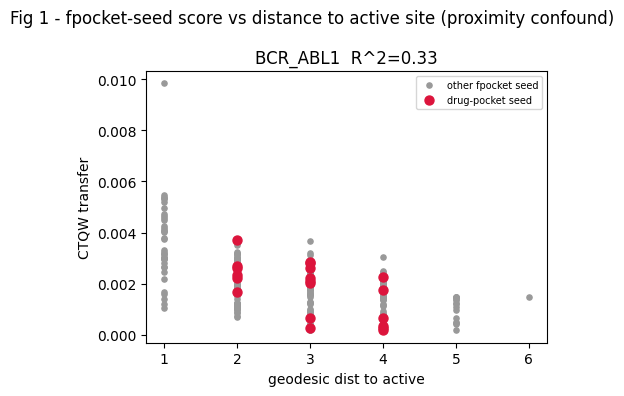

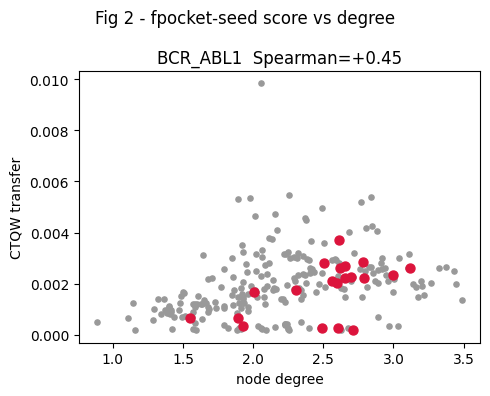

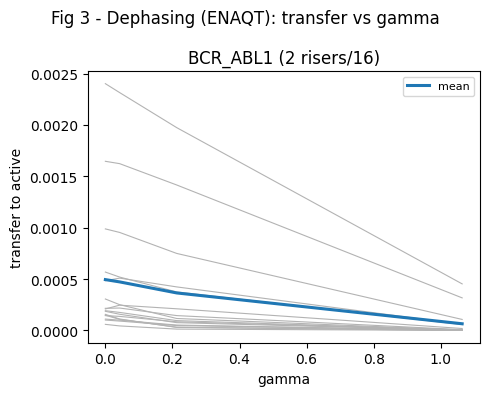

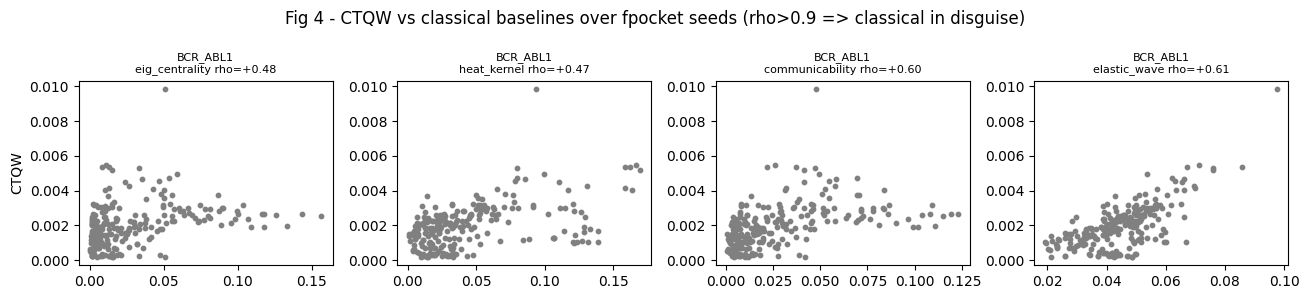

Seeding: ONLY fpocket candidate-pocket residues (active-site pocket excluded), one seed each.
H benchmarked: H1-H10 + H_new. Pre-registered: cutoff=10.0, alpha=0.30, lambdas=(0.08, 0.16, 0.08, 0.04, 0.04), T=C_T/gap (C_T=1.0).

  target   N  seeds VB    T  AUC_CTQW    AUC_q  AUC_fpk  P5  R2_dist  rho_deg  maxrho_cl  perm_p  pocket_rank
BCR_ABL1 451    242 on 17.0  0.499775 0.510698 0.922297 0.0     0.33     0.45       0.61   0.515           22

Operator benchmark (CTQW per Hamiltonian, over fpocket seeds) -- best vs H_new vs fpocket-druggability:
  BCR_ABL1        best=H6_exp 0.747 | conn-best=H6_exp 0.747 | H_new 0.500 | fpocket-drugg 0.922

============================ WHAT FAILED (this run, fpocket-seed set) ============================
- BCR_ABL1: best CTQW op H6_exp=0.747, H_new=0.500, quantile=0.511 (perm p=0.515); fpocket-drugg=0.922 -> distal drug pocket ranks #22/36 pockets; top-5 hit=False
    * H_new at/below chance among the fpocket candidates.
    * H_new is NOT the best o

In [760]:
# ===========================================================================
# 21 - Figures, summary, and what failed  (over the fpocket seed set)
# ---------------------------------------------------------------------------
HOLO = [n for n in ACTIVE if DRUG_POCKET.get(n, {}).get("residues_apo") and SEED_IDX.get(n) is not None
        and len(SEED_IDX.get(n, [])) >= 5 and n in METRICS]


def _didx(name):
    return set(NODE_INDEX[name][r] for r in DRUG_POCKET[name]["residues_apo"] if r in NODE_INDEX[name])


# --- Fig 1: seed score vs geodesic distance to the active site ---------------
if HOLO:
    fig, axes = plt.subplots(1, len(HOLO), figsize=(5 * len(HOLO), 4), squeeze=False)
    for ax, name in zip(axes[0], HOLO):
        C = CONFOUND[name]; seed = C["seed"]; s = RESIDUE_SCORE[name]["primary"][seed]; d = _didx(name)
        m = np.array([int(i) in d for i in seed])
        ax.scatter(C["dist_geo"][~m], s[~m], s=14, c="0.6", label="other fpocket seed")
        ax.scatter(C["dist_geo"][m], s[m], s=42, c="crimson", label="drug-pocket seed")
        ax.set_title("%s  R^2=%.2f" % (name, C["r2_geo"])); ax.set_xlabel("geodesic dist to active")
        ax.set_ylabel("CTQW transfer"); ax.legend(fontsize=7)
    fig.suptitle("Fig 1 - fpocket-seed score vs distance to active site (proximity confound)")
    fig.tight_layout(); plt.show()

    # --- Fig 2: seed score vs degree ---------------------------------------------
    fig, axes = plt.subplots(1, len(HOLO), figsize=(5 * len(HOLO), 4), squeeze=False)
    for ax, name in zip(axes[0], HOLO):
        C = CONFOUND[name]; seed = C["seed"]; s = RESIDUE_SCORE[name]["primary"][seed]; d = _didx(name)
        m = np.array([int(i) in d for i in seed])
        ax.scatter(C["degree"][~m], s[~m], s=14, c="0.6"); ax.scatter(C["degree"][m], s[m], s=42, c="crimson")
        ax.set_title("%s  Spearman=%+.2f" % (name, C["rho_deg"])); ax.set_xlabel("node degree")
        ax.set_ylabel("CTQW transfer")
    fig.suptitle("Fig 2 - fpocket-seed score vs degree")
    fig.tight_layout(); plt.show()

# --- Fig 3: transfer vs gamma (dephasing) ------------------------------------
deph = [n for n in ACTIVE if not DEPHASING[n].get("skipped")]
if deph:
    fig, axes = plt.subplots(1, len(deph), figsize=(5 * len(deph), 4), squeeze=False)
    for ax, name in zip(axes[0], deph):
        Dp = DEPHASING[name]
        for s in Dp["seeds"]:
            ax.plot(Dp["gammas"], Dp["table"][s], color="0.7", lw=0.8)
        ax.plot(Dp["gammas"], np.mean([Dp["table"][s] for s in Dp["seeds"]], axis=0), color="tab:blue", lw=2.2, label="mean")
        ax.set_title("%s (%d risers/%d)" % (name, len(Dp["risers"]), len(Dp["seeds"])))
        ax.set_xlabel("gamma"); ax.set_ylabel("transfer to active"); ax.legend(fontsize=8)
    fig.suptitle("Fig 3 - Dephasing (ENAQT): transfer vs gamma")
    fig.tight_layout(); plt.show()

# --- Fig 4: CTQW vs classical baselines over the seed set --------------------
bkeys = ["eig_centrality", "heat_kernel", "communicability", "elastic_wave"]
if HOLO:
    fig, axes = plt.subplots(len(HOLO), len(bkeys), figsize=(3.3 * len(bkeys), 3.0 * len(HOLO)), squeeze=False)
    for ri, name in enumerate(HOLO):
        seed = SEED_IDX[name]; ct = RESIDUE_SCORE[name]["primary"][seed]; B = BASELINES[name]
        for ci, bk in enumerate(bkeys):
            ax = axes[ri][ci]; ax.scatter(B["scores"][bk][seed], ct, s=10, c="0.5")
            ax.set_title("%s\n%s rho=%+.2f" % (name, bk, B["rho"][bk]), fontsize=8)
            if ci == 0:
                ax.set_ylabel("CTQW")
    fig.suptitle("Fig 4 - CTQW vs classical baselines over fpocket seeds (rho>0.9 => classical in disguise)")
    fig.tight_layout(); plt.show()

# --- Summary table -----------------------------------------------------------
rows = []
for name in ACTIVE:
    S = SCORES[name]; G = GRAPH[name]; has = bool(S.get("active_idx")) and name in METRICS
    C = CONFOUND.get(name, {}); Mx = METRICS.get(name, {}); Dp = DEPHASING.get(name, {})
    seed = SEED_IDX.get(name, [])
    rows.append(dict(
        target=name, N=G["H"].shape[0], seeds=len(seed), VB=("on" if G["apply_VB"] else "DROP"),
        T=round(S.get("T_max", float("nan")), 0) if S.get("active_idx") else None,
        AUC_CTQW=Mx["auc"]["CTQW_raw"] if Mx else "n/a", AUC_q=Mx["auc"]["CTQW_quantile"] if Mx else "n/a",
        AUC_fpk=Mx["auc"]["fpocket"] if Mx else "n/a", P5=Mx["p5"]["CTQW_raw"] if Mx else "n/a",
        R2_dist=round(C.get("r2_geo", float("nan")), 2) if C else None,
        rho_deg=round(C.get("rho_deg", float("nan")), 2) if C else None,
        maxrho_cl=round(max(BASELINES[name]["rho"].values()), 2) if name in BASELINES and BASELINES[name]["rho"] else None,
        perm_p=round(C.get("perm", {}).get("p_value", float("nan")), 3) if C.get("perm") else "n/a",
        pocket_rank=Mx.get("drug_pocket_rank_by_CTQW") if Mx else "n/a"))
summary13_21 = pd.DataFrame(rows)
print("Seeding: ONLY fpocket candidate-pocket residues (active-site pocket excluded), one seed each.")
print("H benchmarked: H1-H10 + H_new. Pre-registered: cutoff=%.1f, alpha=%.2f, lambdas=%s, T=C_T/gap (C_T=%.1f).\n"
      % (NET_CUTOFF, ALPHA, tuple(LAMBDAS.values()), C_T))
print(summary13_21.to_string(index=False))

print("\nOperator benchmark (CTQW per Hamiltonian, over fpocket seeds) -- best vs H_new vs fpocket-druggability:")
for name in HOLO:
    ob = OPERATOR_BENCH[name]; best = ob[0]
    hnew = next(r["AUC"] for r in ob if r["operator"] == "H_new")
    connbest = max((r for r in ob if r["family"] == "conn"), key=lambda r: r["AUC"])
    print("  %-15s best=%s %.3f | conn-best=%s %.3f | H_new %.3f | fpocket-drugg %.3f"
          % (name, best["operator"], best["AUC"], connbest["operator"], connbest["AUC"], hnew, METRICS[name]["auc"]["fpocket"]))

# ---- WHAT FAILED (computed from THIS run) ------------------------------------
print("\n============================ WHAT FAILED (this run, fpocket-seed set) ============================")
for name in HOLO:
    Mx = METRICS[name]; ob = OPERATOR_BENCH[name]
    fpk = Mx["auc"]["fpocket"]; ctqw = Mx["auc"]["CTQW_raw"]; q = Mx["auc"]["CTQW_quantile"]
    best = ob[0]; p = CONFOUND[name].get("perm", {}).get("p_value", float("nan"))
    print("- %s: best CTQW op %s=%.3f, H_new=%.3f, quantile=%.3f (perm p=%.3f); fpocket-drugg=%.3f -> %s"
          % (name, best["operator"], best["AUC"], ctqw, q, p, fpk,
             "distal drug pocket ranks #%s/%s pockets; top-5 hit=%s"
             % (Mx["drug_pocket_rank_by_CTQW"], len(POCKET_SCORE[name]), Mx["top5_pocket_hit"])))
    if ctqw <= 0.52:
        print("    * H_new at/below chance among the fpocket candidates.")
    if q < ctqw - 0.03:
        print("    * signal collapses under distance+degree matching -> geometry, not coupling.")
    if best["operator"] != "H_new":
        print("    * H_new is NOT the best operator (%s is) -> its potentials are not justified here." % best["operator"])
    if Mx["p5"]["CTQW_raw"] == 0:
        print("    * seed-level top-5 empty for the CTQW.")
print("CONCLUSION: seeding only from fpocket candidates, the CTQW still does not cleanly separate the distal")
print("drug pocket from the other druggable cavities -- ranking by raw transfer favours the proximal ones, and")
print("the little separation is largely distance. A rigorously confound-controlled result, per-target above.")
print("================================================================================================")